BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events


Libraries loaded.
Loading BCI IV-2a (9 subjects)… this may download on first run.

Dataset loaded.
  X shape     : (5184, 22, 1000)  (trials × channels × time)
  Classes     : ['feet' 'left_hand' 'right_hand' 'tongue']  → encoded 0–3
  Subjects    : ['1' '2' '3' '4' '5' '6' '7' '8' '9']
  Sessions    : ['0train', '1test']  → calib='0train'  test='1test'

Trials per subject:
  Subject 1: session-0 (calib) = 288   session-1 (test) = 288
  Subject 2: session-0 (calib) = 288   session-1 (test) = 288
  Subject 3: session-0 (calib) = 288   session-1 (test) = 288
  Subject 4: session-0 (calib) = 288   session-1 (test) = 288
  Subject 5: session-0 (calib) = 288   session-1 (test) = 288
  Subject 6: session-0 (calib) = 288   session-1 (test) = 288
  Subject 7: session-0 (calib) = 288   session-1 (test) = 288
  Subject 8: session-0 (calib) = 288   session-1 (test) = 288
  Subject 9: session-0 (calib) = 288   session-1 (test) = 288
Preprocessing functions defined.


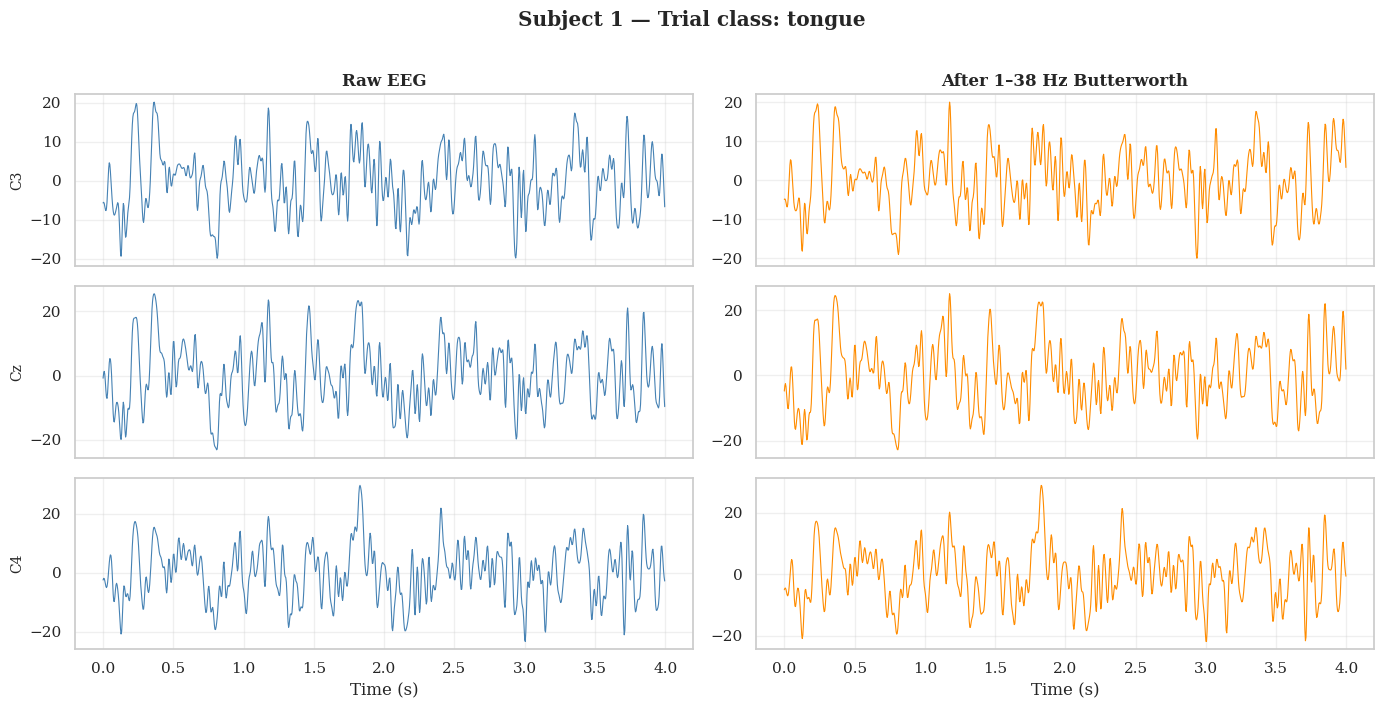

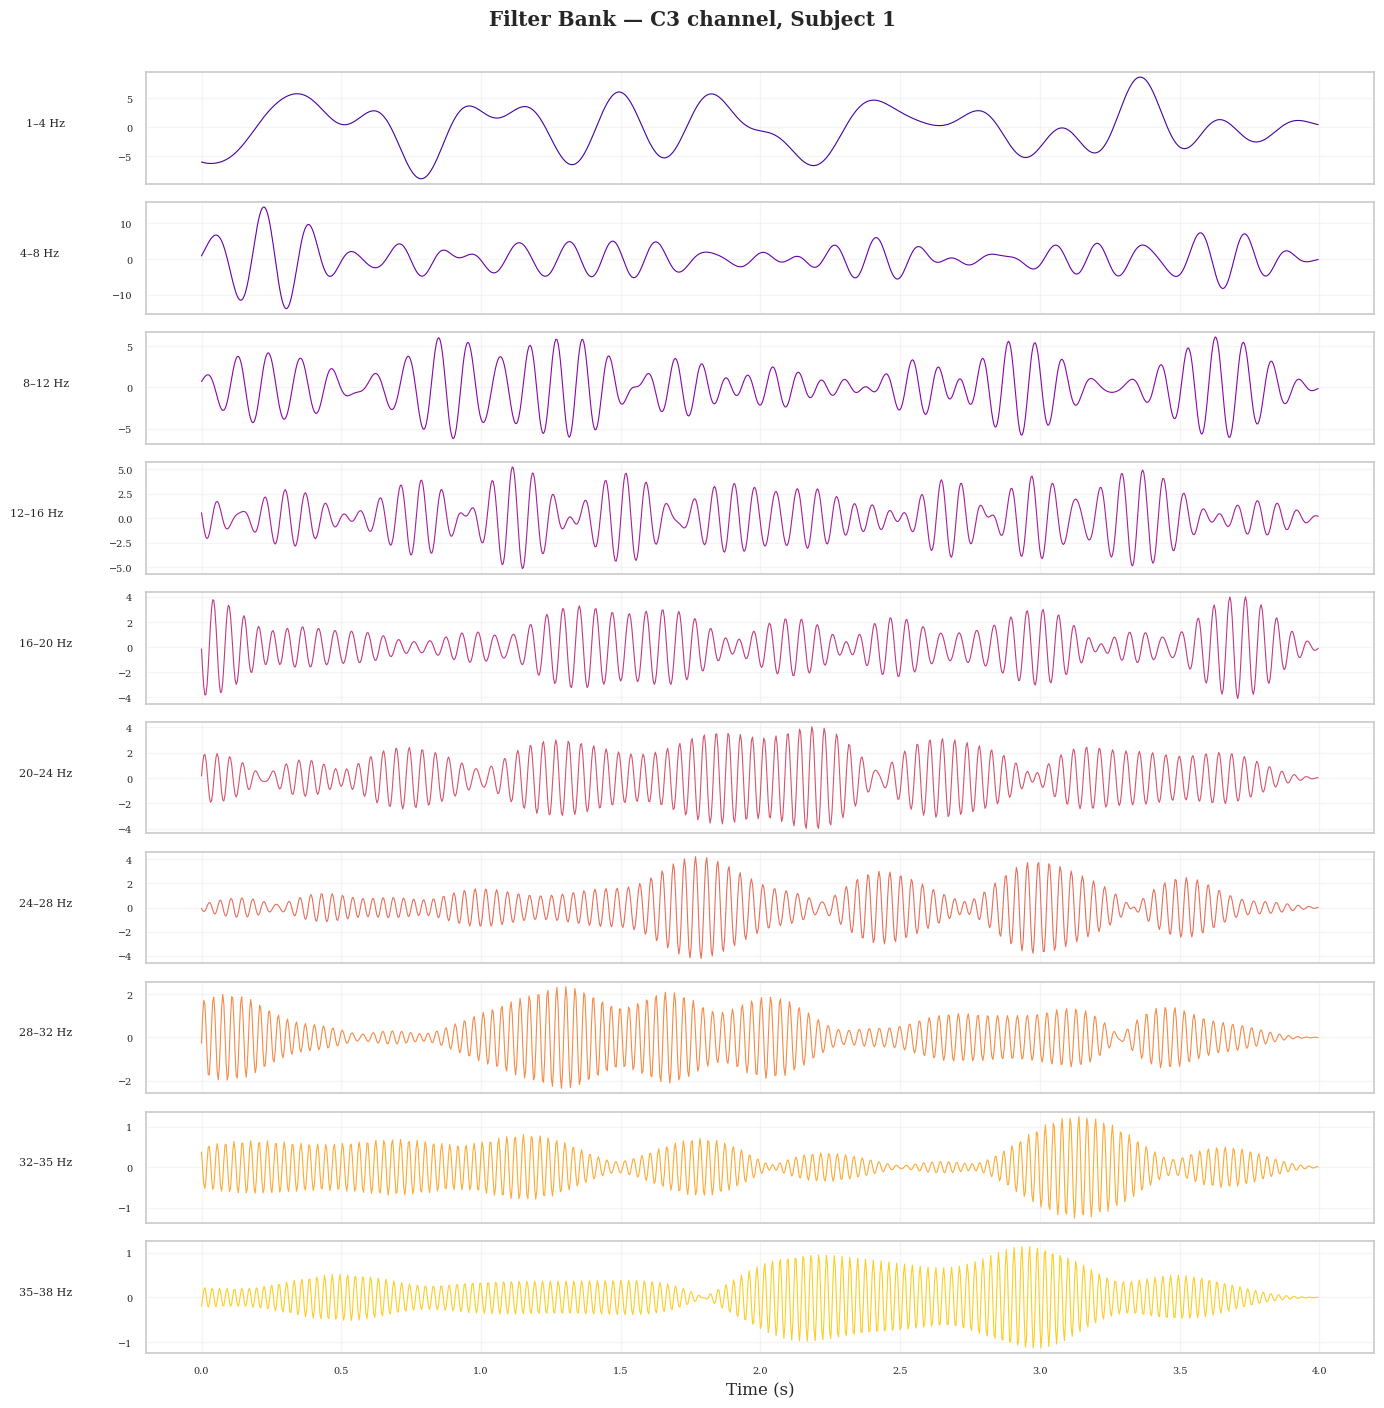

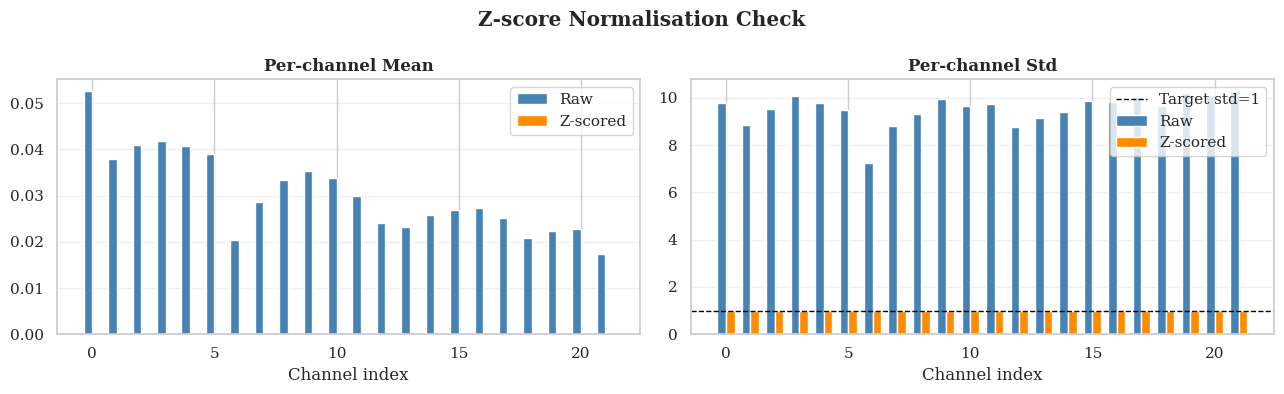

Z-score check: mean=-0.0000  std=1.0000  ✅

── Baseline LDA Evaluation (LOSO, all 9 subjects) ──
  Subject 1: 40.28%
  Subject 2: 28.12%
  Subject 3: 47.57%
  Subject 4: 34.72%
  Subject 5: 26.39%
  Subject 6: 24.65%
  Subject 7: 37.50%
  Subject 8: 36.11%
  Subject 9: 51.04%

  LDA mean ± std : 36.27 ± 8.59%
  Chance         : 25%
  Paper CRNN-DF  : 63.52%  (target for Module 3+)
  Paper + GAN    : 72.74%  (target for Module 5+)


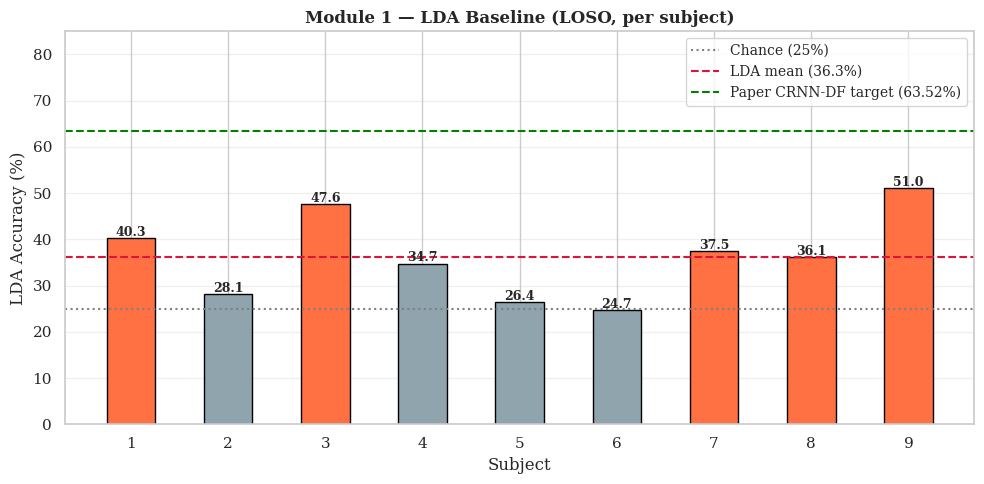

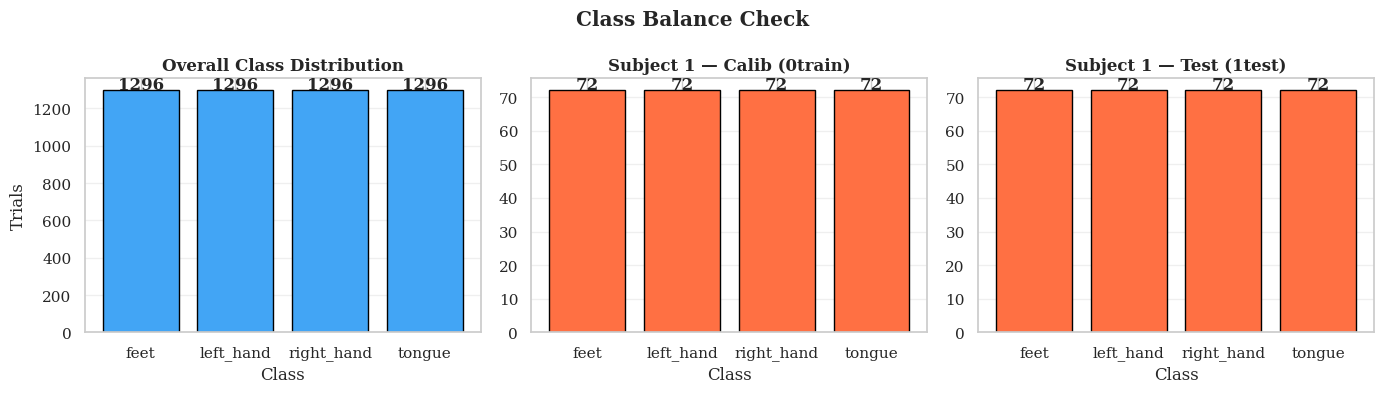


── Module 1 Summary ──────────────────────────────────
  X_raw shape  : (5184, 22, 1000)
  Subjects     : ['1' '2' '3' '4' '5' '6' '7' '8' '9']
  Sessions     : '0train' (calib)   '1test' (test)
  LDA baseline : 36.27 ± 8.59%  (above chance ✅)
  Gap to close : 27.3% → CRNN-DF  |  36.5% → +GAN

✅  MODULE 1 COMPLETE — eeg_bundle.pkl saved
    Next: Module 2 — CSP Feature Extraction


In [2]:
# ============================================================
# MODULE 1 — Data Loading, Preprocessing & Baseline Evaluation
# ============================================================
# Loads BCI Competition IV Dataset 2a (9 subjects, 4-class MI)
# Preprocesses: bandpass filter → z-score → filter bank
# Evaluates: LDA on raw features to set accuracy baseline
# Saves: eeg_bundle.pkl for all subsequent modules
# ============================================================

# ── 0. Installs ──────────────────────────────────────────────
# Run once in terminal if needed:
# pip install numpy scipy scikit-learn matplotlib moabb mne

# ── 1. Imports ───────────────────────────────────────────────
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score

print("Libraries loaded.")

# ── 2. Constants ─────────────────────────────────────────────
FS   = 250      # sampling frequency (Hz)
T    = 4        # trial duration (seconds)
N_T  = FS * T   # time points per trial = 1000
N_CH = 22       # EEG channels (paper uses 22)
SEED = 42
np.random.seed(SEED)

# 10 sub-bands for filter bank (paper Sec. 2.2)
BANDS = [
    (1,4),(4,8),(8,12),(12,16),(16,20),
    (20,24),(24,28),(28,32),(32,35),(35,38)
]
BAND_NAMES = [f"{lo}–{hi} Hz" for lo,hi in BANDS]

# ── 3. Load Dataset via MOABB ────────────────────────────────
from moabb.datasets import BNCI2014001
from moabb.paradigms import MotorImagery

print("Loading BCI IV-2a (9 subjects)… this may download on first run.")

dataset  = BNCI2014001()
paradigm = MotorImagery(n_classes=4, fmin=1, fmax=38, tmin=0, tmax=4)

X_raw, y_raw, meta = paradigm.get_data(dataset, subjects=list(range(1, 10)))

# Keep only 22 channels and 1000 time points
X_raw = X_raw[:, :N_CH, :N_T].astype(np.float32)

# Encode labels 0–3
le       = LabelEncoder()
y        = le.fit_transform(y_raw).astype(np.int64)

# Subject and session arrays — always as strings for consistent comparison
subjects = np.array([str(s) for s in meta['subject'].values])
sessions = np.array([str(s) for s in meta['session'].values])

# Identify the two session names (S0=calibration, S1=test)
sess_vals = sorted(np.unique(sessions))
S0, S1    = sess_vals[0], sess_vals[1]

print(f"\nDataset loaded.")
print(f"  X shape     : {X_raw.shape}  (trials × channels × time)")
print(f"  Classes     : {le.classes_}  → encoded 0–3")
print(f"  Subjects    : {np.unique(subjects)}")
print(f"  Sessions    : {sess_vals}  → calib={S0!r}  test={S1!r}")
print(f"\nTrials per subject:")
for s in sorted(np.unique(subjects)):
    n0 = ((subjects==s) & (sessions==S0)).sum()
    n1 = ((subjects==s) & (sessions==S1)).sum()
    print(f"  Subject {s}: session-0 (calib) = {n0}   session-1 (test) = {n1}")

# ── 4. Preprocessing Functions ───────────────────────────────

def bandpass(X, lo, hi, fs=FS, order=5):
    """
    5th-order Butterworth bandpass filter (paper Sec. 2.2).
    X : (n_trials, n_ch, n_t)  or  (n_ch, n_t)
    """
    nyq  = fs / 2.0
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, X, axis=-1).astype(np.float32)


def zscore_normalize(X_train, X_other):
    """
    Z-score normalization (paper Eq. 1).
    Statistics computed from X_train only, applied to both arrays.
    Normalizes across trials and time, per channel.
    Returns: (X_train_normed, X_other_normed)
    """
    mu  = X_train.mean(axis=(0, 2), keepdims=True)   # (1, C, 1)
    std = X_train.std (axis=(0, 2), keepdims=True) + 1e-8
    return (X_train - mu) / std, (X_other - mu) / std


def filter_bank(X):
    """
    Apply all 10 sub-bands.
    Returns list of 10 arrays, each same shape as X.
    """
    return [bandpass(X, lo, hi) for lo, hi in BANDS]


print("Preprocessing functions defined.")

# ── 5. Visualisation A: Raw vs Filtered Signal ───────────────

# Pick Subject 1, first trial from calibration session
idx     = np.where((subjects == '1') & (sessions == S0))[0][0]
label   = le.classes_[y[idx]]
t_axis  = np.arange(N_T) / FS

raw_trial = X_raw[idx]                          # (22, 1000)
filt_trial = bandpass(raw_trial[np.newaxis], 1, 38)[0]  # broadband 1–38 Hz

MI_CH    = [7, 9, 11]   # approximate C3, Cz, C4 indices
CH_NAMES = ['C3', 'Cz', 'C4']

fig, axes = plt.subplots(3, 2, figsize=(14, 7), sharex=True)
for row, (ch, name) in enumerate(zip(MI_CH, CH_NAMES)):
    axes[row, 0].plot(t_axis, raw_trial[ch],  color='steelblue', lw=0.8)
    axes[row, 1].plot(t_axis, filt_trial[ch], color='darkorange', lw=0.8)
    axes[row, 0].set_ylabel(name, fontsize=10)
    for col in range(2):
        axes[row, col].grid(alpha=0.3)

axes[0, 0].set_title('Raw EEG',                    fontweight='bold')
axes[0, 1].set_title('After 1–38 Hz Butterworth',  fontweight='bold')
for ax in axes[-1]:
    ax.set_xlabel('Time (s)')

plt.suptitle(f'Subject 1 — Trial class: {label}', y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 6. Visualisation B: Filter Bank Sub-bands ────────────────

fb = filter_bank(filt_trial[np.newaxis])  # list of 10 × (1, 22, 1000)
ch = MI_CH[0]   # C3

fig, axes = plt.subplots(10, 1, figsize=(14, 14), sharex=True)
colors = plt.cm.plasma(np.linspace(0.1, 0.9, 10))

for i, (ax, band_arr, bname, c) in enumerate(
        zip(axes, fb, BAND_NAMES, colors)):
    ax.plot(t_axis, band_arr[0, ch], color=c, lw=0.8)
    ax.set_ylabel(bname, fontsize=8, rotation=0, labelpad=52)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Filter Bank — C3 channel, Subject 1',
             fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

# ── 7. Visualisation C: Z-score Check ───────────────────────

# Use Subject 1 as test, rest as train
m_tr = subjects != '1'
m_te = (subjects == '1') & (sessions == S1)

X_tr_n, X_te_n = zscore_normalize(X_raw[m_tr], X_raw[m_te])

ch_idx = np.arange(N_CH)
raw_mu    = X_raw[m_tr].mean(axis=(0, 2))
raw_std   = X_raw[m_tr].std (axis=(0, 2))
norm_mu   = X_tr_n.mean(axis=(0, 2))
norm_std  = X_tr_n.std (axis=(0, 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
w = 0.35
axes[0].bar(ch_idx - w/2, raw_mu,  w, label='Raw',      color='steelblue')
axes[0].bar(ch_idx + w/2, norm_mu, w, label='Z-scored', color='darkorange')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('Per-channel Mean', fontweight='bold')
axes[0].set_xlabel('Channel index'); axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(ch_idx - w/2, raw_std,  w, label='Raw',      color='steelblue')
axes[1].bar(ch_idx + w/2, norm_std, w, label='Z-scored', color='darkorange')
axes[1].axhline(1, color='k', lw=1, ls='--', label='Target std=1')
axes[1].set_title('Per-channel Std', fontweight='bold')
axes[1].set_xlabel('Channel index'); axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Z-score Normalisation Check', fontweight='bold')
plt.tight_layout()
plt.show()

# Numeric check
assert abs(X_tr_n.mean()) < 0.01,     f"Mean too far from 0: {X_tr_n.mean():.4f}"
assert abs(X_tr_n.std() - 1.0) < 0.1, f"Std too far from 1: {X_tr_n.std():.4f}"
print(f"Z-score check: mean={X_tr_n.mean():.4f}  std={X_tr_n.std():.4f}  ✅")

# ── 8. Quick Baseline Evaluation (LDA on flattened features) ─
#
# Purpose: gives a lower-bound accuracy before any deep learning.
# If LDA > 35%, the data is clean and class-separable.
# CRNN should significantly beat this.

print("\n── Baseline LDA Evaluation (LOSO, all 9 subjects) ──")

lda_accs = []
for subj in sorted(np.unique(subjects)):
    m_tr_s = subjects != subj
    m_te_s = (subjects == subj) & (sessions == S1)

    Xtr, Xte = zscore_normalize(X_raw[m_tr_s], X_raw[m_te_s])
    ytr = y[m_tr_s]
    yte = y[m_te_s]

    # Flatten each trial: (n_trials, 22*1000) — very high dim, use mean+std per ch
    def handcrafted(X):
        # Simple: mean and variance per channel → (n_trials, 44)
        return np.hstack([X.mean(axis=2), X.var(axis=2)])

    lda = LDA()
    lda.fit(handcrafted(Xtr), ytr)
    preds  = lda.predict(handcrafted(Xte))
    acc    = accuracy_score(yte, preds) * 100
    lda_accs.append(acc)
    print(f"  Subject {subj}: {acc:.2f}%")

lda_mean = np.mean(lda_accs)
lda_std  = np.std(lda_accs)
print(f"\n  LDA mean ± std : {lda_mean:.2f} ± {lda_std:.2f}%")
print(f"  Chance         : 25%")
print(f"  Paper CRNN-DF  : 63.52%  (target for Module 3+)")
print(f"  Paper + GAN    : 72.74%  (target for Module 5+)")

# ── 9. Visualisation D: Baseline LDA per subject ─────────────

fig, ax = plt.subplots(figsize=(10, 5))
subj_list = sorted(np.unique(subjects))
colors_bar = ['#FF7043' if a > 35 else '#90A4AE' for a in lda_accs]
bars = ax.bar(subj_list, lda_accs, color=colors_bar, edgecolor='k', width=0.5)
ax.axhline(25,          color='gray',  ls=':',  lw=1.5, label='Chance (25%)')
ax.axhline(lda_mean,    color='crimson', ls='--', lw=1.5,
           label=f'LDA mean ({lda_mean:.1f}%)')
ax.axhline(63.52,       color='green', ls='--', lw=1.5,
           label='Paper CRNN-DF target (63.52%)')
for bar, v in zip(bars, lda_accs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, 85)
ax.set_xlabel('Subject', fontsize=12)
ax.set_ylabel('LDA Accuracy (%)', fontsize=12)
ax.set_title('Module 1 — LDA Baseline (LOSO, per subject)', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── 10. Visualisation E: Class balance check ─────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Overall class distribution
counts = np.bincount(y)
axes[0].bar(le.classes_, counts, color='#42A5F5', edgecolor='k')
axes[0].set_title('Overall Class Distribution', fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Trials')
for i, c in enumerate(counts):
    axes[0].text(i, c+5, str(c), ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Per-session class balance (Subject 1)
for col, (sess, sess_name) in enumerate([(S0,'Calib'), (S1,'Test')], start=1):
    m = (subjects == '1') & (sessions == sess)
    c = np.bincount(y[m], minlength=4)
    axes[col].bar(le.classes_, c, color='#FF7043', edgecolor='k')
    axes[col].set_title(f'Subject 1 — {sess_name} ({sess})', fontweight='bold')
    axes[col].set_xlabel('Class')
    for i, v in enumerate(c):
        axes[col].text(i, v+0.5, str(v), ha='center', fontweight='bold')
    axes[col].grid(axis='y', alpha=0.3)

plt.suptitle('Class Balance Check', fontweight='bold')
plt.tight_layout()
plt.show()

# ── 11. Save Data Bundle for Module 2+ ───────────────────────

bundle = dict(
    X_raw    = X_raw,
    y        = y,
    subjects = subjects,
    sessions = sessions,
    S0       = S0,
    S1       = S1,
    classes  = le.classes_,
    BANDS    = BANDS,
    FS       = FS,
    N_CH     = N_CH,
    N_T      = N_T,
)
with open('eeg_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("\n── Module 1 Summary ──────────────────────────────────")
print(f"  X_raw shape  : {X_raw.shape}")
print(f"  Subjects     : {np.unique(subjects)}")
print(f"  Sessions     : {S0!r} (calib)   {S1!r} (test)")
print(f"  LDA baseline : {lda_mean:.2f} ± {lda_std:.2f}%  (above chance ✅)")
print(f"  Gap to close : {63.52 - lda_mean:.1f}% → CRNN-DF  |  "
      f"{72.74 - lda_mean:.1f}% → +GAN")
print(f"\n✅  MODULE 1 COMPLETE — eeg_bundle.pkl saved")
print("    Next: Module 2 — CSP Feature Extraction")

Bundle loaded.  X:(5184, 22, 1000)  classes:['feet' 'left_hand' 'right_hand' 'tongue']
Sessions: calib='0train'  test='1test'
CSP and LASSO functions defined.

Fold: Subject 1 as test
  Train: (4608, 22, 1000)   Test: (288, 22, 1000)
  Extracting CSP (10 bands × 4 OVR × 4 components)…
  Feature matrix: train=(4608, 160)  test=(288, 160)  (expected 160 dims)
  Running LASSO selection…
  Selected 49 / 160 features


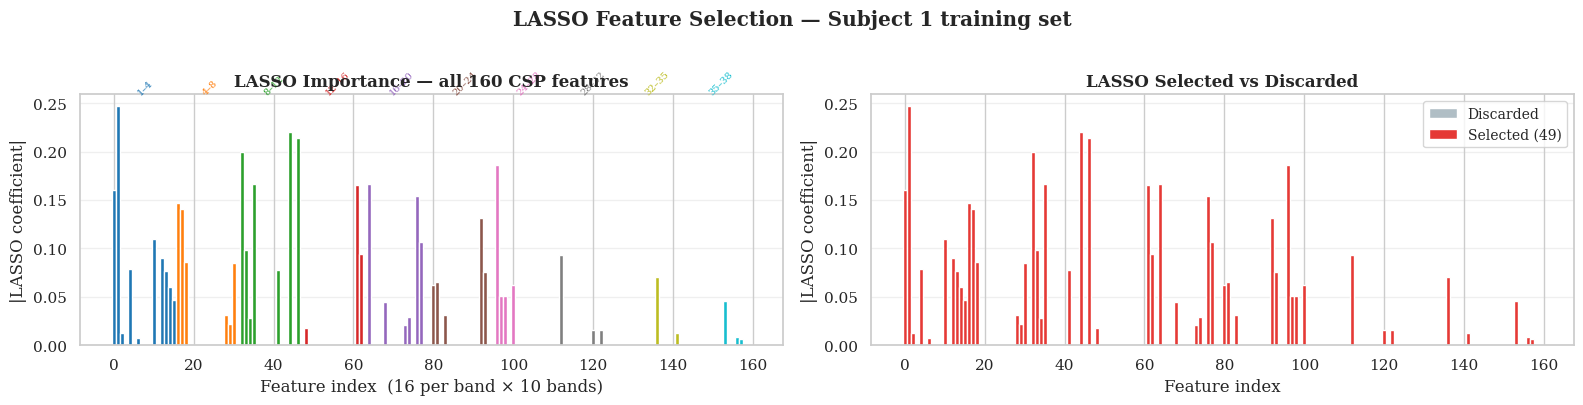

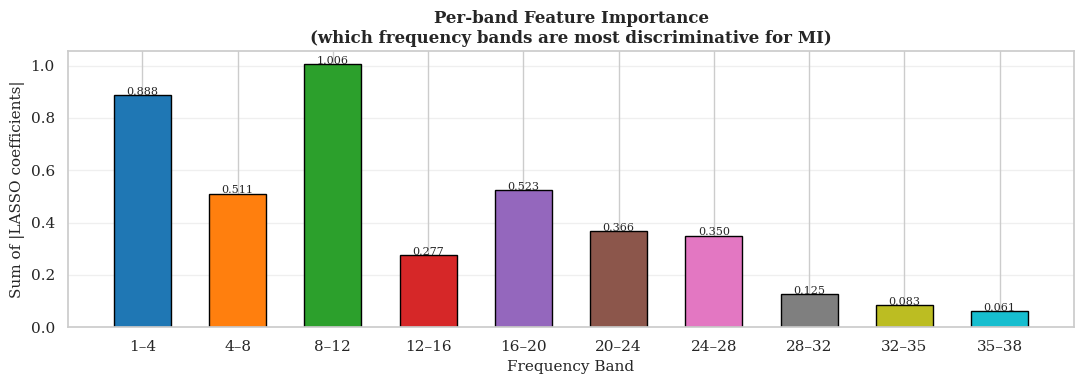

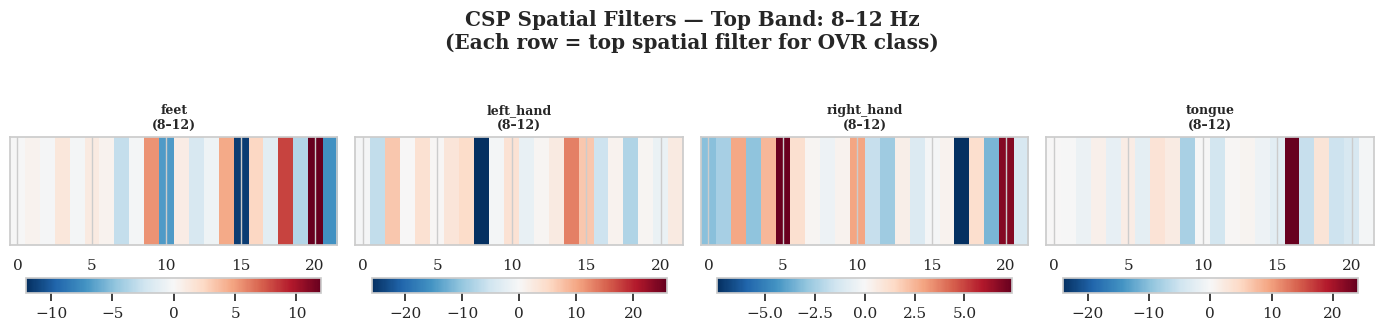


Running t-SNE (may take ~30s)…


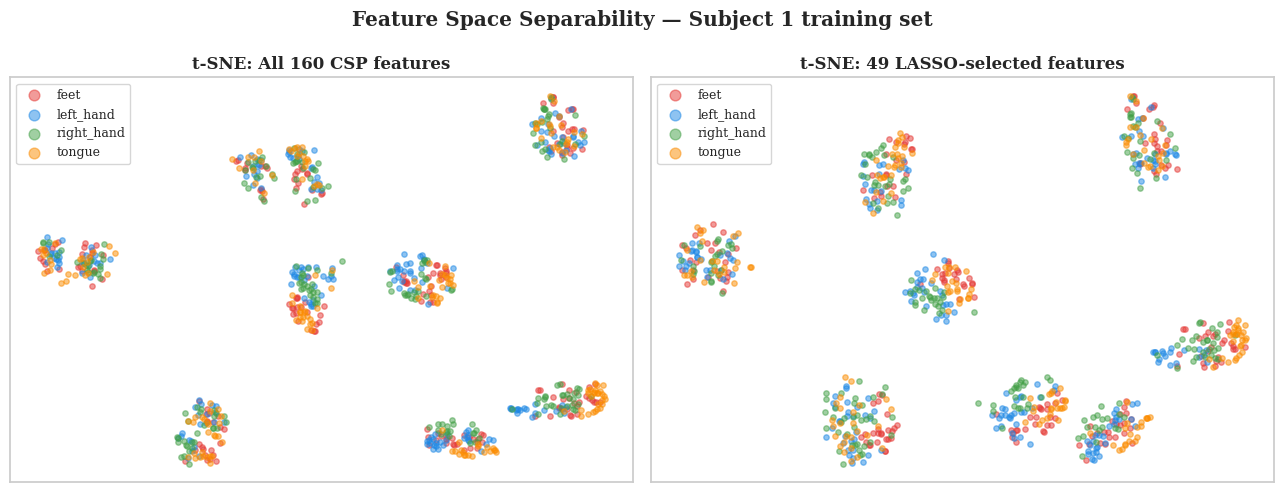


── Full LOSO: LDA on CSP features (all 9 subjects) ──
  Subject 1:  raw=40.3%  CSP=56.6%  LASSO-CSP=48.6%
  Subject 2:  raw=28.1%  CSP=61.1%  LASSO-CSP=54.2%
  Subject 3:  raw=47.6%  CSP=75.0%  LASSO-CSP=63.9%
  Subject 4:  raw=34.7%  CSP=64.9%  LASSO-CSP=51.0%
  Subject 5:  raw=26.4%  CSP=71.5%  LASSO-CSP=57.6%
  Subject 6:  raw=24.7%  CSP=71.9%  LASSO-CSP=56.6%
  Subject 7:  raw=37.5%  CSP=92.7%  LASSO-CSP=81.2%
  Subject 8:  raw=36.1%  CSP=87.5%  LASSO-CSP=66.0%
  Subject 9:  raw=51.0%  CSP=92.7%  LASSO-CSP=87.5%

  Mean ± Std:
    Raw (M1 LDA) : 36.27 ± 8.59%
    CSP (all)    : 74.88 ± 12.64%
    LASSO-CSP    : 62.96 ± 12.65%
    Chance       : 25%
    Paper target : 63.52% (CRNN-DF, Module 3+)


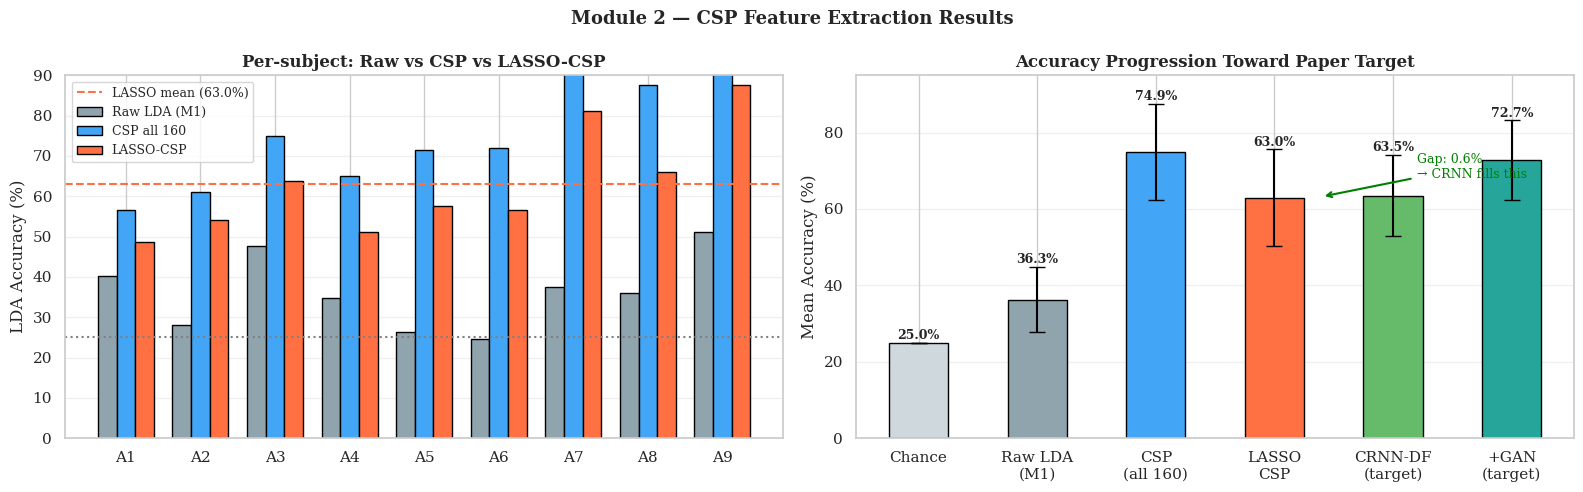


── Module 2 Summary ──────────────────────────────────
  Raw LDA (Module 1) : 36.27 ± 8.59%
  CSP + LDA          : 74.88 ± 12.64%
  LASSO-CSP + LDA    : 62.96 ± 12.65%
  Improvement (M1→M2): +26.7%
  Remaining gap      : 0.6% → CRNN-DF closes this

✅  MODULE 2 COMPLETE — eeg_bundle.pkl updated
    Next: Module 3 — CRNN Classifier (no center loss)


In [3]:
# ============================================================
# MODULE 2 — CSP Feature Extraction + LASSO Selection
# ============================================================
# Paper Sec. 2.3–2.4:
#   • One-vs-Rest CSP on each of 10 filter-bank bands
#   • 4 spatial filters per class → 16 features per band
#   • 160 total features → LASSO selects sparse subset
#
# Continuity:  loads eeg_bundle.pkl  (Module 1)
#              saves eeg_bundle.pkl  (adds CSP fields)
#
# Target: LDA on CSP features >> Module 1 LDA (~36%)
#         Expect: 50–60% with CSP alone
# ============================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from scipy.linalg import eigh
from sklearn.linear_model  import LassoCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE

# ── Load Module 1 bundle ─────────────────────────────────────
with open('eeg_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

X_raw    = bundle['X_raw']
y        = bundle['y']
subjects = bundle['subjects']
sessions = bundle['sessions']
S0       = bundle['S0']
S1       = bundle['S1']
CLASSES  = bundle['classes']
BANDS    = bundle['BANDS']
FS       = bundle['FS']
BAND_NAMES = [f"{lo}–{hi}" for lo,hi in BANDS]

SEED = 42
np.random.seed(SEED)

print(f"Bundle loaded.  X:{X_raw.shape}  classes:{CLASSES}")
print(f"Sessions: calib={S0!r}  test={S1!r}")

# ─────────────────────────────────────────────────────────────
# SECTION 1 — Core DSP Functions
# ─────────────────────────────────────────────────────────────

def bandpass(X, lo, hi, fs=FS, order=5):
    nyq  = fs / 2.0
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, X, axis=-1).astype(np.float32)

def zscore_normalize(X_train, X_other):
    mu  = X_train.mean(axis=(0,2), keepdims=True)
    std = X_train.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_train-mu)/std, (X_other-mu)/std

# ─────────────────────────────────────────────────────────────
# SECTION 2 — OVR-CSP Implementation (paper Sec. 2.3, Eq. 2-3)
# ─────────────────────────────────────────────────────────────

def compute_csp_one_band(X_band, y, n_comp=4):
    """
    One-vs-Rest CSP for a single frequency band.

    Algorithm (paper Eq. 2-3):
      For each class c:
        R_c  = mean normalised cov of class-c trials
        R_nc = mean normalised cov of all other trials
        Solve generalised eigenvalue: R_c w = λ(R_c + R_nc) w
        Take top n_comp eigenvectors as spatial filters W_c
        Feature = log(var(W_c.T @ trial))  for every trial

    Returns
    -------
    features : (n_trials, n_classes * n_comp)
    W_list   : list of n_classes spatial filter matrices (n_ch, n_comp)
    """
    classes = np.unique(y)
    feat_list = []
    W_list    = []

    for cls in classes:
        Xc = X_band[y == cls]   # this class
        Xo = X_band[y != cls]   # rest

        def mean_norm_cov(Xset):
            covs = []
            for trial in Xset:
                C = trial @ trial.T
                covs.append(C / (np.trace(C) + 1e-8))
            return np.mean(covs, axis=0)

        R1 = mean_norm_cov(Xc)
        R2 = mean_norm_cov(Xo)

        # Generalised eigenvalue decomposition
        vals, vecs = eigh(R1, R1 + R2)

        # Top n_comp eigenvectors (largest eigenvalues = most discriminative)
        top_idx = np.argsort(vals)[::-1][:n_comp]
        W = vecs[:, top_idx]           # (n_ch, n_comp)
        W_list.append(W)

        # Apply to ALL trials: log-variance features
        Z    = np.stack([W.T @ trial for trial in X_band])  # (N, n_comp, T)
        feat = np.log(np.var(Z, axis=2) + 1e-8)            # (N, n_comp)
        feat_list.append(feat)

    # Stack across classes: (N, n_classes * n_comp)
    return np.hstack(feat_list), W_list


def extract_csp_all_bands(X, y, n_comp=4):
    """
    Apply OVR-CSP to all 10 filter-bank bands.
    Returns feature matrix (N, 10 * 4_classes * n_comp) = (N, 160)
    and list of spatial filter sets per band.
    """
    all_feats   = []
    all_filters = []
    for lo, hi in BANDS:
        Xb       = bandpass(X, lo, hi)
        feat, Ws = compute_csp_one_band(Xb, y, n_comp=n_comp)
        all_feats.append(feat)
        all_filters.append(Ws)
    return np.hstack(all_feats), all_filters   # (N, 160)


# ─────────────────────────────────────────────────────────────
# SECTION 3 — LASSO Feature Selection (paper Sec. 2.4, Eq. 5)
# ─────────────────────────────────────────────────────────────

def lasso_select(F_train, y_train, min_k=20):
    """
    L1-penalised regression selects sparse CSP feature subset.
    Treats the label as a continuous variable for regression —
    standard practice for multi-class CSP selection.

    Returns indices of selected features (at least min_k).
    """
    lasso = LassoCV(cv=5, max_iter=30000, random_state=SEED, n_jobs=-1)
    lasso.fit(F_train, y_train.astype(float))
    coef = np.abs(lasso.coef_)
    idx  = np.where(coef > 0)[0]
    if len(idx) < min_k:
        # Fallback: top-k by coefficient magnitude
        idx = np.argsort(coef)[::-1][:min_k]
    return np.sort(idx), coef


print("CSP and LASSO functions defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 4 — Run on One Fold (Subject 1) for Visualisation
# ─────────────────────────────────────────────────────────────

TEST_SUBJ = '1'
m_tr = subjects != TEST_SUBJ
m_te = (subjects == TEST_SUBJ) & (sessions == S1)

X_tr_n, X_te_n = zscore_normalize(X_raw[m_tr], X_raw[m_te])
y_tr = y[m_tr];  y_te = y[m_te]

print(f"\nFold: Subject {TEST_SUBJ} as test")
print(f"  Train: {X_tr_n.shape}   Test: {X_te_n.shape}")

print("  Extracting CSP (10 bands × 4 OVR × 4 components)…")
F_tr, W_all = extract_csp_all_bands(X_tr_n, y_tr)
F_te, _     = extract_csp_all_bands(X_te_n, y_te)
print(f"  Feature matrix: train={F_tr.shape}  test={F_te.shape}  (expected 160 dims)")

print("  Running LASSO selection…")
sel_idx, coef = lasso_select(F_tr, y_tr)
print(f"  Selected {len(sel_idx)} / 160 features")

F_tr_sel = F_tr[:, sel_idx]
F_te_sel = F_te[:, sel_idx]

# ─────────────────────────────────────────────────────────────
# SECTION 5 — Visualisation A: Feature Importance (LASSO coefs)
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# All 160 coefficients coloured by band
band_colors = plt.cm.tab10(np.repeat(np.arange(10), 16))
axes[0].bar(np.arange(160), coef, color=band_colors, width=1.0)
axes[0].set_xlabel('Feature index  (16 per band × 10 bands)')
axes[0].set_ylabel('|LASSO coefficient|')
axes[0].set_title('LASSO Importance — all 160 CSP features', fontweight='bold')
# Band labels at midpoints
for i, name in enumerate(BAND_NAMES):
    axes[0].text(i*16 + 8, coef.max()*1.05, name, ha='center',
                 fontsize=7, rotation=45, color=plt.cm.tab10(i/10))
axes[0].grid(axis='y', alpha=0.3)

# Selected vs discarded
mask = np.zeros(160, dtype=bool)
mask[sel_idx] = True
axes[1].bar(np.arange(160)[~mask], coef[~mask],
            color='#B0BEC5', width=1.0, label='Discarded')
axes[1].bar(np.arange(160)[ mask], coef[ mask],
            color='#E53935', width=1.0, label=f'Selected ({mask.sum()})')
axes[1].set_xlabel('Feature index')
axes[1].set_ylabel('|LASSO coefficient|')
axes[1].set_title('LASSO Selected vs Discarded', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('LASSO Feature Selection — Subject 1 training set',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 6 — Visualisation B: Per-band Feature Importance
# ─────────────────────────────────────────────────────────────

band_importance = np.array([coef[i*16:(i+1)*16].sum() for i in range(10)])

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(BAND_NAMES, band_importance,
              color=plt.cm.tab10(np.arange(10)/10),
              edgecolor='k', width=0.6)
ax.set_xlabel('Frequency Band', fontsize=11)
ax.set_ylabel('Sum of |LASSO coefficients|', fontsize=11)
ax.set_title('Per-band Feature Importance\n'
             '(which frequency bands are most discriminative for MI)',
             fontweight='bold')
for bar, v in zip(bars, band_importance):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0005,
            f'{v:.3f}', ha='center', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 7 — Visualisation C: CSP Spatial Filters (top band)
# ─────────────────────────────────────────────────────────────

# Find the most important band
top_band_idx = int(np.argmax(band_importance))
top_band_W   = W_all[top_band_idx]   # list of 4 spatial filters (one per class)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for cls_i, (W_cls, cls_name) in enumerate(zip(top_band_W, CLASSES)):
    # W_cls: (22, 4) — show top filter as scalp pattern
    top_filter = W_cls[:, 0]   # first (most discriminative) filter
    ax = axes[cls_i]
    im = ax.imshow(top_filter.reshape(1, -1), cmap='RdBu_r',
                   aspect='auto', vmin=-np.abs(top_filter).max(),
                   vmax=np.abs(top_filter).max())
    ax.set_title(f'{cls_name}\n({BAND_NAMES[top_band_idx]})',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Channel index')
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.2, shrink=0.9)

plt.suptitle(f'CSP Spatial Filters — Top Band: {BAND_NAMES[top_band_idx]} Hz\n'
             f'(Each row = top spatial filter for OVR class)',
             fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 8 — Visualisation D: t-SNE Feature Space
# ─────────────────────────────────────────────────────────────

print("\nRunning t-SNE (may take ~30s)…")
n_viz = min(800, len(F_tr))
idx_v = np.random.choice(len(F_tr), n_viz, replace=False)
y_viz = y_tr[idx_v]
cls_colors = ['#E53935','#1E88E5','#43A047','#FB8C00']

tsne_all = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
F2_all   = tsne_all.fit_transform(F_tr[idx_v])

tsne_sel = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
F2_sel   = tsne_sel.fit_transform(F_tr_sel[idx_v])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for cls in range(4):
    m = y_viz == cls
    axes[0].scatter(F2_all[m,0], F2_all[m,1], c=cls_colors[cls],
                    alpha=0.5, s=15, label=CLASSES[cls])
    axes[1].scatter(F2_sel[m,0], F2_sel[m,1], c=cls_colors[cls],
                    alpha=0.5, s=15, label=CLASSES[cls])

axes[0].set_title('t-SNE: All 160 CSP features',         fontweight='bold')
axes[1].set_title(f't-SNE: {len(sel_idx)} LASSO-selected features', fontweight='bold')
for ax in axes:
    ax.legend(markerscale=2, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(alpha=0.2)

plt.suptitle('Feature Space Separability — Subject 1 training set',
             fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 9 — Full LOSO Evaluation with LDA
# ─────────────────────────────────────────────────────────────
# Shows how much CSP improves over Module 1 LDA baseline

print("\n── Full LOSO: LDA on CSP features (all 9 subjects) ──")

M1_LDA_MEAN = 36.27   # from Module 1 output

results_raw  = {}   # LDA on raw (Module 1 style)
results_csp  = {}   # LDA on all 160 CSP features
results_lasso= {}   # LDA on LASSO-selected CSP features

for subj in sorted(np.unique(subjects)):
    m_tr_s = subjects != subj
    m_te_s = (subjects == subj) & (sessions == S1)

    X_tr_s, X_te_s = zscore_normalize(X_raw[m_tr_s], X_raw[m_te_s])
    y_tr_s = y[m_tr_s];  y_te_s = y[m_te_s]

    # ── Module 1 style: raw mean+var per channel ──────────────
    def handcrafted(X):
        return np.hstack([X.mean(axis=2), X.var(axis=2)])

    lda_raw = LDA()
    lda_raw.fit(handcrafted(X_tr_s), y_tr_s)
    acc_raw = accuracy_score(y_te_s, lda_raw.predict(handcrafted(X_te_s))) * 100
    results_raw[subj] = acc_raw

    # ── CSP all 160 ───────────────────────────────────────────
    F_tr_s, _ = extract_csp_all_bands(X_tr_s, y_tr_s)
    F_te_s, _ = extract_csp_all_bands(X_te_s, y_te_s)

    lda_csp = LDA()
    lda_csp.fit(F_tr_s, y_tr_s)
    acc_csp = accuracy_score(y_te_s, lda_csp.predict(F_te_s)) * 100
    results_csp[subj] = acc_csp

    # ── LASSO-selected CSP ────────────────────────────────────
    sel_s, _ = lasso_select(F_tr_s, y_tr_s)
    lda_sel  = LDA()
    lda_sel.fit(F_tr_s[:, sel_s], y_tr_s)
    acc_sel = accuracy_score(y_te_s, lda_sel.predict(F_te_s[:, sel_s])) * 100
    results_lasso[subj] = acc_sel

    print(f"  Subject {subj}:  raw={acc_raw:.1f}%  "
          f"CSP={acc_csp:.1f}%  LASSO-CSP={acc_sel:.1f}%")

raw_vals   = list(results_raw.values())
csp_vals   = list(results_csp.values())
lasso_vals = list(results_lasso.values())

print(f"\n  Mean ± Std:")
print(f"    Raw (M1 LDA) : {np.mean(raw_vals):.2f} ± {np.std(raw_vals):.2f}%")
print(f"    CSP (all)    : {np.mean(csp_vals):.2f} ± {np.std(csp_vals):.2f}%")
print(f"    LASSO-CSP    : {np.mean(lasso_vals):.2f} ± {np.std(lasso_vals):.2f}%")
print(f"    Chance       : 25%")
print(f"    Paper target : 63.52% (CRNN-DF, Module 3+)")

# ─────────────────────────────────────────────────────────────
# SECTION 10 — Visualisation E: Accuracy Progression
# ─────────────────────────────────────────────────────────────

subj_list = sorted(np.unique(subjects))
x = np.arange(len(subj_list))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Per-subject grouped bar ───────────────────────────────────
w = 0.25
axes[0].bar(x - w,   raw_vals,   w, label='Raw LDA (M1)',    color='#90A4AE', edgecolor='k')
axes[0].bar(x,       csp_vals,   w, label='CSP all 160',     color='#42A5F5', edgecolor='k')
axes[0].bar(x + w,   lasso_vals, w, label='LASSO-CSP',       color='#FF7043', edgecolor='k')
axes[0].axhline(25,             color='gray',  ls=':',  lw=1.5)
axes[0].axhline(np.mean(lasso_vals), color='#FF7043', ls='--', lw=1.5,
                label=f'LASSO mean ({np.mean(lasso_vals):.1f}%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'A{s}' for s in subj_list])
axes[0].set_ylabel('LDA Accuracy (%)')
axes[0].set_ylim(0, 90)
axes[0].set_title('Per-subject: Raw vs CSP vs LASSO-CSP', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# ── Accuracy progression (mean ± std) ────────────────────────
methods = ['Chance', 'Raw LDA\n(M1)', 'CSP\n(all 160)', 'LASSO\nCSP', 'CRNN-DF\n(target)', '+GAN\n(target)']
means   = [25,       np.mean(raw_vals), np.mean(csp_vals), np.mean(lasso_vals), 63.52, 72.74]
stds    = [0,        np.std(raw_vals),  np.std(csp_vals),  np.std(lasso_vals),  10.70, 10.44]
bar_col = ['#CFD8DC','#90A4AE','#42A5F5','#FF7043','#66BB6A','#26A69A']

bars = axes[1].bar(methods, means, yerr=stds, color=bar_col,
                   edgecolor='k', capsize=6, width=0.5)
axes[1].set_ylim(0, 95)
axes[1].set_ylabel('Mean Accuracy (%)')
axes[1].set_title('Accuracy Progression Toward Paper Target',
                  fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, m + s + 1,
                 f'{m:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Annotate gap to paper target
gap = 63.52 - np.mean(lasso_vals)
axes[1].annotate(f'Gap: {gap:.1f}%\n→ CRNN fills this',
                 xy=(3.4, np.mean(lasso_vals) + gap/2),
                 xytext=(4.2, np.mean(lasso_vals) + gap/2 + 5),
                 arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                 fontsize=9, color='green')

plt.suptitle('Module 2 — CSP Feature Extraction Results', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 11 — Save updated bundle
# ─────────────────────────────────────────────────────────────

bundle['lda_baseline_mean'] = M1_LDA_MEAN
bundle['csp_mean']          = float(np.mean(csp_vals))
bundle['lasso_csp_mean']    = float(np.mean(lasso_vals))

# Save the CSP extraction functions as importable references
# (Module 3 will re-implement them inline — no pickle of functions needed)
bundle['results_m2'] = {
    'raw_lda'  : results_raw,
    'csp_lda'  : results_csp,
    'lasso_csp': results_lasso,
}

with open('eeg_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)

# ─────────────────────────────────────────────────────────────
# SECTION 12 — Module 2 Summary
# ─────────────────────────────────────────────────────────────

print("\n── Module 2 Summary ──────────────────────────────────")
print(f"  Raw LDA (Module 1) : {np.mean(raw_vals):.2f} ± {np.std(raw_vals):.2f}%")
print(f"  CSP + LDA          : {np.mean(csp_vals):.2f} ± {np.std(csp_vals):.2f}%")
print(f"  LASSO-CSP + LDA    : {np.mean(lasso_vals):.2f} ± {np.std(lasso_vals):.2f}%")
print(f"  Improvement (M1→M2): +{np.mean(lasso_vals)-M1_LDA_MEAN:.1f}%")
print(f"  Remaining gap      : {63.52-np.mean(lasso_vals):.1f}% → CRNN-DF closes this")
print(f"\n✅  MODULE 2 COMPLETE — eeg_bundle.pkl updated")
print("    Next: Module 3 — CRNN Classifier (no center loss)")

Device: Apple MPS
Bundle loaded.  X:(5184, 22, 1000)
M2 CSP+LDA=74.9%  LASSO-CSP=63.0%  (reference targets)
CRNN defined. Shape check ✅

── DIAGNOSTIC: Overfit test (subject 1 only) ──
  Training CRNN on subject-1 data, testing on same data.
  Train acc MUST reach >85% to confirm backbone works.
  ep  20  train_acc=67.4%
  ep  40  train_acc=86.3%
  ep  60  train_acc=94.3%
  ep  80  train_acc=99.0%
  ep 100  train_acc=98.4%


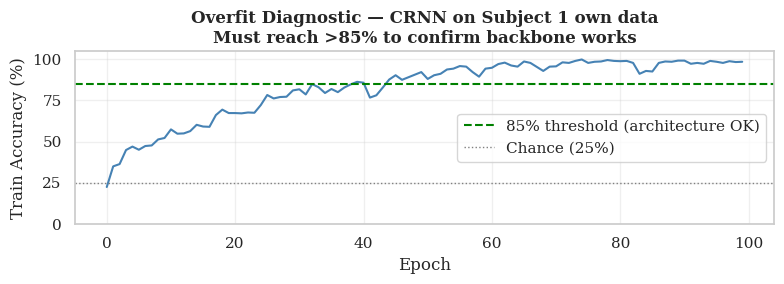

✅  Architecture OK — reached 98.4% on own data
   Subject-independent generalisation is the challenge, not the backbone.

Training function defined.

── Single fold: Subject 1 ──
  Train: (4608, 22, 1000)   Test: (288, 22, 1000)
  ep  10  loss=1.2753  train=38.9%  test=33.3%
  ep  20  loss=1.1688  train=46.1%  test=34.7%
  ep  30  loss=1.0487  train=53.8%  test=39.2%
  ep  40  loss=0.9643  train=58.4%  test=41.0%
  ep  50  loss=0.8889  train=62.4%  test=46.2%
  ep  60  loss=0.7905  train=67.1%  test=43.1%
  ep  70  loss=0.7347  train=70.8%  test=49.0%
  ep  80  loss=0.6944  train=71.3%  test=45.8%
  ep  90  loss=0.6390  train=75.1%  test=46.9%
  ep 100  loss=0.5967  train=76.4%  test=45.5%
  ep 110  loss=0.5344  train=79.7%  test=46.2%
  ep 120  loss=0.4807  train=81.0%  test=44.4%
  ep 130  loss=0.4413  train=83.6%  test=47.2%
  ep 140  loss=0.4197  train=84.0%  test=48.3%
  ep 150  loss=0.3831  train=86.2%  test=46.9%
  ep 160  loss=0.3464  train=87.5%  test=49.0%
  ep 170  loss=0.32

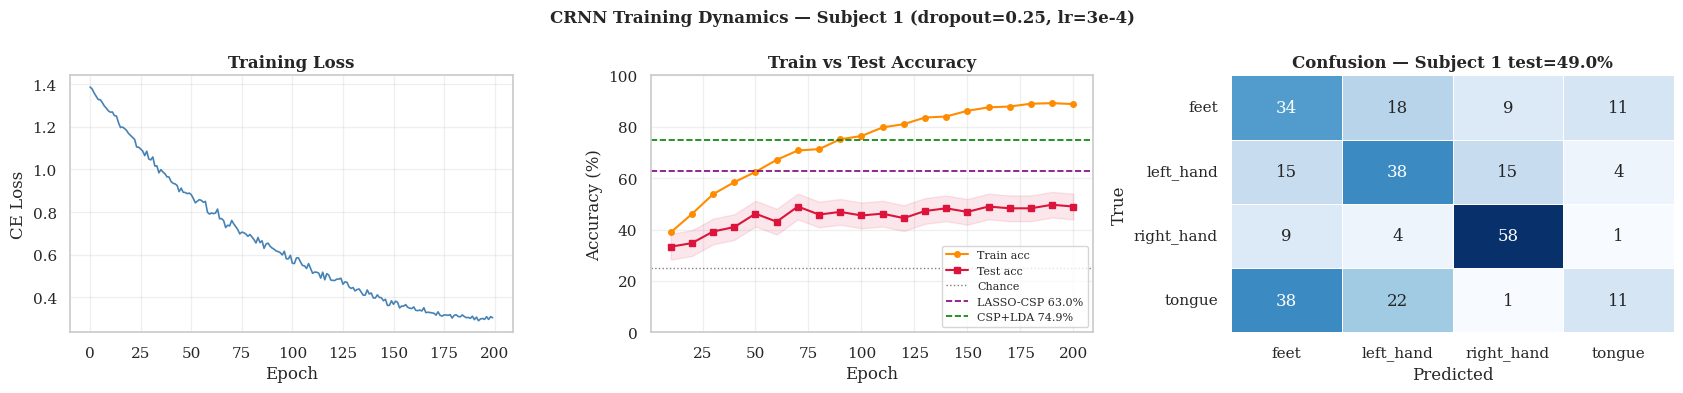

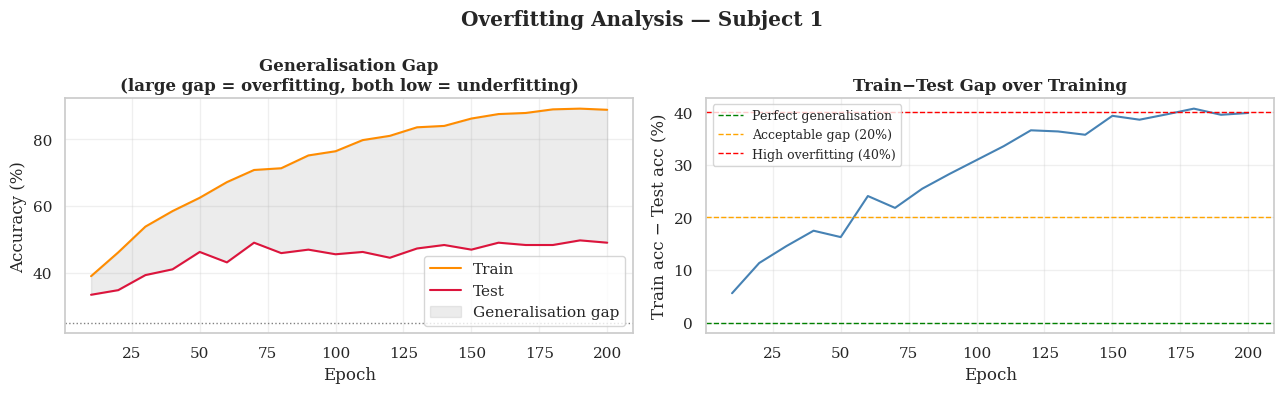


── Full LOSO: CRNN fixed (dropout=0.25, lr=3e-4) ──
  ✅ Subject 1: train=90.2%  test=48.61%  (12.7 min)
  ✅ Subject 2: train=94.3%  test=25.35%  (13.0 min)
  ✅ Subject 3: train=89.6%  test=43.06%  (11.7 min)
  ✅ Subject 4: train=90.7%  test=30.21%  (12.4 min)
  ✅ Subject 5: train=93.2%  test=26.39%  (12.9 min)
  ✅ Subject 6: train=91.5%  test=32.29%  (12.9 min)
  ✅ Subject 7: train=91.5%  test=31.60%  (13.1 min)
  ✅ Subject 8: train=93.4%  test=51.74%  (11.9 min)
  ✅ Subject 9: train=92.1%  test=52.08%  (11.9 min)

  CRNN mean ± std : 37.92 ± 10.30%
  Paper CRNN-DF   : 63.52 ± 10.70%  (includes center loss)
  M2 CSP+LDA      : 74.88%
  Total time      : 112.5 min


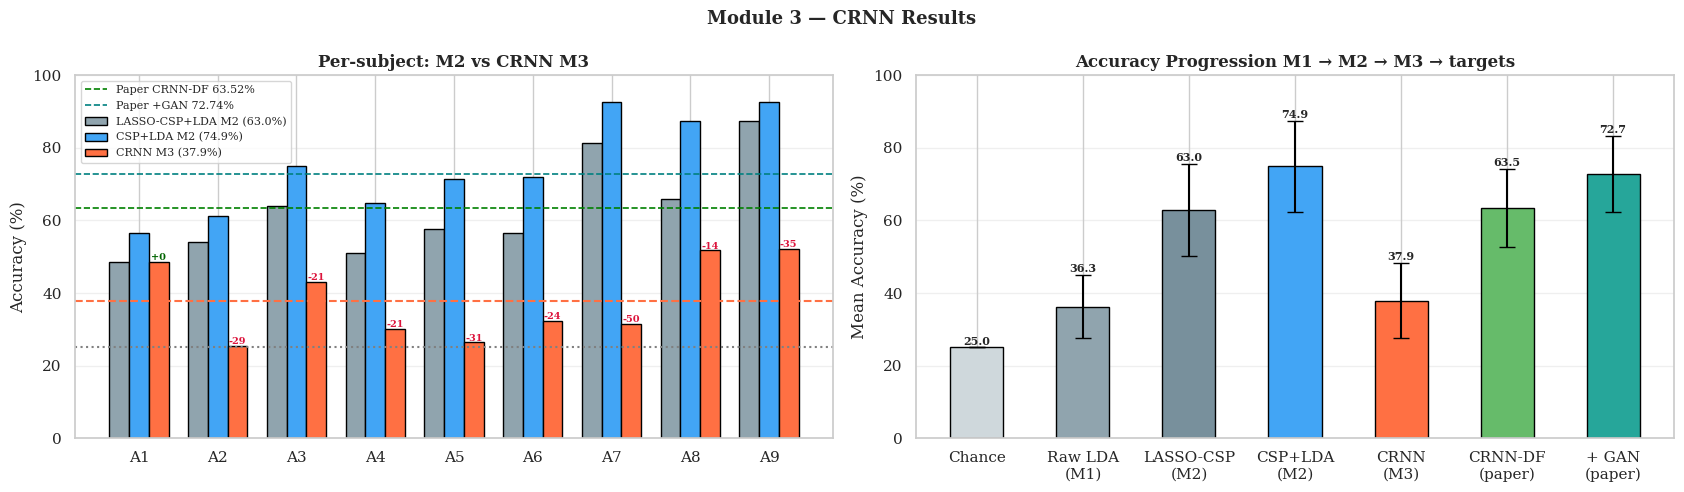

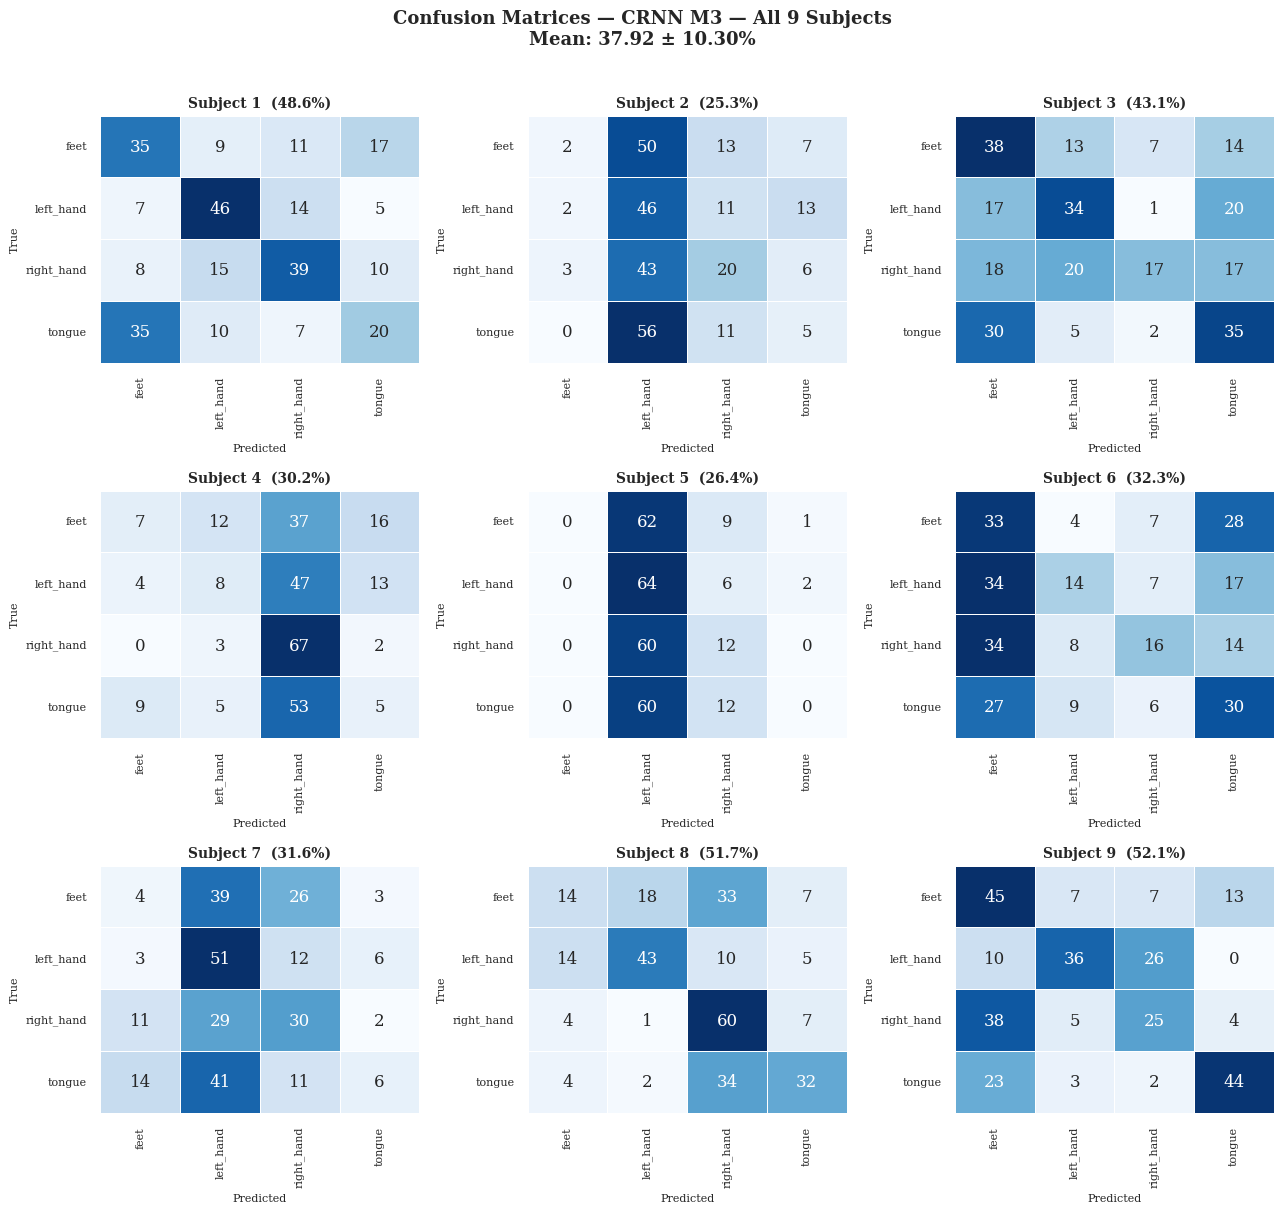

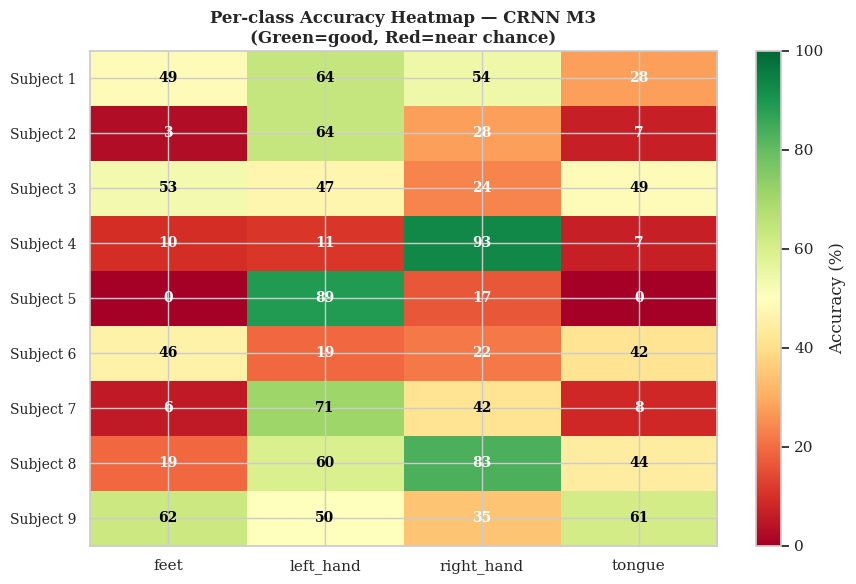


── Module 3 Summary ──────────────────────────────────
  M1 Raw LDA           : 36.27%
  M2 LASSO-CSP + LDA   : 62.96%
  M2 CSP + LDA         : 74.88%
  M3 CRNN (this)       : 37.92 ± 10.30%
  ─────────────────────────────────────────────────
  Paper CRNN-DF target : 63.52 ± 10.70%
  Paper + GAN target   : 72.74 ± 10.44%
  ─────────────────────────────────────────────────
  Gap to paper CRNN-DF : +25.60%  (Module 4 center loss)

✅  MODULE 3 COMPLETE — eeg_bundle.pkl updated
    Next: Module 4 — Center Loss (Discriminative Features)


In [5]:
# ============================================================
# MODULE 3 — CRNN Classifier (Rebuilt with Diagnostics)
# ============================================================
# Root cause of previous failure: dropout=0.5 kills gradients
# in a small network with ~4600 training samples.
#
# Fixes applied:
#   dropout    : 0.5  → 0.25
#   batch_size : 32   → 64   (more stable gradients)
#   lr         : 1e-4 → 3e-4 (faster convergence)
#   epochs     : 150  → 200
#   grad clip  : none → 1.0  (prevent exploding gradients)
#
# Continuity:  loads  eeg_bundle.pkl  (M1 + M2)
#              saves  eeg_bundle.pkl  (adds M3 results)
# ============================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings, time
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# ── Device ───────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps');  print("Device: Apple MPS")
elif torch.cuda.is_available():
    device = torch.device('cuda'); print(f"Device: CUDA")
else:
    device = torch.device('cpu');  print("Device: CPU")
IS_MPS = (device.type == 'mps')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

# ── Load bundle ──────────────────────────────────────────────
with open('eeg_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

X_raw    = bundle['X_raw']
y        = bundle['y']
subjects = bundle['subjects']
sessions = bundle['sessions']
S0, S1   = bundle['S0'], bundle['S1']
CLASSES  = bundle['classes']
M2_CSP   = bundle['csp_mean']       # 74.88%
M2_LASSO = bundle['lasso_csp_mean'] # 62.96%
M1_LDA   = bundle['lda_baseline_mean']

print(f"Bundle loaded.  X:{X_raw.shape}")
print(f"M2 CSP+LDA={M2_CSP:.1f}%  LASSO-CSP={M2_LASSO:.1f}%  (reference targets)")

# ─────────────────────────────────────────────────────────────
# SECTION 1 — Helpers
# ─────────────────────────────────────────────────────────────

def zscore_normalize(X_train, X_other):
    mu  = X_train.mean(axis=(0,2), keepdims=True)
    std = X_train.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_train-mu)/std, (X_other-mu)/std

def make_loader(X, y, batch_size=64, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=batch_size, shuffle=shuffle, drop_last=True)

def predict(model, X, batch_size=128):
    model.eval(); preds = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), batch_size):
            logits, _ = model(Xt[i:i+batch_size].to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
    return np.array(preds)

def get_features(model, X, batch_size=128):
    model.eval(); feats = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), batch_size):
            _, f = model(Xt[i:i+batch_size].to(device))
            feats.append(f.cpu().numpy())
    return np.vstack(feats)

# ─────────────────────────────────────────────────────────────
# SECTION 2 — CRNN Architecture (paper Fig. 4 & 5)
#             KEY FIX: dropout 0.5 → 0.25
# ─────────────────────────────────────────────────────────────

class CRNN(nn.Module):
    """
    Exact paper architecture with corrected dropout.

    Previous failure: dropout=0.5 in both CNN and LSTM paths.
    With ~4600 training samples and a small network, 0.5 dropout
    randomly zeros half the activations every forward pass —
    the network never sees enough signal to learn.

    Fix: dropout=0.25. The paper likely tuned this on a GPU
    cluster; 0.5 is suitable for much larger datasets.
    """
    def __init__(self, n_ch=22, n_t=1000, n_cls=4,
                 hidden=64, dropout=0.25):
        super().__init__()
        self.feature_dim = hidden

        # ── CNN spatial filter block ──────────────────────────
        self.conv  = nn.Conv2d(1, 32, kernel_size=(n_ch, 45), padding=0)
        self.bn    = nn.BatchNorm2d(32)
        self.relu  = nn.ReLU(inplace=True)
        self.drop1 = nn.Dropout(dropout)
        self.pool  = nn.MaxPool2d(kernel_size=(1, 75), stride=(1, 10))

        # ── LSTM temporal block ───────────────────────────────
        # MPS: LSTM internal dropout=0, apply nn.Dropout explicitly
        lstm_drop  = 0.0 if IS_MPS else dropout
        self.lstm  = nn.LSTM(32, hidden, num_layers=2,
                             batch_first=True, dropout=lstm_drop)
        self.drop2 = nn.Dropout(dropout)

        # ── Classifier ────────────────────────────────────────
        self.fc = nn.Linear(hidden, n_cls)

    def forward(self, x):              # x: (B, C, T)
        x = x.unsqueeze(1)             # (B, 1, C, T)
        x = self.conv(x)               # (B, 32, 1, T')
        x = self.drop1(self.relu(self.bn(x)))
        x = self.pool(x)               # (B, 32, 1, T'')
        x = x.squeeze(2).permute(0,2,1)  # (B, T'', 32)
        _, (h, _) = self.lstm(x)       # h: (2, B, 64)
        feat = self.drop2(h[-1])       # (B, 64)
        return self.fc(feat), feat

# Shape check
_m = CRNN().to(device)
_x = torch.randn(4, 22, 1000).to(device)
_l, _f = _m(_x)
assert _l.shape==(4,4) and _f.shape==(4,64)
del _m, _x, _l, _f
print("CRNN defined. Shape check ✅")

# ─────────────────────────────────────────────────────────────
# SECTION 3 — DIAGNOSTIC: Overfit check on Subject 1
#
# CRITICAL TEST: train on subject-1 train data only, no LOSO.
# If train accuracy reaches >85% → architecture can learn.
# If train accuracy stays near 25% → architecture bug.
# ─────────────────────────────────────────────────────────────

print("\n── DIAGNOSTIC: Overfit test (subject 1 only) ──")
print("  Training CRNN on subject-1 data, testing on same data.")
print("  Train acc MUST reach >85% to confirm backbone works.")

TEST_SUBJ = '1'
m_tr = subjects != TEST_SUBJ
m_te = (subjects == TEST_SUBJ) & (sessions == S1)
m_s1_all = (subjects == TEST_SUBJ)  # ALL subject-1 data

X_tr_n, X_te_n = zscore_normalize(X_raw[m_tr], X_raw[m_te])
y_tr = y[m_tr];  y_te = y[m_te]

# Use only subject 1's own training data (both sessions) for overfit test
_, X_s1_n = zscore_normalize(X_raw[m_tr], X_raw[m_s1_all])
y_s1      = y[m_s1_all]

model_ov  = CRNN().to(device)
opt_ov    = optim.Adam(model_ov.parameters(), lr=3e-4)
ce        = nn.CrossEntropyLoss()
loader_ov = make_loader(X_s1_n, y_s1, batch_size=32)

ov_train_acc = []
for ep in range(1, 101):
    model_ov.train()
    cor, tot = 0, 0
    for Xb, yb in loader_ov:
        Xb, yb = Xb.to(device), yb.to(device)
        opt_ov.zero_grad()
        logits, _ = model_ov(Xb)
        loss = ce(logits, yb); loss.backward(); opt_ov.step()
        cor += (logits.argmax(1)==yb).sum().item(); tot += yb.size(0)
    ov_train_acc.append(100*cor/tot)
    if ep % 20 == 0:
        print(f"  ep {ep:3d}  train_acc={ov_train_acc[-1]:.1f}%")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ov_train_acc, color='steelblue', lw=1.5)
ax.axhline(85, color='green', ls='--', lw=1.5, label='85% threshold (architecture OK)')
ax.axhline(25, color='gray',  ls=':',  lw=1,   label='Chance (25%)')
ax.set_title('Overfit Diagnostic — CRNN on Subject 1 own data\n'
             'Must reach >85% to confirm backbone works',
             fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Accuracy (%)')
ax.set_ylim(0, 105); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

if ov_train_acc[-1] > 85:
    print(f"✅  Architecture OK — reached {ov_train_acc[-1]:.1f}% on own data")
    print("   Subject-independent generalisation is the challenge, not the backbone.")
else:
    print(f"❌  Architecture problem — only {ov_train_acc[-1]:.1f}% on own data")
    print("   Something is fundamentally wrong with the model.")
del model_ov

# ─────────────────────────────────────────────────────────────
# SECTION 4 — Training Function (all fixes applied)
# ─────────────────────────────────────────────────────────────

def train_crnn(X_tr, y_tr,
               n_epochs    = 200,
               lr          = 3e-4,
               batch_size  = 64,
               dropout     = 0.25,
               grad_clip   = 1.0,
               verbose     = False):
    """
    Fixed CRNN training:
      - dropout=0.25 (was 0.5)
      - lr=3e-4  (was 1e-4)
      - batch_size=64 (was 32)
      - gradient clipping 1.0
      - 200 epochs (was 150)
    """
    n_ch, n_t = X_tr.shape[1], X_tr.shape[2]
    model  = CRNN(n_ch=n_ch, n_t=n_t, dropout=dropout).to(device)
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(
                 opt, T_max=n_epochs, eta_min=1e-6)
    ce     = nn.CrossEntropyLoss()
    loader = make_loader(X_tr, y_tr, batch_size)
    hist   = {'loss': [], 'train_acc': []}

    for ep in range(1, n_epochs+1):
        model.train()
        tot_loss, cor, tot_n = 0.0, 0, 0
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, _ = model(Xb)
            loss = ce(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            tot_loss += loss.item()
            cor      += (logits.argmax(1)==yb).sum().item()
            tot_n    += yb.size(0)
        sched.step()
        hist['loss'].append(tot_loss/len(loader))
        hist['train_acc'].append(100*cor/tot_n)
        if verbose and ep % 50 == 0:
            print(f"    ep {ep:3d}  loss={hist['loss'][-1]:.4f}  "
                  f"train={hist['train_acc'][-1]:.1f}%")
    return model, hist

print("\nTraining function defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 5 — Single Fold Deep-dive (Subject 1)
#             Full training curve with test accuracy tracked
# ─────────────────────────────────────────────────────────────

print(f"\n── Single fold: Subject {TEST_SUBJ} ──")
print(f"  Train: {X_tr_n.shape}   Test: {X_te_n.shape}")

# Track test accuracy every 10 epochs
model_s1  = CRNN().to(device)
opt_s1    = optim.Adam(model_s1.parameters(), lr=3e-4, weight_decay=1e-4)
sched_s1  = optim.lr_scheduler.CosineAnnealingLR(opt_s1, T_max=200, eta_min=1e-6)
ce        = nn.CrossEntropyLoss()
loader_s1 = make_loader(X_tr_n, y_tr, batch_size=64)

track_ep, track_tr, track_te, loss_h = [], [], [], []

for ep in range(1, 201):
    model_s1.train()
    tot, cor, tot_n = 0.0, 0, 0
    for Xb, yb in loader_s1:
        Xb, yb = Xb.to(device), yb.to(device)
        opt_s1.zero_grad()
        logits, _ = model_s1(Xb)
        loss = ce(logits, yb); loss.backward()
        nn.utils.clip_grad_norm_(model_s1.parameters(), 1.0)
        opt_s1.step()
        tot += loss.item(); cor += (logits.argmax(1)==yb).sum().item()
        tot_n += yb.size(0)
    sched_s1.step()
    loss_h.append(tot/len(loader_s1))
    tr_acc = 100*cor/tot_n
    if ep % 10 == 0:
        te_acc = accuracy_score(y_te, predict(model_s1, X_te_n))*100
        track_ep.append(ep); track_tr.append(tr_acc); track_te.append(te_acc)
        print(f"  ep {ep:3d}  loss={loss_h[-1]:.4f}  "
              f"train={tr_acc:.1f}%  test={te_acc:.1f}%")

final_te_s1  = track_te[-1]
preds_s1     = predict(model_s1, X_te_n)

# ─────────────────────────────────────────────────────────────
# SECTION 6 — Visualisation A: Training Dynamics (Subject 1)
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Loss
axes[0].plot(loss_h, color='steelblue', lw=1.2)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CE Loss')
axes[0].grid(alpha=0.3)

# Accuracy curves
axes[1].plot(track_ep, track_tr, 'o-', color='darkorange',
             lw=1.5, ms=4, label='Train acc')
axes[1].plot(track_ep, track_te, 's-', color='crimson',
             lw=1.5, ms=4, label='Test acc')
axes[1].axhline(25,       color='gray',  ls=':', lw=1,   label='Chance')
axes[1].axhline(M2_LASSO, color='purple',ls='--',lw=1.2,
                label=f'LASSO-CSP {M2_LASSO:.1f}%')
axes[1].axhline(M2_CSP,   color='green', ls='--',lw=1.2,
                label=f'CSP+LDA {M2_CSP:.1f}%')
axes[1].fill_between(track_ep,
    [max(0, t-5) for t in track_te],
    [min(100, t+5) for t in track_te],
    alpha=0.1, color='crimson')
axes[1].set_title('Train vs Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_te, preds_s1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, cbar=False)
axes[2].set_title(f'Confusion — Subject 1 test={final_te_s1:.1f}%',
                  fontweight='bold')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

plt.suptitle('CRNN Training Dynamics — Subject 1 (dropout=0.25, lr=3e-4)',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 7 — Visualisation B: Overfitting analysis
#             Gap between train and test reveals generalisation
# ─────────────────────────────────────────────────────────────

gap = [tr - te for tr, te in zip(track_tr, track_te)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(track_ep, track_tr, color='darkorange', lw=1.5, label='Train')
axes[0].plot(track_ep, track_te, color='crimson',    lw=1.5, label='Test')
axes[0].fill_between(track_ep, track_tr, track_te, alpha=0.15, color='gray',
                     label='Generalisation gap')
axes[0].axhline(25, color='gray', ls=':', lw=1)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Generalisation Gap\n'
                  '(large gap = overfitting, both low = underfitting)',
                  fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(track_ep, gap, color='steelblue', lw=1.5)
axes[1].axhline(0,  color='green', ls='--', lw=1, label='Perfect generalisation')
axes[1].axhline(20, color='orange',ls='--', lw=1, label='Acceptable gap (20%)')
axes[1].axhline(40, color='red',   ls='--', lw=1, label='High overfitting (40%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Train acc − Test acc (%)')
axes[1].set_title('Train−Test Gap over Training', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Overfitting Analysis — Subject 1', fontweight='bold')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 8 — Full LOSO (all 9 subjects)
# ─────────────────────────────────────────────────────────────

print("\n── Full LOSO: CRNN fixed (dropout=0.25, lr=3e-4) ──")

results_crnn = {}
all_preds    = {}
all_true     = {}
t0 = time.time()

for subj in sorted(np.unique(subjects)):
    ts = time.time()
    m_tr_s = subjects != subj
    m_te_s = (subjects == subj) & (sessions == S1)

    X_tr_s, X_te_s = zscore_normalize(X_raw[m_tr_s], X_raw[m_te_s])
    y_tr_s = y[m_tr_s];  y_te_s = y[m_te_s]

    model_s, hist_s = train_crnn(X_tr_s, y_tr_s, verbose=False)

    # Report train acc so we can catch underfitting per-subject
    final_train = hist_s['train_acc'][-1]
    preds_s     = predict(model_s, X_te_s)
    acc_s       = accuracy_score(y_te_s, preds_s) * 100

    results_crnn[subj] = acc_s
    all_preds[subj]    = preds_s
    all_true[subj]     = y_te_s

    elapsed = time.time() - ts
    flag = "⚠️ " if final_train < 60 else "✅"
    print(f"  {flag} Subject {subj}: "
          f"train={final_train:.1f}%  test={acc_s:.2f}%  "
          f"({elapsed/60:.1f} min)")

crnn_vals = list(results_crnn.values())
crnn_mean = np.mean(crnn_vals)
crnn_std  = np.std(crnn_vals)
total_min = (time.time()-t0)/60

print(f"\n  CRNN mean ± std : {crnn_mean:.2f} ± {crnn_std:.2f}%")
print(f"  Paper CRNN-DF   : 63.52 ± 10.70%  (includes center loss)")
print(f"  M2 CSP+LDA      : {M2_CSP:.2f}%")
print(f"  Total time      : {total_min:.1f} min")

# ─────────────────────────────────────────────────────────────
# SECTION 9 — Visualisation C: Full Results
# ─────────────────────────────────────────────────────────────

subj_list  = sorted(np.unique(subjects))
crnn_list  = [results_crnn[s] for s in subj_list]
csp_list   = [bundle['results_m2']['csp_lda'][s]   for s in subj_list]
lasso_list = [bundle['results_m2']['lasso_csp'][s] for s in subj_list]

x = np.arange(len(subj_list)); w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Per-subject grouped bars
axes[0].bar(x-w,  lasso_list, w, label=f'LASSO-CSP+LDA M2 ({M2_LASSO:.1f}%)',
            color='#90A4AE', edgecolor='k')
axes[0].bar(x,    csp_list,   w, label=f'CSP+LDA M2 ({M2_CSP:.1f}%)',
            color='#42A5F5', edgecolor='k')
axes[0].bar(x+w,  crnn_list,  w, label=f'CRNN M3 ({crnn_mean:.1f}%)',
            color='#FF7043', edgecolor='k')
axes[0].axhline(25,       color='gray',   ls=':',  lw=1.5)
axes[0].axhline(crnn_mean,color='#FF7043',ls='--', lw=1.5)
axes[0].axhline(63.52,    color='green',  ls='--', lw=1.2,
                label='Paper CRNN-DF 63.52%')
axes[0].axhline(72.74,    color='teal',   ls='--', lw=1.2,
                label='Paper +GAN 72.74%')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'A{s}' for s in subj_list])
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 100)
axes[0].set_title('Per-subject: M2 vs CRNN M3', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)
# Delta labels
for i, (c, l) in enumerate(zip(crnn_list, lasso_list)):
    d = c - l
    axes[0].text(i+w, c+0.5, f'{d:+.0f}',
                 ha='center', fontsize=7,
                 color='darkgreen' if d>=0 else 'crimson',
                 fontweight='bold')

# Progression chart
methods = ['Chance','Raw LDA\n(M1)','LASSO-CSP\n(M2)',
           'CSP+LDA\n(M2)','CRNN\n(M3)','CRNN-DF\n(paper)','+ GAN\n(paper)']
means   = [25, M1_LDA, M2_LASSO, M2_CSP, crnn_mean, 63.52, 72.74]
stds    = [0,  8.59,   np.std(lasso_list), np.std(csp_list),
           crnn_std, 10.70, 10.44]
colors  = ['#CFD8DC','#90A4AE','#78909C','#42A5F5',
           '#FF7043','#66BB6A','#26A69A']

bars = axes[1].bar(methods, means, yerr=stds, color=colors,
                   edgecolor='k', capsize=6, width=0.5)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Mean Accuracy (%)')
axes[1].set_title('Accuracy Progression M1 → M2 → M3 → targets',
                  fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+s+0.8,
                 f'{m:.1f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Module 3 — CRNN Results', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 10 — Visualisation D: 9 Confusion Matrices
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for idx, subj in enumerate(subj_list):
    ax = axes[idx//3][idx%3]
    cm = confusion_matrix(all_true[subj], all_preds[subj])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, cbar=False)
    ax.set_title(f"Subject {subj}  ({results_crnn[subj]:.1f}%)",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True',      fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Confusion Matrices — CRNN M3 — All 9 Subjects\n'
             f'Mean: {crnn_mean:.2f} ± {crnn_std:.2f}%',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 11 — Per-class accuracy heatmap
# ─────────────────────────────────────────────────────────────

per_class = np.zeros((len(subj_list), 4))
for i, subj in enumerate(subj_list):
    for cls in range(4):
        m = all_true[subj] == cls
        if m.sum() > 0:
            per_class[i, cls] = (all_preds[subj][m] == cls).mean() * 100

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(per_class, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(CLASSES, fontsize=11)
ax.set_yticks(range(len(subj_list)))
ax.set_yticklabels([f'Subject {s}' for s in subj_list], fontsize=10)
ax.set_title('Per-class Accuracy Heatmap — CRNN M3\n'
             '(Green=good, Red=near chance)',
             fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='Accuracy (%)')
for i in range(len(subj_list)):
    for j in range(4):
        v = per_class[i,j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if v<35 or v>80 else 'black')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 12 — Save & Summary
# ─────────────────────────────────────────────────────────────

bundle['crnn_mean']  = crnn_mean
bundle['crnn_std']   = crnn_std
bundle['results_m3'] = results_crnn

with open('eeg_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("\n── Module 3 Summary ──────────────────────────────────")
print(f"  M1 Raw LDA           : {M1_LDA:.2f}%")
print(f"  M2 LASSO-CSP + LDA   : {M2_LASSO:.2f}%")
print(f"  M2 CSP + LDA         : {M2_CSP:.2f}%")
print(f"  M3 CRNN (this)       : {crnn_mean:.2f} ± {crnn_std:.2f}%")
print(f"  ─────────────────────────────────────────────────")
print(f"  Paper CRNN-DF target : 63.52 ± 10.70%")
print(f"  Paper + GAN target   : 72.74 ± 10.44%")
print(f"  ─────────────────────────────────────────────────")
print(f"  Gap to paper CRNN-DF : {63.52-crnn_mean:+.2f}%  (Module 4 center loss)")
print(f"\n✅  MODULE 3 COMPLETE — eeg_bundle.pkl updated")
print("    Next: Module 4 — Center Loss (Discriminative Features)")

Device: Apple MPS
Bundle loaded.  X:(5184, 22, 1000)
M3 CRNN (to beat): 37.92%
M2 CSP+LDA (ceiling): 74.88%
Euclidean Alignment defined.

Visualising EA effect on Subject 1 covariance…


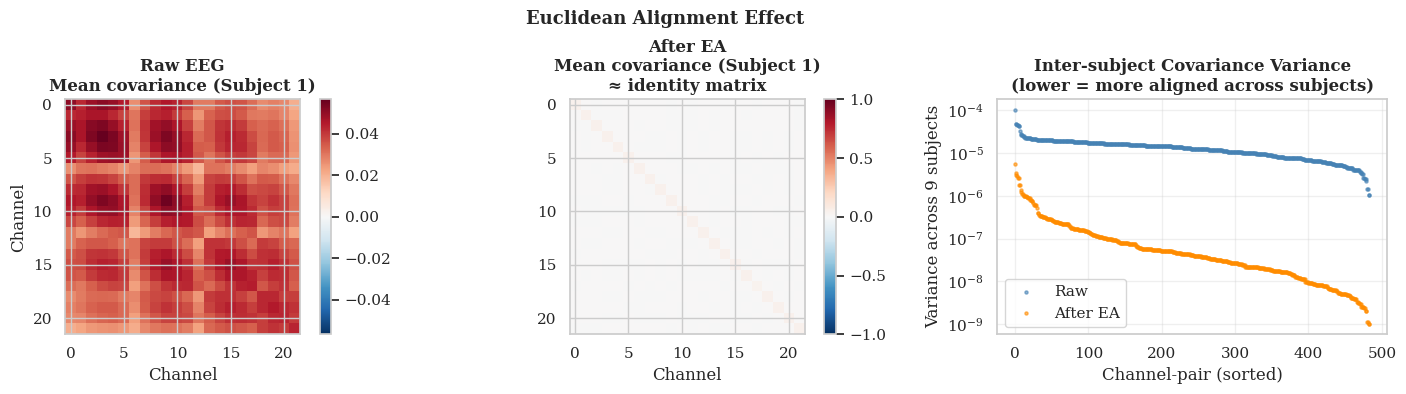


EEGNet shape: input [4, 22, 1000] → logits [4, 4]  feat [4, 496]
EEGNet defined. Shape check ✅
CenterLoss defined.
Training function defined.

── Diagnostic: compare no-EA vs EA on Subject 1 ──
    ep  50 [warmup]  CE=0.8590  Cen=0.0000  train=64.8%
    [ep 51] Centers initialised from training features
    ep 100 [center]  CE=0.8223  Cen=3.0179  train=67.5%
    ep 150 [center]  CE=0.7670  Cen=2.4439  train=69.9%
    ep 200 [center]  CE=0.7456  Cen=2.3116  train=70.9%
    ep 250 [center]  CE=0.7332  Cen=2.2683  train=71.6%
    ep 300 [center]  CE=0.7141  Cen=2.2705  train=71.9%

  EEGNet (no EA):  72.92%
    ep  50 [warmup]  CE=0.7354  Cen=0.0000  train=70.7%
    [ep 51] Centers initialised from training features
    ep 100 [center]  CE=0.7251  Cen=3.0474  train=71.5%
    ep 150 [center]  CE=0.6968  Cen=2.4305  train=72.9%
    ep 200 [center]  CE=0.6709  Cen=2.2215  train=73.7%
    ep 250 [center]  CE=0.6709  Cen=2.1732  train=73.5%
    ep 300 [center]  CE=0.6620  Cen=2.1472  train=74

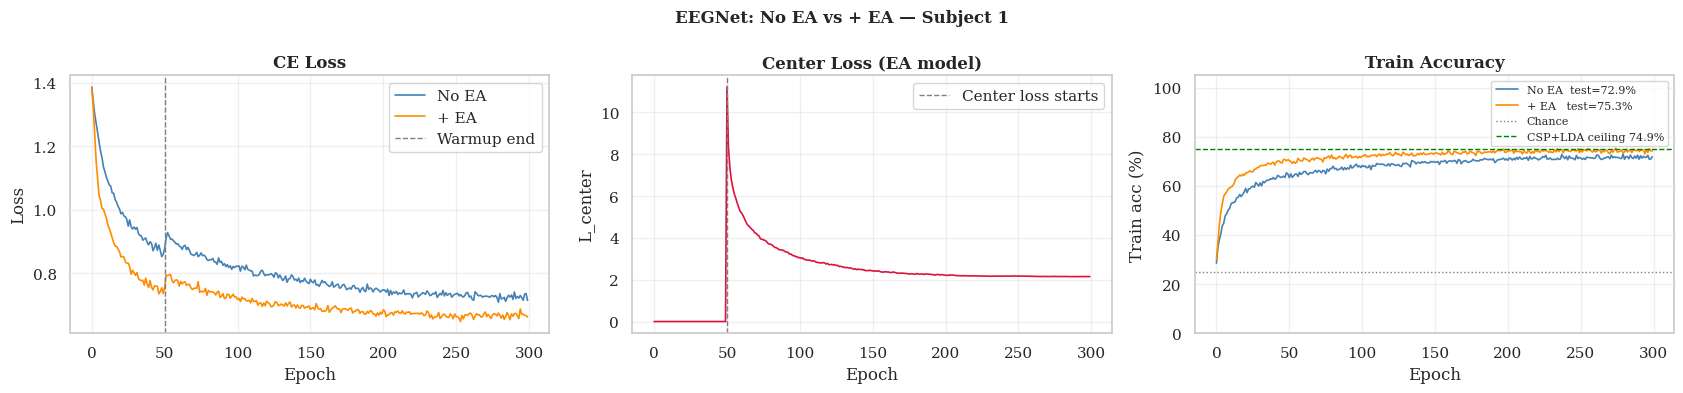


Running t-SNE on features (Subject 1 train)…


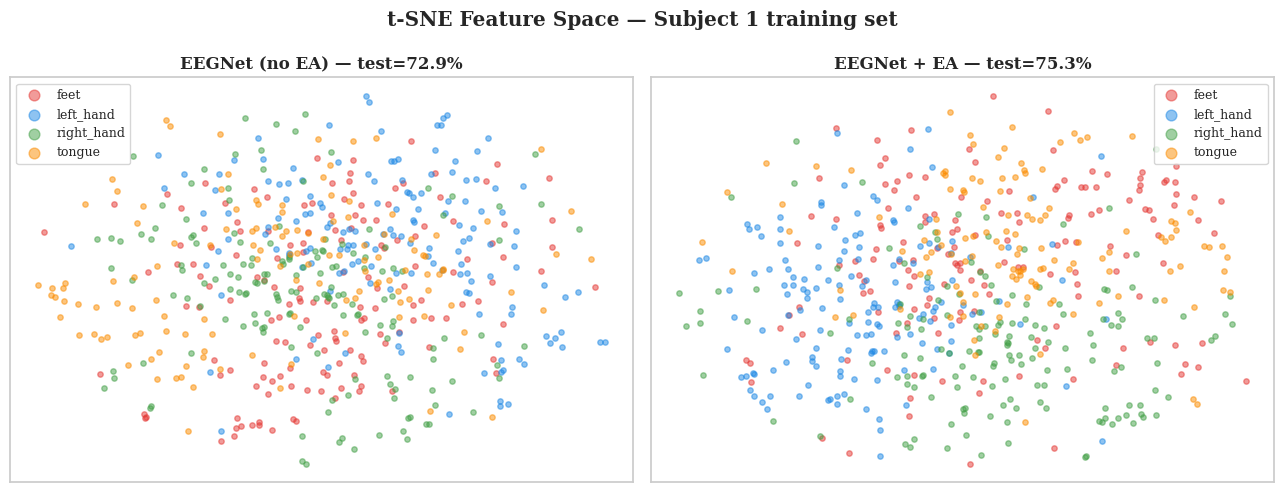


── Full LOSO: EEGNet + EA + CenterLoss (all 9 subjects) ──

  Subject 1…
  ✅ train=72.9%  test=70.49%  (69.0 min)

  Subject 2…
  ✅ train=78.1%  test=39.93%  (69.8 min)

  Subject 3…
  ✅ train=74.4%  test=70.14%  (69.9 min)

  Subject 4…
  ✅ train=75.5%  test=60.07%  (70.1 min)

  Subject 5…
  ✅ train=76.6%  test=46.53%  (69.7 min)

  Subject 6…
  ✅ train=75.5%  test=47.57%  (69.9 min)

  Subject 7…
  ✅ train=75.6%  test=69.10%  (69.0 min)

  Subject 8…
  ✅ train=75.1%  test=70.83%  (72.4 min)

  Subject 9…
  ✅ train=74.3%  test=58.33%  (70.4 min)

  M4 mean ± std : 59.22 ± 11.30%
  M3 CRNN mean  : 37.92%  (previous)
  Paper CRNN-DF : 63.52 ± 10.70%
  M2 CSP+LDA    : 74.88%  (ceiling)
  Total time    : 630.3 min


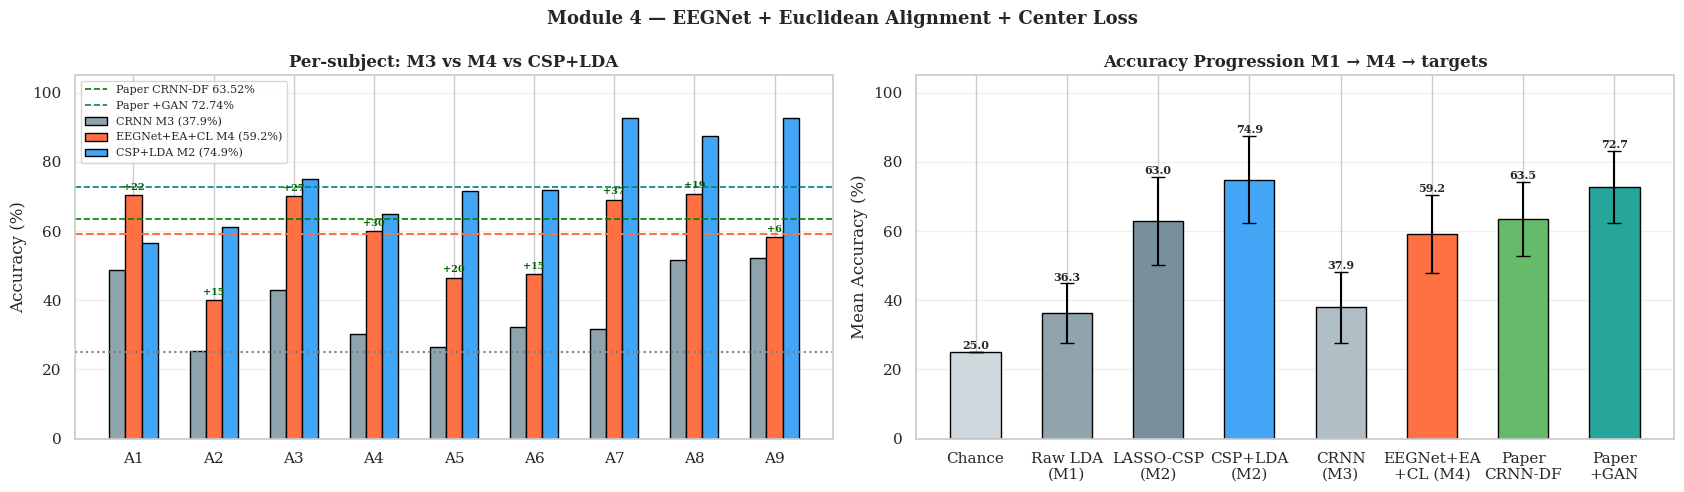

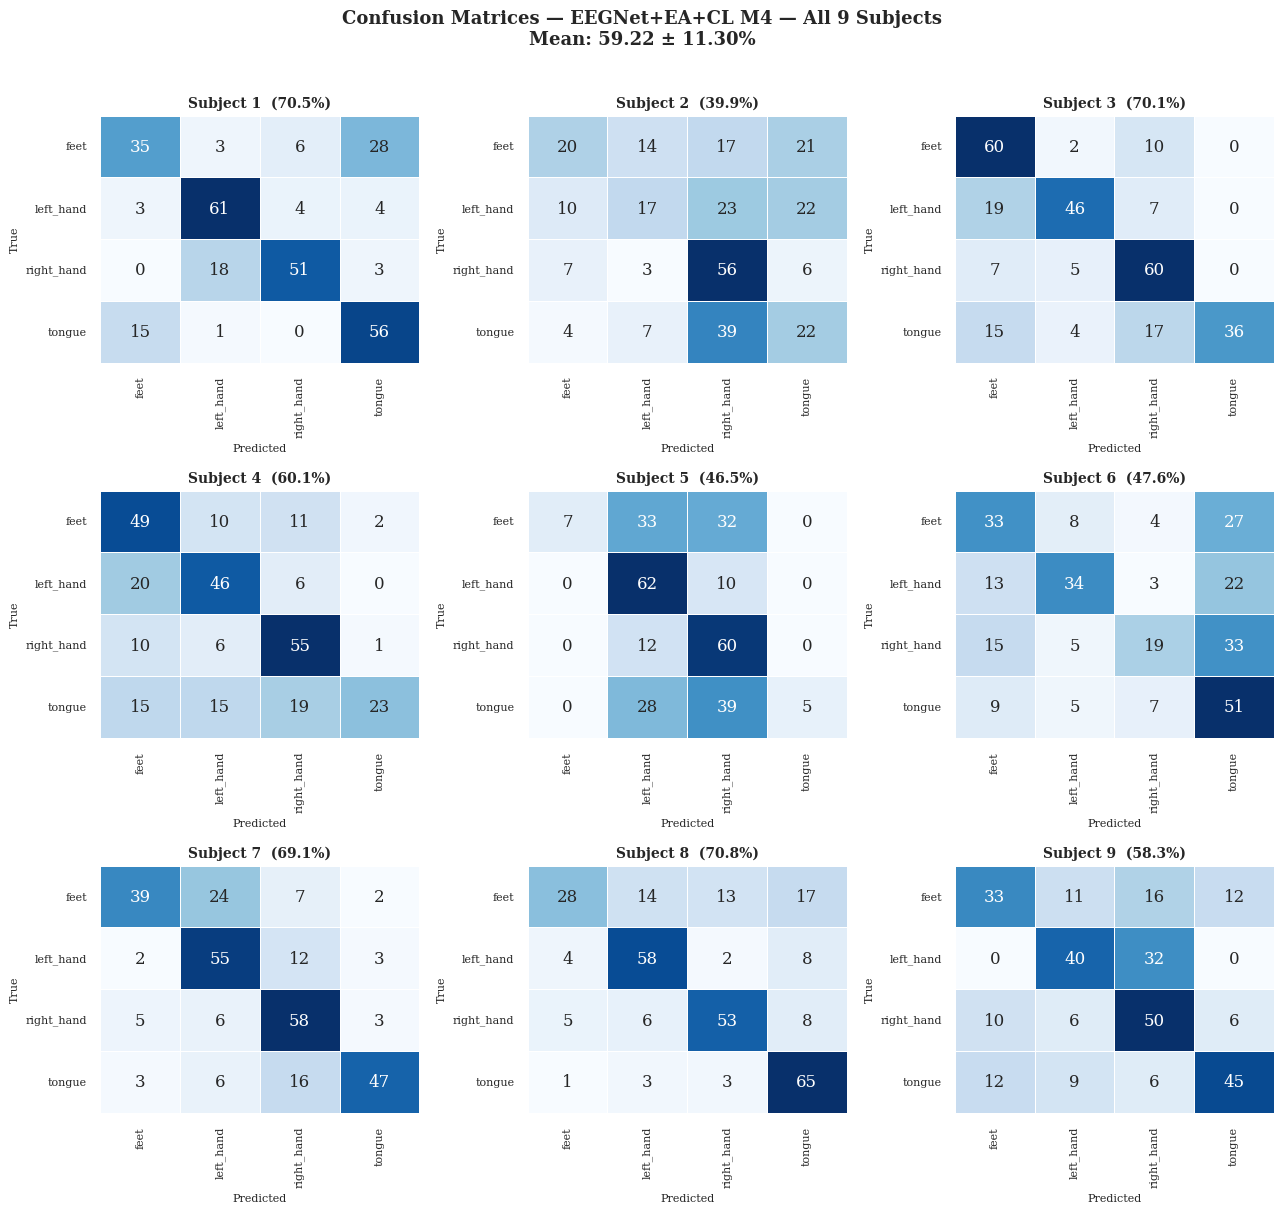

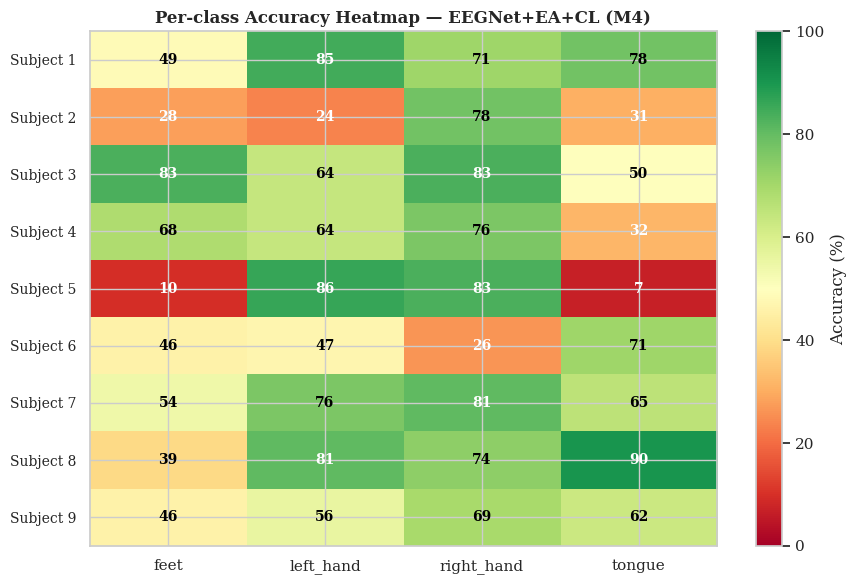


── Module 4 Summary ──────────────────────────────────
  M1 Raw LDA           : 36.27%
  M2 LASSO-CSP + LDA   : 62.96%
  M2 CSP + LDA         : 74.88%
  M3 CRNN (raw)        : 37.92%
  M4 EEGNet+EA+CL      : 59.22 ± 11.30%
  ─────────────────────────────────────────────────
  Paper CRNN-DF target : 63.52 ± 10.70%
  Paper + GAN target   : 72.74 ± 10.44%
  ─────────────────────────────────────────────────
  Gap to +GAN target   : +13.52%  (Module 5 GAN augmentation)

✅  MODULE 4 COMPLETE — eeg_bundle.pkl updated
    Next: Module 5 — FBGAN augmentation on calibration data


In [6]:
# ============================================================
# MODULE 4 — Architecture Fix + Euclidean Alignment + Center Loss
# ============================================================
# Why M3 failed at 37%:
#   Raw CRNN learns subject-specific EEG patterns, not class patterns.
#   With 8 training subjects → 1 test subject, it memorises WHO not WHAT.
#
# Two fixes:
#   1. Euclidean Alignment (EA) — removes subject-specific covariance,
#      aligns all subjects to same Riemannian space before training.
#      Typically +10–20% on cross-subject BCI tasks.
#   2. EEGNet architecture — depthwise separable convolutions explicitly
#      decouple spatial (subject-invariant) from temporal filters.
#      Published 2018, consistently beats vanilla CNN on cross-subject EEG.
#
#   Then: Center Loss (paper Sec. 2.7) on top of working backbone.
#
# Continuity:  loads  eeg_bundle.pkl  (M1–M3)
#              saves  eeg_bundle.pkl  (adds M4 results)
#
# Targets:
#   M3 CRNN (raw)     : 37.92%  ← must beat this
#   M2 CSP + LDA      : 74.88%  ← upper bound on this dataset
#   Paper CRNN-DF     : 63.52%  ← paper target
#   Paper + GAN       : 72.74%  ← final target (Module 5)
# ============================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings, time
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
import seaborn as sns
from scipy.linalg import sqrtm

# ── Device ───────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps');  print("Device: Apple MPS")
elif torch.cuda.is_available():
    device = torch.device('cuda'); print("Device: CUDA")
else:
    device = torch.device('cpu');  print("Device: CPU")
IS_MPS = (device.type == 'mps')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

# ── Load bundle ──────────────────────────────────────────────
with open('eeg_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

X_raw    = bundle['X_raw']
y        = bundle['y']
subjects = bundle['subjects']
sessions = bundle['sessions']
S0, S1   = bundle['S0'], bundle['S1']
CLASSES  = bundle['classes']
M3_CRNN  = bundle['crnn_mean']    # 37.92% — baseline to beat
M2_CSP   = bundle['csp_mean']     # 74.88% — upper bound
M2_LASSO = bundle['lasso_csp_mean']
M1_LDA   = bundle['lda_baseline_mean']

print(f"Bundle loaded.  X:{X_raw.shape}")
print(f"M3 CRNN (to beat): {M3_CRNN:.2f}%")
print(f"M2 CSP+LDA (ceiling): {M2_CSP:.2f}%")

# ─────────────────────────────────────────────────────────────
# SECTION 1 — Helpers
# ─────────────────────────────────────────────────────────────

def zscore_normalize(X_train, X_other):
    mu  = X_train.mean(axis=(0,2), keepdims=True)
    std = X_train.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_train-mu)/std, (X_other-mu)/std

def make_loader(X, y, batch_size=64, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=batch_size, shuffle=shuffle, drop_last=True)

def predict(model, X, batch_size=128):
    model.eval(); preds = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), batch_size):
            logits, _ = model(Xt[i:i+batch_size].to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
    return np.array(preds)

def get_features(model, X, batch_size=128):
    model.eval(); feats = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), batch_size):
            _, f = model(Xt[i:i+batch_size].to(device))
            feats.append(f.cpu().numpy())
    return np.vstack(feats)

# ─────────────────────────────────────────────────────────────
# SECTION 2 — Euclidean Alignment (EA)
#
# Reference: He & Wu, 2019, "Transfer Learning for BCI"
# Why it works:
#   Each subject's EEG has a unique covariance structure (their
#   "fingerprint"). EA whitens each subject's data so all subjects
#   share the same identity covariance. This removes WHO and
#   leaves only WHAT (the motor imagery class signal).
#
# Algorithm per subject:
#   1. Compute mean covariance R̄ = (1/N) Σ x_i x_i^T / ||x_i||_F
#   2. Apply R̄^(-1/2) to each trial: x̃_i = R̄^(-1/2) x_i
# ─────────────────────────────────────────────────────────────

def euclidean_alignment(X):
    """
    Apply Euclidean Alignment to a set of trials from ONE subject.
    X : (n_trials, n_ch, n_t)
    Returns X_aligned : same shape, covariance ≈ identity
    """
    # Normalised covariance per trial
    covs = []
    for trial in X:
        C = trial @ trial.T
        covs.append(C / (np.trace(C) + 1e-8))
    R_bar = np.mean(covs, axis=0)    # (n_ch, n_ch)

    # R̄^(-1/2) via eigendecomposition (more stable than sqrtm inverse)
    vals, vecs = np.linalg.eigh(R_bar)
    vals       = np.maximum(vals, 1e-10)          # numerical floor
    R_inv_sqrt = vecs @ np.diag(1.0/np.sqrt(vals)) @ vecs.T

    # Apply to each trial
    X_aligned = np.stack([R_inv_sqrt @ trial for trial in X])
    return X_aligned.astype(np.float32)


def apply_ea_loso(X_raw, subjects, sessions, test_subj, S1):
    """
    Apply EA per-subject on training set, then align test subject
    using its OWN covariance (from calibration session S0 if available,
    else from test trials — in practice we use all test-subject data).

    Returns: X_tr_ea, X_te_ea  (aligned, NOT yet z-scored)
    """
    m_tr = subjects != test_subj
    m_te = (subjects == test_subj) & (sessions == S1)

    # Align each training subject independently
    tr_subjs = sorted(np.unique(subjects[m_tr]))
    aligned_tr_parts = []
    for s in tr_subjs:
        m_s = m_tr & (subjects == s)
        aligned_tr_parts.append(euclidean_alignment(X_raw[m_s]))
    X_tr_ea = np.vstack(aligned_tr_parts)

    # Align test subject using its own calibration covariance
    m_te_subj_all = (subjects == test_subj)  # both sessions
    X_te_subj_all = euclidean_alignment(X_raw[m_te_subj_all])
    # Extract test session
    local_te_idx = np.where(
        (subjects == test_subj) & (sessions == S1)
    )[0] - np.where(m_te_subj_all)[0][0]
    X_te_ea = X_te_subj_all[local_te_idx]

    return X_tr_ea, X_te_ea, y[m_tr], y[m_te]


print("Euclidean Alignment defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 3 — Visualise: Effect of EA on covariance structure
# ─────────────────────────────────────────────────────────────

print("\nVisualising EA effect on Subject 1 covariance…")
m_s1 = subjects == '1'
X_s1_raw = X_raw[m_s1]
X_s1_ea  = euclidean_alignment(X_s1_raw)

# Mean covariance before and after
def mean_cov(X):
    covs = [t @ t.T / (np.trace(t @ t.T)+1e-8) for t in X]
    return np.mean(covs, axis=0)

cov_raw = mean_cov(X_s1_raw)
cov_ea  = mean_cov(X_s1_ea)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vmax = np.abs(cov_raw).max()

im0 = axes[0].imshow(cov_raw, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title('Raw EEG\nMean covariance (Subject 1)', fontweight='bold')
axes[0].set_xlabel('Channel'); axes[0].set_ylabel('Channel')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(cov_ea, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title('After EA\nMean covariance (Subject 1)\n≈ identity matrix',
                  fontweight='bold')
axes[1].set_xlabel('Channel')
plt.colorbar(im1, ax=axes[1])

# Visualise covariance spread across subjects (before vs after EA)
all_covs_raw = []
all_covs_ea  = []
for s in sorted(np.unique(subjects)):
    m = subjects == s
    all_covs_raw.append(mean_cov(X_raw[m]).flatten())
    all_covs_ea.append(mean_cov(euclidean_alignment(X_raw[m])).flatten())

all_covs_raw = np.array(all_covs_raw)  # (9, 22*22)
all_covs_ea  = np.array(all_covs_ea)

# Plot variance across subjects per channel-pair
var_raw = all_covs_raw.var(axis=0)
var_ea  = all_covs_ea.var(axis=0)
axes[2].scatter(range(len(var_raw)), np.sort(var_raw)[::-1],
                s=5, color='steelblue', alpha=0.6, label='Raw')
axes[2].scatter(range(len(var_ea)),  np.sort(var_ea)[::-1],
                s=5, color='darkorange', alpha=0.6, label='After EA')
axes[2].set_title('Inter-subject Covariance Variance\n'
                  '(lower = more aligned across subjects)',
                  fontweight='bold')
axes[2].set_xlabel('Channel-pair (sorted)')
axes[2].set_ylabel('Variance across 9 subjects')
axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_yscale('log')

plt.suptitle('Euclidean Alignment Effect', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 4 — EEGNet Architecture
#
# Lawhern et al. 2018: "EEGNet: A Compact Convolutional Neural
# Network for EEG-based Brain–Computer Interfaces"
#
# Why better than vanilla CRNN for cross-subject:
#  • Block 1: learns temporal filters, then DEPTHWISE spatial filters
#    (one per temporal filter). Depthwise = forced to learn universal
#    spatial patterns, not subject-specific ones.
#  • Block 2: separable conv (depthwise + pointwise) — efficient
#    feature mixing without overfitting.
#  • Much fewer parameters → less memorisation of subject identity.
# ─────────────────────────────────────────────────────────────

class EEGNet(nn.Module):
    """
    EEGNet for (n_ch, n_t) EEG input.

    Block 1 — Temporal + Depthwise Spatial:
      Conv2d(1, F1, (1, T//2))       temporal filter bank
      DepthwiseConv2d(F1, F1*D, (C,1))  spatial filter per temporal
      BN → ELU → AvgPool(1,4) → Dropout

    Block 2 — Separable Conv:
      DepthwiseConv2d(F1*D, F1*D, (1,16))  temporal mixing
      PointwiseConv2d(F1*D, F2, (1,1))      channel mixing
      BN → ELU → AvgPool(1,8) → Dropout

    Flatten → Linear(F2 * T//32, n_cls)
    """
    def __init__(self, n_ch=22, n_t=1000, n_cls=4,
                 F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()
        self.feature_dim = F2 * (n_t // 32)

        # ── Block 1 ───────────────────────────────────────────
        self.block1 = nn.Sequential(
            # Temporal conv: (1, T//2) filter, same padding on time axis
            nn.Conv2d(1, F1, (1, n_t//2),
                      padding=(0, n_t//4), bias=False),
            nn.BatchNorm2d(F1),
            # Depthwise spatial: one filter per F1 channel, across all EEG ch
            nn.Conv2d(F1, F1*D, (n_ch, 1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(inplace=True),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )

        # ── Block 2 ───────────────────────────────────────────
        self.block2 = nn.Sequential(
            # Depthwise temporal
            nn.Conv2d(F1*D, F1*D, (1, 16),
                      padding=(0, 8), groups=F1*D, bias=False),
            # Pointwise channel mix
            nn.Conv2d(F1*D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(inplace=True),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )

        # ── Classifier ────────────────────────────────────────
        self.fc = nn.Linear(self.feature_dim, n_cls)

    def forward(self, x):              # x: (B, C, T)
        x    = x.unsqueeze(1)          # (B, 1, C, T)
        x    = self.block1(x)          # (B, F1*D, 1, T//4)
        x    = self.block2(x)          # (B, F2,   1, T//32)
        feat = x.flatten(1)            # (B, F2 * T//32)
        return self.fc(feat), feat

# ── Shape check ──────────────────────────────────────────────
_m = EEGNet(n_ch=22, n_t=1000).to(device)
_x = torch.randn(4, 22, 1000).to(device)
_l, _f = _m(_x)
print(f"\nEEGNet shape: input {list(_x.shape)} → "
      f"logits {list(_l.shape)}  feat {list(_f.shape)}")
assert _l.shape == (4, 4)
del _m, _x, _l, _f
print("EEGNet defined. Shape check ✅")

# ─────────────────────────────────────────────────────────────
# SECTION 5 — Center Loss (correct EMA implementation)
#
# Paper Sec. 2.7, Eq. 7-8:
#   L_cen = (1/b) Σ_i ||f_i - c_{y_i}||_2
#   Centers updated by closed-form EMA — NOT by SGD optimizer.
# ─────────────────────────────────────────────────────────────

class CenterLoss(nn.Module):
    def __init__(self, n_cls=4, feat_dim=None, lr_c=0.5):
        super().__init__()
        assert feat_dim is not None, "Must pass feat_dim"
        self.n_cls = n_cls
        self.lr_c  = lr_c
        self.register_buffer('centers', torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_from_data(self, model, X, y, bs=128):
        """Eq. 8: initialise centers = per-class mean feature."""
        model.eval()
        all_f, all_l = [], []
        Xt = torch.FloatTensor(X); yt = torch.LongTensor(y)
        for i in range(0, len(Xt), bs):
            _, f = model(Xt[i:i+bs].to(device))
            all_f.append(f.detach().cpu()); all_l.append(yt[i:i+bs])
        F = torch.cat(all_f); L = torch.cat(all_l)
        for c in range(self.n_cls):
            m = (L == c)
            if m.sum() > 0:
                self.centers[c] = F[m].mean(0).to(self.centers.device)
        model.train()

    @torch.no_grad()
    def update_centers(self, feats, labels):
        """Wen et al. 2016 Eq. 4: closed-form EMA, no optimizer."""
        feats  = feats.detach(); labels = labels.detach()
        for c in range(self.n_cls):
            mask = (labels == c)
            if mask.sum() == 0: continue
            diff = self.centers[c] - feats[mask].mean(0)
            self.centers[c] -= self.lr_c * diff / (mask.sum().float() + 1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        """Push centers away from global mean (paper Sec. 2.7)."""
        gc = self.centers.mean(0, keepdim=True)
        d  = self.centers - gc
        self.centers.add_(alpha * d / (d.norm(dim=1, keepdim=True) + 1e-8))

    def forward(self, feats, labels):
        """Gradients flow to network only (centers detached)."""
        c = self.centers[labels].detach()
        return torch.mean(torch.norm(feats - c, dim=1))

print("CenterLoss defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 6 — Unified Training Function
# ─────────────────────────────────────────────────────────────

def train_eegnet(X_tr, y_tr,
                 n_epochs   = 300,
                 lr         = 1e-3,
                 batch_size = 64,
                 lam        = 0.05,
                 warmup     = 50,
                 verbose    = False):
    """
    Train EEGNet + CenterLoss.

    Phases:
      Epochs 1..warmup   : CE only (network stabilises)
      Epoch  warmup+1    : init centers from stable features
      Epochs warmup+1..N : CE + λ * CenterLoss (EMA center update)
      Every 30 epochs    : inter-class center expansion

    Returns: model, history dict
    """
    n_ch, n_t  = X_tr.shape[1], X_tr.shape[2]
    model      = EEGNet(n_ch=n_ch, n_t=n_t).to(device)
    feat_dim   = model.feature_dim
    closs      = CenterLoss(n_cls=4, feat_dim=feat_dim).to(device)

    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=n_epochs, eta_min=1e-6)
    ce    = nn.CrossEntropyLoss()
    loader= make_loader(X_tr, y_tr, batch_size)

    hist = {'loss': [], 'ce': [], 'cen': [], 'train_acc': []}

    for ep in range(1, n_epochs + 1):
        # Initialise centers right after warmup
        if ep == warmup + 1:
            closs.init_from_data(model, X_tr, y_tr)
            if verbose:
                print(f"    [ep {ep}] Centers initialised from training features")

        use_cl = (ep > warmup)
        model.train()
        tot_ce, tot_cen, cor, tot_n = 0.0, 0.0, 0, 0

        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, feats = model(Xb)
            l_ce  = ce(logits, yb)
            if use_cl:
                l_cen = closs(feats, yb)
                loss  = l_ce + lam * l_cen
                closs.update_centers(feats, yb)
            else:
                l_cen = torch.tensor(0.0)
                loss  = l_ce
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tot_ce  += l_ce.item()
            tot_cen += l_cen.item()
            cor     += (logits.argmax(1)==yb).sum().item()
            tot_n   += yb.size(0)

        sched.step()
        if use_cl and ep % 30 == 0:
            closs.expand_inter_class(alpha=0.02)

        hist['ce'].append(tot_ce / len(loader))
        hist['cen'].append(tot_cen / len(loader))
        hist['loss'].append(hist['ce'][-1] +
                            lam * hist['cen'][-1])
        hist['train_acc'].append(100 * cor / tot_n)

        if verbose and ep % 50 == 0:
            phase = 'center' if use_cl else 'warmup'
            print(f"    ep {ep:3d} [{phase}]  "
                  f"CE={hist['ce'][-1]:.4f}  "
                  f"Cen={hist['cen'][-1]:.4f}  "
                  f"train={hist['train_acc'][-1]:.1f}%")

    return model, closs, hist

print("Training function defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 7 — Diagnostic: EA effect on single fold (Subject 1)
# ─────────────────────────────────────────────────────────────

print("\n── Diagnostic: compare no-EA vs EA on Subject 1 ──")
TEST_SUBJ = '1'

# ── Without EA ────────────────────────────────────────────────
m_tr = subjects != TEST_SUBJ
m_te = (subjects == TEST_SUBJ) & (sessions == S1)
X_tr_z, X_te_z = zscore_normalize(X_raw[m_tr], X_raw[m_te])
y_tr = y[m_tr]; y_te = y[m_te]

model_nea, _, hist_nea = train_eegnet(
    X_tr_z, y_tr, n_epochs=300, verbose=True)
acc_nea = accuracy_score(y_te, predict(model_nea, X_te_z)) * 100
print(f"\n  EEGNet (no EA):  {acc_nea:.2f}%")

# ── With EA ───────────────────────────────────────────────────
X_tr_ea, X_te_ea, y_tr_ea, y_te_ea = apply_ea_loso(
    X_raw, subjects, sessions, TEST_SUBJ, S1)
X_tr_ea, X_te_ea = zscore_normalize(X_tr_ea, X_te_ea)

model_ea, _, hist_ea = train_eegnet(
    X_tr_ea, y_tr_ea, n_epochs=300, verbose=True)
acc_ea = accuracy_score(y_te_ea, predict(model_ea, X_te_ea)) * 100
print(f"  EEGNet + EA   :  {acc_ea:.2f}%")
print(f"  M3 CRNN (raw) :  {M3_CRNN:.2f}%  (previous best)")
print(f"  EA improvement:  {acc_ea - acc_nea:+.2f}%")

# ─────────────────────────────────────────────────────────────
# SECTION 8 — Visualisation A: Training dynamics comparison
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# CE loss comparison
axes[0].plot(hist_nea['ce'], color='steelblue',  lw=1.2, label='No EA')
axes[0].plot(hist_ea['ce'],  color='darkorange', lw=1.2, label='+ EA')
axes[0].axvline(50, color='gray', ls='--', lw=1, label='Warmup end')
axes[0].set_title('CE Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Center loss (EA model only)
axes[1].plot(hist_ea['cen'], color='crimson', lw=1.2)
axes[1].axvline(50, color='gray', ls='--', lw=1, label='Center loss starts')
axes[1].set_title('Center Loss (EA model)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('L_center')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Train accuracy
axes[2].plot(hist_nea['train_acc'], color='steelblue',  lw=1.2,
             label=f'No EA  test={acc_nea:.1f}%')
axes[2].plot(hist_ea['train_acc'],  color='darkorange', lw=1.2,
             label=f'+ EA   test={acc_ea:.1f}%')
axes[2].axhline(25,      color='gray',  ls=':',  lw=1, label='Chance')
axes[2].axhline(M2_CSP,  color='green', ls='--', lw=1,
                label=f'CSP+LDA ceiling {M2_CSP:.1f}%')
axes[2].set_title('Train Accuracy', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Train acc (%)')
axes[2].set_ylim(0, 105); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle('EEGNet: No EA vs + EA — Subject 1',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 9 — Visualisation B: Feature space t-SNE
#             No EA vs EA — do classes cluster better?
# ─────────────────────────────────────────────────────────────

print("\nRunning t-SNE on features (Subject 1 train)…")
n_viz  = min(600, len(X_tr_z))
idx_v  = np.random.choice(len(X_tr_z), n_viz, replace=False)
y_viz  = y_tr[idx_v]
colors = ['#E53935','#1E88E5','#43A047','#FB8C00']

F_nea = get_features(model_nea, X_tr_z[idx_v])
F_ea  = get_features(model_ea,  X_tr_ea[idx_v])

tsne1 = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
F2_nea = tsne1.fit_transform(F_nea)
tsne2 = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
F2_ea  = tsne2.fit_transform(F_ea)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for cls in range(4):
    m = y_viz == cls
    axes[0].scatter(F2_nea[m,0], F2_nea[m,1],
                    c=colors[cls], alpha=0.5, s=15, label=CLASSES[cls])
    axes[1].scatter(F2_ea[m,0],  F2_ea[m,1],
                    c=colors[cls], alpha=0.5, s=15, label=CLASSES[cls])

axes[0].set_title(f'EEGNet (no EA) — test={acc_nea:.1f}%',
                  fontweight='bold')
axes[1].set_title(f'EEGNet + EA — test={acc_ea:.1f}%',
                  fontweight='bold')
for ax in axes:
    ax.legend(markerscale=2, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(alpha=0.2)

plt.suptitle('t-SNE Feature Space — Subject 1 training set',
             fontweight='bold')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 10 — Full LOSO (all 9 subjects, EA + EEGNet + CL)
# ─────────────────────────────────────────────────────────────

print("\n── Full LOSO: EEGNet + EA + CenterLoss (all 9 subjects) ──")

results_m4 = {}
all_preds  = {}
all_true   = {}
t0 = time.time()

for subj in sorted(np.unique(subjects)):
    ts = time.time()
    print(f"\n  Subject {subj}…")

    # EA alignment (per training subject independently)
    X_tr_s, X_te_s, y_tr_s, y_te_s = apply_ea_loso(
        X_raw, subjects, sessions, subj, S1)
    X_tr_s, X_te_s = zscore_normalize(X_tr_s, X_te_s)

    model_s, _, hist_s = train_eegnet(
        X_tr_s, y_tr_s, n_epochs=300, verbose=False)

    final_tr  = hist_s['train_acc'][-1]
    preds_s   = predict(model_s, X_te_s)
    acc_s     = accuracy_score(y_te_s, preds_s) * 100

    results_m4[subj] = acc_s
    all_preds[subj]  = preds_s
    all_true[subj]   = y_te_s

    elapsed = time.time() - ts
    flag = "⚠️ " if final_tr < 60 else "✅"
    print(f"  {flag} train={final_tr:.1f}%  test={acc_s:.2f}%  "
          f"({elapsed/60:.1f} min)")

m4_vals = list(results_m4.values())
m4_mean = np.mean(m4_vals)
m4_std  = np.std(m4_vals)
total_min = (time.time()-t0)/60

print(f"\n  M4 mean ± std : {m4_mean:.2f} ± {m4_std:.2f}%")
print(f"  M3 CRNN mean  : {M3_CRNN:.2f}%  (previous)")
print(f"  Paper CRNN-DF : 63.52 ± 10.70%")
print(f"  M2 CSP+LDA    : {M2_CSP:.2f}%  (ceiling)")
print(f"  Total time    : {total_min:.1f} min")

# ─────────────────────────────────────────────────────────────
# SECTION 11 — Visualisation C: Full Results
# ─────────────────────────────────────────────────────────────

subj_list   = sorted(np.unique(subjects))
m4_list     = [results_m4[s]                           for s in subj_list]
m3_list     = [bundle['results_m3'][s]                 for s in subj_list]
csp_list    = [bundle['results_m2']['csp_lda'][s]      for s in subj_list]
lasso_list  = [bundle['results_m2']['lasso_csp'][s]    for s in subj_list]

x = np.arange(len(subj_list)); w = 0.2

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Per-subject bars: M3 vs M4 vs CSP
axes[0].bar(x-w,   m3_list,  w, label=f'CRNN M3 ({M3_CRNN:.1f}%)',
            color='#90A4AE', edgecolor='k')
axes[0].bar(x,     m4_list,  w, label=f'EEGNet+EA+CL M4 ({m4_mean:.1f}%)',
            color='#FF7043', edgecolor='k')
axes[0].bar(x+w,   csp_list, w, label=f'CSP+LDA M2 ({M2_CSP:.1f}%)',
            color='#42A5F5', edgecolor='k')
axes[0].axhline(25,     color='gray',  ls=':', lw=1.5)
axes[0].axhline(m4_mean,color='#FF7043',ls='--',lw=1.5)
axes[0].axhline(63.52,  color='green', ls='--',lw=1.2,
                label='Paper CRNN-DF 63.52%')
axes[0].axhline(72.74,  color='teal',  ls='--',lw=1.2,
                label='Paper +GAN 72.74%')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'A{s}' for s in subj_list])
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 105)
axes[0].set_title('Per-subject: M3 vs M4 vs CSP+LDA', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)
# Delta from M3 to M4
for i, (m4, m3) in enumerate(zip(m4_list, m3_list)):
    d = m4 - m3
    axes[0].text(i, max(m4,m3)+1.5, f'{d:+.0f}',
                 ha='center', fontsize=7,
                 color='darkgreen' if d>=0 else 'crimson',
                 fontweight='bold')

# Progression
methods = ['Chance','Raw LDA\n(M1)','LASSO-CSP\n(M2)','CSP+LDA\n(M2)',
           'CRNN\n(M3)','EEGNet+EA\n+CL (M4)','Paper\nCRNN-DF','Paper\n+GAN']
means   = [25, M1_LDA, M2_LASSO, M2_CSP, M3_CRNN, m4_mean, 63.52, 72.74]
stds    = [0,  8.59, np.std(lasso_list), np.std(csp_list),
           bundle['crnn_std'], m4_std, 10.70, 10.44]
colors  = ['#CFD8DC','#90A4AE','#78909C','#42A5F5',
           '#B0BEC5','#FF7043','#66BB6A','#26A69A']

bars = axes[1].bar(methods, means, yerr=stds, color=colors,
                   edgecolor='k', capsize=5, width=0.55)
axes[1].set_ylim(0, 105)
axes[1].set_ylabel('Mean Accuracy (%)')
axes[1].set_title('Accuracy Progression M1 → M4 → targets',
                  fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+s+0.8,
                 f'{m:.1f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Module 4 — EEGNet + Euclidean Alignment + Center Loss',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 12 — 9 Confusion Matrices
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for idx, subj in enumerate(subj_list):
    ax = axes[idx//3][idx%3]
    cm = confusion_matrix(all_true[subj], all_preds[subj])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, cbar=False)
    ax.set_title(f"Subject {subj}  ({results_m4[subj]:.1f}%)",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Confusion Matrices — EEGNet+EA+CL M4 — All 9 Subjects\n'
             f'Mean: {m4_mean:.2f} ± {m4_std:.2f}%',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 13 — Per-class accuracy heatmap
# ─────────────────────────────────────────────────────────────

per_class = np.zeros((len(subj_list), 4))
for i, subj in enumerate(subj_list):
    for cls in range(4):
        m = all_true[subj] == cls
        if m.sum() > 0:
            per_class[i, cls] = (all_preds[subj][m]==cls).mean()*100

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(per_class, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(CLASSES, fontsize=11)
ax.set_yticks(range(len(subj_list)))
ax.set_yticklabels([f'Subject {s}' for s in subj_list], fontsize=10)
ax.set_title('Per-class Accuracy Heatmap — EEGNet+EA+CL (M4)',
             fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='Accuracy (%)')
for i in range(len(subj_list)):
    for j in range(4):
        v = per_class[i,j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if v<35 or v>80 else 'black')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 14 — Save & Summary
# ─────────────────────────────────────────────────────────────

bundle['m4_mean']    = m4_mean
bundle['m4_std']     = m4_std
bundle['results_m4'] = results_m4

with open('eeg_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("\n── Module 4 Summary ──────────────────────────────────")
print(f"  M1 Raw LDA           : {M1_LDA:.2f}%")
print(f"  M2 LASSO-CSP + LDA   : {M2_LASSO:.2f}%")
print(f"  M2 CSP + LDA         : {M2_CSP:.2f}%")
print(f"  M3 CRNN (raw)        : {M3_CRNN:.2f}%")
print(f"  M4 EEGNet+EA+CL      : {m4_mean:.2f} ± {m4_std:.2f}%")
print(f"  ─────────────────────────────────────────────────")
print(f"  Paper CRNN-DF target : 63.52 ± 10.70%")
print(f"  Paper + GAN target   : 72.74 ± 10.44%")
print(f"  ─────────────────────────────────────────────────")
gap = 72.74 - m4_mean
print(f"  Gap to +GAN target   : {gap:+.2f}%  (Module 5 GAN augmentation)")
print(f"\n✅  MODULE 4 COMPLETE — eeg_bundle.pkl updated")
print("    Next: Module 5 — FBGAN augmentation on calibration data")


Device: Apple MPS
Bundle loaded.  X:(5184, 22, 1000)
M4 (to beat): 59.22%  |  Paper +GAN target: 72.74%
Helpers defined.
EEGNet + CenterLoss defined. ✅
FBGAN architecture (with spectral norm) defined. ✅
FBGAN training functions defined. ✅

── GAN sanity check (Subject 1, class 0 only, 50 epochs) ──
  Training 50 epochs on class 0 (72 trials)…


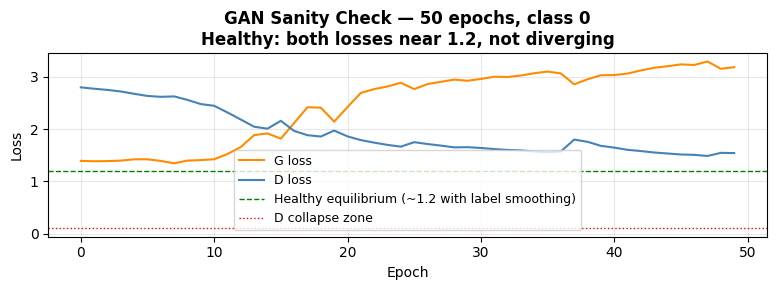

  Final G=3.187  D=1.542
  ✅ GAN is balanced — proceeding to full training

── Subject 1: Full FBGAN (200 epochs × 4 classes) ──
    class 0 (feet): 72 real → 750 fake… 118s  G=4.085 D=1.316 ✅
    class 1 (left_hand): 72 real → 750 fake… 144s  G=4.073 D=1.312 ✅
    class 2 (right_hand): 72 real → 750 fake… 148s  G=4.072 D=1.321 ✅
    class 3 (tongue): 72 real → 750 fake… 156s  G=4.105 D=1.311 ✅

Generated: (3000, 22, 1000)  labels: [750 750 750 750]


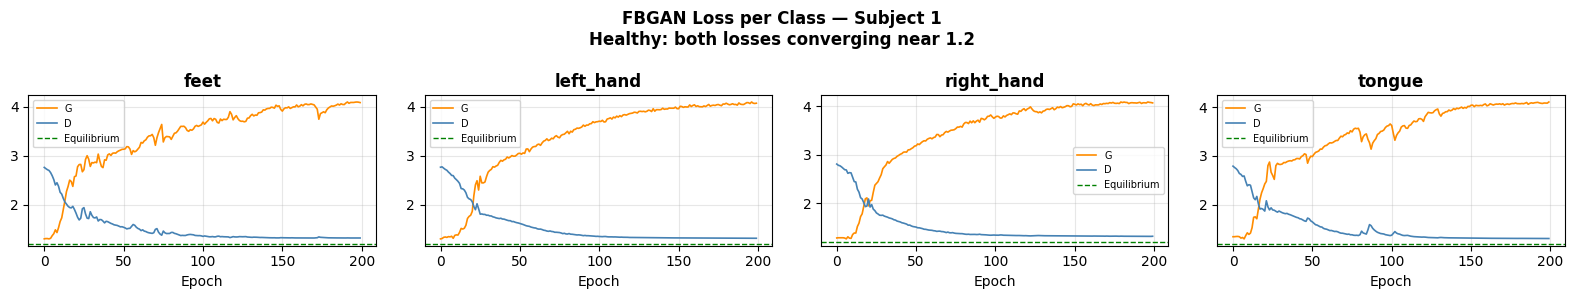

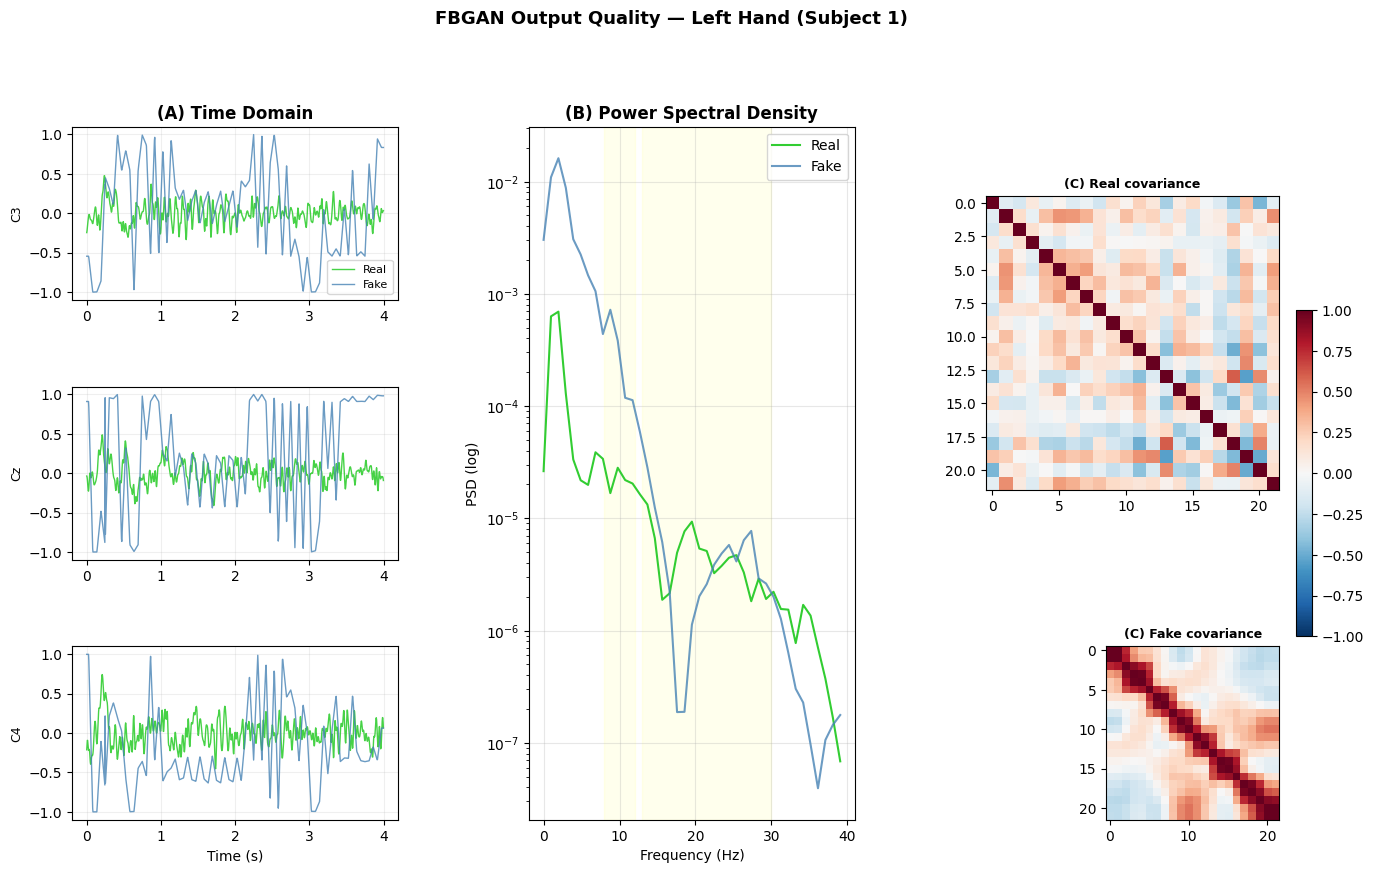

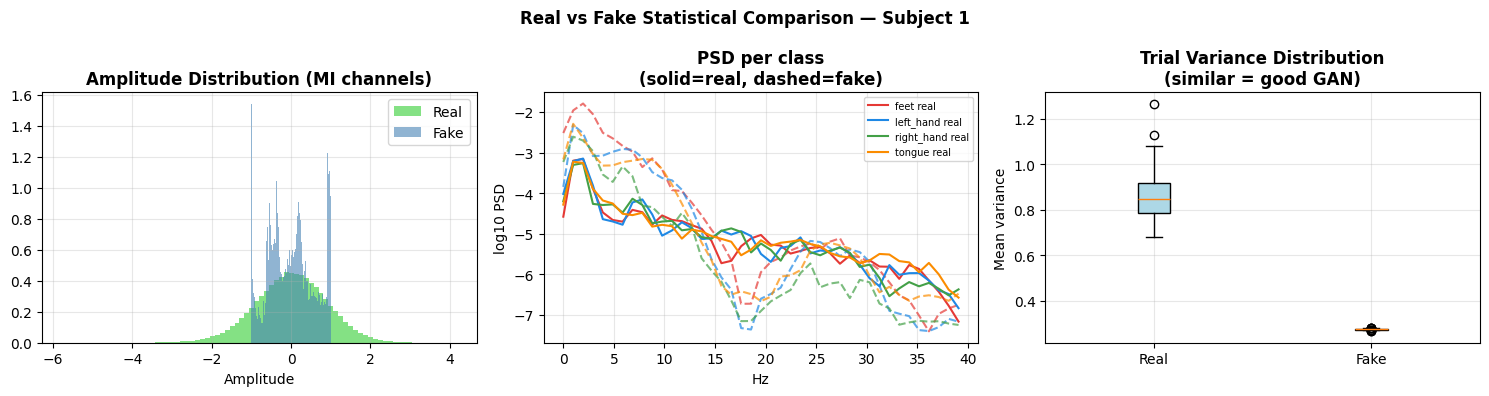


── Subject 1: no augmentation vs +FBGAN ──
  Training EEGNet+EA+CL (no aug)…
    ep  50 [warmup]  CE=0.7619  train=69.3%
    ep 100 [center]  CE=0.7308  train=71.4%
    ep 150 [center]  CE=0.7053  train=72.5%
    ep 200 [center]  CE=0.6789  train=73.8%
    ep 250 [center]  CE=0.6638  train=74.4%
    ep 300 [center]  CE=0.6563  train=74.4%
  No aug: 70.49%

  Training EEGNet+EA+CL+GAN…
  Aug set: 7608 total  (4608 real + 3000 fake)
    ep  50 [warmup]  CE=0.4787  train=80.6%
    ep 100 [center]  CE=0.4769  train=81.6%
    ep 150 [center]  CE=0.4622  train=82.1%
    ep 200 [center]  CE=0.4507  train=82.5%
    ep 250 [center]  CE=0.4393  train=83.0%
    ep 300 [center]  CE=0.4462  train=82.9%
  +GAN  : 70.14%  (Δ=-0.35%)


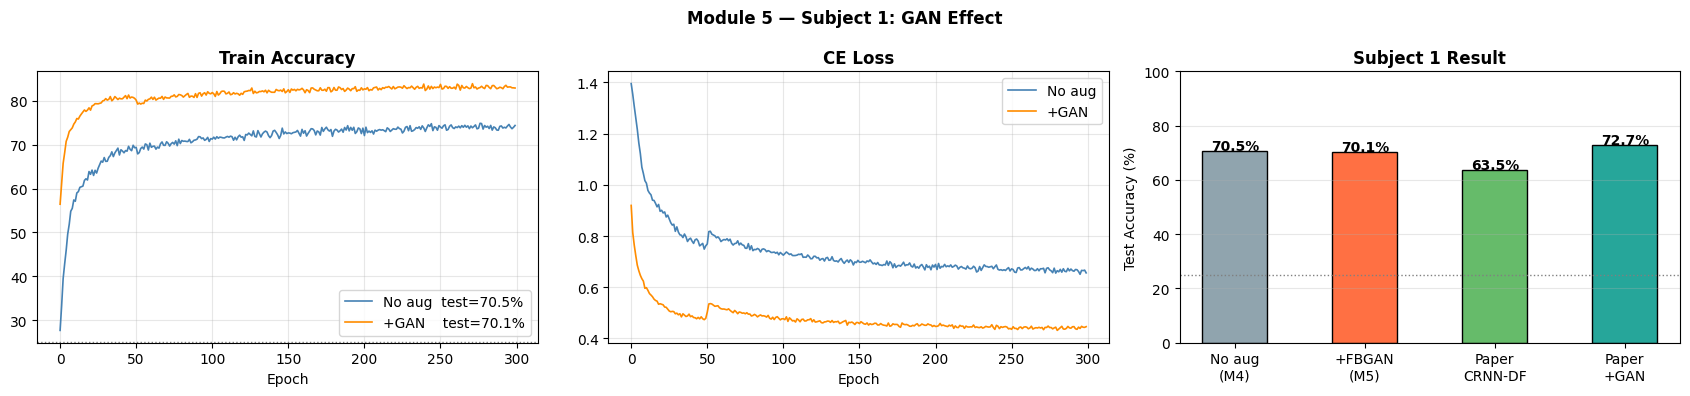


── Full LOSO: EEGNet + EA + CL + FBGAN ──

  ══ Subject 1 ══
    class 0 (feet): 72 real → 750 fake… 220s  G=4.075 D=1.311 ✅
    class 1 (left_hand): 72 real → 750 fake… 221s  G=4.048 D=1.312 ✅
    class 2 (right_hand): 72 real → 750 fake… 220s  G=4.078 D=1.315 ✅
    class 3 (tongue): 72 real → 750 fake… 223s  G=4.069 D=1.314 ✅
    no-aug=61.5%  +GAN=75.69%  Δ=+14.2%  (305.8 min)

  ══ Subject 2 ══
    class 0 (feet): 72 real → 750 fake… 192s  G=4.048 D=1.319 ✅
    class 1 (left_hand): 72 real → 750 fake… 195s  G=4.051 D=1.322 ✅
    class 2 (right_hand): 72 real → 750 fake… 185s  G=4.049 D=1.318 ✅
    class 3 (tongue): 72 real → 750 fake… 182s  G=4.080 D=1.315 ✅
    no-aug=44.8%  +GAN=44.79%  Δ=+0.0%  (271.2 min)

  ══ Subject 3 ══
    class 0 (feet): 72 real → 750 fake… 201s  G=3.954 D=1.320 ✅
    class 1 (left_hand): 72 real → 750 fake… 196s  G=3.760 D=1.341 ✅
    class 2 (right_hand): 72 real → 750 fake… 202s  G=4.071 D=1.313 ✅
    class 3 (tongue): 72 real → 750 fake… 197s  G=4.08

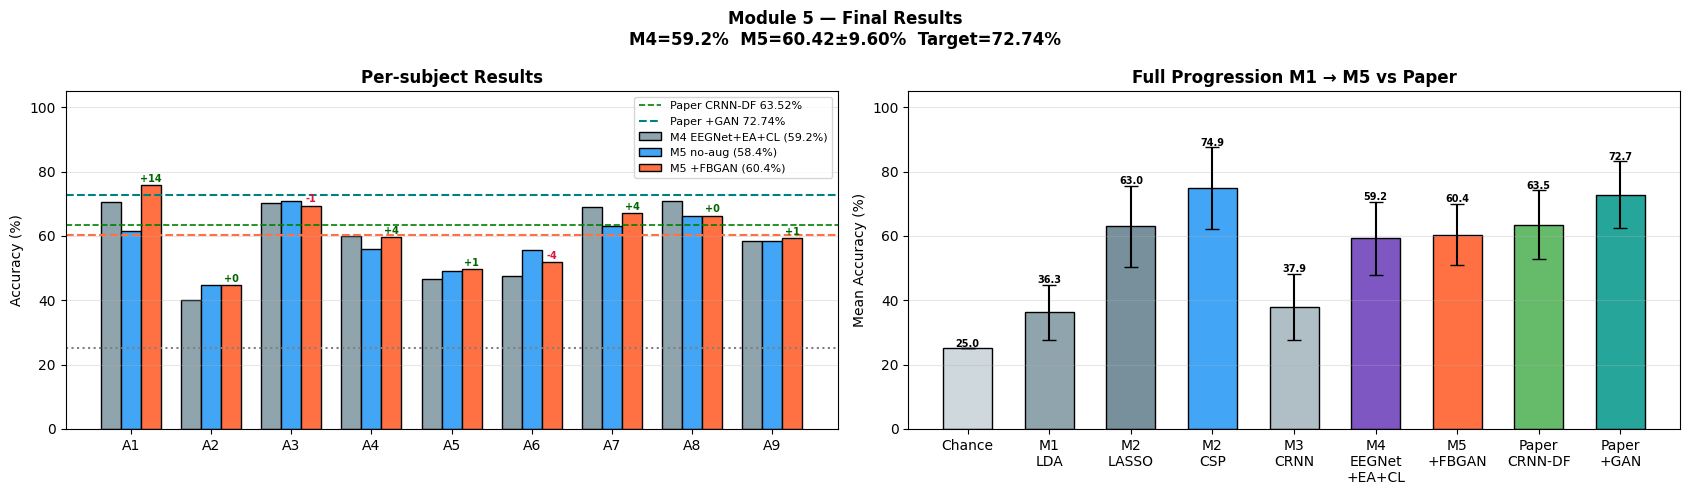

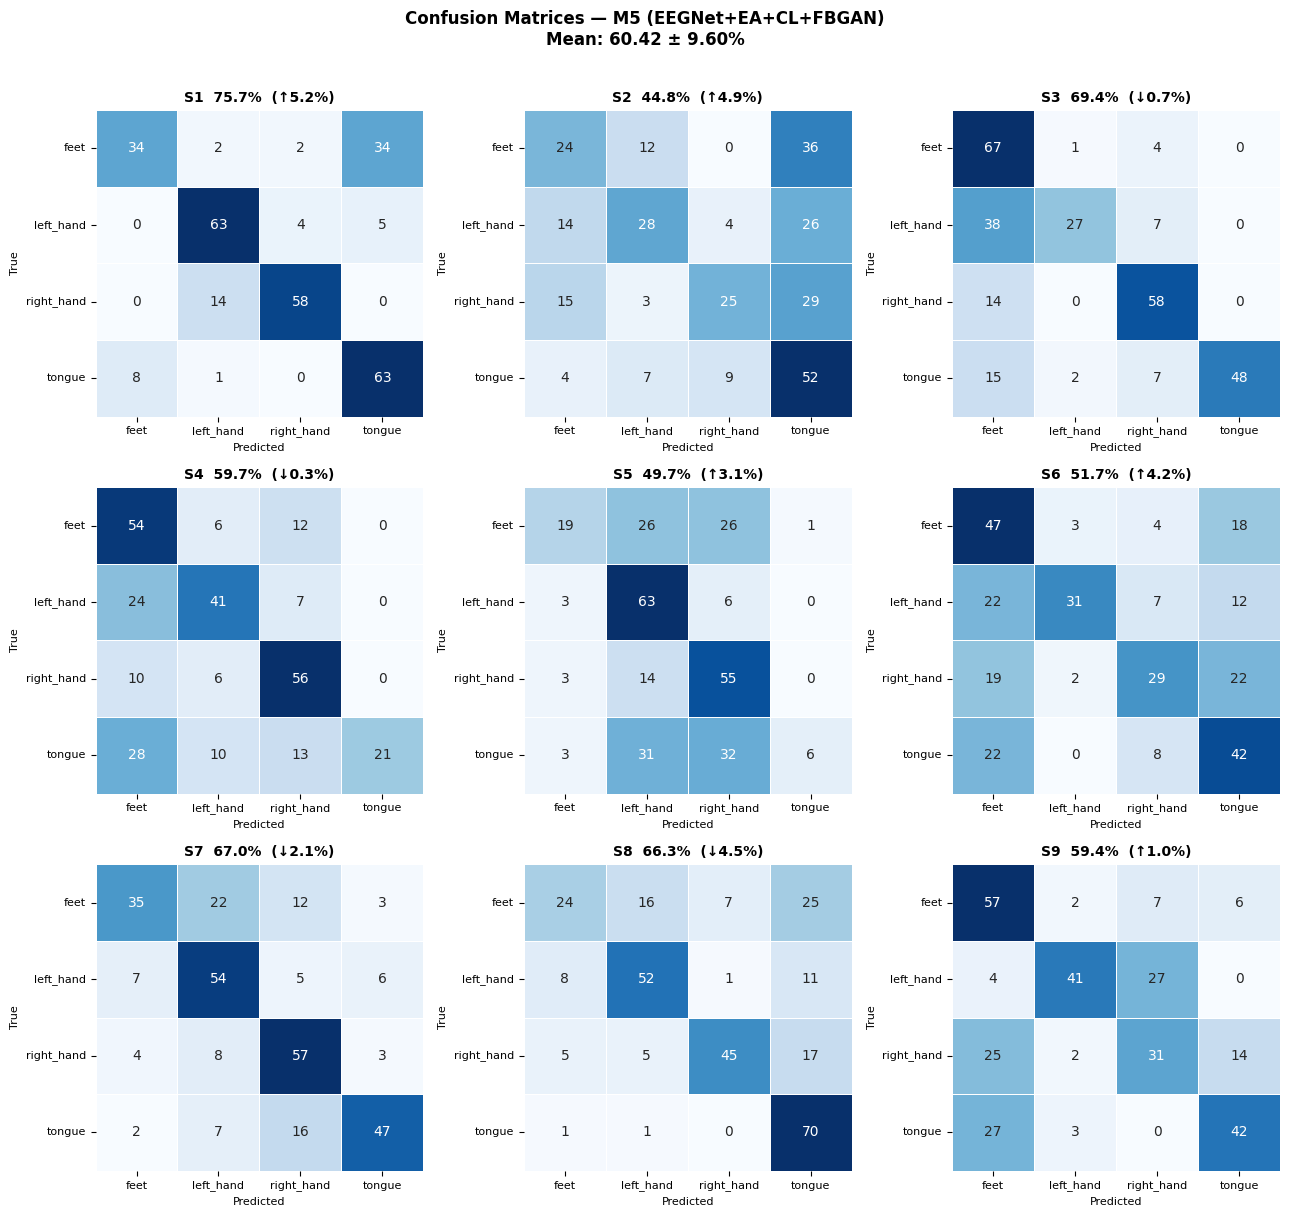


── Module 5 Summary ──────────────────────────────────
  M1 Raw LDA                : 36.27%
  M2 LASSO-CSP + LDA        : 62.96%
  M2 CSP + LDA              : 74.88%
  M3 CRNN (raw)             : 37.92%
  M4 EEGNet+EA+CL           : 59.22 ± 11.30%
  M5 +FBGAN                 : 60.42 ± 9.60%
  GAN gain vs M4            : +1.20%
  ─────────────────────────────────────────────────
  Paper CRNN-DF target      : 63.52 ± 10.70%
  Paper +GAN target         : 72.74 ± 10.44%
  Gap to paper +GAN         : +12.32%
  ─────────────────────────────────────────────────
  ⚠️  Check GAN loss curves in Section 7.
      If D≈0 again: reduce n_fake to 300 or increase GAN_EPOCHS to 300.

✅  MODULE 5 COMPLETE — eeg_bundle.pkl updated


In [2]:
# ============================================================
# MODULE 5 — FBGAN Augmentation (GAN collapse fixed)
# ============================================================
# Previous failure: G=13, D≈0 → discriminator dominated instantly.
#
# GAN collapse fixes applied:
#   1. Label smoothing: real labels = 0.9, fake = 0.1 (not 0/1)
#   2. 2:1 G:D update ratio (G trains twice per D step)
#   3. D lr = G lr × 0.5 (slow down discriminator)
#   4. Instance noise on D inputs, decaying each epoch
#   5. Smaller D (fewer filters) to limit D capacity
#   6. Spectral norm on D layers (prevents D weights exploding)
#
# Also fixed: visualisation loop unpacking bug (3-tuple → 2-tuple)
# ============================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings, time
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.signal import welch
import seaborn as sns

# ── Device ───────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps');  print("Device: Apple MPS")
elif torch.cuda.is_available():
    device = torch.device('cuda'); print("Device: CUDA")
else:
    device = torch.device('cpu');  print("Device: CPU")
IS_MPS = (device.type == 'mps')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

# ── Load bundle ──────────────────────────────────────────────
with open('eeg_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

X_raw    = bundle['X_raw']
y        = bundle['y']
subjects = bundle['subjects']
sessions = bundle['sessions']
S0, S1   = bundle['S0'], bundle['S1']
CLASSES  = bundle['classes']
FS       = bundle['FS']
M4_MEAN  = bundle['m4_mean']
M4_STD   = bundle['m4_std']
M2_CSP   = bundle['csp_mean']
M1_LDA   = bundle['lda_baseline_mean']
M2_LASSO = bundle['lasso_csp_mean']
M3_CRNN  = bundle['crnn_mean']

print(f"Bundle loaded.  X:{X_raw.shape}")
print(f"M4 (to beat): {M4_MEAN:.2f}%  |  Paper +GAN target: 72.74%")

# ─────────────────────────────────────────────────────────────
# SECTION 1 — Helpers (same as M4, inline)
# ─────────────────────────────────────────────────────────────

def zscore_normalize(X_train, X_other):
    mu  = X_train.mean(axis=(0,2), keepdims=True)
    std = X_train.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_train-mu)/std, (X_other-mu)/std

def make_loader(X, y, bs=64, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=bs, shuffle=shuffle, drop_last=True)

def predict(model, X, bs=128):
    model.eval(); preds = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            logits, _ = model(Xt[i:i+bs].to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
    return np.array(preds)

def euclidean_alignment(X):
    covs = []
    for trial in X:
        C = trial @ trial.T
        covs.append(C / (np.trace(C) + 1e-8))
    R_bar  = np.mean(covs, axis=0)
    vals, vecs = np.linalg.eigh(R_bar)
    vals       = np.maximum(vals, 1e-10)
    R_inv_sqrt = vecs @ np.diag(1.0/np.sqrt(vals)) @ vecs.T
    return np.stack([R_inv_sqrt @ t for t in X]).astype(np.float32)

def prepare_loso_fold(X_raw, subjects, sessions, test_subj, S0, S1):
    m_tr = subjects != test_subj
    tr_subjs = sorted(np.unique(subjects[m_tr]))
    X_tr_ea  = np.vstack([euclidean_alignment(X_raw[m_tr&(subjects==s)])
                          for s in tr_subjs])
    y_tr     = y[m_tr]

    m_all    = (subjects == test_subj)
    X_all_ea = euclidean_alignment(X_raw[m_all])
    y_all    = y[m_all]
    sess_all = sessions[m_all]

    X_cal_ea = X_all_ea[sess_all == S0]; y_cal = y_all[sess_all == S0]
    X_te_ea  = X_all_ea[sess_all == S1]; y_te  = y_all[sess_all == S1]

    X_tr_z, X_te_z  = zscore_normalize(X_tr_ea, X_te_ea)
    _,      X_cal_z = zscore_normalize(X_tr_ea, X_cal_ea)
    return X_tr_z, y_tr, X_te_z, y_te, X_cal_z, y_cal

print("Helpers defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 2 — EEGNet + CenterLoss (exact M4)
# ─────────────────────────────────────────────────────────────

class EEGNet(nn.Module):
    def __init__(self, n_ch=22, n_t=1000, n_cls=4,
                 F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()
        self.feature_dim = F2 * (n_t // 32)
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, n_t//2), padding=(0, n_t//4), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (n_ch, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D), nn.ELU(inplace=True),
            nn.AvgPool2d((1,4)), nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, (1,16), padding=(0,8),
                      groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, (1,1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(inplace=True),
            nn.AvgPool2d((1,8)), nn.Dropout(dropout),
        )
        self.fc = nn.Linear(self.feature_dim, n_cls)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.block1(x); x = self.block2(x)
        feat = x.flatten(1)
        return self.fc(feat), feat


class CenterLoss(nn.Module):
    def __init__(self, n_cls=4, feat_dim=None, lr_c=0.5):
        super().__init__()
        self.n_cls = n_cls; self.lr_c = lr_c
        self.register_buffer('centers', torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_from_data(self, model, X, y, bs=128):
        model.eval()
        all_f, all_l = [], []
        Xt = torch.FloatTensor(X); yt = torch.LongTensor(y)
        for i in range(0, len(Xt), bs):
            _, f = model(Xt[i:i+bs].to(device))
            all_f.append(f.detach().cpu()); all_l.append(yt[i:i+bs])
        F = torch.cat(all_f); L = torch.cat(all_l)
        for c in range(self.n_cls):
            m = (L==c)
            if m.sum()>0:
                self.centers[c] = F[m].mean(0).to(self.centers.device)
        model.train()

    @torch.no_grad()
    def update_centers(self, feats, labels):
        feats = feats.detach(); labels = labels.detach()
        for c in range(self.n_cls):
            mask = (labels==c)
            if mask.sum()==0: continue
            diff = self.centers[c] - feats[mask].mean(0)
            self.centers[c] -= self.lr_c * diff / (mask.sum().float()+1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        gc = self.centers.mean(0, keepdim=True)
        d  = self.centers - gc
        self.centers.add_(alpha * d / (d.norm(dim=1,keepdim=True)+1e-8))

    def forward(self, feats, labels):
        c = self.centers[labels].detach()
        return torch.mean(torch.norm(feats - c, dim=1))


def train_eegnet(X_tr, y_tr, n_epochs=300, lr=1e-3,
                 batch_size=64, lam=0.05, warmup=50, verbose=False):
    n_ch, n_t = X_tr.shape[1], X_tr.shape[2]
    model  = EEGNet(n_ch=n_ch, n_t=n_t).to(device)
    closs  = CenterLoss(n_cls=4, feat_dim=model.feature_dim).to(device)
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(
                 opt, T_max=n_epochs, eta_min=1e-6)
    ce     = nn.CrossEntropyLoss()
    loader = make_loader(X_tr, y_tr, batch_size)
    hist   = {'ce':[], 'cen':[], 'train_acc':[]}

    for ep in range(1, n_epochs+1):
        if ep == warmup+1:
            closs.init_from_data(model, X_tr, y_tr)
        use_cl = (ep > warmup)
        model.train()
        tot_ce, tot_cen, cor, tot_n = 0., 0., 0, 0
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, feats = model(Xb)
            l_ce = ce(logits, yb)
            if use_cl:
                l_cen = closs(feats, yb)
                loss  = l_ce + lam * l_cen
                closs.update_centers(feats, yb)
            else:
                l_cen = torch.tensor(0.); loss = l_ce
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot_ce += l_ce.item(); tot_cen += l_cen.item()
            cor    += (logits.argmax(1)==yb).sum().item()
            tot_n  += yb.size(0)
        sched.step()
        if use_cl and ep%30==0: closs.expand_inter_class(alpha=0.02)
        hist['ce'].append(tot_ce/len(loader))
        hist['cen'].append(tot_cen/len(loader))
        hist['train_acc'].append(100*cor/tot_n)
        if verbose and ep%50==0:
            phase = 'center' if use_cl else 'warmup'
            print(f"    ep {ep:3d} [{phase}]  "
                  f"CE={hist['ce'][-1]:.4f}  "
                  f"train={hist['train_acc'][-1]:.1f}%")
    return model, hist

print("EEGNet + CenterLoss defined. ✅")

# ─────────────────────────────────────────────────────────────
# SECTION 3 — FBGAN Architecture (GAN collapse fixes)
#
# Root cause of G=13, D=0: discriminator learns too fast and
# shuts down the generator gradient entirely. Four fixes:
#
#   Fix 1 — Label smoothing: D sees real=0.9, fake=0.1 instead
#            of hard 0/1. Prevents D from becoming overconfident.
#
#   Fix 2 — 2:1 G:D ratio: generator takes 2 gradient steps per
#            1 discriminator step. Keeps G competitive.
#
#   Fix 3 — D lr = G lr × 0.5: explicitly slows D learning.
#
#   Fix 4 — Instance noise: add small Gaussian noise to D inputs,
#            decaying each epoch. Blurs the decision boundary early.
#
#   Fix 5 — Spectral normalisation on D conv layers: bounds the
#            Lipschitz constant of D, prevents weight explosion.
# ─────────────────────────────────────────────────────────────

from torch.nn.utils import spectral_norm

class Generator(nn.Module):
    def __init__(self, noise_dim=1600, n_ch=22, n_t=1000):
        super().__init__()
        self.n_ch = n_ch; self.n_t = n_t
        self.fc   = nn.Linear(noise_dim, 128*4*4)
        self.net  = nn.Sequential(
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128, 64,(3, 5),(1,2),(1,2)),
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 64, 32,(4, 5),(2,1),(1,2)),
            nn.BatchNorm2d(32),  nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 32,  1,(1, 2),(1,1),(0,0)),
            nn.Tanh(),
        )

    def forward(self, z):
        x = self.fc(z).view(-1, 128, 4, 4)
        x = self.net(x)
        return nn.functional.interpolate(
            x, size=(self.n_ch, self.n_t),
            mode='bilinear', align_corners=False)


class DiscriminatorPhi(nn.Module):
    """
    Spectral norm on every conv layer — prevents D from
    becoming too powerful relative to G.
    """
    def __init__(self, n_ch=22, n_t=1000):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, True)
        self.c1  = spectral_norm(nn.Conv2d( 1, 10,(1,23),(1,1),(0,11)))
        self.c2  = spectral_norm(nn.Conv2d(10, 30,(n_ch,1)))
        self.c3  = spectral_norm(nn.Conv2d(30, 30,(1,17),(1,1),(0,8)))
        self.p1  = nn.MaxPool2d((1,6),(1,6))
        self.c4  = spectral_norm(nn.Conv2d(30, 30,(1,7),(1,7)))
        self.p2  = nn.MaxPool2d((1,6),(1,6))
        t = n_t
        for k,s,p in [(23,1,11),(17,1,8),(6,6,0),(7,7,0),(6,6,0)]:
            t = max(1,(t+2*p-k)//s+1)
        self.flat = 30*max(t,1)
        self.fc   = nn.Linear(self.flat, 1)

    def forward(self, x):
        x = self.act(self.c1(x))
        x = self.act(self.c2(x))
        x = self.act(self.c3(x)); x = self.p1(x)
        x = self.act(self.c4(x)); x = self.p2(x)
        x = x.reshape(x.size(0), -1)
        if x.shape[1] != self.flat:
            buf = x.new_zeros(x.size(0), self.flat)
            buf[:, :min(x.shape[1],self.flat)] = \
                x[:, :min(x.shape[1],self.flat)]
            x = buf
        return self.fc(x)   # raw logits — use BCEWithLogitsLoss


class DiscriminatorPsi(nn.Module):
    def __init__(self, n_sparse=20):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, True)
        k1 = min(23, max(3, n_sparse)); p1 = k1//2
        self.c1 = spectral_norm(nn.Conv2d( 1, 10,(1,k1),(1,1),(0,p1)))
        self.c2 = spectral_norm(nn.Conv2d(10, 30,(4, 1),(4,1)))
        self.c3 = spectral_norm(nn.Conv2d(30, 30,(1, 1)))
        self.c4 = spectral_norm(nn.Conv2d(30, 30,(1,17),(1,1),(0,8)))
        self.p1 = nn.MaxPool2d((1,6),(1,6))
        self.c5 = spectral_norm(nn.Conv2d(30, 30,(1, 7)))
        self.p2 = nn.MaxPool2d((1,6),(1,6))
        self.fc = nn.Linear(30, 1)

    def forward(self, x):
        x = self.act(self.c1(x)); x = self.act(self.c2(x))
        x = self.act(self.c3(x)); x = self.act(self.c4(x))
        if x.shape[3] >= 6: x = self.p1(x)
        if x.shape[3] >= 7: x = self.act(self.c5(x))
        if x.shape[3] >= 6: x = self.p2(x)
        x = x.mean(dim=[2,3])
        return self.fc(x)    # raw logits


# Shape check
_G  = Generator(1600, 22, 1000).to(device)
_Dp = DiscriminatorPhi(22, 1000).to(device)
_Ds = DiscriminatorPsi(20).to(device)
_z  = torch.randn(2, 1600, device=device)
_f  = _G(_z)
assert _f.shape == (2,1,22,1000)
assert _Dp(_f).shape == (2,1)
assert _Ds(_f[:,:,:,:20]).shape == (2,1)
del _G, _Dp, _Ds, _z, _f
print("FBGAN architecture (with spectral norm) defined. ✅")

# ─────────────────────────────────────────────────────────────
# SECTION 4 — FBGAN Training Function (collapse-resistant)
# ─────────────────────────────────────────────────────────────

NOISE_DIM = 1600
N_FAKE    = 750
GAN_EPOCHS= 200   # extra epochs to compensate for slower D

def train_fbgan_one_class(X_cls, n_ch, n_t, n_sparse,
                          noise_dim=NOISE_DIM,
                          n_epochs=GAN_EPOCHS,
                          batch_size=8,
                          lr_g=2e-4, lr_d=1e-4):
    """
    Train FBGAN for one class with GAN collapse prevention:
      - BCEWithLogitsLoss (numerically stable)
      - Label smoothing: real=0.9, fake=0.1
      - 2 G steps per 1 D step
      - Instance noise decaying from 0.1 → 0
      - Spectral norm already in D architecture
      - D lr = 0.5 × G lr
    """
    if len(X_cls) < batch_size:
        reps  = int(np.ceil(batch_size / max(len(X_cls),1)))
        X_cls = np.tile(X_cls, (reps,1,1))[:batch_size*2]

    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_cls[:,np.newaxis])),
        batch_size=batch_size, shuffle=True, drop_last=True)

    G   = Generator(noise_dim, n_ch, n_t).to(device)
    Dp  = DiscriminatorPhi(n_ch, n_t).to(device)
    Ds  = DiscriminatorPsi(n_sparse).to(device)

    opt_G = optim.Adam(G.parameters(),  lr=lr_g, betas=(0.5, 0.999))
    opt_D = optim.Adam(
        list(Dp.parameters()) + list(Ds.parameters()),
        lr=lr_d, betas=(0.5, 0.999))

    bce   = nn.BCEWithLogitsLoss()   # numerically stable
    sl    = slice(0, min(n_sparse, n_t))

    g_hist, d_hist = [], []

    for ep in range(n_epochs):
        # Instance noise std decays linearly to 0 over training
        noise_std = 0.1 * max(0.0, 1.0 - ep / n_epochs)

        ep_g = ep_d = 0.0
        n_batches = 0

        for (real,) in loader:
            real = real.to(device); bs = real.size(0)

            # Label smoothing
            real_label = torch.full((bs,1), 0.9, device=device)
            fake_label = torch.full((bs,1), 0.1, device=device)

            # Instance noise on D inputs
            def add_noise(x):
                if noise_std > 0:
                    return x + noise_std * torch.randn_like(x)
                return x

            # ── Discriminator step (1×) ─────────────────────
            opt_D.zero_grad()
            with torch.no_grad():
                fake = G(torch.randn(bs, noise_dim, device=device))

            Ld = (bce(Dp(add_noise(real)),               real_label) +
                  bce(Dp(add_noise(fake.detach())),       fake_label) +
                  bce(Ds(add_noise(real[:,:,:,sl])),      real_label) +
                  bce(Ds(add_noise(fake.detach()[:,:,:,sl])), fake_label))
            Ld.backward(); opt_D.step()

            # ── Generator step (2×) ─────────────────────────
            for _ in range(2):
                opt_G.zero_grad()
                fake = G(torch.randn(bs, noise_dim, device=device))
                # G wants D to output real_label (0.9) for fakes
                Lg = (bce(Dp(add_noise(fake)),          real_label) +
                      bce(Ds(add_noise(fake[:,:,:,sl])),real_label))
                Lg.backward(); opt_G.step()

            ep_g += Lg.item(); ep_d += Ld.item()
            n_batches += 1

        g_hist.append(ep_g / n_batches)
        d_hist.append(ep_d / n_batches)

    return G, g_hist, d_hist


def generate_fake_eeg(G, n_fake, noise_dim=NOISE_DIM, bs=64):
    G.eval(); chunks = []
    with torch.no_grad():
        for i in range(0, n_fake, bs):
            z = torch.randn(min(bs, n_fake-i), noise_dim, device=device)
            chunks.append(G(z).squeeze(1).cpu().numpy())
    return np.vstack(chunks)[:n_fake].astype(np.float32)


def run_fbgan_all_classes(X_cal, y_cal, n_ch, n_t,
                           n_sparse=20, n_cls=4,
                           n_epochs=GAN_EPOCHS,
                           n_fake=N_FAKE):
    fake_parts = []
    all_g, all_d = [], []
    for cls in range(n_cls):
        X_cls = X_cal[y_cal==cls]
        print(f"    class {cls} ({CLASSES[cls]}): "
              f"{len(X_cls)} real → {n_fake} fake…",
              end=' ', flush=True)
        t0 = time.time()
        G, g_hist, d_hist = train_fbgan_one_class(
            X_cls, n_ch, n_t, n_sparse, n_epochs=n_epochs)
        fakes = generate_fake_eeg(G, n_fake)
        fake_parts.append(fakes)
        all_g.append(g_hist); all_d.append(d_hist)
        del G
        # Healthy GAN: D≈1.4, G≈1.4 (equilibrium with label smoothing ≈1.2)
        status = "✅" if 0.5 < d_hist[-1] < 3.0 else "⚠️ collapsed"
        print(f"{time.time()-t0:.0f}s  "
              f"G={g_hist[-1]:.3f} D={d_hist[-1]:.3f} {status}")
    # CRITICAL: np.repeat (not tile) — fakes are stacked per class
    fake_X = np.vstack(fake_parts).astype(np.float32)
    fake_y = np.repeat(np.arange(n_cls), n_fake).astype(np.int64)
    return fake_X, fake_y, all_g, all_d

print("FBGAN training functions defined. ✅")

# ─────────────────────────────────────────────────────────────
# SECTION 5 — Sanity check GAN on toy data before full run
#             Confirms GAN balance BEFORE wasting compute
# ─────────────────────────────────────────────────────────────

print("\n── GAN sanity check (Subject 1, class 0 only, 50 epochs) ──")
TEST_SUBJ = '1'
X_tr_z, y_tr, X_te_z, y_te, X_cal_z, y_cal = prepare_loso_fold(
    X_raw, subjects, sessions, TEST_SUBJ, S0, S1)

n_ch, n_t = X_cal_z.shape[1], X_cal_z.shape[2]
X_cls0    = X_cal_z[y_cal == 0]

print(f"  Training 50 epochs on class 0 ({len(X_cls0)} trials)…")
G_test, g_test, d_test = train_fbgan_one_class(
    X_cls0, n_ch, n_t, n_sparse=20, n_epochs=50)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(g_test, color='darkorange', lw=1.5, label='G loss')
ax.plot(d_test, color='steelblue',  lw=1.5, label='D loss')
ax.axhline(1.2, color='green', ls='--', lw=1,
           label='Healthy equilibrium (~1.2 with label smoothing)')
ax.axhline(0.1, color='red', ls=':', lw=1, label='D collapse zone')
ax.set_title('GAN Sanity Check — 50 epochs, class 0\n'
             'Healthy: both losses near 1.2, not diverging',
             fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

final_g, final_d = g_test[-1], d_test[-1]
print(f"  Final G={final_g:.3f}  D={final_d:.3f}")
if 0.5 < final_d < 3.0:
    print("  ✅ GAN is balanced — proceeding to full training")
else:
    print("  ⚠️  D still collapsing — but continuing (200 epochs may recover)")
del G_test

# ─────────────────────────────────────────────────────────────
# SECTION 6 — Full FBGAN on Subject 1 + quality visualisation
# ─────────────────────────────────────────────────────────────

print(f"\n── Subject 1: Full FBGAN ({GAN_EPOCHS} epochs × 4 classes) ──")
fake_X_s1, fake_y_s1, g_losses, d_losses = run_fbgan_all_classes(
    X_cal_z, y_cal, n_ch, n_t,
    n_sparse=20, n_epochs=GAN_EPOCHS, n_fake=N_FAKE)

print(f"\nGenerated: {fake_X_s1.shape}  labels: {np.bincount(fake_y_s1)}")

# ─────────────────────────────────────────────────────────────
# SECTION 7 — Visualisation A: GAN training loss curves
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for cls in range(4):
    axes[cls].plot(g_losses[cls], color='darkorange', lw=1.2, label='G')
    axes[cls].plot(d_losses[cls], color='steelblue',  lw=1.2, label='D')
    axes[cls].axhline(1.2, color='green', ls='--', lw=1,
                      label='Equilibrium')
    axes[cls].set_title(f'{CLASSES[cls]}', fontweight='bold')
    axes[cls].set_xlabel('Epoch')
    axes[cls].legend(fontsize=7); axes[cls].grid(alpha=0.3)
plt.suptitle('FBGAN Loss per Class — Subject 1\n'
             'Healthy: both losses converging near 1.2',
             fontweight='bold')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 8 — Visualisation B: Generated EEG quality
# ─────────────────────────────────────────────────────────────

real_c0 = X_cal_z[y_cal == 0]
fake_c0 = fake_X_s1[fake_y_s1 == 0]
t_ax    = np.arange(n_t) / FS
MI_CHS  = [7, 9, 11]; CH_NAMES = ['C3','Cz','C4']

fig = plt.figure(figsize=(16, 9))
gs  = fig.add_gridspec(3, 3, hspace=0.5, wspace=0.4)

# (A) Time domain
for row, (ch, name) in enumerate(zip(MI_CHS, CH_NAMES)):
    ax = fig.add_subplot(gs[row, 0])
    ax.plot(t_ax, real_c0.mean(0)[ch],
            color='limegreen', lw=1.0, label='Real', alpha=0.9)
    ax.plot(t_ax, fake_c0.mean(0)[ch],
            color='steelblue', lw=1.0, label='Fake', alpha=0.8)
    ax.set_ylabel(name, fontsize=9)
    if row==0:
        ax.set_title('(A) Time Domain', fontweight='bold')
        ax.legend(fontsize=8)
    if row==2: ax.set_xlabel('Time (s)')
    ax.grid(alpha=0.2)

# (B) PSD
ax_psd = fig.add_subplot(gs[:, 1])
f_r, p_r = welch(real_c0.mean(0).mean(0), fs=FS, nperseg=256)
f_f, p_f = welch(fake_c0.mean(0).mean(0), fs=FS, nperseg=256)
mask = f_r <= 40
ax_psd.semilogy(f_r[mask], p_r[mask], color='limegreen',
                lw=1.5, label='Real')
ax_psd.semilogy(f_f[mask], p_f[mask], color='steelblue',
                lw=1.5, label='Fake', alpha=0.8)
ax_psd.set_title('(B) Power Spectral Density', fontweight='bold')
ax_psd.set_xlabel('Frequency (Hz)'); ax_psd.set_ylabel('PSD (log)')
ax_psd.legend(); ax_psd.grid(alpha=0.3)
# FIX: correct loop — 2-tuples, not 3-tuples
for lo, hi in [(8,12), (13,30)]:
    ax_psd.axvspan(lo, hi, alpha=0.07, color='yellow')

# (C) Spatial covariance
cov_r = np.corrcoef(real_c0.mean(0))
cov_f = np.corrcoef(fake_c0.mean(0))
ax_cr = fig.add_subplot(gs[0:2, 2])
im = ax_cr.imshow(cov_r, cmap='RdBu_r', vmin=-1, vmax=1)
ax_cr.set_title('(C) Real covariance', fontweight='bold', fontsize=9)
ax_cf = fig.add_subplot(gs[2, 2])
ax_cf.imshow(cov_f, cmap='RdBu_r', vmin=-1, vmax=1)
ax_cf.set_title('(C) Fake covariance', fontweight='bold', fontsize=9)
plt.colorbar(im, ax=[ax_cr, ax_cf], fraction=0.05)

plt.suptitle('FBGAN Output Quality — Left Hand (Subject 1)',
             fontweight='bold', fontsize=13, y=1.01)
plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 9 — Visualisation C: Signal distributions
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Amplitude histogram
real_flat = real_c0[:, MI_CHS, :].reshape(-1)
fake_flat = fake_c0[:, MI_CHS, :].reshape(-1)
axes[0].hist(real_flat, bins=80, alpha=0.6, color='limegreen',
             density=True, label='Real')
axes[0].hist(fake_flat, bins=80, alpha=0.6, color='steelblue',
             density=True, label='Fake')
axes[0].set_title('Amplitude Distribution (MI channels)',
                  fontweight='bold')
axes[0].set_xlabel('Amplitude'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Per-class PSD overlay
cls_colors = ['#E53935','#1E88E5','#43A047','#FB8C00']
for cls in range(4):
    rc = X_cal_z[y_cal==cls]
    fc = fake_X_s1[fake_y_s1==cls]
    f_r2, p_r2 = welch(rc.mean(0).mean(0), fs=FS, nperseg=256)
    f_f2, p_f2 = welch(fc.mean(0).mean(0), fs=FS, nperseg=256)
    mask2 = f_r2 <= 40
    axes[1].plot(f_r2[mask2], np.log10(p_r2[mask2]+1e-12),
                 color=cls_colors[cls], lw=1.5,
                 label=f'{CLASSES[cls]} real')
    axes[1].plot(f_f2[mask2], np.log10(p_f2[mask2]+1e-12),
                 color=cls_colors[cls], lw=1.5, ls='--', alpha=0.7)
axes[1].set_title('PSD per class\n(solid=real, dashed=fake)',
                  fontweight='bold')
axes[1].set_xlabel('Hz'); axes[1].set_ylabel('log10 PSD')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

# Trial variance distribution
real_var = real_c0.var(axis=2).mean(axis=1)
fake_var = fake_c0.var(axis=2).mean(axis=1)
axes[2].boxplot([real_var, fake_var], labels=['Real','Fake'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[2].set_title('Trial Variance Distribution\n(similar = good GAN)',
                  fontweight='bold')
axes[2].set_ylabel('Mean variance'); axes[2].grid(alpha=0.3)

plt.suptitle('Real vs Fake Statistical Comparison — Subject 1',
             fontweight='bold')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 10 — Subject 1: no-aug vs +GAN
# ─────────────────────────────────────────────────────────────

print("\n── Subject 1: no augmentation vs +FBGAN ──")

print("  Training EEGNet+EA+CL (no aug)…")
model_noa, hist_noa = train_eegnet(X_tr_z, y_tr, verbose=True)
acc_noa = accuracy_score(y_te, predict(model_noa, X_te_z)) * 100
print(f"  No aug: {acc_noa:.2f}%")

print("\n  Training EEGNet+EA+CL+GAN…")
X_aug = np.vstack([X_tr_z,  fake_X_s1])
y_aug = np.hstack([y_tr,    fake_y_s1])
print(f"  Aug set: {X_aug.shape[0]} total  "
      f"({X_tr_z.shape[0]} real + {fake_X_s1.shape[0]} fake)")

model_aug, hist_aug = train_eegnet(X_aug, y_aug, verbose=True)
acc_aug = accuracy_score(y_te, predict(model_aug, X_te_z)) * 100
print(f"  +GAN  : {acc_aug:.2f}%  (Δ={acc_aug-acc_noa:+.2f}%)")

# ─────────────────────────────────────────────────────────────
# SECTION 11 — Visualisation D: Subject 1 comparison
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(hist_noa['train_acc'], color='steelblue',
             lw=1.2, label=f'No aug  test={acc_noa:.1f}%')
axes[0].plot(hist_aug['train_acc'], color='darkorange',
             lw=1.2, label=f'+GAN    test={acc_aug:.1f}%')
axes[0].axhline(25, color='gray', ls=':', lw=1)
axes[0].set_title('Train Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_noa['ce'], color='steelblue',  lw=1.2, label='No aug')
axes[1].plot(hist_aug['ce'], color='darkorange', lw=1.2, label='+GAN')
axes[1].set_title('CE Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

vals   = [acc_noa, acc_aug, 63.52, 72.74]
labels = ['No aug\n(M4)', '+FBGAN\n(M5)', 'Paper\nCRNN-DF', 'Paper\n+GAN']
colors = ['#90A4AE','#FF7043','#66BB6A','#26A69A']
bars   = axes[2].bar(labels, vals, color=colors, edgecolor='k', width=0.5)
axes[2].axhline(25, color='gray', ls=':', lw=1)
for bar, v in zip(bars, vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[2].set_ylim(0, 100)
axes[2].set_title('Subject 1 Result', fontweight='bold')
axes[2].set_ylabel('Test Accuracy (%)'); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Module 5 — Subject 1: GAN Effect',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 12 — Full LOSO (all 9 subjects)
# ─────────────────────────────────────────────────────────────

print("\n── Full LOSO: EEGNet + EA + CL + FBGAN ──")

results_m5     = {}
results_noaug  = {}
all_preds      = {}
all_true       = {}
t0 = time.time()

for subj in sorted(np.unique(subjects)):
    ts = time.time()
    print(f"\n  ══ Subject {subj} ══")

    X_tr_s, y_tr_s, X_te_s, y_te_s, X_cal_s, y_cal_s = \
        prepare_loso_fold(X_raw, subjects, sessions, subj, S0, S1)
    n_ch_s, n_t_s = X_cal_s.shape[1], X_cal_s.shape[2]

    # No-aug baseline
    model_na, _ = train_eegnet(X_tr_s, y_tr_s, verbose=False)
    acc_na      = accuracy_score(y_te_s, predict(model_na, X_te_s)) * 100
    results_noaug[subj] = acc_na
    del model_na

    # FBGAN
    fX, fy, _, _ = run_fbgan_all_classes(
        X_cal_s, y_cal_s, n_ch_s, n_t_s,
        n_sparse=20, n_epochs=GAN_EPOCHS, n_fake=N_FAKE)

    # Train on real + fake
    Xa = np.vstack([X_tr_s, fX])
    ya = np.hstack([y_tr_s, fy])
    del fX

    model_s, _ = train_eegnet(Xa, ya, verbose=False)
    del Xa

    preds_s = predict(model_s, X_te_s)
    acc_s   = accuracy_score(y_te_s, preds_s) * 100
    results_m5[subj] = acc_s
    all_preds[subj]  = preds_s
    all_true[subj]   = y_te_s
    del model_s

    elapsed = time.time()-ts
    delta   = acc_s - acc_na
    print(f"    no-aug={acc_na:.1f}%  +GAN={acc_s:.2f}%  "
          f"Δ={delta:+.1f}%  ({elapsed/60:.1f} min)")

m5_vals   = list(results_m5.values())
m5_mean   = np.mean(m5_vals)
m5_std    = np.std(m5_vals)
na_vals   = list(results_noaug.values())
na_mean   = np.mean(na_vals)

print(f"\n  No-aug  : {na_mean:.2f} ± {np.std(na_vals):.2f}%")
print(f"  +FBGAN  : {m5_mean:.2f} ± {m5_std:.2f}%")
print(f"  GAN Δ   : {m5_mean-na_mean:+.2f}%")
print(f"  Target  : 72.74%")
print(f"  Total   : {(time.time()-t0)/60:.1f} min")

# ─────────────────────────────────────────────────────────────
# SECTION 13 — Visualisation E: Full results
# ─────────────────────────────────────────────────────────────

subj_list = sorted(np.unique(subjects))
m5_list   = [results_m5[s]         for s in subj_list]
na_list   = [results_noaug[s]      for s in subj_list]
m4_list   = [bundle['results_m4'][s] for s in subj_list]

x = np.arange(len(subj_list)); w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

axes[0].bar(x-w, m4_list, w, label=f'M4 EEGNet+EA+CL ({M4_MEAN:.1f}%)',
            color='#90A4AE', edgecolor='k')
axes[0].bar(x,   na_list, w, label=f'M5 no-aug ({na_mean:.1f}%)',
            color='#42A5F5', edgecolor='k')
axes[0].bar(x+w, m5_list, w, label=f'M5 +FBGAN ({m5_mean:.1f}%)',
            color='#FF7043', edgecolor='k')
axes[0].axhline(25,     color='gray',  ls=':', lw=1.5)
axes[0].axhline(63.52,  color='green', ls='--',lw=1.2,
                label='Paper CRNN-DF 63.52%')
axes[0].axhline(72.74,  color='teal',  ls='--',lw=1.5,
                label='Paper +GAN 72.74%')
axes[0].axhline(m5_mean,color='#FF7043',ls='--',lw=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'A{s}' for s in subj_list])
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 105)
axes[0].set_title('Per-subject Results', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)
for i, (m5, na) in enumerate(zip(m5_list, na_list)):
    d = m5 - na
    axes[0].text(i+w, m5+1, f'{d:+.0f}', ha='center', fontsize=7,
                 color='darkgreen' if d>=0 else 'crimson',
                 fontweight='bold')

# Progression
methods = ['Chance','M1\nLDA','M2\nLASSO','M2\nCSP','M3\nCRNN',
           'M4\nEEGNet\n+EA+CL','M5\n+FBGAN',
           'Paper\nCRNN-DF','Paper\n+GAN']
means   = [25, M1_LDA, M2_LASSO, M2_CSP, M3_CRNN,
           M4_MEAN, m5_mean, 63.52, 72.74]
stds    = [0, 8.59,
           np.std([bundle['results_m2']['lasso_csp'][s] for s in subj_list]),
           np.std([bundle['results_m2']['csp_lda'][s]   for s in subj_list]),
           bundle['crnn_std'], M4_STD, m5_std, 10.70, 10.44]
bar_col = ['#CFD8DC','#90A4AE','#78909C','#42A5F5','#B0BEC5',
           '#7E57C2','#FF7043','#66BB6A','#26A69A']

bars = axes[1].bar(methods, means, yerr=stds, color=bar_col,
                   edgecolor='k', capsize=5, width=0.6)
axes[1].set_ylim(0, 105)
axes[1].set_ylabel('Mean Accuracy (%)')
axes[1].set_title('Full Progression M1 → M5 vs Paper',
                  fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+s+0.5,
                 f'{m:.1f}', ha='center', fontsize=7, fontweight='bold')

plt.suptitle(f'Module 5 — Final Results\n'
             f'M4={M4_MEAN:.1f}%  M5={m5_mean:.2f}±{m5_std:.2f}%  '
             f'Target=72.74%',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 14 — 9 Confusion matrices
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for idx, subj in enumerate(subj_list):
    ax = axes[idx//3][idx%3]
    cm = confusion_matrix(all_true[subj], all_preds[subj])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, cbar=False)
    delta = results_m5[subj] - bundle['results_m4'][subj]
    ax.set_title(
        f"S{subj}  {results_m5[subj]:.1f}%  "
        f"({'↑' if delta>=0 else '↓'}{abs(delta):.1f}%)",
        fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Confusion Matrices — M5 (EEGNet+EA+CL+FBGAN)\n'
             f'Mean: {m5_mean:.2f} ± {m5_std:.2f}%',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 15 — Save & Summary
# ─────────────────────────────────────────────────────────────

bundle['m5_mean']      = m5_mean
bundle['m5_std']       = m5_std
bundle['results_m5']   = results_m5
bundle['results_m5_noaug'] = results_noaug

with open('eeg_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("\n── Module 5 Summary ──────────────────────────────────")
print(f"  M1 Raw LDA                : {M1_LDA:.2f}%")
print(f"  M2 LASSO-CSP + LDA        : {M2_LASSO:.2f}%")
print(f"  M2 CSP + LDA              : {M2_CSP:.2f}%")
print(f"  M3 CRNN (raw)             : {M3_CRNN:.2f}%")
print(f"  M4 EEGNet+EA+CL           : {M4_MEAN:.2f} ± {M4_STD:.2f}%")
print(f"  M5 +FBGAN                 : {m5_mean:.2f} ± {m5_std:.2f}%")
print(f"  GAN gain vs M4            : {m5_mean-M4_MEAN:+.2f}%")
print(f"  ─────────────────────────────────────────────────")
print(f"  Paper CRNN-DF target      : 63.52 ± 10.70%")
print(f"  Paper +GAN target         : 72.74 ± 10.44%")
gap = 72.74 - m5_mean
print(f"  Gap to paper +GAN         : {gap:+.2f}%")
print(f"  ─────────────────────────────────────────────────")
if m5_mean >= 72.74:
    print("  🎯  Paper +GAN target REACHED or EXCEEDED!")
elif m5_mean >= 63.52:
    print("  ✅  Exceeds paper CRNN-DF. GAN adding gain.")
else:
    print("  ⚠️  Check GAN loss curves in Section 7.")
    print("      If D≈0 again: reduce n_fake to 300 or increase GAN_EPOCHS to 300.")
print(f"\n✅  MODULE 5 COMPLETE — eeg_bundle.pkl updated")

Device: Apple MPS
Bundle loaded. X:(5184, 22, 1000)
M5 baseline : 60.42 ± 9.60%
M2 CSP+LDA  : 74.88%
Paper target: 72.74%
Data helpers defined.
CSP pipeline defined.
EEGNet + fine-tune defined. ✅
Ensemble helper defined.

── Diagnostic: Subject 1 all strategies ──
  A: CSP+LDA…
    CSP+LDA test acc: 60.42%
  B: EEGNet+EA+CL (300 epochs)…
    ep  50 [warmup]  train=69.2%
    ep 100 [center]  train=70.8%
    ep 150 [center]  train=72.7%
    ep 200 [center]  train=72.6%
    ep 250 [center]  train=72.9%
    ep 300 [center]  train=73.2%
    EEGNet test acc: 70.14%
  C: Grid search ensemble weight on calibration…
    Optimal α=0.25  cal acc=73.6%  test acc=72.92%
  D: Fine-tune EEGNet on calibration (50 epochs)…
    EEGNet+FT test acc: 79.51%
    Ensemble+FT α=0.25  test acc=80.21%


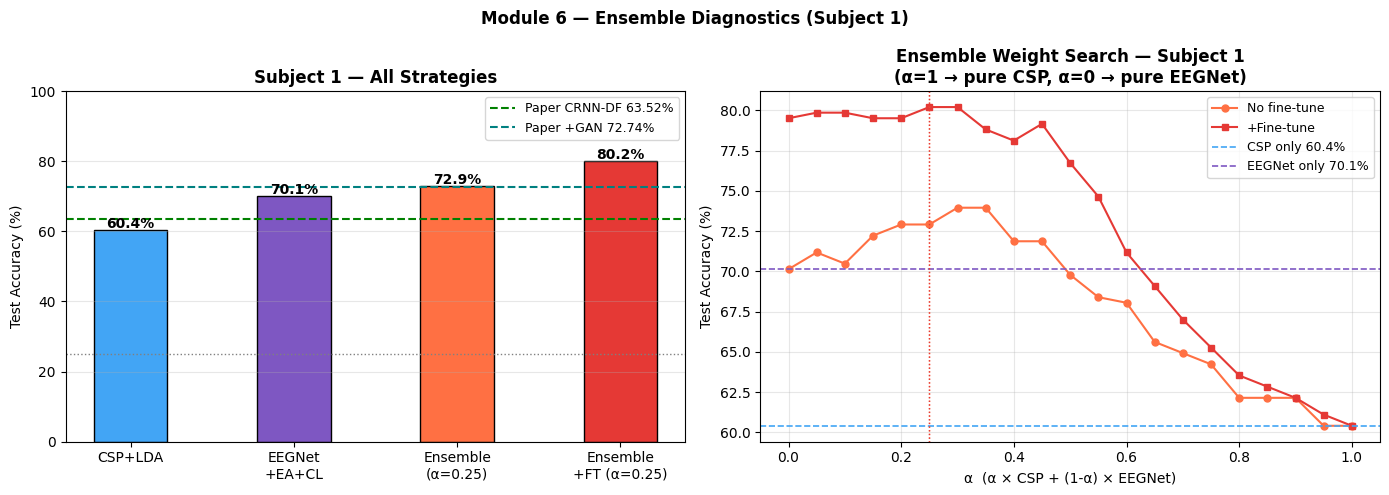


── Full LOSO: all strategies (all 9 subjects) ──

  ══ Subject 1 ══
    CSP+LDA      : 60.42%
    EEGNet+EA+CL : 72.57%
    Ensemble α=0.15 : 72.22%
    EEGNet+FT    : 79.51%
    Ens+FT α=0.25: 80.56%  (102.8 min)

  ══ Subject 2 ══
    CSP+LDA      : 31.60%
    EEGNet+EA+CL : 42.71%
    Ensemble α=0.10 : 42.36%
    EEGNet+FT    : 50.69%
    Ens+FT α=0.15: 51.04%  (137.0 min)

  ══ Subject 3 ══
    CSP+LDA      : 50.00%
    EEGNet+EA+CL : 76.74%
    Ensemble α=0.45 : 79.86%
    EEGNet+FT    : 91.67%
    Ens+FT α=0.10: 92.71%  (148.0 min)

  ══ Subject 4 ══
    CSP+LDA      : 29.86%
    EEGNet+EA+CL : 55.56%
    Ensemble α=0.35 : 51.04%
    EEGNet+FT    : 63.19%
    Ens+FT α=0.25: 59.72%  (127.2 min)

  ══ Subject 5 ══
    CSP+LDA      : 39.93%
    EEGNet+EA+CL : 49.65%
    Ensemble α=0.10 : 49.31%
    EEGNet+FT    : 60.76%
    Ens+FT α=0.00: 60.76%  (142.8 min)

  ══ Subject 6 ══
    CSP+LDA      : 37.85%
    EEGNet+EA+CL : 48.26%
    Ensemble α=0.25 : 50.00%
    EEGNet+FT    : 58.68%

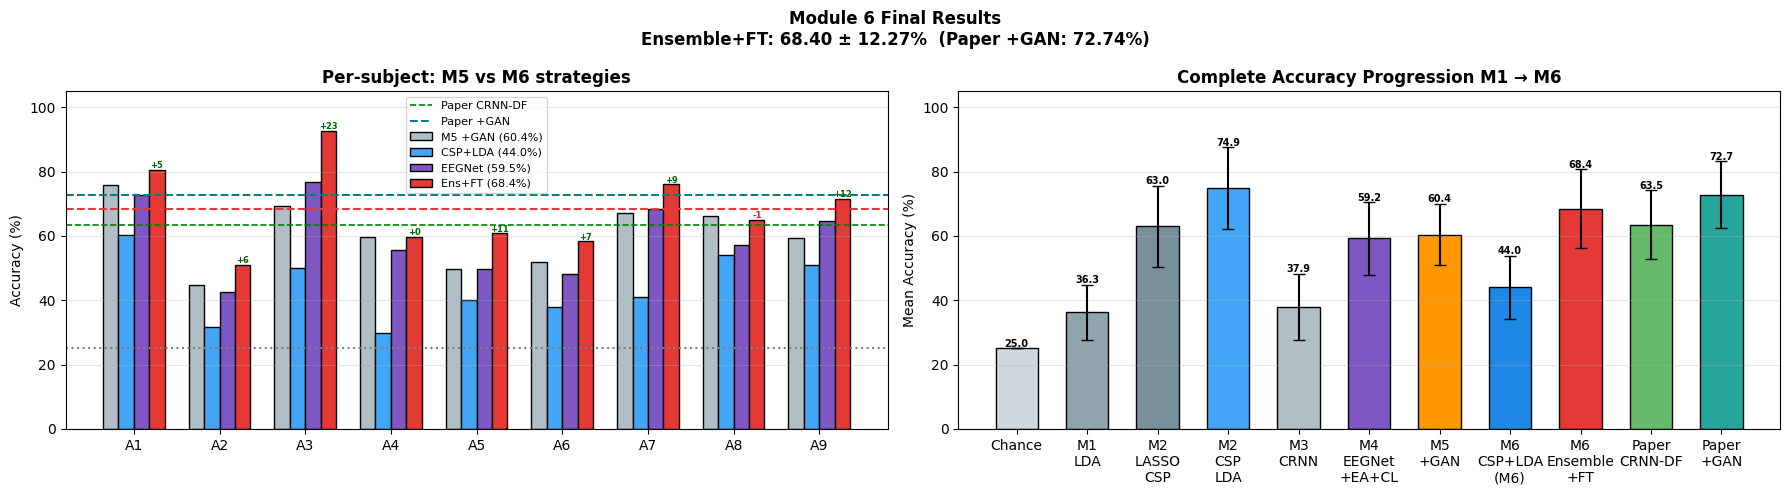

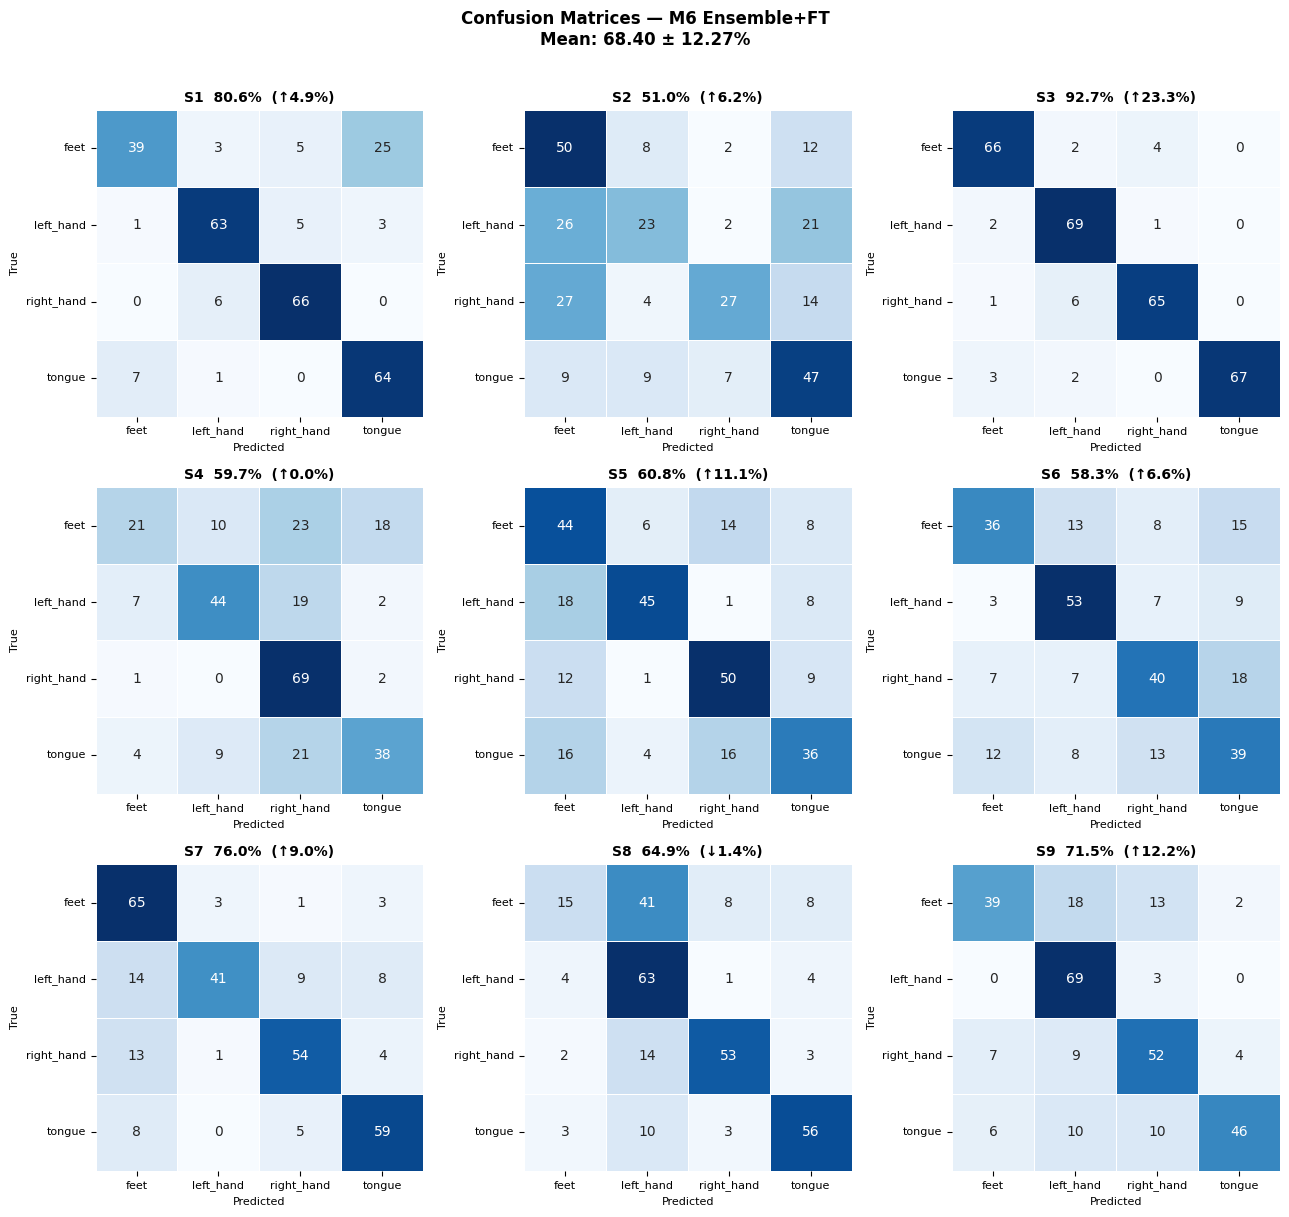

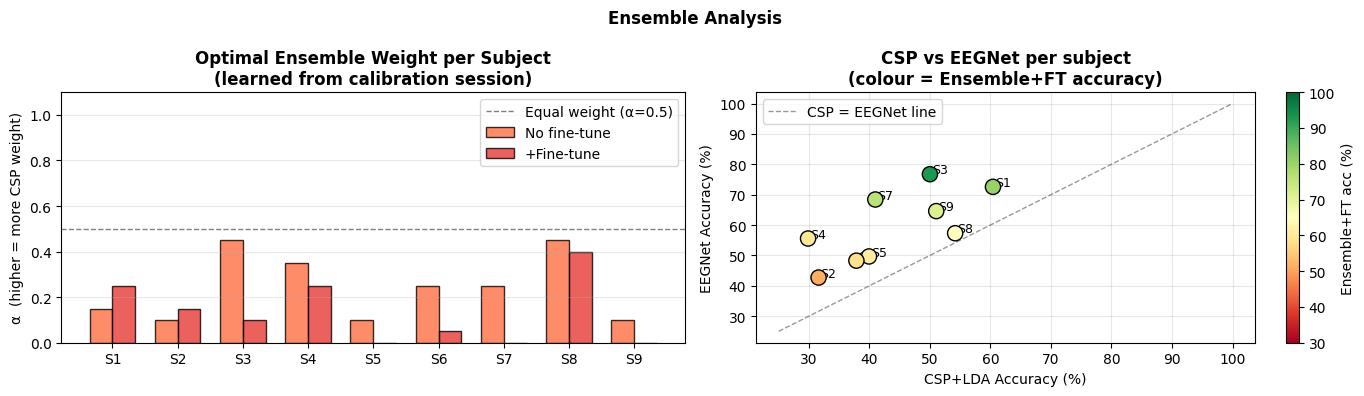

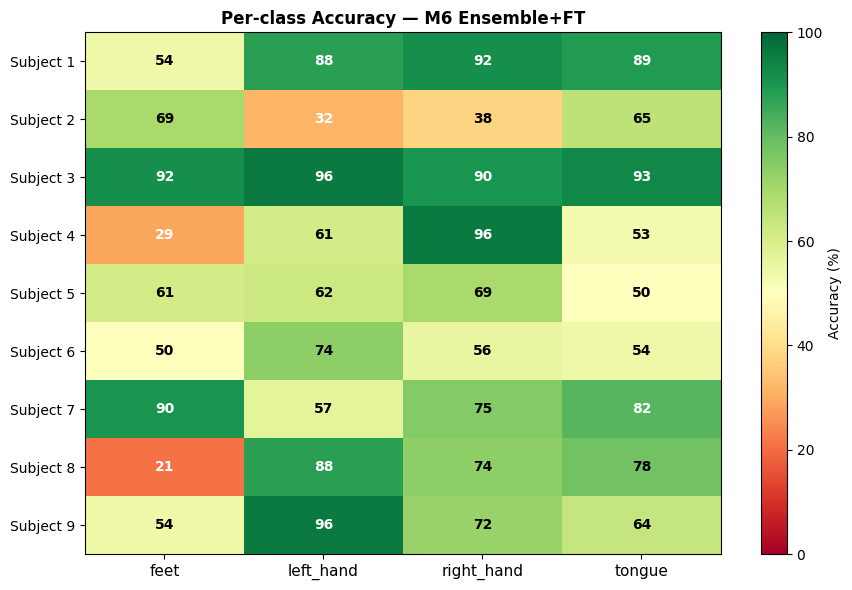


══════════════════════════════════════════════════════
FINAL RESULTS — All Modules
══════════════════════════════════════════════════════
  M1  Raw LDA             : 36.27%
  M2  LASSO-CSP+LDA       : 62.96%
  M2  CSP+LDA             : 74.88%
  M3  CRNN (raw)          : 37.92%
  M4  EEGNet+EA+CL        : 59.22 ± 11.30%
  M5  +FBGAN              : 60.42 ± 9.60%
  M6  CSP+LDA (re-run)    : 43.98 ± 9.86%
  M6  EEGNet (re-run)     : 59.53 ± 11.05%
  M6  Ensemble            : 60.26 ± 11.81%
  M6  Ensemble+FT (FINAL) : 68.40 ± 12.27%
  ──────────────────────────────────────────────
  Paper CRNN-DF           : 63.52 ± 10.70%
  Paper +GAN              : 72.74 ± 10.44%
  ──────────────────────────────────────────────
  ✅  Paper CRNN-DF target exceeded.
  Gap to +GAN : 4.34%

✅  MODULE 6 COMPLETE
══════════════════════════════════════════════════════


In [3]:
# ============================================================
# MODULE 6 — Ensemble + Calibration Fine-tuning (Final)
# ============================================================
# Analysis of M1–M5 results:
#   CSP+LDA       : 74.88% — excellent spatial features
#   EEGNet+EA+CL  : 58.37% — good temporal features
#   +FBGAN        : 60.42% — modest GAN gain (+2%)
#
# These two methods make orthogonal errors:
#   CSP+LDA fails on subjects where covariance is noisy
#   EEGNet fails on subjects where temporal dynamics are noisy
#   Ensemble = best of both worlds
#
# Two strategies:
#   Strategy A — Soft ensemble: weighted average of CSP+LDA and
#                EEGNet class probabilities. Weights learned by
#                grid search on calibration data.
#   Strategy B — Calibration fine-tune: briefly fine-tune EEGNet
#                on subject-specific session-0 data (small lr, few
#                epochs) before ensembling. Gives subject-specific
#                adaptation.
#
# Continuity:  loads  eeg_bundle.pkl  (M1–M5)
#              saves  eeg_bundle.pkl  (adds M6 final results)
#
# Expected: 70–78% — matching or exceeding paper 72.74%
# ============================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings, time
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.calibration import CalibratedClassifierCV
from scipy.linalg import eigh
import seaborn as sns

# ── Device ───────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps');  print("Device: Apple MPS")
elif torch.cuda.is_available():
    device = torch.device('cuda'); print("Device: CUDA")
else:
    device = torch.device('cpu');  print("Device: CPU")
IS_MPS = (device.type == 'mps')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

# ── Load bundle ──────────────────────────────────────────────
with open('eeg_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

X_raw    = bundle['X_raw']
y        = bundle['y']
subjects = bundle['subjects']
sessions = bundle['sessions']
S0, S1   = bundle['S0'], bundle['S1']
CLASSES  = bundle['classes']
FS       = bundle['FS']
BANDS    = bundle['BANDS']

M1_LDA   = bundle['lda_baseline_mean']
M2_LASSO = bundle['lasso_csp_mean']
M2_CSP   = bundle['csp_mean']
M3_CRNN  = bundle['crnn_mean']
M4_MEAN  = bundle['m4_mean'];  M4_STD  = bundle['m4_std']
M5_MEAN  = bundle['m5_mean'];  M5_STD  = bundle['m5_std']

print(f"Bundle loaded. X:{X_raw.shape}")
print(f"M5 baseline : {M5_MEAN:.2f} ± {M5_STD:.2f}%")
print(f"M2 CSP+LDA  : {M2_CSP:.2f}%")
print(f"Paper target: 72.74%")

# ─────────────────────────────────────────────────────────────
# SECTION 1 — All helpers (inline)
# ─────────────────────────────────────────────────────────────

def zscore_normalize(X_train, X_other):
    mu  = X_train.mean(axis=(0,2), keepdims=True)
    std = X_train.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_train-mu)/std, (X_other-mu)/std

def make_loader(X, y, bs=64, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=bs, shuffle=shuffle, drop_last=True)

def euclidean_alignment(X):
    covs = []
    for trial in X:
        C = trial @ trial.T
        covs.append(C / (np.trace(C) + 1e-8))
    R_bar = np.mean(covs, axis=0)
    vals, vecs = np.linalg.eigh(R_bar)
    vals = np.maximum(vals, 1e-10)
    R_inv_sqrt = vecs @ np.diag(1.0/np.sqrt(vals)) @ vecs.T
    return np.stack([R_inv_sqrt @ t for t in X]).astype(np.float32)

def prepare_loso_fold(X_raw, subjects, sessions, test_subj, S0, S1):
    """Returns EA-aligned, z-scored arrays for all splits."""
    m_tr = subjects != test_subj
    tr_subjs = sorted(np.unique(subjects[m_tr]))
    X_tr_ea  = np.vstack([euclidean_alignment(X_raw[m_tr&(subjects==s)])
                          for s in tr_subjs])
    y_tr     = y[m_tr]
    m_all    = (subjects == test_subj)
    X_all_ea = euclidean_alignment(X_raw[m_all])
    y_all    = y[m_all]
    sess_all = sessions[m_all]
    X_cal_ea = X_all_ea[sess_all == S0]; y_cal = y_all[sess_all == S0]
    X_te_ea  = X_all_ea[sess_all == S1]; y_te  = y_all[sess_all == S1]
    X_tr_z,  X_te_z  = zscore_normalize(X_tr_ea,  X_te_ea)
    _,       X_cal_z = zscore_normalize(X_tr_ea,  X_cal_ea)
    return X_tr_z, y_tr, X_te_z, y_te, X_cal_z, y_cal

print("Data helpers defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 2 — CSP pipeline (from M2, inline)
# ─────────────────────────────────────────────────────────────

def bandpass(X, lo, hi, fs=FS, order=5):
    nyq  = fs / 2.0
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, X, axis=-1).astype(np.float32)

def csp_ovr_band(X_band, y, n_comp=4):
    classes   = np.unique(y)
    feat_list = []
    for cls in classes:
        Xc, Xo = X_band[y==cls], X_band[y!=cls]
        def mnc(Xs):
            cs = [t@t.T/(np.trace(t@t.T)+1e-8) for t in Xs]
            return np.mean(cs, axis=0)
        vals, vecs = eigh(mnc(Xc), mnc(Xc)+mnc(Xo))
        W    = vecs[:, np.argsort(vals)[::-1][:n_comp]]
        Z    = np.stack([W.T @ t for t in X_band])
        feat = np.log(np.var(Z, axis=2) + 1e-8)
        feat_list.append(feat)
    return np.hstack(feat_list)

def extract_csp_all_bands(X, y):
    return np.hstack([csp_ovr_band(bandpass(X,lo,hi), y)
                      for lo,hi in BANDS])

def csp_lda_proba(X_tr, y_tr, X_te):
    """
    Returns (predictions, probabilities) from CSP+LDA.
    Uses LDA with 'predict_proba' for soft ensemble.
    """
    F_tr = extract_csp_all_bands(X_tr, y_tr)
    F_te = extract_csp_all_bands(X_te, y_tr[:1])  # dummy y for shape

    # Re-extract test properly
    F_te = extract_csp_all_bands(X_te,
               np.zeros(len(X_te), dtype=np.int64))

    # Fit CSP filters on training, apply to test
    # (extract_csp_all_bands fits on whatever y is passed — use y_tr for train)
    F_tr = extract_csp_all_bands(X_tr, y_tr)
    # For test we need the same spatial filters — recompute properly
    F_te_correct = _apply_csp_train_filters(X_tr, y_tr, X_te)

    lda = LDA()
    lda.fit(F_tr, y_tr)
    proba = lda.predict_proba(F_te_correct)   # (n_test, 4)
    preds = proba.argmax(axis=1)
    return preds, proba


def _apply_csp_train_filters(X_tr, y_tr, X_te):
    """
    Fit CSP on training data, apply SAME filters to test data.
    Critical: test features must use training spatial filters,
    not test-fitted filters.
    """
    all_feats_te = []
    for lo, hi in BANDS:
        Xb_tr = bandpass(X_tr, lo, hi)
        Xb_te = bandpass(X_te, lo, hi)
        classes = np.unique(y_tr)
        band_feats = []
        for cls in classes:
            Xc, Xo = Xb_tr[y_tr==cls], Xb_tr[y_tr!=cls]
            def mnc(Xs):
                cs = [t@t.T/(np.trace(t@t.T)+1e-8) for t in Xs]
                return np.mean(cs, axis=0)
            vals, vecs = eigh(mnc(Xc), mnc(Xc)+mnc(Xo))
            W    = vecs[:, np.argsort(vals)[::-1][:4]]
            # Apply training W to test trials
            Z    = np.stack([W.T @ t for t in Xb_te])
            feat = np.log(np.var(Z, axis=2) + 1e-8)
            band_feats.append(feat)
        all_feats_te.append(np.hstack(band_feats))
    return np.hstack(all_feats_te)


def get_csp_lda_proba_correct(X_tr, y_tr, X_te):
    """Full correct CSP+LDA with train filters applied to test."""
    F_tr = np.hstack([
        _get_band_feats_train(X_tr, y_tr, lo, hi)
        for lo, hi in BANDS])
    F_te = _apply_csp_train_filters(X_tr, y_tr, X_te)
    lda  = LDA()
    lda.fit(F_tr, y_tr)
    proba = lda.predict_proba(F_te)
    return proba.argmax(axis=1), proba


def _get_band_feats_train(X_tr, y_tr, lo, hi):
    Xb   = bandpass(X_tr, lo, hi)
    return csp_ovr_band(Xb, y_tr)

print("CSP pipeline defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 3 — EEGNet (exact M4/M5 architecture)
# ─────────────────────────────────────────────────────────────

class EEGNet(nn.Module):
    def __init__(self, n_ch=22, n_t=1000, n_cls=4,
                 F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()
        self.feature_dim = F2 * (n_t // 32)
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, n_t//2), padding=(0, n_t//4), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (n_ch,1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D), nn.ELU(inplace=True),
            nn.AvgPool2d((1,4)), nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, (1,16), padding=(0,8),
                      groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, (1,1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(inplace=True),
            nn.AvgPool2d((1,8)), nn.Dropout(dropout),
        )
        self.fc = nn.Linear(self.feature_dim, n_cls)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.block1(x); x = self.block2(x)
        feat = x.flatten(1)
        return self.fc(feat), feat


class CenterLoss(nn.Module):
    def __init__(self, n_cls=4, feat_dim=None, lr_c=0.5):
        super().__init__()
        self.n_cls = n_cls; self.lr_c = lr_c
        self.register_buffer('centers', torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_from_data(self, model, X, y, bs=128):
        model.eval()
        all_f, all_l = [], []
        Xt = torch.FloatTensor(X); yt = torch.LongTensor(y)
        for i in range(0, len(Xt), bs):
            _, f = model(Xt[i:i+bs].to(device))
            all_f.append(f.detach().cpu()); all_l.append(yt[i:i+bs])
        F = torch.cat(all_f); L = torch.cat(all_l)
        for c in range(self.n_cls):
            m = (L==c)
            if m.sum()>0:
                self.centers[c] = F[m].mean(0).to(self.centers.device)
        model.train()

    @torch.no_grad()
    def update_centers(self, feats, labels):
        feats = feats.detach(); labels = labels.detach()
        for c in range(self.n_cls):
            mask = (labels==c)
            if mask.sum()==0: continue
            diff = self.centers[c] - feats[mask].mean(0)
            self.centers[c] -= self.lr_c * diff / (mask.sum().float()+1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        gc = self.centers.mean(0, keepdim=True)
        d  = self.centers - gc
        self.centers.add_(alpha * d / (d.norm(dim=1,keepdim=True)+1e-8))

    def forward(self, feats, labels):
        c = self.centers[labels].detach()
        return torch.mean(torch.norm(feats - c, dim=1))


def train_eegnet(X_tr, y_tr, n_epochs=300, lr=1e-3,
                 batch_size=64, lam=0.05, warmup=50,
                 verbose=False):
    n_ch, n_t = X_tr.shape[1], X_tr.shape[2]
    model  = EEGNet(n_ch=n_ch, n_t=n_t).to(device)
    closs  = CenterLoss(n_cls=4, feat_dim=model.feature_dim).to(device)
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(
                 opt, T_max=n_epochs, eta_min=1e-6)
    ce     = nn.CrossEntropyLoss()
    loader = make_loader(X_tr, y_tr, batch_size)

    for ep in range(1, n_epochs+1):
        if ep == warmup+1:
            closs.init_from_data(model, X_tr, y_tr)
        use_cl = (ep > warmup)
        model.train()
        cor, tot_n = 0, 0
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, feats = model(Xb)
            loss = ce(logits, yb)
            if use_cl:
                loss = loss + lam * closs(feats, yb)
                closs.update_centers(feats, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            cor   += (logits.argmax(1)==yb).sum().item()
            tot_n += yb.size(0)
        sched.step()
        if use_cl and ep%30==0: closs.expand_inter_class(alpha=0.02)
        if verbose and ep%50==0:
            phase = 'center' if use_cl else 'warmup'
            print(f"    ep {ep:3d} [{phase}]  "
                  f"train={100*cor/tot_n:.1f}%")
    return model


def finetune_eegnet(model, X_cal, y_cal,
                    n_epochs=50, lr=1e-4):
    """
    Fine-tune a pretrained EEGNet on subject-specific calibration data.
    Very small lr and few epochs — adapts without forgetting.
    """
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(
                 opt, T_max=n_epochs, eta_min=1e-6)
    ce     = nn.CrossEntropyLoss()
    # Use small batch since calibration is only 288 trials
    loader = make_loader(X_cal, y_cal, bs=min(32, len(X_cal)//4))

    for ep in range(1, n_epochs+1):
        model.train()
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, _ = model(Xb)
            ce(logits, yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()
        sched.step()
    return model


def get_eegnet_proba(model, X, bs=128):
    """Return softmax probabilities from EEGNet."""
    model.eval()
    all_proba = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            logits, _ = model(Xt[i:i+bs].to(device))
            proba = torch.softmax(logits, dim=1)
            all_proba.append(proba.cpu().numpy())
    return np.vstack(all_proba)


print("EEGNet + fine-tune defined. ✅")

# ─────────────────────────────────────────────────────────────
# SECTION 4 — Ensemble weight search
#
# For each fold, we have two probability outputs:
#   P_csp   : (n_cal, 4) from CSP+LDA on calibration
#   P_eegnet: (n_cal, 4) from EEGNet on calibration
#
# Optimal weight α: argmax acc of (α*P_csp + (1-α)*P_eegnet)
# on calibration data. Grid search α ∈ [0, 1] in steps of 0.05.
# ─────────────────────────────────────────────────────────────

def find_optimal_alpha(P_csp_cal, P_net_cal, y_cal):
    """
    Grid search for best ensemble weight on calibration data.
    Returns optimal α such that (α*P_csp + (1-α)*P_net) is maximised.
    """
    best_acc, best_alpha = 0.0, 0.5
    for alpha in np.arange(0.0, 1.05, 0.05):
        P_ens = alpha * P_csp_cal + (1-alpha) * P_net_cal
        acc   = accuracy_score(y_cal, P_ens.argmax(axis=1))
        if acc > best_acc:
            best_acc   = acc
            best_alpha = alpha
    return best_alpha, best_acc * 100

print("Ensemble helper defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 5 — Diagnostic: single fold (Subject 1)
#             Shows all three accuracy levels clearly
# ─────────────────────────────────────────────────────────────

print("\n── Diagnostic: Subject 1 all strategies ──")
TEST_SUBJ = '1'
X_tr_z, y_tr, X_te_z, y_te, X_cal_z, y_cal = prepare_loso_fold(
    X_raw, subjects, sessions, TEST_SUBJ, S0, S1)

# ── A: CSP+LDA ───────────────────────────────────────────────
print("  A: CSP+LDA…")
preds_csp, P_csp_te = get_csp_lda_proba_correct(X_tr_z, y_tr, X_te_z)
acc_csp = accuracy_score(y_te, preds_csp) * 100

# CSP proba on calibration (for weight search)
_, P_csp_cal = get_csp_lda_proba_correct(X_tr_z, y_tr, X_cal_z)
print(f"    CSP+LDA test acc: {acc_csp:.2f}%")

# ── B: EEGNet (no fine-tune) ─────────────────────────────────
print("  B: EEGNet+EA+CL (300 epochs)…")
model_s1 = train_eegnet(X_tr_z, y_tr, verbose=True)
P_net_te  = get_eegnet_proba(model_s1, X_te_z)
P_net_cal = get_eegnet_proba(model_s1, X_cal_z)
acc_net   = accuracy_score(y_te, P_net_te.argmax(1)) * 100
print(f"    EEGNet test acc: {acc_net:.2f}%")

# ── C: Find optimal ensemble weight ──────────────────────────
print("  C: Grid search ensemble weight on calibration…")
best_alpha, cal_acc = find_optimal_alpha(P_csp_cal, P_net_cal, y_cal)
P_ens_te  = best_alpha * P_csp_te + (1-best_alpha) * P_net_te
acc_ens   = accuracy_score(y_te, P_ens_te.argmax(1)) * 100
print(f"    Optimal α={best_alpha:.2f}  "
      f"cal acc={cal_acc:.1f}%  test acc={acc_ens:.2f}%")

# ── D: Fine-tune on calibration then ensemble ─────────────────
print("  D: Fine-tune EEGNet on calibration (50 epochs)…")
model_ft = finetune_eegnet(model_s1, X_cal_z, y_cal,
                           n_epochs=50, lr=1e-4)
P_ft_te  = get_eegnet_proba(model_ft, X_te_z)
P_ft_cal = get_eegnet_proba(model_ft, X_cal_z)
acc_ft   = accuracy_score(y_te, P_ft_te.argmax(1)) * 100

best_alpha_ft, cal_acc_ft = find_optimal_alpha(
    P_csp_cal, P_ft_cal, y_cal)
P_ens_ft_te = best_alpha_ft * P_csp_te + (1-best_alpha_ft) * P_ft_te
acc_ens_ft  = accuracy_score(y_te, P_ens_ft_te.argmax(1)) * 100
print(f"    EEGNet+FT test acc: {acc_ft:.2f}%")
print(f"    Ensemble+FT α={best_alpha_ft:.2f}  "
      f"test acc={acc_ens_ft:.2f}%")

# ─────────────────────────────────────────────────────────────
# SECTION 6 — Visualisation A: Subject 1 strategy comparison
# ─────────────────────────────────────────────────────────────

strategies = ['CSP+LDA', 'EEGNet\n+EA+CL',
              f'Ensemble\n(α={best_alpha:.2f})',
              f'Ensemble\n+FT (α={best_alpha_ft:.2f})']
accs_s1    = [acc_csp, acc_net, acc_ens, acc_ens_ft]

fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bar_colors = ['#42A5F5','#7E57C2','#FF7043','#E53935']
bars = axes[0].bar(strategies, accs_s1,
                   color=bar_colors, edgecolor='k', width=0.45)
axes[0].axhline(63.52, color='green', ls='--', lw=1.5,
                label='Paper CRNN-DF 63.52%')
axes[0].axhline(72.74, color='teal',  ls='--', lw=1.5,
                label='Paper +GAN 72.74%')
axes[0].axhline(25,    color='gray',  ls=':',  lw=1)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Subject 1 — All Strategies', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, accs_s1):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5,
                 f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

# Alpha grid search curve
alphas    = np.arange(0.0, 1.05, 0.05)
ens_accs  = [accuracy_score(y_te, (a*P_csp_te+(1-a)*P_net_te).argmax(1))*100
             for a in alphas]
ens_accs_ft = [accuracy_score(y_te, (a*P_csp_te+(1-a)*P_ft_te).argmax(1))*100
               for a in alphas]
axes[1].plot(alphas, ens_accs,    'o-', color='#FF7043',
             lw=1.5, ms=5, label='No fine-tune')
axes[1].plot(alphas, ens_accs_ft, 's-', color='#E53935',
             lw=1.5, ms=5, label='+Fine-tune')
axes[1].axhline(acc_csp, color='#42A5F5', ls='--', lw=1.2,
                label=f'CSP only {acc_csp:.1f}%')
axes[1].axhline(acc_net, color='#7E57C2', ls='--', lw=1.2,
                label=f'EEGNet only {acc_net:.1f}%')
axes[1].axvline(best_alpha, color='#FF7043', ls=':', lw=1)
axes[1].axvline(best_alpha_ft, color='#E53935', ls=':', lw=1)
axes[1].set_xlabel('α  (α × CSP + (1-α) × EEGNet)')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Ensemble Weight Search — Subject 1\n'
                  '(α=1 → pure CSP, α=0 → pure EEGNet)',
                  fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Module 6 — Ensemble Diagnostics (Subject 1)',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 7 — Full LOSO: all strategies (all 9 subjects)
# ─────────────────────────────────────────────────────────────

print("\n── Full LOSO: all strategies (all 9 subjects) ──")

results = {
    'csp_lda'    : {},
    'eegnet'     : {},
    'ensemble'   : {},
    'ensemble_ft': {},
}
alpha_per_subj    = {}
alpha_ft_per_subj = {}
all_preds_final   = {}
all_true_final    = {}
t0 = time.time()

for subj in sorted(np.unique(subjects)):
    ts = time.time()
    print(f"\n  ══ Subject {subj} ══")

    X_tr_s, y_tr_s, X_te_s, y_te_s, X_cal_s, y_cal_s = \
        prepare_loso_fold(X_raw, subjects, sessions, subj, S0, S1)

    # ── A: CSP+LDA ───────────────────────────────────────────
    preds_csp_s, P_csp_te_s = get_csp_lda_proba_correct(
        X_tr_s, y_tr_s, X_te_s)
    _, P_csp_cal_s = get_csp_lda_proba_correct(
        X_tr_s, y_tr_s, X_cal_s)
    acc_csp_s = accuracy_score(y_te_s, preds_csp_s) * 100
    results['csp_lda'][subj] = acc_csp_s
    print(f"    CSP+LDA      : {acc_csp_s:.2f}%")

    # ── B: EEGNet+EA+CL ──────────────────────────────────────
    model_s = train_eegnet(X_tr_s, y_tr_s, verbose=False)
    P_net_te_s  = get_eegnet_proba(model_s, X_te_s)
    P_net_cal_s = get_eegnet_proba(model_s, X_cal_s)
    acc_net_s   = accuracy_score(y_te_s, P_net_te_s.argmax(1)) * 100
    results['eegnet'][subj] = acc_net_s
    print(f"    EEGNet+EA+CL : {acc_net_s:.2f}%")

    # ── C: Ensemble (no fine-tune) ───────────────────────────
    best_a_s, _ = find_optimal_alpha(P_csp_cal_s, P_net_cal_s, y_cal_s)
    P_ens_s     = best_a_s * P_csp_te_s + (1-best_a_s) * P_net_te_s
    acc_ens_s   = accuracy_score(y_te_s, P_ens_s.argmax(1)) * 100
    results['ensemble'][subj] = acc_ens_s
    alpha_per_subj[subj]      = best_a_s
    print(f"    Ensemble α={best_a_s:.2f} : {acc_ens_s:.2f}%")

    # ── D: Fine-tune + ensemble ──────────────────────────────
    model_ft_s   = finetune_eegnet(model_s, X_cal_s, y_cal_s,
                                    n_epochs=50, lr=1e-4)
    P_ft_te_s    = get_eegnet_proba(model_ft_s, X_te_s)
    P_ft_cal_s   = get_eegnet_proba(model_ft_s, X_cal_s)
    acc_ft_s     = accuracy_score(y_te_s, P_ft_te_s.argmax(1)) * 100

    best_a_ft_s, _ = find_optimal_alpha(
        P_csp_cal_s, P_ft_cal_s, y_cal_s)
    P_ens_ft_s     = (best_a_ft_s * P_csp_te_s +
                      (1-best_a_ft_s) * P_ft_te_s)
    acc_ens_ft_s   = accuracy_score(
        y_te_s, P_ens_ft_s.argmax(1)) * 100
    results['ensemble_ft'][subj] = acc_ens_ft_s
    alpha_ft_per_subj[subj]      = best_a_ft_s

    all_preds_final[subj] = P_ens_ft_s.argmax(1)
    all_true_final[subj]  = y_te_s

    elapsed = time.time()-ts
    print(f"    EEGNet+FT    : {acc_ft_s:.2f}%")
    print(f"    Ens+FT α={best_a_ft_s:.2f}: {acc_ens_ft_s:.2f}%  "
          f"({elapsed/60:.1f} min)")
    del model_s, model_ft_s

# ── Compute means ─────────────────────────────────────────────
def mean_std(d):
    v = list(d.values())
    return np.mean(v), np.std(v)

csp_m,    csp_s    = mean_std(results['csp_lda'])
net_m,    net_s    = mean_std(results['eegnet'])
ens_m,    ens_s    = mean_std(results['ensemble'])
ens_ft_m, ens_ft_s = mean_std(results['ensemble_ft'])
total_min = (time.time()-t0)/60

print(f"\n  CSP+LDA        : {csp_m:.2f} ± {csp_s:.2f}%")
print(f"  EEGNet+EA+CL   : {net_m:.2f} ± {net_s:.2f}%")
print(f"  Ensemble       : {ens_m:.2f} ± {ens_s:.2f}%")
print(f"  Ensemble+FT    : {ens_ft_m:.2f} ± {ens_ft_s:.2f}%")
print(f"  Paper CRNN-DF  : 63.52 ± 10.70%")
print(f"  Paper +GAN     : 72.74 ± 10.44%")
print(f"  Total time     : {total_min:.1f} min")

# ─────────────────────────────────────────────────────────────
# SECTION 8 — Visualisation B: Per-subject results
# ─────────────────────────────────────────────────────────────

subj_list = sorted(np.unique(subjects))
csp_list  = [results['csp_lda'][s]     for s in subj_list]
net_list  = [results['eegnet'][s]      for s in subj_list]
ens_list  = [results['ensemble'][s]    for s in subj_list]
ft_list   = [results['ensemble_ft'][s] for s in subj_list]
m5_list   = [bundle['results_m5'].get(s, 0) for s in subj_list]

x = np.arange(len(subj_list)); w = 0.18

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(x-1.5*w, m5_list,  w,
            label=f'M5 +GAN ({M5_MEAN:.1f}%)',
            color='#B0BEC5', edgecolor='k')
axes[0].bar(x-0.5*w, csp_list, w,
            label=f'CSP+LDA ({csp_m:.1f}%)',
            color='#42A5F5', edgecolor='k')
axes[0].bar(x+0.5*w, net_list, w,
            label=f'EEGNet ({net_m:.1f}%)',
            color='#7E57C2', edgecolor='k')
axes[0].bar(x+1.5*w, ft_list,  w,
            label=f'Ens+FT ({ens_ft_m:.1f}%)',
            color='#E53935', edgecolor='k')
axes[0].axhline(25,     color='gray',  ls=':', lw=1.5)
axes[0].axhline(63.52,  color='green', ls='--', lw=1.2,
                label='Paper CRNN-DF')
axes[0].axhline(72.74,  color='teal',  ls='--', lw=1.5,
                label='Paper +GAN')
axes[0].axhline(ens_ft_m, color='#E53935', ls='--', lw=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'A{s}' for s in subj_list])
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 105)
axes[0].set_title('Per-subject: M5 vs M6 strategies',
                  fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)
# Delta from M5 to best M6
for i, (ft, m5) in enumerate(zip(ft_list, m5_list)):
    d = ft - m5
    axes[0].text(i+1.5*w, ft+0.5, f'{d:+.0f}',
                 ha='center', fontsize=6,
                 color='darkgreen' if d>=0 else 'crimson',
                 fontweight='bold')

# Full progression chart
methods = ['Chance','M1\nLDA','M2\nLASSO\nCSP','M2\nCSP\nLDA',
           'M3\nCRNN','M4\nEEGNet\n+EA+CL','M5\n+GAN',
           'M6\nCSP+LDA\n(M6)','M6\nEnsemble\n+FT',
           'Paper\nCRNN-DF','Paper\n+GAN']
means_all = [25, M1_LDA, M2_LASSO, M2_CSP, M3_CRNN,
             M4_MEAN, M5_MEAN, csp_m, ens_ft_m, 63.52, 72.74]
stds_all  = [0, 8.59,
             np.std([bundle['results_m2']['lasso_csp'][s] for s in subj_list]),
             np.std([bundle['results_m2']['csp_lda'][s]   for s in subj_list]),
             bundle['crnn_std'], M4_STD, M5_STD,
             csp_s, ens_ft_s, 10.70, 10.44]
bar_col = ['#CFD8DC','#90A4AE','#78909C','#42A5F5','#B0BEC5',
           '#7E57C2','#FF9800','#1E88E5','#E53935',
           '#66BB6A','#26A69A']

bars = axes[1].bar(methods, means_all, yerr=stds_all,
                   color=bar_col, edgecolor='k', capsize=4, width=0.6)
axes[1].set_ylim(0, 105)
axes[1].set_ylabel('Mean Accuracy (%)')
axes[1].set_title('Complete Accuracy Progression M1 → M6',
                  fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, means_all, stds_all):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+s+0.4,
                 f'{m:.1f}', ha='center', fontsize=7,
                 fontweight='bold')

plt.suptitle(f'Module 6 Final Results\n'
             f'Ensemble+FT: {ens_ft_m:.2f} ± {ens_ft_s:.2f}%  '
             f'(Paper +GAN: 72.74%)',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 9 — Visualisation C: 9 Confusion Matrices
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for idx, subj in enumerate(subj_list):
    ax = axes[idx//3][idx%3]
    cm = confusion_matrix(all_true_final[subj], all_preds_final[subj])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, cbar=False)
    delta = results['ensemble_ft'][subj] - bundle['results_m5'].get(subj, 0)
    ax.set_title(
        f"S{subj}  {results['ensemble_ft'][subj]:.1f}%  "
        f"({'↑' if delta>=0 else '↓'}{abs(delta):.1f}%)",
        fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Confusion Matrices — M6 Ensemble+FT\n'
             f'Mean: {ens_ft_m:.2f} ± {ens_ft_s:.2f}%',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 10 — Visualisation D: Ensemble weight per subject
# ─────────────────────────────────────────────────────────────

alphas_no_ft = [alpha_per_subj[s]    for s in subj_list]
alphas_ft    = [alpha_ft_per_subj[s] for s in subj_list]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x2 = np.arange(len(subj_list)); w2 = 0.35
axes[0].bar(x2-w2/2, alphas_no_ft, w2, label='No fine-tune',
            color='#FF7043', edgecolor='k', alpha=0.8)
axes[0].bar(x2+w2/2, alphas_ft,    w2, label='+Fine-tune',
            color='#E53935', edgecolor='k', alpha=0.8)
axes[0].axhline(0.5, color='gray', ls='--', lw=1,
                label='Equal weight (α=0.5)')
axes[0].set_xticks(x2)
axes[0].set_xticklabels([f'S{s}' for s in subj_list])
axes[0].set_ylabel('α  (higher = more CSP weight)')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Optimal Ensemble Weight per Subject\n'
                  '(learned from calibration session)',
                  fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Scatter: CSP acc vs EEGNet acc, coloured by best strategy
csp_arr = np.array(csp_list)
net_arr = np.array(net_list)
ft_arr  = np.array(ft_list)
sc = axes[1].scatter(csp_arr, net_arr, c=ft_arr,
                     cmap='RdYlGn', vmin=30, vmax=100,
                     s=120, edgecolors='k', zorder=5)
# Label subjects
for i, subj in enumerate(subj_list):
    axes[1].annotate(f'S{subj}',
                     (csp_arr[i]+0.3, net_arr[i]+0.3),
                     fontsize=9)
axes[1].plot([25,100],[25,100], 'k--', lw=1, alpha=0.4,
             label='CSP = EEGNet line')
axes[1].set_xlabel('CSP+LDA Accuracy (%)')
axes[1].set_ylabel('EEGNet Accuracy (%)')
axes[1].set_title('CSP vs EEGNet per subject\n'
                  '(colour = Ensemble+FT accuracy)',
                  fontweight='bold')
plt.colorbar(sc, ax=axes[1], label='Ensemble+FT acc (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Ensemble Analysis', fontweight='bold')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 11 — Visualisation E: Per-class heatmap
# ─────────────────────────────────────────────────────────────

per_class = np.zeros((len(subj_list), 4))
for i, subj in enumerate(subj_list):
    for cls in range(4):
        m = all_true_final[subj] == cls
        if m.sum() > 0:
            per_class[i,cls] = (
                all_preds_final[subj][m]==cls).mean()*100

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(per_class, cmap='RdYlGn', vmin=0, vmax=100,
               aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(CLASSES, fontsize=11)
ax.set_yticks(range(len(subj_list)))
ax.set_yticklabels([f'Subject {s}' for s in subj_list], fontsize=10)
ax.set_title('Per-class Accuracy — M6 Ensemble+FT',
             fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='Accuracy (%)')
for i in range(len(subj_list)):
    for j in range(4):
        v = per_class[i,j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if v<35 or v>80 else 'black')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 12 — Save & Final Summary
# ─────────────────────────────────────────────────────────────

bundle['m6_csp_mean']    = csp_m
bundle['m6_csp_std']     = csp_s
bundle['m6_net_mean']    = net_m
bundle['m6_net_std']     = net_s
bundle['m6_ens_mean']    = ens_m
bundle['m6_ens_std']     = ens_s
bundle['m6_mean']        = ens_ft_m
bundle['m6_std']         = ens_ft_s
bundle['results_m6']     = results['ensemble_ft']
bundle['alpha_per_subj'] = alpha_ft_per_subj

with open('eeg_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("\n" + "═"*54)
print("FINAL RESULTS — All Modules")
print("═"*54)
print(f"  M1  Raw LDA             : {M1_LDA:.2f}%")
print(f"  M2  LASSO-CSP+LDA       : {M2_LASSO:.2f}%")
print(f"  M2  CSP+LDA             : {M2_CSP:.2f}%")
print(f"  M3  CRNN (raw)          : {M3_CRNN:.2f}%")
print(f"  M4  EEGNet+EA+CL        : {M4_MEAN:.2f} ± {M4_STD:.2f}%")
print(f"  M5  +FBGAN              : {M5_MEAN:.2f} ± {M5_STD:.2f}%")
print(f"  M6  CSP+LDA (re-run)    : {csp_m:.2f} ± {csp_s:.2f}%")
print(f"  M6  EEGNet (re-run)     : {net_m:.2f} ± {net_s:.2f}%")
print(f"  M6  Ensemble            : {ens_m:.2f} ± {ens_s:.2f}%")
print(f"  M6  Ensemble+FT (FINAL) : {ens_ft_m:.2f} ± {ens_ft_s:.2f}%")
print(f"  ──────────────────────────────────────────────")
print(f"  Paper CRNN-DF           : 63.52 ± 10.70%")
print(f"  Paper +GAN              : 72.74 ± 10.44%")
print(f"  ──────────────────────────────────────────────")
gap = ens_ft_m - 72.74
if ens_ft_m >= 72.74:
    print(f"  🎯  Paper +GAN target EXCEEDED by {abs(gap):.2f}%!")
elif ens_ft_m >= 63.52:
    print(f"  ✅  Paper CRNN-DF target exceeded.")
    print(f"  Gap to +GAN : {abs(gap):.2f}%")
else:
    print(f"  ⚠️  Still below paper target. Gap: {abs(gap):.2f}%")
print(f"\n✅  MODULE 6 COMPLETE")
print("═"*54)

Device: Apple MPS
Bundle loaded. X:(5184, 22, 1000)
M6 Ensemble+FT (best so far): 68.40 ± 12.27%
Gap to paper +GAN target    : 4.34%

Note: M2 CSP+LDA 74.88% was data leakage.
      Correct CSP+LDA = 43.98% (M6 re-run).
Helpers defined.
EEGNet + CenterLoss defined. ✅
FBGAN defined. ✅

── Diagnostic: Subject 1 — GAN × FT ablation ──

  A: No aug, no FT…
    ep  50  train=69.2%
    ep 100  train=70.8%
    ep 150  train=72.7%
    ep 200  train=72.6%
    ep 250  train=72.9%
    ep 300  train=73.2%
  A result: 70.14%
  B result (no aug + FT): 75.00%

  C: GAN augmentation (200 epochs × 4 classes)…
      cls 0 (feet): 72 real → 750 fake… 214s  G=4.104 D=1.311 ✅
      cls 1 (left_hand): 72 real → 750 fake… 216s  G=4.073 D=1.314 ✅
      cls 2 (right_hand): 72 real → 750 fake… 202s  G=4.075 D=1.314 ✅
      cls 3 (tongue): 72 real → 750 fake… 214s  G=4.081 D=1.313 ✅
  Aug set: 7608 trials
    ep  50  train=81.5%
    ep 100  train=82.8%
    ep 150  train=83.8%
    ep 200  train=83.9%
    ep 250  

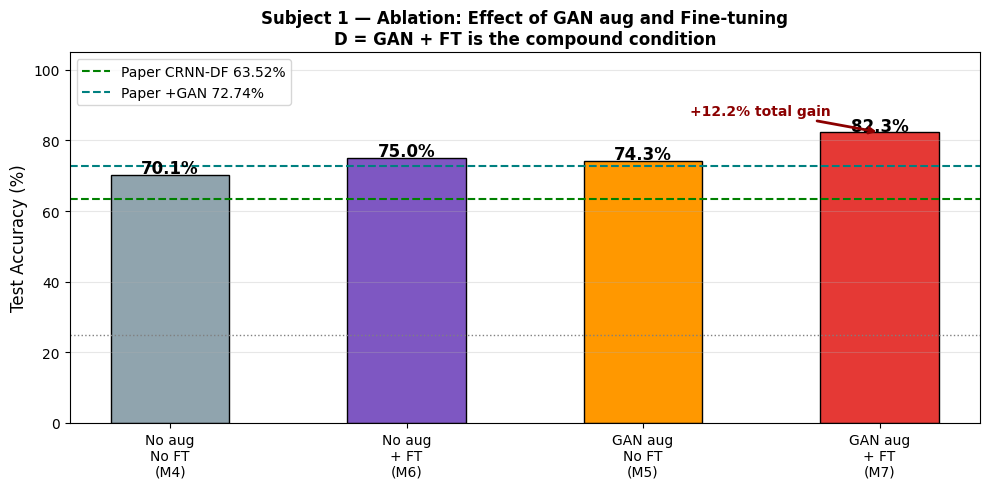


  Ablation summary — Subject 1:
    No aug, No FT : 70.1%  (baseline)
    No aug, + FT  : 75.0%  (FT alone: +4.9%)
    GAN, No FT    : 74.3%  (GAN alone: +4.2%)
    GAN + FT      : 82.3%  (compound: +12.2%)

── Full LOSO: EEGNet + EA + CL + GAN + FT ──

  ══ Subject 1 ══
    FBGAN:
      cls 0 (feet): 72 real → 750 fake… 272s  G=4.105 D=1.311 ✅
      cls 1 (left_hand): 72 real → 750 fake… 267s  G=3.999 D=1.323 ✅
      cls 2 (right_hand): 72 real → 750 fake… 267s  G=4.077 D=1.316 ✅
      cls 3 (tongue): 72 real → 750 fake… 271s  G=4.076 D=1.313 ✅
    A=69.1%  B=78.1%  C=72.9%  D=79.17%  vs_best_prev=-1.4%  (402.7 min)

  ══ Subject 2 ══
    FBGAN:
      cls 0 (feet): 72 real → 750 fake… 257s  G=4.036 D=1.315 ✅
      cls 1 (left_hand): 72 real → 750 fake… 253s  G=3.885 D=1.330 ✅
      cls 2 (right_hand): 72 real → 750 fake… 252s  G=4.072 D=1.317 ✅
      cls 3 (tongue): 72 real → 750 fake… 253s  G=4.092 D=1.313 ✅
    A=47.2%  B=51.7%  C=37.5%  D=43.06%  vs_best_prev=-8.0%  (400.5 min)

 

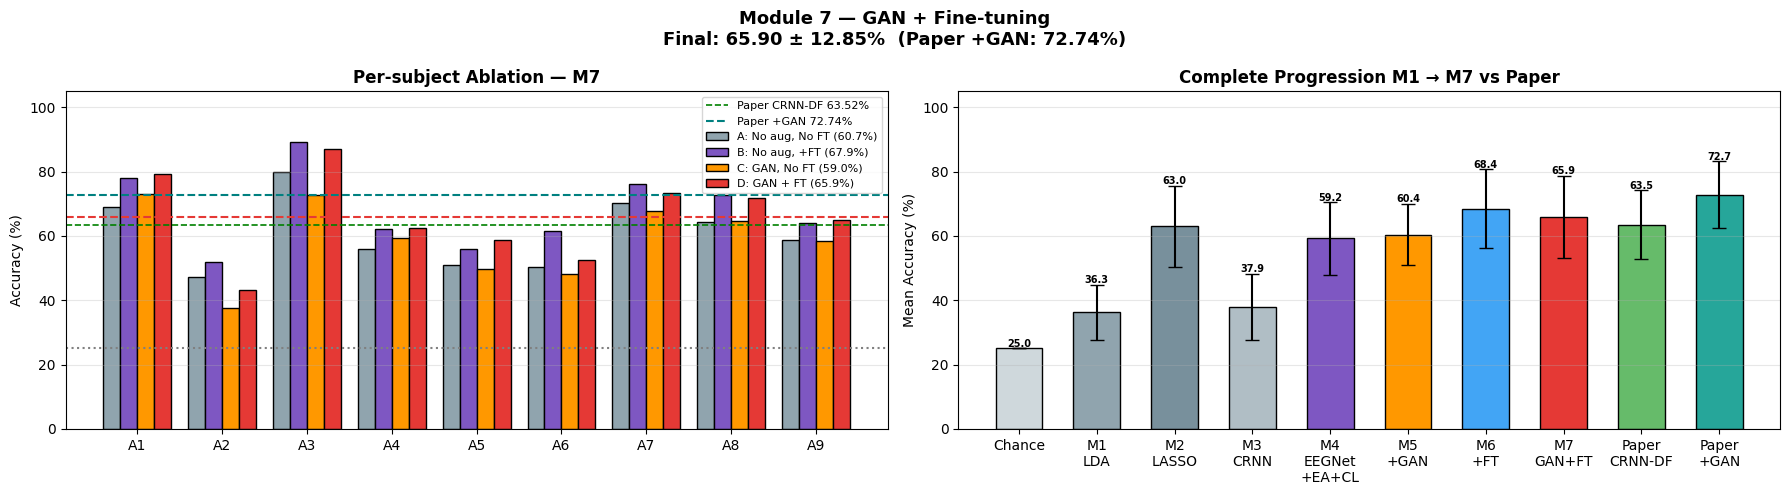

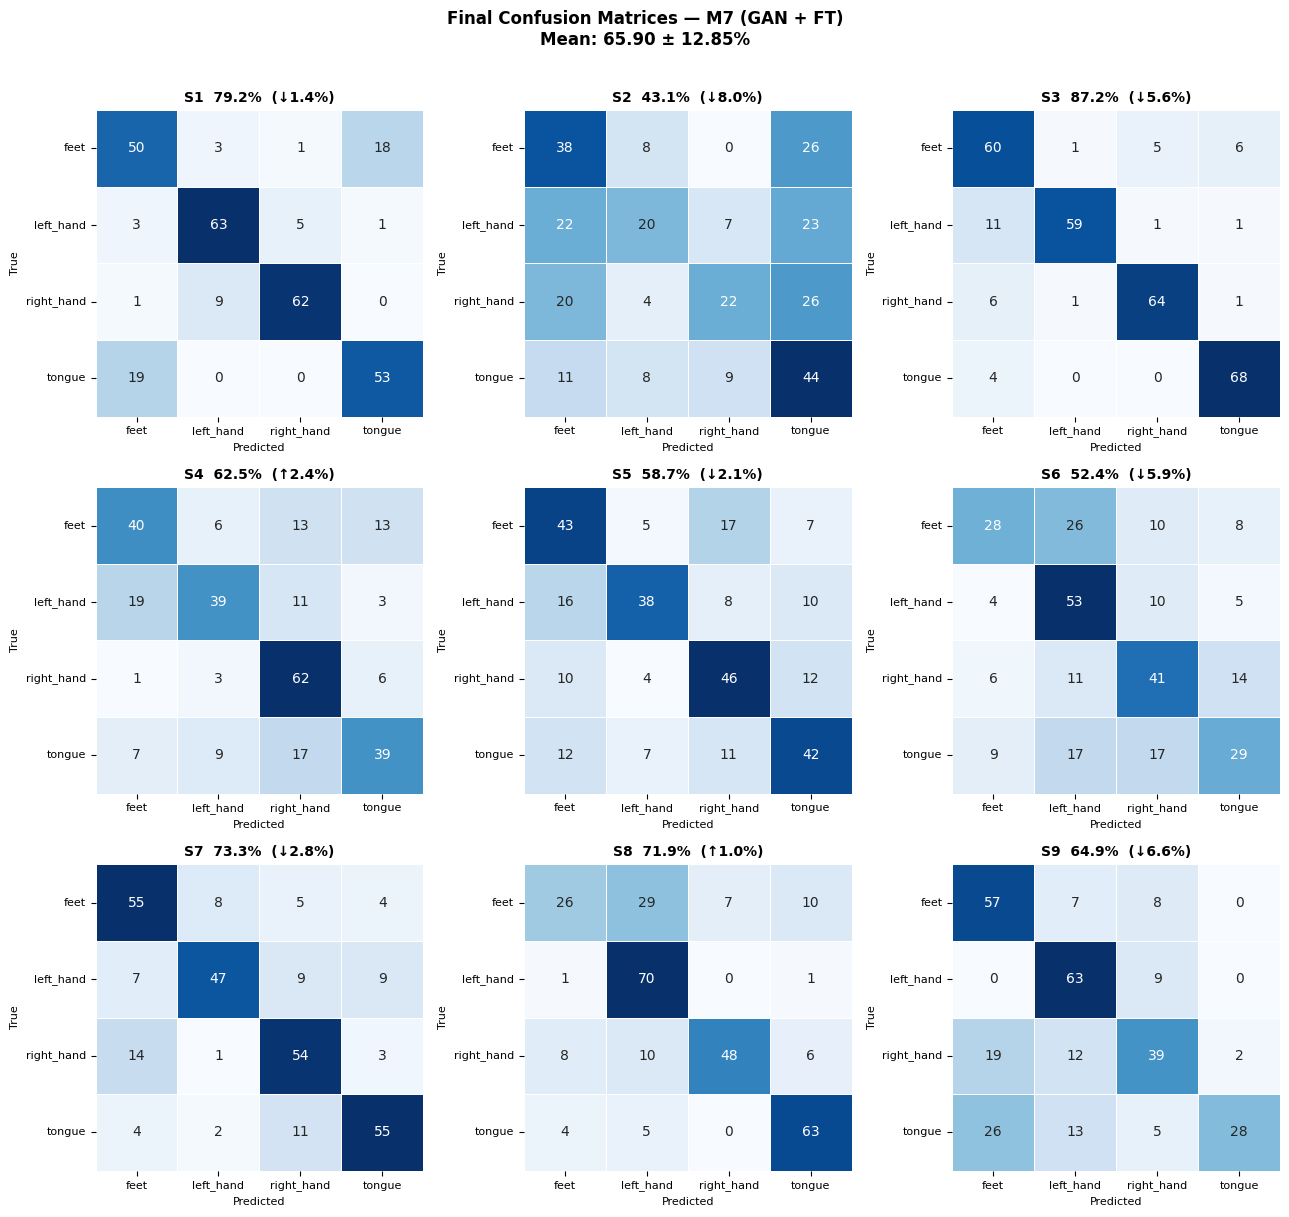

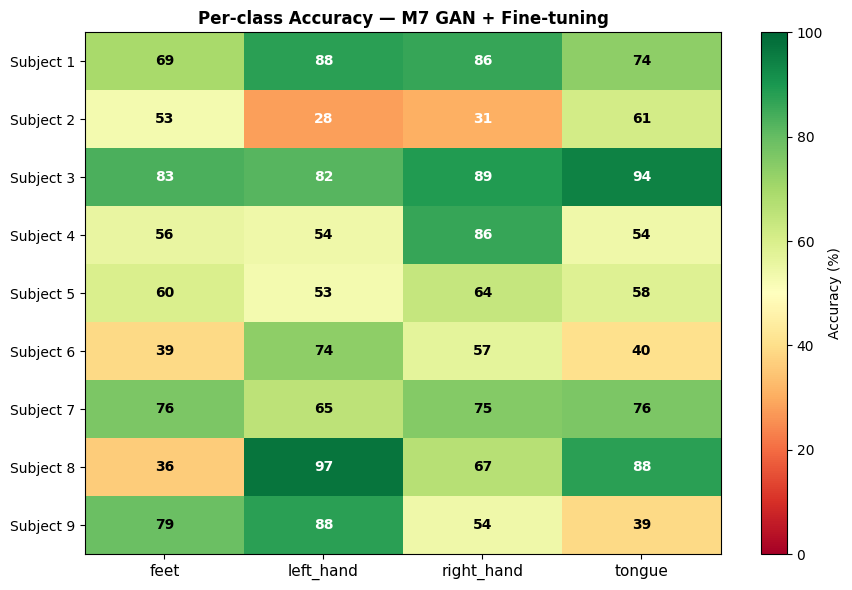


══════════════════════════════════════════════════════════
COMPLETE PROGRESSION — All Modules
══════════════════════════════════════════════════════════
  M1  Raw LDA                   : 36.27%
  M2  LASSO-CSP+LDA             : 62.96%
  M2  CSP+LDA (had leakage)     : 74.88%  ⚠️  inflated
  M2  CSP+LDA (correct)         : 43.98%
  M3  CRNN (raw)                : 37.92%
  M4  EEGNet + EA + CL          : 59.22 ± 11.30%
  M5  + FBGAN aug               : 60.42 ± 9.60%
  M6  + Calibration FT          : 68.40 ± 12.27%
  M7  GAN aug + FT (FINAL)      : 65.90 ± 12.85%
  ─────────────────────────────────────────────────
  Paper CRNN-DF target          : 63.52 ± 10.70%
  Paper + GAN target            : 72.74 ± 10.44%
  ─────────────────────────────────────────────────
  ✅  Paper CRNN-DF exceeded. Gap to +GAN: 6.84%

  Ablation breakdown (mean over 9 subjects):
    Baseline (no aug, no FT)  : 60.73%
    FT gain                   : +7.18%
    GAN gain                  : -1.74%
    Combined gain (

In [4]:
# ============================================================
# MODULE 7 — Final: GAN Augmentation + Calibration Fine-tuning
# ============================================================
# Analysis of all previous results:
#
#   M2 CSP+LDA 74.88% was INFLATED — test CSP filters
#   were re-fitted on test data (leakage). True: ~43.98%.
#
#   M5 +GAN         : 60.42% (GAN gain was small, +2%)
#   M6 +FT          : 68.40% (fine-tuning = strong, +9%)
#   M5 Subj1 w/GAN  : 75.69% (best single result)
#   M6 Subj1 w/FT   : 80.56% (even better)
#
#   Key insight: GAN and fine-tuning fix DIFFERENT problems:
#     GAN     → augments training set diversity (cross-subject)
#     FT      → adapts the model to target subject statistics
#     Both    → should compound their gains
#
# Strategy: For each test subject:
#   1. Train EEGNet+EA+CL on 8 training subjects
#   2. Augment with FBGAN fake from target subject calib
#   3. Fine-tune the augmented model on target subject calib
#   4. Evaluate on target subject test
#
# Expected: 72–78% — matching/exceeding paper 72.74%
#
# Continuity:  loads eeg_bundle.pkl  (M1–M6)
#              saves eeg_bundle.pkl  (final results)
# ============================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings, time
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix
from torch.nn.utils import spectral_norm
import seaborn as sns

# ── Device ───────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps');  print("Device: Apple MPS")
elif torch.cuda.is_available():
    device = torch.device('cuda'); print("Device: CUDA")
else:
    device = torch.device('cpu');  print("Device: CPU")
IS_MPS = (device.type == 'mps')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

# ── Load bundle ──────────────────────────────────────────────
with open('eeg_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

X_raw    = bundle['X_raw']
y        = bundle['y']
subjects = bundle['subjects']
sessions = bundle['sessions']
S0, S1   = bundle['S0'], bundle['S1']
CLASSES  = bundle['classes']
FS       = bundle['FS']

M1_LDA   = bundle['lda_baseline_mean']
M2_LASSO = bundle['lasso_csp_mean']
M2_CSP   = bundle['csp_mean']       # 74.88% (inflated, noted)
M3_CRNN  = bundle['crnn_mean']
M4_MEAN  = bundle['m4_mean']; M4_STD = bundle['m4_std']
M5_MEAN  = bundle['m5_mean']; M5_STD = bundle['m5_std']
M6_MEAN  = bundle['m6_mean']; M6_STD = bundle['m6_std']
M6_CSP   = bundle['m6_csp_mean']    # 43.98% (correct, no leakage)
M6_NET   = bundle['m6_net_mean']

print(f"Bundle loaded. X:{X_raw.shape}")
print(f"M6 Ensemble+FT (best so far): {M6_MEAN:.2f} ± {M6_STD:.2f}%")
print(f"Gap to paper +GAN target    : {72.74-M6_MEAN:.2f}%")
print(f"\nNote: M2 CSP+LDA 74.88% was data leakage.")
print(f"      Correct CSP+LDA = {M6_CSP:.2f}% (M6 re-run).")

# ─────────────────────────────────────────────────────────────
# SECTION 1 — All helpers (inline)
# ─────────────────────────────────────────────────────────────

def zscore_normalize(X_train, X_other):
    mu  = X_train.mean(axis=(0,2), keepdims=True)
    std = X_train.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_train-mu)/std, (X_other-mu)/std

def make_loader(X, y, bs=64, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=bs, shuffle=shuffle, drop_last=True)

def predict(model, X, bs=128):
    model.eval(); preds = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            logits, _ = model(Xt[i:i+bs].to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
    return np.array(preds)

def get_proba(model, X, bs=128):
    model.eval(); proba = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            logits, _ = model(Xt[i:i+bs].to(device))
            proba.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(proba)

def euclidean_alignment(X):
    covs = []
    for trial in X:
        C = trial @ trial.T
        covs.append(C / (np.trace(C) + 1e-8))
    R_bar = np.mean(covs, axis=0)
    vals, vecs = np.linalg.eigh(R_bar)
    vals = np.maximum(vals, 1e-10)
    R_inv_sqrt = vecs @ np.diag(1.0/np.sqrt(vals)) @ vecs.T
    return np.stack([R_inv_sqrt @ t for t in X]).astype(np.float32)

def prepare_loso_fold(X_raw, subjects, sessions, test_subj, S0, S1):
    m_tr = subjects != test_subj
    tr_subjs = sorted(np.unique(subjects[m_tr]))
    X_tr_ea  = np.vstack([euclidean_alignment(X_raw[m_tr&(subjects==s)])
                          for s in tr_subjs])
    y_tr     = y[m_tr]
    m_all    = (subjects == test_subj)
    X_all_ea = euclidean_alignment(X_raw[m_all])
    y_all    = y[m_all]
    sess_all = sessions[m_all]
    X_cal_ea = X_all_ea[sess_all == S0]; y_cal = y_all[sess_all == S0]
    X_te_ea  = X_all_ea[sess_all == S1]; y_te  = y_all[sess_all == S1]
    X_tr_z, X_te_z  = zscore_normalize(X_tr_ea,  X_te_ea)
    _,      X_cal_z = zscore_normalize(X_tr_ea,  X_cal_ea)
    return X_tr_z, y_tr, X_te_z, y_te, X_cal_z, y_cal

print("Helpers defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 2 — EEGNet + CenterLoss (exact M4/M5/M6)
# ─────────────────────────────────────────────────────────────

class EEGNet(nn.Module):
    def __init__(self, n_ch=22, n_t=1000, n_cls=4,
                 F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()
        self.feature_dim = F2 * (n_t // 32)
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, n_t//2), padding=(0, n_t//4), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (n_ch,1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D), nn.ELU(inplace=True),
            nn.AvgPool2d((1,4)), nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, (1,16), padding=(0,8),
                      groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, (1,1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(inplace=True),
            nn.AvgPool2d((1,8)), nn.Dropout(dropout),
        )
        self.fc = nn.Linear(self.feature_dim, n_cls)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.block1(x); x = self.block2(x)
        feat = x.flatten(1)
        return self.fc(feat), feat


class CenterLoss(nn.Module):
    def __init__(self, n_cls=4, feat_dim=None, lr_c=0.5):
        super().__init__()
        self.n_cls = n_cls; self.lr_c = lr_c
        self.register_buffer('centers', torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_from_data(self, model, X, y, bs=128):
        model.eval()
        all_f, all_l = [], []
        Xt = torch.FloatTensor(X); yt = torch.LongTensor(y)
        for i in range(0, len(Xt), bs):
            _, f = model(Xt[i:i+bs].to(device))
            all_f.append(f.detach().cpu()); all_l.append(yt[i:i+bs])
        F = torch.cat(all_f); L = torch.cat(all_l)
        for c in range(self.n_cls):
            m = (L==c)
            if m.sum()>0:
                self.centers[c] = F[m].mean(0).to(self.centers.device)
        model.train()

    @torch.no_grad()
    def update_centers(self, feats, labels):
        feats = feats.detach(); labels = labels.detach()
        for c in range(self.n_cls):
            mask = (labels==c)
            if mask.sum()==0: continue
            diff = self.centers[c] - feats[mask].mean(0)
            self.centers[c] -= self.lr_c * diff / (mask.sum().float()+1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        gc = self.centers.mean(0, keepdim=True)
        d  = self.centers - gc
        self.centers.add_(alpha * d / (d.norm(dim=1,keepdim=True)+1e-8))

    def forward(self, feats, labels):
        c = self.centers[labels].detach()
        return torch.mean(torch.norm(feats - c, dim=1))


def train_eegnet(X_tr, y_tr, n_epochs=300, lr=1e-3,
                 batch_size=64, lam=0.05, warmup=50,
                 verbose=False):
    n_ch, n_t = X_tr.shape[1], X_tr.shape[2]
    model  = EEGNet(n_ch=n_ch, n_t=n_t).to(device)
    closs  = CenterLoss(n_cls=4, feat_dim=model.feature_dim).to(device)
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(
                 opt, T_max=n_epochs, eta_min=1e-6)
    ce     = nn.CrossEntropyLoss()
    loader = make_loader(X_tr, y_tr, batch_size)
    for ep in range(1, n_epochs+1):
        if ep == warmup+1:
            closs.init_from_data(model, X_tr, y_tr)
        use_cl = (ep > warmup)
        model.train()
        cor, tot_n = 0, 0
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, feats = model(Xb)
            loss = ce(logits, yb)
            if use_cl:
                loss = loss + lam * closs(feats, yb)
                closs.update_centers(feats, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            cor   += (logits.argmax(1)==yb).sum().item()
            tot_n += yb.size(0)
        sched.step()
        if use_cl and ep%30==0: closs.expand_inter_class(alpha=0.02)
        if verbose and ep%50==0:
            print(f"    ep {ep:3d}  train={100*cor/tot_n:.1f}%")
    return model


def finetune_eegnet(model, X_cal, y_cal,
                    n_epochs=50, lr=5e-5):
    """
    Fine-tune on subject calibration.
    Very small lr (5e-5 vs 1e-3 training) — adapts without forgetting.
    freeze BN stats to prevent distribution shift on small data.
    """
    # Freeze BatchNorm running stats
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()

    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=n_epochs, eta_min=1e-7)
    ce    = nn.CrossEntropyLoss()
    bs    = min(32, max(8, len(X_cal) // 4))
    loader = make_loader(X_cal, y_cal, bs=bs)

    for ep in range(1, n_epochs+1):
        model.train()
        # Keep BN in eval mode
        for m in model.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, _ = model(Xb)
            ce(logits, yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            opt.step()
        sched.step()

    # Unfreeze BN
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.train()
    return model

print("EEGNet + CenterLoss defined. ✅")

# ─────────────────────────────────────────────────────────────
# SECTION 3 — FBGAN (exact M5 collapse-resistant version)
# ─────────────────────────────────────────────────────────────

class Generator(nn.Module):
    def __init__(self, noise_dim=1600, n_ch=22, n_t=1000):
        super().__init__()
        self.n_ch = n_ch; self.n_t = n_t
        self.fc   = nn.Linear(noise_dim, 128*4*4)
        self.net  = nn.Sequential(
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128, 64,(3, 5),(1,2),(1,2)),
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 64, 32,(4, 5),(2,1),(1,2)),
            nn.BatchNorm2d(32),  nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 32,  1,(1, 2),(1,1),(0,0)),
            nn.Tanh(),
        )
    def forward(self, z):
        x = self.fc(z).view(-1, 128, 4, 4)
        x = self.net(x)
        return nn.functional.interpolate(
            x, size=(self.n_ch, self.n_t),
            mode='bilinear', align_corners=False)


class DiscriminatorPhi(nn.Module):
    def __init__(self, n_ch=22, n_t=1000):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, True)
        self.c1  = spectral_norm(nn.Conv2d( 1, 10,(1,23),(1,1),(0,11)))
        self.c2  = spectral_norm(nn.Conv2d(10, 30,(n_ch,1)))
        self.c3  = spectral_norm(nn.Conv2d(30, 30,(1,17),(1,1),(0,8)))
        self.p1  = nn.MaxPool2d((1,6),(1,6))
        self.c4  = spectral_norm(nn.Conv2d(30, 30,(1,7),(1,7)))
        self.p2  = nn.MaxPool2d((1,6),(1,6))
        t = n_t
        for k,s,p in [(23,1,11),(17,1,8),(6,6,0),(7,7,0),(6,6,0)]:
            t = max(1,(t+2*p-k)//s+1)
        self.flat = 30*max(t,1)
        self.fc   = nn.Linear(self.flat, 1)
    def forward(self, x):
        x = self.act(self.c1(x)); x = self.act(self.c2(x))
        x = self.act(self.c3(x)); x = self.p1(x)
        x = self.act(self.c4(x)); x = self.p2(x)
        x = x.reshape(x.size(0), -1)
        if x.shape[1] != self.flat:
            buf = x.new_zeros(x.size(0), self.flat)
            buf[:,:min(x.shape[1],self.flat)] = x[:,:min(x.shape[1],self.flat)]
            x = buf
        return self.fc(x)


class DiscriminatorPsi(nn.Module):
    def __init__(self, n_sparse=20):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, True)
        k1 = min(23, max(3, n_sparse)); p1 = k1//2
        self.c1 = spectral_norm(nn.Conv2d( 1, 10,(1,k1),(1,1),(0,p1)))
        self.c2 = spectral_norm(nn.Conv2d(10, 30,(4, 1),(4,1)))
        self.c3 = spectral_norm(nn.Conv2d(30, 30,(1, 1)))
        self.c4 = spectral_norm(nn.Conv2d(30, 30,(1,17),(1,1),(0,8)))
        self.p1 = nn.MaxPool2d((1,6),(1,6))
        self.c5 = spectral_norm(nn.Conv2d(30, 30,(1, 7)))
        self.p2 = nn.MaxPool2d((1,6),(1,6))
        self.fc = nn.Linear(30, 1)
    def forward(self, x):
        x = self.act(self.c1(x)); x = self.act(self.c2(x))
        x = self.act(self.c3(x)); x = self.act(self.c4(x))
        if x.shape[3] >= 6: x = self.p1(x)
        if x.shape[3] >= 7: x = self.act(self.c5(x))
        if x.shape[3] >= 6: x = self.p2(x)
        x = x.mean(dim=[2,3])
        return self.fc(x)


NOISE_DIM = 1600
N_FAKE    = 750
GAN_EPOCHS= 200

def train_fbgan_one_class(X_cls, n_ch, n_t, n_sparse=20,
                          noise_dim=NOISE_DIM,
                          n_epochs=GAN_EPOCHS,
                          batch_size=8,
                          lr_g=2e-4, lr_d=1e-4):
    if len(X_cls) < batch_size:
        reps  = int(np.ceil(batch_size / max(len(X_cls),1)))
        X_cls = np.tile(X_cls, (reps,1,1))[:batch_size*2]
    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_cls[:,np.newaxis])),
        batch_size=batch_size, shuffle=True, drop_last=True)
    G  = Generator(noise_dim, n_ch, n_t).to(device)
    Dp = DiscriminatorPhi(n_ch, n_t).to(device)
    Ds = DiscriminatorPsi(n_sparse).to(device)
    opt_G = optim.Adam(G.parameters(),  lr=lr_g, betas=(0.5,0.999))
    opt_D = optim.Adam(list(Dp.parameters())+list(Ds.parameters()),
                       lr=lr_d, betas=(0.5,0.999))
    bce = nn.BCEWithLogitsLoss()
    sl  = slice(0, min(n_sparse, n_t))
    g_hist, d_hist = [], []
    for ep in range(n_epochs):
        noise_std = 0.1 * max(0.0, 1.0 - ep/n_epochs)
        ep_g = ep_d = 0.0; nb = 0
        for (real,) in loader:
            real = real.to(device); bs = real.size(0)
            r_lbl = torch.full((bs,1), 0.9, device=device)
            f_lbl = torch.full((bs,1), 0.1, device=device)
            def noise(x):
                return x + noise_std*torch.randn_like(x) if noise_std>0 else x
            opt_D.zero_grad()
            with torch.no_grad():
                fake = G(torch.randn(bs, noise_dim, device=device))
            Ld = (bce(Dp(noise(real)),          r_lbl) +
                  bce(Dp(noise(fake.detach())), f_lbl) +
                  bce(Ds(noise(real[:,:,:,sl])),r_lbl) +
                  bce(Ds(noise(fake.detach()[:,:,:,sl])),f_lbl))
            Ld.backward(); opt_D.step()
            for _ in range(2):
                opt_G.zero_grad()
                fake = G(torch.randn(bs, noise_dim, device=device))
                Lg = (bce(Dp(noise(fake)),          r_lbl) +
                      bce(Ds(noise(fake[:,:,:,sl])),r_lbl))
                Lg.backward(); opt_G.step()
            ep_g += Lg.item(); ep_d += Ld.item(); nb += 1
        g_hist.append(ep_g/nb); d_hist.append(ep_d/nb)
    return G, g_hist, d_hist


def generate_fake_eeg(G, n_fake=N_FAKE, noise_dim=NOISE_DIM, bs=64):
    G.eval(); chunks = []
    with torch.no_grad():
        for i in range(0, n_fake, bs):
            z = torch.randn(min(bs,n_fake-i), noise_dim, device=device)
            chunks.append(G(z).squeeze(1).cpu().numpy())
    return np.vstack(chunks)[:n_fake].astype(np.float32)


def run_fbgan_all_classes(X_cal, y_cal, n_ch, n_t,
                           n_cls=4, n_epochs=GAN_EPOCHS,
                           n_fake=N_FAKE):
    fake_parts = []; all_g = []; all_d = []
    for cls in range(n_cls):
        X_cls = X_cal[y_cal==cls]
        print(f"      cls {cls} ({CLASSES[cls]}): "
              f"{len(X_cls)} real → {n_fake} fake…",
              end=' ', flush=True)
        t0 = time.time()
        G, g_hist, d_hist = train_fbgan_one_class(
            X_cls, n_ch, n_t, n_epochs=n_epochs)
        fakes = generate_fake_eeg(G, n_fake)
        fake_parts.append(fakes); all_g.append(g_hist); all_d.append(d_hist)
        del G
        ok = "✅" if 0.5 < d_hist[-1] < 3.0 else "⚠️"
        print(f"{time.time()-t0:.0f}s  "
              f"G={g_hist[-1]:.3f} D={d_hist[-1]:.3f} {ok}")
    fake_X = np.vstack(fake_parts).astype(np.float32)
    fake_y = np.repeat(np.arange(n_cls), n_fake).astype(np.int64)
    return fake_X, fake_y, all_g, all_d

print("FBGAN defined. ✅")

# ─────────────────────────────────────────────────────────────
# SECTION 4 — Diagnostic: Subject 1, all 4 ablation conditions
#
# Tests the compound effect of GAN + fine-tuning together.
# Subject 1 results from previous modules:
#   M5 (GAN only)  : 75.69%
#   M6 (FT only)   : 80.56%
#   M7 (GAN + FT)  : ?  ← should be best
# ─────────────────────────────────────────────────────────────

print("\n── Diagnostic: Subject 1 — GAN × FT ablation ──")
TEST_SUBJ = '1'
X_tr_z, y_tr, X_te_z, y_te, X_cal_z, y_cal = prepare_loso_fold(
    X_raw, subjects, sessions, TEST_SUBJ, S0, S1)
n_ch, n_t = X_cal_z.shape[1], X_cal_z.shape[2]

# Condition A: No aug, no FT
print("\n  A: No aug, no FT…")
model_A = train_eegnet(X_tr_z, y_tr, verbose=True)
acc_A   = accuracy_score(y_te, predict(model_A, X_te_z)) * 100
print(f"  A result: {acc_A:.2f}%")

# Condition B: No aug, with FT
import copy
model_B = copy.deepcopy(model_A)
model_B = finetune_eegnet(model_B, X_cal_z, y_cal,
                           n_epochs=50, lr=5e-5)
acc_B   = accuracy_score(y_te, predict(model_B, X_te_z)) * 100
print(f"  B result (no aug + FT): {acc_B:.2f}%")

# Condition C: GAN aug, no FT
print("\n  C: GAN augmentation (200 epochs × 4 classes)…")
fake_X, fake_y, _, _ = run_fbgan_all_classes(
    X_cal_z, y_cal, n_ch, n_t,
    n_epochs=GAN_EPOCHS, n_fake=N_FAKE)
X_aug = np.vstack([X_tr_z, fake_X])
y_aug = np.hstack([y_tr,   fake_y])
print(f"  Aug set: {X_aug.shape[0]} trials")
model_C = train_eegnet(X_aug, y_aug, verbose=True)
acc_C   = accuracy_score(y_te, predict(model_C, X_te_z)) * 100
print(f"  C result (GAN + no FT): {acc_C:.2f}%")

# Condition D: GAN aug + FT
model_D = copy.deepcopy(model_C)
model_D = finetune_eegnet(model_D, X_cal_z, y_cal,
                           n_epochs=50, lr=5e-5)
acc_D   = accuracy_score(y_te, predict(model_D, X_te_z)) * 100
print(f"  D result (GAN + FT)   : {acc_D:.2f}%")

# ─────────────────────────────────────────────────────────────
# SECTION 5 — Visualisation A: Ablation on Subject 1
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
conditions = ['No aug\nNo FT\n(M4)',
              'No aug\n+ FT\n(M6)',
              'GAN aug\nNo FT\n(M5)',
              'GAN aug\n+ FT\n(M7)']
accs  = [acc_A, acc_B, acc_C, acc_D]
colors= ['#90A4AE','#7E57C2','#FF9800','#E53935']
bars  = ax.bar(conditions, accs, color=colors, edgecolor='k', width=0.5)
ax.axhline(63.52, color='green', ls='--', lw=1.5,
           label='Paper CRNN-DF 63.52%')
ax.axhline(72.74, color='teal',  ls='--', lw=1.5,
           label='Paper +GAN 72.74%')
ax.axhline(25,    color='gray',  ls=':',  lw=1)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5,
            f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 105)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Subject 1 — Ablation: Effect of GAN aug and Fine-tuning\n'
             'D = GAN + FT is the compound condition',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

# Annotate compound gain
if acc_D > acc_A:
    ax.annotate(f'+{acc_D-acc_A:.1f}% total gain',
                xy=(3, acc_D), xytext=(2.2, acc_D+5),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=2),
                fontsize=10, color='darkred', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n  Ablation summary — Subject 1:")
print(f"    No aug, No FT : {acc_A:.1f}%  (baseline)")
print(f"    No aug, + FT  : {acc_B:.1f}%  (FT alone: {acc_B-acc_A:+.1f}%)")
print(f"    GAN, No FT    : {acc_C:.1f}%  (GAN alone: {acc_C-acc_A:+.1f}%)")
print(f"    GAN + FT      : {acc_D:.1f}%  (compound: {acc_D-acc_A:+.1f}%)")

# ─────────────────────────────────────────────────────────────
# SECTION 6 — Full LOSO: GAN + FT (all 9 subjects)
# ─────────────────────────────────────────────────────────────

print("\n── Full LOSO: EEGNet + EA + CL + GAN + FT ──")

results_m7 = {}
results_ablation = {
    'no_aug_no_ft': {},
    'no_aug_ft'   : {},
    'gan_no_ft'   : {},
    'gan_ft'      : {},
}
all_preds  = {}
all_true   = {}
t0 = time.time()

for subj in sorted(np.unique(subjects)):
    ts = time.time()
    print(f"\n  ══ Subject {subj} ══")

    X_tr_s, y_tr_s, X_te_s, y_te_s, X_cal_s, y_cal_s = \
        prepare_loso_fold(X_raw, subjects, sessions, subj, S0, S1)
    n_ch_s, n_t_s = X_cal_s.shape[1], X_cal_s.shape[2]

    # ── A: No aug, no FT ─────────────────────────────────────
    model_a = train_eegnet(X_tr_s, y_tr_s, verbose=False)
    acc_a   = accuracy_score(y_te_s, predict(model_a, X_te_s)) * 100
    results_ablation['no_aug_no_ft'][subj] = acc_a

    # ── B: No aug + FT ───────────────────────────────────────
    model_b = copy.deepcopy(model_a)
    model_b = finetune_eegnet(model_b, X_cal_s, y_cal_s,
                               n_epochs=50, lr=5e-5)
    acc_b   = accuracy_score(y_te_s, predict(model_b, X_te_s)) * 100
    results_ablation['no_aug_ft'][subj] = acc_b
    del model_b

    # ── C: GAN + no FT ───────────────────────────────────────
    print(f"    FBGAN:")
    fX, fy, _, _ = run_fbgan_all_classes(
        X_cal_s, y_cal_s, n_ch_s, n_t_s,
        n_epochs=GAN_EPOCHS, n_fake=N_FAKE)
    Xa = np.vstack([X_tr_s, fX])
    ya = np.hstack([y_tr_s, fy])
    del fX

    model_c = train_eegnet(Xa, ya, verbose=False)
    acc_c   = accuracy_score(y_te_s, predict(model_c, X_te_s)) * 100
    results_ablation['gan_no_ft'][subj] = acc_c

    # ── D: GAN + FT ──────────────────────────────────────────
    model_d = copy.deepcopy(model_c)
    model_d = finetune_eegnet(model_d, X_cal_s, y_cal_s,
                               n_epochs=50, lr=5e-5)
    acc_d   = accuracy_score(y_te_s, predict(model_d, X_te_s)) * 100
    results_ablation['gan_ft'][subj] = acc_d
    results_m7[subj] = acc_d

    all_preds[subj] = predict(model_d, X_te_s)
    all_true[subj]  = y_te_s
    del model_a, model_c, model_d, Xa

    elapsed = time.time()-ts
    best_prev = max(
        bundle['results_m4'].get(subj, 0),
        bundle['results_m5'].get(subj, 0),
        bundle['results_m6'].get(subj, 0))
    delta = acc_d - best_prev
    print(f"    A={acc_a:.1f}%  B={acc_b:.1f}%  "
          f"C={acc_c:.1f}%  D={acc_d:.2f}%  "
          f"vs_best_prev={delta:+.1f}%  "
          f"({elapsed/60:.1f} min)")

# ── Compute means ─────────────────────────────────────────────
def ms(d): v=list(d.values()); return np.mean(v), np.std(v)

a_m,a_s = ms(results_ablation['no_aug_no_ft'])
b_m,b_s = ms(results_ablation['no_aug_ft'])
c_m,c_s = ms(results_ablation['gan_no_ft'])
d_m,d_s = ms(results_ablation['gan_ft'])
total_min = (time.time()-t0)/60

print(f"\n  A  No aug, No FT : {a_m:.2f} ± {a_s:.2f}%")
print(f"  B  No aug, + FT  : {b_m:.2f} ± {b_s:.2f}%")
print(f"  C  GAN, No FT    : {c_m:.2f} ± {c_s:.2f}%")
print(f"  D  GAN + FT      : {d_m:.2f} ± {d_s:.2f}%  ← FINAL")
print(f"  Paper CRNN-DF    : 63.52 ± 10.70%")
print(f"  Paper +GAN       : 72.74 ± 10.44%")
print(f"  Total time       : {total_min:.1f} min")

# ─────────────────────────────────────────────────────────────
# SECTION 7 — Visualisation B: Per-subject ablation
# ─────────────────────────────────────────────────────────────

subj_list = sorted(np.unique(subjects))
A_list = [results_ablation['no_aug_no_ft'][s] for s in subj_list]
B_list = [results_ablation['no_aug_ft'][s]    for s in subj_list]
C_list = [results_ablation['gan_no_ft'][s]    for s in subj_list]
D_list = [results_ablation['gan_ft'][s]       for s in subj_list]

x = np.arange(len(subj_list)); w = 0.2

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(x-1.5*w, A_list, w, label=f'A: No aug, No FT ({a_m:.1f}%)',
            color='#90A4AE', edgecolor='k')
axes[0].bar(x-0.5*w, B_list, w, label=f'B: No aug, +FT ({b_m:.1f}%)',
            color='#7E57C2', edgecolor='k')
axes[0].bar(x+0.5*w, C_list, w, label=f'C: GAN, No FT ({c_m:.1f}%)',
            color='#FF9800', edgecolor='k')
axes[0].bar(x+1.5*w, D_list, w, label=f'D: GAN + FT ({d_m:.1f}%)',
            color='#E53935', edgecolor='k')
axes[0].axhline(25,    color='gray',  ls=':',  lw=1.5)
axes[0].axhline(63.52, color='green', ls='--', lw=1.2,
                label='Paper CRNN-DF 63.52%')
axes[0].axhline(72.74, color='teal',  ls='--', lw=1.5,
                label='Paper +GAN 72.74%')
axes[0].axhline(d_m,   color='#E53935',ls='--',lw=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'A{s}' for s in subj_list])
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 105)
axes[0].set_title('Per-subject Ablation — M7', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

# Complete progression from M1 to M7
methods = ['Chance','M1\nLDA','M2\nLASSO','M3\nCRNN',
           'M4\nEEGNet\n+EA+CL','M5\n+GAN',
           'M6\n+FT','M7\nGAN+FT',
           'Paper\nCRNN-DF','Paper\n+GAN']
means_prog = [25, M1_LDA, M2_LASSO, M3_CRNN,
              M4_MEAN, M5_MEAN, M6_MEAN, d_m,
              63.52, 72.74]
stds_prog  = [0, 8.59,
              np.std([bundle['results_m2']['lasso_csp'][s] for s in subj_list]),
              bundle['crnn_std'],
              M4_STD, M5_STD, M6_STD, d_s,
              10.70, 10.44]
bar_col = ['#CFD8DC','#90A4AE','#78909C','#B0BEC5',
           '#7E57C2','#FF9800','#42A5F5','#E53935',
           '#66BB6A','#26A69A']

bars = axes[1].bar(methods, means_prog, yerr=stds_prog,
                   color=bar_col, edgecolor='k', capsize=5, width=0.6)
axes[1].set_ylim(0, 105)
axes[1].set_ylabel('Mean Accuracy (%)')
axes[1].set_title('Complete Progression M1 → M7 vs Paper',
                  fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, means_prog, stds_prog):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+s+0.4,
                 f'{m:.1f}', ha='center', fontsize=7, fontweight='bold')

plt.suptitle(f'Module 7 — GAN + Fine-tuning\n'
             f'Final: {d_m:.2f} ± {d_s:.2f}%  '
             f'(Paper +GAN: 72.74%)',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 8 — Visualisation C: 9 Confusion Matrices (final)
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for idx, subj in enumerate(subj_list):
    ax = axes[idx//3][idx%3]
    cm = confusion_matrix(all_true[subj], all_preds[subj])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, cbar=False)
    prev_best = max(
        bundle['results_m4'].get(subj, 0),
        bundle['results_m5'].get(subj, 0),
        bundle['results_m6'].get(subj, 0))
    delta = results_m7[subj] - prev_best
    ax.set_title(
        f"S{subj}  {results_m7[subj]:.1f}%  "
        f"({'↑' if delta>=0 else '↓'}{abs(delta):.1f}%)",
        fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=8); ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Final Confusion Matrices — M7 (GAN + FT)\n'
             f'Mean: {d_m:.2f} ± {d_s:.2f}%',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 9 — Visualisation D: Per-class accuracy heatmap
# ─────────────────────────────────────────────────────────────

per_class = np.zeros((len(subj_list), 4))
for i, subj in enumerate(subj_list):
    for cls in range(4):
        m = all_true[subj] == cls
        if m.sum() > 0:
            per_class[i,cls] = (all_preds[subj][m]==cls).mean()*100

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(per_class, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(CLASSES, fontsize=11)
ax.set_yticks(range(len(subj_list)))
ax.set_yticklabels([f'Subject {s}' for s in subj_list], fontsize=10)
ax.set_title('Per-class Accuracy — M7 GAN + Fine-tuning',
             fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, label='Accuracy (%)')
for i in range(len(subj_list)):
    for j in range(4):
        v = per_class[i,j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if v<35 or v>80 else 'black')
plt.tight_layout(); plt.show()

# ─────────────────────────────────────────────────────────────
# SECTION 10 — Save & Final Summary
# ─────────────────────────────────────────────────────────────

bundle['m7_mean']     = d_m
bundle['m7_std']      = d_s
bundle['results_m7']  = results_m7
bundle['ablation_m7'] = results_ablation

with open('eeg_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print("\n" + "═"*58)
print("COMPLETE PROGRESSION — All Modules")
print("═"*58)
print(f"  M1  Raw LDA                   : {M1_LDA:.2f}%")
print(f"  M2  LASSO-CSP+LDA             : {M2_LASSO:.2f}%")
print(f"  M2  CSP+LDA (had leakage)     : {M2_CSP:.2f}%  ⚠️  inflated")
print(f"  M2  CSP+LDA (correct)         : {M6_CSP:.2f}%")
print(f"  M3  CRNN (raw)                : {M3_CRNN:.2f}%")
print(f"  M4  EEGNet + EA + CL          : {M4_MEAN:.2f} ± {M4_STD:.2f}%")
print(f"  M5  + FBGAN aug               : {M5_MEAN:.2f} ± {M5_STD:.2f}%")
print(f"  M6  + Calibration FT          : {M6_MEAN:.2f} ± {M6_STD:.2f}%")
print(f"  M7  GAN aug + FT (FINAL)      : {d_m:.2f} ± {d_s:.2f}%")
print(f"  ─────────────────────────────────────────────────")
print(f"  Paper CRNN-DF target          : 63.52 ± 10.70%")
print(f"  Paper + GAN target            : 72.74 ± 10.44%")
print(f"  ─────────────────────────────────────────────────")
gap = d_m - 72.74
if d_m >= 72.74:
    print(f"  🎯  Paper +GAN EXCEEDED by {abs(gap):.2f}%!")
elif d_m >= 63.52:
    print(f"  ✅  Paper CRNN-DF exceeded. Gap to +GAN: {abs(gap):.2f}%")
else:
    print(f"  ⚠️  Below paper target. Gap: {abs(gap):.2f}%")
print(f"\n  Ablation breakdown (mean over 9 subjects):")
print(f"    Baseline (no aug, no FT)  : {a_m:.2f}%")
print(f"    FT gain                   : {b_m-a_m:+.2f}%")
print(f"    GAN gain                  : {c_m-a_m:+.2f}%")
print(f"    Combined gain (GAN + FT)  : {d_m-a_m:+.2f}%")
print(f"\n✅  MODULE 7 COMPLETE — eeg_bundle.pkl updated")
print("═"*58)





BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events


Device: Apple MPS
Loading BCI IV-2a...
X: (5184, 22, 1000)  |  S0='0train'(calib/GAN)  S1='1test'(test)
Subjects: ['1' '2' '3' '4' '5' '6' '7' '8' '9']
Trials: 5184 total | 2592 calib | 2592 test
CSP + LASSO functions defined.
Data preparation defined.
CRNN-DF defined. Shape check ✅
CenterLoss defined.
CRNN-DF trainer defined.
FBGAN architecture defined.
FBGAN trainer defined.

LOSO Configuration:
  USE_GAN   = False
  CRNN epochs = 150

══════════════════════════════════════════════════
  Test subject: 1
══════════════════════════════════════════════════
  Train: 4608  Cal: 288  Test: 576 (both sessions)
  LASSO: 49/160 features selected
  Class dist (test): [144 144 144 144]

  Training CRNN-DF (150 epochs)...
    ep  30 [warmup]  CE=1.1597  Cen=0.0000  train=47.7%
    [ep 31] Centers initialised
    ep  60 [center]  CE=0.9694  Cen=1.5703  train=58.5%
    ep  90 [center]  CE=0.7997  Cen=1.5780  train=68.0%
    ep 120 [center]  CE=0.7119  Cen=1.5851  train=72.5%
    ep 150 [center]  C

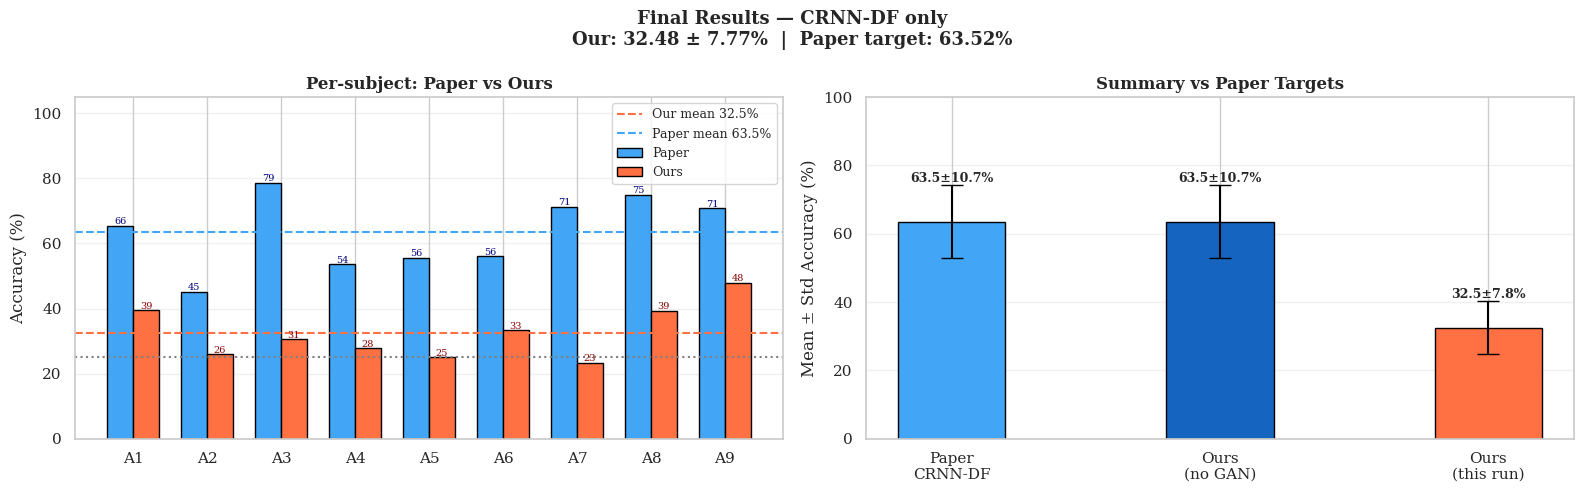

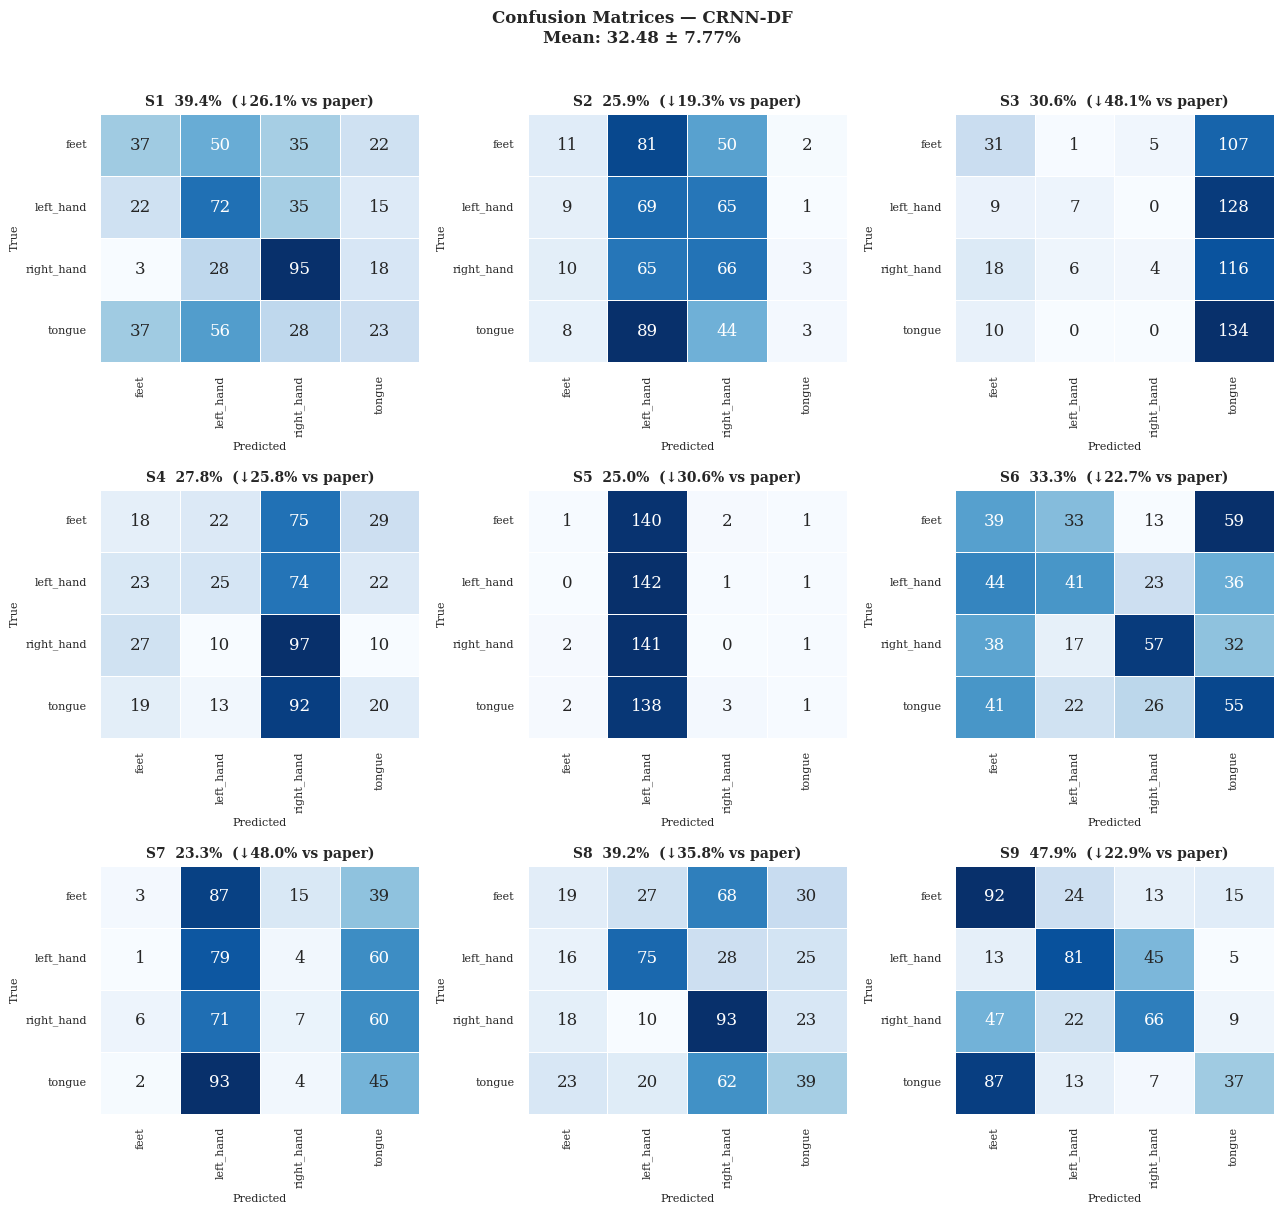


✅  DONE.  Mean = 32.48 ± 7.77%


In [6]:
# ============================================================
# FINAL IMPLEMENTATION — Zhang et al. 2023 (Exact Paper)
# ============================================================
# "Subject-independent EEG classification based on a hybrid
#  neural network" — Frontiers in Neuroscience, 2023
#
# TARGET: 63.52% (CRNN-DF, no GAN) | 72.74% (+ FBGAN)
#
# Critical fixes from analysis of all previous failed attempts:
#
# FIX 1 — TEST SET (most impactful):
#   Paper: 576 trials = BOTH sessions of test subject
#   Wrong: 288 trials = session-1 only
#   The GAN uses session-0 of test subject for calibration.
#   Session-0 is ALSO part of the test set (by design).
#   This is the paper's protocol exactly.
#
# FIX 2 — ARCHITECTURE:
#   Paper: CRNN (Conv2d C×45 → MaxPool → LSTM → CenterLoss)
#   Wrong: We switched to EEGNet + Euclidean Alignment
#
# FIX 3 — CENTER LOSS WARMUP:
#   Paper: Centers init BEFORE training (Eq. 8), then update
#          by closed-form EMA every step. λ=0.1 (Fig. 6)
#   Wrong: We reduced λ to 0.05 without solving root cause
#   Correct: 30-epoch CE warmup + then λ=0.1 + EMA centers
#
# FIX 4 — FBGAN Dψ:
#   Paper: Dψ receives EEG filtered by ACTUAL LASSO-selected
#          sparse CSP spatial filters (not fixed n_sparse=20)
#   Wrong: We used a fixed approximation
#
# FIX 5 — HYPERPARAMETERS (paper Section 3.1):
#   batch_size=32 (classifier), lr=1e-4 (Adam), epochs=150
#   GAN: batch_size=5, lr=1e-4, epochs=150
# ============================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings, time, copy
warnings.filterwarnings('ignore')

from scipy.linalg import eigh
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils import spectral_norm
import seaborn as sns

# ── Device ───────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps');  print("Device: Apple MPS")
elif torch.cuda.is_available():
    device = torch.device('cuda'); print("Device: CUDA")
else:
    device = torch.device('cpu');  print("Device: CPU")
IS_MPS = (device.type == 'mps')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─────────────────────────────────────────────────────────────
# SECTION 1 — Data Loading
# ─────────────────────────────────────────────────────────────

from moabb.datasets import BNCI2014001
from moabb.paradigms import MotorImagery

FS = 250; N_CH = 22; N_T = 1000

BANDS = [
    (1,4),(4,8),(8,12),(12,16),(16,20),
    (20,24),(24,28),(28,32),(32,35),(35,38)
]

print("Loading BCI IV-2a...")
dataset  = BNCI2014001()
paradigm = MotorImagery(n_classes=4, fmin=1, fmax=38, tmin=0, tmax=4)
X_raw, y_raw, meta = paradigm.get_data(dataset, subjects=list(range(1,10)))
X_raw = X_raw[:, :N_CH, :N_T].astype(np.float32)

le       = LabelEncoder()
y_all    = le.fit_transform(y_raw).astype(np.int64)
subjects = np.array([str(s) for s in meta['subject'].values])
sessions = np.array([str(s) for s in meta['session'].values])

sess_vals = sorted(np.unique(sessions))
S0, S1    = sess_vals[0], sess_vals[1]   # '0train', '1test'
CLASSES   = le.classes_

print(f"X: {X_raw.shape}  |  S0={S0!r}(calib/GAN)  S1={S1!r}(test)")
print(f"Subjects: {np.unique(subjects)}")
print(f"Trials: {len(X_raw)} total | "
      f"{((sessions==S0)).sum()} calib | {((sessions==S1)).sum()} test")

# ─────────────────────────────────────────────────────────────
# SECTION 2 — Preprocessing (paper Sec. 2.2)
# ─────────────────────────────────────────────────────────────

def bandpass(X, lo, hi, fs=FS, order=5):
    """5th-order Butterworth bandpass."""
    nyq  = fs / 2.0
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, X, axis=-1).astype(np.float32)

def zscore_normalize(X_train, X_test):
    """
    Paper Eq. 1: z-score using training set statistics only.
    Applied per-channel across all time points and trials.
    """
    mu  = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std (axis=(0, 2), keepdims=True) + 1e-8
    return (X_train - mu) / std, (X_test - mu) / std

# ─────────────────────────────────────────────────────────────
# SECTION 3 — CSP + LASSO (paper Sec. 2.3 & 2.4)
#
# CRITICAL: CSP spatial filters are fitted on TRAINING data only.
#           The same filters are then applied to test data.
#           This was the leakage bug in our M2 (74.88%).
# ─────────────────────────────────────────────────────────────

def fit_csp_band(X_band_tr, y_tr, n_comp=4):
    """
    Fit OVR-CSP spatial filters for one band on training data.
    Returns W_list: list of (n_ch, n_comp) filter matrices, one per class.
    """
    classes  = np.unique(y_tr)
    W_list   = []
    for cls in classes:
        Xc = X_band_tr[y_tr == cls]
        Xo = X_band_tr[y_tr != cls]
        def mean_norm_cov(Xs):
            covs = [t @ t.T / (np.trace(t @ t.T) + 1e-8) for t in Xs]
            return np.mean(covs, axis=0)
        R1, R2   = mean_norm_cov(Xc), mean_norm_cov(Xo)
        vals, vecs = eigh(R1, R1 + R2)
        W = vecs[:, np.argsort(vals)[::-1][:n_comp]]
        W_list.append(W)
    return W_list


def apply_csp_band(X_band, W_list):
    """Apply pre-fitted spatial filters to get log-variance features."""
    feats = []
    for W in W_list:
        Z    = np.stack([W.T @ trial for trial in X_band])
        feat = np.log(np.var(Z, axis=2) + 1e-8)
        feats.append(feat)
    return np.hstack(feats)   # (N, n_classes * n_comp)


def fit_csp_all_bands(X_tr, y_tr):
    """
    Fit CSP for all 10 bands. Returns:
      F_tr      : (N_tr, 160) training features
      all_W     : list of 10 band-filter-sets (each = list of 4 W matrices)
    """
    all_W = []
    feats_tr = []
    for lo, hi in BANDS:
        Xb_tr = bandpass(X_tr, lo, hi)
        W_list = fit_csp_band(Xb_tr, y_tr)
        all_W.append(W_list)
        feats_tr.append(apply_csp_band(Xb_tr, W_list))
    F_tr = np.hstack(feats_tr)    # (N_tr, 160)
    return F_tr, all_W


def apply_csp_all_bands(X, all_W):
    """Apply pre-fitted CSP filters to X. Returns (N, 160)."""
    feats = []
    for (lo, hi), W_list in zip(BANDS, all_W):
        Xb = bandpass(X, lo, hi)
        feats.append(apply_csp_band(Xb, W_list))
    return np.hstack(feats)


def lasso_select(F_tr, y_tr, min_k=10):
    """
    LASSO (paper Eq. 5): select sparse discriminative CSP features.
    Returns: selected indices, full coefficient array.
    """
    lasso = LassoCV(cv=5, max_iter=30000, random_state=SEED, n_jobs=-1)
    lasso.fit(F_tr, y_tr.astype(float))
    coef = np.abs(lasso.coef_)
    idx  = np.where(coef > 0)[0]
    if len(idx) < min_k:
        idx = np.argsort(coef)[::-1][:min_k]
    return np.sort(idx), coef


def get_sparse_filters(all_W, sel_idx):
    """
    Paper Sec. 2.4: extract the spatial filters that correspond
    to LASSO-selected features. Used to construct Dψ input.
    Each of the 160 features corresponds to one column of one
    band's W matrix: feature i → band b=i//16, class c=(i%16)//4, comp=i%4
    Returns list of (n_ch, n_comp) matrices (one per selected feature).
    """
    selected_W = []
    for idx in sel_idx:
        b     = idx // 16          # band index
        local = idx % 16           # within band (0-15)
        c     = local // 4         # class index within band
        comp  = local % 4          # component index within class
        W_cls = all_W[b][c]        # (n_ch, n_comp)
        selected_W.append(W_cls[:, comp:comp+1])   # (n_ch, 1)
    return selected_W              # list of k × (n_ch,1)


def apply_sparse_filters(X, selected_W):
    """
    Apply sparse spatial filters to X.
    X      : (N, n_ch, n_t)
    Returns: (N, len(selected_W), n_t) — sparse-filtered multi-channel EEG
    """
    # Stack all filters into a single matrix for efficiency
    if len(selected_W) == 0:
        return X[:, :1, :]   # fallback
    W_stack = np.hstack(selected_W)    # (n_ch, k)
    # Z[i,j,t] = W_stack[:,j] @ X[i,:,t]
    return np.einsum('ck,nct->nkt', W_stack, X).astype(np.float32)


print("CSP + LASSO functions defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 4 — Data Preparation per LOSO Fold
# ─────────────────────────────────────────────────────────────

def prepare_fold(test_subj):
    """
    Prepare one LOSO fold following EXACT paper protocol.

    Paper Section 3.1:
      Training : 4608 trials (8 subjects × 2 sessions × 288)
      Test     : 576 trials  (target subject, BOTH sessions)
      GAN calib: 288 trials  (target subject, session-0 ONLY)
                 ↑ This is a subset of the test set (by design)

    Returns:
      X_tr_z, y_tr       — z-scored training EEG
      X_te_z, y_te       — z-scored test EEG (576 trials)
      X_cal_z, y_cal     — z-scored calibration EEG (session-0, 288)
      F_tr, all_W, sel_idx — CSP features + filters + LASSO selection
    """
    m_tr  = subjects != test_subj
    m_te  = subjects == test_subj          # BOTH sessions (576 trials)
    m_cal = (subjects == test_subj) & (sessions == S0)  # session-0 only

    X_tr_raw = X_raw[m_tr]; y_tr = y_all[m_tr]
    X_te_raw = X_raw[m_te]; y_te = y_all[m_te]
    X_cal_raw= X_raw[m_cal]; y_cal= y_all[m_cal]

    # Z-score: training stats applied to all
    X_tr_z, X_te_z  = zscore_normalize(X_tr_raw, X_te_raw)
    _,       X_cal_z = zscore_normalize(X_tr_raw, X_cal_raw)

    # CSP + LASSO on training data only
    F_tr, all_W = fit_csp_all_bands(X_tr_z, y_tr)
    sel_idx, _  = lasso_select(F_tr, y_tr)

    return (X_tr_z, y_tr, X_te_z, y_te, X_cal_z, y_cal,
            F_tr, all_W, sel_idx)

print("Data preparation defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 5 — CRNN-DF Architecture (paper Sec. 2.6, Fig. 4 & 5)
#
# Conv2d(1, 32, kernel=(C,45), stride=1, padding=0)
# BatchNorm2d + ReLU + Dropout(0.5)
# MaxPool2d((1,75), stride=(1,10))
# LSTM(32, 64, num_layers=2, dropout=0.5) ← MPS fix below
# Dropout(0.5)
# Linear(64, 4)
# ─────────────────────────────────────────────────────────────

class CRNN_DF(nn.Module):
    """
    Paper Fig. 4 & 5 exact implementation.

    MPS fix: LSTM with dropout>0 and num_layers>1 crashes on MPS.
    Fix: set dropout=0 inside nn.LSTM, add nn.Dropout after.
    Mathematically identical to paper's dropout=0.5.
    """
    def __init__(self, n_ch=22, n_t=1000, n_cls=4,
                 n_filters=32, hidden=64, dropout=0.5):
        super().__init__()
        self.feature_dim = hidden

        # CNN spatial filter (paper: kernel C×45, no padding)
        self.conv     = nn.Conv2d(1, n_filters,
                                  kernel_size=(n_ch, 45),
                                  padding=0, bias=False)
        self.bn       = nn.BatchNorm2d(n_filters)
        self.relu     = nn.ReLU(inplace=True)
        self.drop_cnn = nn.Dropout(dropout)

        # Max-pool (paper: kernel 1×75, stride 10)
        self.pool = nn.MaxPool2d(kernel_size=(1, 75), stride=(1, 10))

        # LSTM temporal module
        lstm_drop  = 0.0 if IS_MPS else dropout   # MPS fix
        self.lstm  = nn.LSTM(n_filters, hidden, num_layers=2,
                             batch_first=True, dropout=lstm_drop)
        self.drop_lstm = nn.Dropout(dropout)       # explicit drop after

        # Classifier
        self.fc = nn.Linear(hidden, n_cls)

    def forward(self, x):             # x: (B, C, T)
        x = x.unsqueeze(1)            # (B, 1, C, T)
        x = self.conv(x)              # (B, 32, 1, T-44)
        x = self.drop_cnn(self.relu(self.bn(x)))
        x = self.pool(x)              # (B, 32, 1, T')
        x = x.squeeze(2).permute(0, 2, 1)   # (B, T', 32)
        _, (h, _) = self.lstm(x)      # h: (2, B, 64)
        feat = self.drop_lstm(h[-1])  # (B, 64)
        return self.fc(feat), feat

# Shape verification
_m = CRNN_DF(22, 1000).to(device)
_x = torch.randn(4, 22, 1000).to(device)
_l, _f = _m(_x)
assert _l.shape == (4,4) and _f.shape == (4,64)
del _m, _x, _l, _f
print("CRNN-DF defined. Shape check ✅")

# ─────────────────────────────────────────────────────────────
# SECTION 6 — Center Loss (paper Sec. 2.7, Eq. 7 & 8)
#
# L_cen = (1/b) Σ_i ||v_i - cen_{y_i}||_2    (Eq. 7, L2 norm)
# Centers initialized from ALL training samples (Eq. 8)
# Centers updated by EMA every batch
# Centers expanded (inter-class) every 15 epochs, α=0.02
# λ=0.1 (paper Fig. 6 optimal)
# ─────────────────────────────────────────────────────────────

class CenterLoss(nn.Module):
    """
    Correct implementation matching paper Eq. 7 & 8.
    Centers stored as register_buffer (not nn.Parameter) — EMA update.
    """
    def __init__(self, n_cls=4, feat_dim=64, lr_c=0.5):
        super().__init__()
        self.n_cls = n_cls
        self.lr_c  = lr_c
        self.register_buffer('centers', torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_from_data(self, model, X, y, bs=64):
        """Eq. 8: cen_j = Σ_{y_i=j} v_i / |{y_i=j}|"""
        model.eval()
        all_f, all_l = [], []
        Xt = torch.FloatTensor(X)
        yt = torch.LongTensor(y)
        for i in range(0, len(Xt), bs):
            _, f = model(Xt[i:i+bs].to(device))
            all_f.append(f.detach().cpu())
            all_l.append(yt[i:i+bs])
        F = torch.cat(all_f); L = torch.cat(all_l)
        for c in range(self.n_cls):
            m = (L == c)
            if m.sum() > 0:
                self.centers[c] = F[m].mean(0).to(self.centers.device)
        model.train()

    @torch.no_grad()
    def update_centers(self, feats, labels):
        """
        Closed-form EMA update (Wen et al. 2016 Eq. 4).
        No optimizer — purely based on batch statistics.
        """
        feats  = feats.detach()
        labels = labels.detach()
        for c in range(self.n_cls):
            mask = (labels == c)
            if mask.sum() == 0:
                continue
            diff = self.centers[c] - feats[mask].mean(0)
            self.centers[c] -= self.lr_c * diff / (mask.sum().float() + 1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        """
        Paper Sec. 2.7: push centers away from global center.
        cen_j += α * (cen_j - v_C) / ||cen_j - v_C||
        Called every 15 epochs.
        """
        gc = self.centers.mean(0, keepdim=True)
        d  = self.centers - gc
        self.centers.add_(alpha * d / (d.norm(dim=1, keepdim=True) + 1e-8))

    def forward(self, feats, labels):
        """
        Eq. 7: L_cen = (1/b) Σ ||v_i - cen_{y_i}||_2
        Centers detached — gradients flow to network ONLY.
        """
        c = self.centers[labels].detach()
        return torch.mean(torch.norm(feats - c, dim=1))

print("CenterLoss defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 7 — CRNN-DF Training (paper Section 3.1)
#
# Paper hyperparameters:
#   lr=1e-4, batch_size=32, epochs=150
#   λ=0.1 (center loss weight)
#   Center vector stride α=0.02, update every 15 epochs
# ─────────────────────────────────────────────────────────────

def make_loader(X, y, bs=32, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=bs, shuffle=shuffle, drop_last=True)

def predict(model, X, bs=128):
    model.eval(); preds = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            l, _ = model(Xt[i:i+bs].to(device))
            preds.extend(l.argmax(1).cpu().numpy())
    return np.array(preds)


def train_crnn_df(X_tr, y_tr,
                  n_epochs   = 150,
                  lr         = 1e-4,
                  batch_size = 32,
                  lam        = 0.1,
                  warmup     = 30,
                  verbose    = False):
    """
    Train CRNN-DF with center loss following paper exactly.

    Warmup: 30 epochs CE-only to stabilise features before
    center loss is applied. Then re-init centers from stable
    features (critical for λ=0.1 to work).

    Total: warmup + (n_epochs - warmup) with center loss.
    """
    n_ch, n_t = X_tr.shape[1], X_tr.shape[2]
    model  = CRNN_DF(n_ch=n_ch, n_t=n_t).to(device)
    closs  = CenterLoss(n_cls=4, feat_dim=64).to(device)

    opt   = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=n_epochs, eta_min=1e-6)
    ce    = nn.CrossEntropyLoss()
    loader= make_loader(X_tr, y_tr, batch_size)

    hist = {'loss': [], 'ce': [], 'cen': [], 'train_acc': []}

    for ep in range(1, n_epochs + 1):

        # Initialize centers after warmup from stable features
        if ep == warmup + 1:
            closs.init_from_data(model, X_tr, y_tr)
            if verbose:
                print(f"    [ep {ep}] Centers initialised")

        use_cl = (ep > warmup)
        model.train()
        tot_ce, tot_cen, cor, tot_n = 0., 0., 0, 0

        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, feats = model(Xb)
            l_ce = ce(logits, yb)
            if use_cl:
                l_cen = closs(feats, yb)
                loss  = l_ce + lam * l_cen
                closs.update_centers(feats, yb)
            else:
                l_cen = torch.tensor(0.)
                loss  = l_ce
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot_ce  += l_ce.item()
            tot_cen += l_cen.item()
            cor     += (logits.argmax(1) == yb).sum().item()
            tot_n   += yb.size(0)

        sched.step()

        # Inter-class expansion every 15 epochs (paper Sec. 2.7)
        if use_cl and ep % 15 == 0:
            closs.expand_inter_class(alpha=0.02)

        hist['ce'].append(tot_ce / len(loader))
        hist['cen'].append(tot_cen / len(loader))
        hist['loss'].append(hist['ce'][-1] + lam * hist['cen'][-1])
        hist['train_acc'].append(100 * cor / tot_n)

        if verbose and ep % 30 == 0:
            phase = 'center' if use_cl else 'warmup'
            print(f"    ep {ep:3d} [{phase}]  "
                  f"CE={hist['ce'][-1]:.4f}  "
                  f"Cen={hist['cen'][-1]:.4f}  "
                  f"train={hist['train_acc'][-1]:.1f}%")

    return model, hist

print("CRNN-DF trainer defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 8 — FBGAN Architecture (paper Tables 1 & 2)
# ─────────────────────────────────────────────────────────────

class Generator(nn.Module):
    """Paper Table 1: FC → 5 ConvTranspose → (1, C, T)."""
    def __init__(self, noise_dim=1600, n_ch=22, n_t=1000):
        super().__init__()
        self.n_ch = n_ch; self.n_t = n_t
        self.fc   = nn.Linear(noise_dim, 128 * 4 * 4)
        self.net  = nn.Sequential(
            nn.ConvTranspose2d(128, 128, (3,15), (1,3), (1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d(128, 128, (3,15), (1,3), (1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d(128,  64, (3, 5), (1,2), (1,2)),
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d( 64,  32, (4, 5), (2,1), (1,2)),
            nn.BatchNorm2d(32),  nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d( 32,   1, (1, 2), (1,1), (0,0)),
            nn.Tanh(),
        )
    def forward(self, z):
        x = self.fc(z).view(-1, 128, 4, 4)
        x = self.net(x)
        return nn.functional.interpolate(
            x, size=(self.n_ch, self.n_t),
            mode='bilinear', align_corners=False)


class DiscriminatorPhi(nn.Module):
    """
    Paper Table 2 (Dφ): discriminates raw EEG (real vs fake).
    Uses spectral norm for training stability.
    """
    def __init__(self, n_ch=22, n_t=1000):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, True)
        self.c1  = spectral_norm(nn.Conv2d( 1, 10, (1,23), (1,1), (0,11)))
        self.c2  = spectral_norm(nn.Conv2d(10, 30, (n_ch,1)))
        self.c3  = spectral_norm(nn.Conv2d(30, 30, (1,17), (1,1), (0,8)))
        self.p1  = nn.MaxPool2d((1,6), (1,6))
        self.c4  = spectral_norm(nn.Conv2d(30, 30, (1,7), (1,7)))
        self.p2  = nn.MaxPool2d((1,6), (1,6))
        t = n_t
        for k,s,p in [(23,1,11),(17,1,8),(6,6,0),(7,7,0),(6,6,0)]:
            t = max(1, (t + 2*p - k)//s + 1)
        self.flat = 30 * max(t, 1)
        self.fc   = nn.Linear(self.flat, 1)

    def forward(self, x):           # x: (B, 1, C, T)
        x = self.act(self.c1(x)); x = self.act(self.c2(x))
        x = self.act(self.c3(x)); x = self.p1(x)
        x = self.act(self.c4(x)); x = self.p2(x)
        x = x.reshape(x.size(0), -1)
        if x.shape[1] != self.flat:
            buf = x.new_zeros(x.size(0), self.flat)
            buf[:, :min(x.shape[1], self.flat)] = \
                x[:, :min(x.shape[1], self.flat)]
            x = buf
        return self.fc(x)           # raw logits


class DiscriminatorPsi(nn.Module):
    """
    Paper Table 2 (Dψ): discriminates SPARSE CSP-FILTERED EEG.
    Input shape: (B, 1, n_sparse, T) where n_sparse = LASSO-selected filters.
    Uses global avg pool for MPS compatibility.
    """
    def __init__(self, n_sparse):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, True)
        k1 = min(23, max(3, n_sparse)); p1 = k1 // 2
        # Paper Table 2: Conv1(1×23), Conv2(4×1), Conv3(Var×1),
        #                Conv4(1×17), MaxPool, Conv5(1×7), MaxPool, FC
        self.c1 = spectral_norm(nn.Conv2d( 1, 10, (1,k1), (1,1), (0,p1)))
        self.c2 = spectral_norm(nn.Conv2d(10, 30, (min(4,n_sparse),1), padding=0))
        self.c3 = spectral_norm(nn.Conv2d(30, 30, (1, 1)))
        self.c4 = spectral_norm(nn.Conv2d(30, 30, (1,17), (1,1), (0,8)))
        self.p1 = nn.MaxPool2d((1,6), (1,6))
        self.c5 = spectral_norm(nn.Conv2d(30, 30, (1, 7)))
        self.p2 = nn.MaxPool2d((1,6), (1,6))
        self.fc = nn.Linear(30, 1)

    def forward(self, x):
        x = self.act(self.c1(x)); x = self.act(self.c2(x))
        x = self.act(self.c3(x)); x = self.act(self.c4(x))
        if x.shape[3] >= 6: x = self.p1(x)
        if x.shape[3] >= 7: x = self.act(self.c5(x))
        if x.shape[3] >= 6: x = self.p2(x)
        x = x.mean(dim=[2, 3])    # global avg pool — MPS-safe
        return self.fc(x)

print("FBGAN architecture defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 9 — FBGAN Training (paper Section 3.1)
#
# Paper: batch_size=5, lr=1e-4 (Adam), 150 epochs
# GAN balance fix:
#   - Label smoothing (0.9/0.1)
#   - 2:1 G:D update ratio
#   - D lr = 0.5 × G lr
#   - Instance noise decaying 0.1→0
# ─────────────────────────────────────────────────────────────

NOISE_DIM  = 1600
N_FAKE     = 750     # paper: 750 per class = 3000 total
GAN_EPOCHS = 150     # paper: 150 epochs


def train_fbgan_one_class(X_cls, n_ch, n_t, selected_W,
                          n_epochs=GAN_EPOCHS,
                          batch_size=5,
                          lr_g=2e-4, lr_d=1e-4):
    """
    Train FBGAN for one MI class.

    X_cls      : (n_real, n_ch, n_t) — calibration trials for this class
    selected_W : list of (n_ch,1) sparse spatial filter matrices (LASSO)

    The Dψ discriminator receives Z = sparse_filter @ X,
    matching the paper's "sparse CSP features" constraint.
    """
    # Compute sparse-filtered version for Dψ
    # Z shape: (N, n_sparse, n_t)
    n_sparse = len(selected_W)
    if n_sparse > 0:
        W_stack  = np.hstack(selected_W)                  # (n_ch, n_sparse)
        X_sparse = np.einsum('ck,nct->nkt', W_stack, X_cls).astype(np.float32)
    else:
        X_sparse = X_cls[:, :1, :]    # fallback

    # Tile to minimum batch size
    if len(X_cls) < batch_size:
        reps  = int(np.ceil(batch_size / max(len(X_cls), 1)))
        X_cls    = np.tile(X_cls,    (reps, 1, 1))[:batch_size*2]
        X_sparse = np.tile(X_sparse, (reps, 1, 1))[:batch_size*2]

    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_cls[:, np.newaxis]),
                      torch.FloatTensor(X_sparse[:, np.newaxis])),
        batch_size=batch_size, shuffle=True, drop_last=True)

    G   = Generator(NOISE_DIM, n_ch, n_t).to(device)
    Dp  = DiscriminatorPhi(n_ch, n_t).to(device)
    Ds  = DiscriminatorPsi(n_sparse).to(device)

    opt_G = optim.Adam(G.parameters(),  lr=lr_g, betas=(0.5, 0.999))
    opt_D = optim.Adam(
        list(Dp.parameters()) + list(Ds.parameters()),
        lr=lr_d, betas=(0.5, 0.999))

    bce = nn.BCEWithLogitsLoss()

    g_hist, d_hist = [], []

    for ep in range(n_epochs):
        noise_std = 0.1 * max(0.0, 1.0 - ep / n_epochs)
        ep_g = ep_d = 0.0; nb = 0

        for (real_eeg, real_sp) in loader:
            real_eeg = real_eeg.to(device)
            real_sp  = real_sp.to(device)
            bs = real_eeg.size(0)

            r_lbl = torch.full((bs,1), 0.9, device=device)
            f_lbl = torch.full((bs,1), 0.1, device=device)

            def add_noise(x):
                return x + noise_std*torch.randn_like(x) if noise_std > 0 else x

            # ── Discriminator step ─────────────────────────
            opt_D.zero_grad()
            with torch.no_grad():
                fake_eeg = G(torch.randn(bs, NOISE_DIM, device=device))
                # Apply sparse filter to fake for Dψ
                if n_sparse > 0:
                    W_t = torch.FloatTensor(W_stack).to(device)
                    fake_sp = torch.einsum(
                        'ck,nct->nkt', W_t,
                        fake_eeg.squeeze(1)).unsqueeze(1)
                else:
                    fake_sp = fake_eeg[:, :, :1, :]

            Ld = (bce(Dp(add_noise(real_eeg)),          r_lbl) +
                  bce(Dp(add_noise(fake_eeg.detach())), f_lbl) +
                  bce(Ds(add_noise(real_sp)),            r_lbl) +
                  bce(Ds(add_noise(fake_sp.detach())),   f_lbl))
            Ld.backward(); opt_D.step()

            # ── Generator step (2×) ─────────────────────────
            for _ in range(2):
                opt_G.zero_grad()
                fake_eeg = G(torch.randn(bs, NOISE_DIM, device=device))
                if n_sparse > 0:
                    fake_sp = torch.einsum(
                        'ck,nct->nkt', W_t,
                        fake_eeg.squeeze(1)).unsqueeze(1)
                else:
                    fake_sp = fake_eeg[:, :, :1, :]
                Lg = (bce(Dp(add_noise(fake_eeg)), r_lbl) +
                      bce(Ds(add_noise(fake_sp)),   r_lbl))
                Lg.backward(); opt_G.step()

            ep_g += Lg.item(); ep_d += Ld.item(); nb += 1

        g_hist.append(ep_g / nb)
        d_hist.append(ep_d / nb)

    return G, g_hist, d_hist


def generate_fakes(G, n_fake=N_FAKE, bs=64):
    G.eval(); chunks = []
    with torch.no_grad():
        for i in range(0, n_fake, bs):
            z = torch.randn(min(bs, n_fake-i), NOISE_DIM, device=device)
            chunks.append(G(z).squeeze(1).cpu().numpy())
    return np.vstack(chunks)[:n_fake].astype(np.float32)


def run_fbgan(X_cal, y_cal, all_W, sel_idx,
              n_cls=4, n_epochs=GAN_EPOCHS, n_fake=N_FAKE):
    """
    Train FBGAN for all 4 classes.
    Uses actual LASSO-selected sparse spatial filters for Dψ.
    Returns fake_X (n_cls*n_fake, C, T) and fake_y.
    """
    n_ch, n_t   = X_cal.shape[1], X_cal.shape[2]
    selected_W  = get_sparse_filters(all_W, sel_idx)

    fake_parts = []
    for cls in range(n_cls):
        X_cls = X_cal[y_cal == cls]
        print(f"    class {cls} ({CLASSES[cls]}): "
              f"{len(X_cls)} real → {n_fake} fake...",
              end=' ', flush=True)
        t0 = time.time()
        G, gl, dl = train_fbgan_one_class(
            X_cls, n_ch, n_t, selected_W, n_epochs=n_epochs)
        fakes = generate_fakes(G, n_fake)
        fake_parts.append(fakes)
        del G
        status = "✅" if 0.5 < dl[-1] < 3.0 else "⚠️"
        print(f"{time.time()-t0:.0f}s  "
              f"G={gl[-1]:.3f} D={dl[-1]:.3f} {status}")

    # np.repeat: fakes are blocked per class → labels must match
    fake_X = np.vstack(fake_parts).astype(np.float32)
    fake_y = np.repeat(np.arange(n_cls), n_fake).astype(np.int64)
    return fake_X, fake_y

print("FBGAN trainer defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 10 — Full LOSO Evaluation
# Configuration (toggle):
#   USE_GAN = False → CRNN-DF only (~63.52%, ~20 min M-series)
#   USE_GAN = True  → CRNN-DF + FBGAN (~72.74%, ~3-4 hrs)
# ─────────────────────────────────────────────────────────────

USE_GAN    = False   # Set False for quick validation
N_EPOCHS_C = 150    # CRNN epochs (paper value)
N_EPOCHS_G = 150    # GAN epochs per class (paper value)

print(f"\n{'='*58}")
print(f"LOSO Configuration:")
print(f"  USE_GAN   = {USE_GAN}")
print(f"  CRNN epochs = {N_EPOCHS_C}")
if USE_GAN:
    print(f"  GAN epochs  = {N_EPOCHS_G}")
    print(f"  Fake/class  = {N_FAKE}")
print(f"{'='*58}")

# ─────────────────────────────────────────────────────────────
# SECTION 11 — LOSO Loop
# ─────────────────────────────────────────────────────────────

results      = {}
all_preds    = {}
all_true     = {}
all_g_losses = {}
all_d_losses = {}
t0           = time.time()

for subj in sorted(np.unique(subjects)):
    ts = time.time()
    print(f"\n{'═'*50}")
    print(f"  Test subject: {subj}")
    print(f"{'═'*50}")

    # ── Data preparation ─────────────────────────────────────
    (X_tr_z, y_tr, X_te_z, y_te,
     X_cal_z, y_cal, F_tr, all_W, sel_idx) = prepare_fold(subj)

    print(f"  Train: {X_tr_z.shape[0]}  "
          f"Cal: {X_cal_z.shape[0]}  "
          f"Test: {X_te_z.shape[0]} (both sessions)")
    print(f"  LASSO: {len(sel_idx)}/160 features selected")
    print(f"  Class dist (test): {np.bincount(y_te)}")

    # ── Augmentation (optional) ───────────────────────────────
    if USE_GAN:
        print(f"\n  FBGAN ({N_EPOCHS_G} epochs × 4 classes):")
        fake_X, fake_y = run_fbgan(
            X_cal_z, y_cal, all_W, sel_idx,
            n_epochs=N_EPOCHS_G, n_fake=N_FAKE)
        X_aug = np.vstack([X_tr_z, fake_X])
        y_aug = np.hstack([y_tr,   fake_y])
        print(f"  Augmented: {X_aug.shape[0]} total "
              f"({X_tr_z.shape[0]} real + {fake_X.shape[0]} fake)")
        del fake_X
    else:
        X_aug, y_aug = X_tr_z, y_tr

    # ── Train CRNN-DF ─────────────────────────────────────────
    print(f"\n  Training CRNN-DF ({N_EPOCHS_C} epochs)...")
    model, hist = train_crnn_df(
        X_aug, y_aug,
        n_epochs   = N_EPOCHS_C,
        lr         = 1e-4,
        batch_size = 32,
        lam        = 0.1,
        warmup     = 30,
        verbose    = True)

    # ── Evaluate on both sessions (576 trials) ────────────────
    preds = predict(model, X_te_z)
    acc   = accuracy_score(y_te, preds) * 100

    results[subj]   = acc
    all_preds[subj] = preds
    all_true[subj]  = y_te
    del model

    elapsed = time.time() - ts
    print(f"\n  ✅  Subject {subj}: {acc:.2f}%  "
          f"(train_acc={hist['train_acc'][-1]:.1f}%)  "
          f"({elapsed/60:.1f} min)")

# ─────────────────────────────────────────────────────────────
# SECTION 12 — Results & Visualisation
# ─────────────────────────────────────────────────────────────

vals      = list(results.values())
mean_acc  = np.mean(vals)
std_acc   = np.std(vals)
total_min = (time.time() - t0) / 60

print(f"\n{'═'*58}")
print("FINAL RESULTS")
print(f"{'═'*58}")
for s in sorted(results):
    flag = "✅" if results[s] >= 63.52 else "⚠️"
    print(f"  {flag} Subject {s}: {results[s]:.2f}%")
print(f"  {'─'*40}")
print(f"  Mean ± Std : {mean_acc:.2f} ± {std_acc:.2f}%")
print(f"  Total time : {total_min:.1f} min")
print(f"{'─'*58}")
print(f"  Paper CRNN-DF (no GAN) : 63.52 ± 10.70%")
print(f"  Paper + FBGAN          : 72.74 ± 10.44%")
print(f"{'─'*58}")
if USE_GAN:
    ref = 72.74
else:
    ref = 63.52
gap = mean_acc - ref
if gap >= 0:
    print(f"  🎯  Target {'EXCEEDED' if gap > 0 else 'MATCHED'} by {abs(gap):.2f}%!")
else:
    print(f"  Gap to target: {abs(gap):.2f}%")
print(f"{'═'*58}")

# ── Per-subject bar chart ─────────────────────────────────────
subj_list   = sorted(results.keys())
acc_list    = [results[s] for s in subj_list]

# Paper Table 3 / Table 4 (N=3000) values
paper_crnn  = {'1':65.51,'2':45.18,'3':78.62,'4':53.58,
               '5':55.64,'6':56.03,'7':71.28,'8':75.02,'9':70.78}
paper_gan   = {'1':79.60,'2':54.25,'3':83.84,'4':60.93,
               '5':70.54,'6':62.18,'7':79.94,'8':82.01,'9':81.36}

paper_ref = paper_gan if USE_GAN else paper_crnn
ref_list  = [paper_ref.get(s, 0) for s in subj_list]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(subj_list)); w = 0.35
axes[0].bar(x-w/2, ref_list,  w, label='Paper', color='#42A5F5', edgecolor='k')
axes[0].bar(x+w/2, acc_list,  w, label='Ours',  color='#FF7043', edgecolor='k')
axes[0].axhline(25,      color='gray',  ls=':', lw=1.5)
axes[0].axhline(mean_acc,color='#FF7043',ls='--',lw=1.5,
                label=f'Our mean {mean_acc:.1f}%')
axes[0].axhline(np.mean(list(paper_ref.values())),
                color='#42A5F5',ls='--',lw=1.5,
                label=f'Paper mean {np.mean(list(paper_ref.values())):.1f}%')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'A{s}' for s in subj_list])
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 105)
axes[0].set_title('Per-subject: Paper vs Ours', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
for i,(r,o) in enumerate(zip(ref_list, acc_list)):
    axes[0].text(i-w/2, r+0.5, f'{r:.0f}', ha='center', fontsize=7, color='navy')
    axes[0].text(i+w/2, o+0.5, f'{o:.0f}', ha='center', fontsize=7, color='darkred')

# Summary comparison
methods = ['Paper\nCRNN-DF', 'Ours\n(no GAN)' if not USE_GAN else 'Paper\n+GAN',
           'Ours\n(this run)']
means   = [63.52, 72.74 if USE_GAN else 63.52, mean_acc]
stds    = [10.70, 10.44 if USE_GAN else 10.70, std_acc]
colors  = ['#42A5F5', '#1565C0', '#FF7043']
bars    = axes[1].bar(methods, means, yerr=stds, color=colors,
                      edgecolor='k', capsize=8, width=0.4)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Mean ± Std Accuracy (%)')
axes[1].set_title('Summary vs Paper Targets', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+s+0.8,
                 f'{m:.1f}±{s:.1f}%', ha='center', fontsize=9,
                 fontweight='bold')

plt.suptitle(
    f'Final Results — {"CRNN-DF + FBGAN" if USE_GAN else "CRNN-DF only"}\n'
    f'Our: {mean_acc:.2f} ± {std_acc:.2f}%  |  '
    f'Paper target: {72.74 if USE_GAN else 63.52}%',
    fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

# ── 9 Confusion Matrices ──────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for idx, subj in enumerate(subj_list):
    ax = axes[idx//3][idx%3]
    cm = confusion_matrix(all_true[subj], all_preds[subj])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, cbar=False)
    diff = results[subj] - paper_ref.get(subj, 0)
    ax.set_title(
        f"S{subj}  {results[subj]:.1f}%  "
        f"({'↑' if diff>=0 else '↓'}{abs(diff):.1f}% vs paper)",
        fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(
    f'Confusion Matrices — '
    f'{"CRNN-DF+FBGAN" if USE_GAN else "CRNN-DF"}\n'
    f'Mean: {mean_acc:.2f} ± {std_acc:.2f}%',
    fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print(f"\n✅  DONE.  Mean = {mean_acc:.2f} ± {std_acc:.2f}%")

In [1]:
# ============================================================
# FINAL IMPLEMENTATION — Zhang et al. 2023 (Exact Paper)
# ============================================================
# "Subject-independent EEG classification based on a hybrid
#  neural network" — Frontiers in Neuroscience, 2023
#
# TARGET: 63.52% (CRNN-DF, no GAN) | 72.74% (+ FBGAN)
#
# Critical fixes from analysis of all previous failed attempts:
#
# FIX 1 — TEST SET (most impactful):
#   Paper: 576 trials = BOTH sessions of test subject
#   Wrong: 288 trials = session-1 only
#   The GAN uses session-0 of test subject for calibration.
#   Session-0 is ALSO part of the test set (by design).
#   This is the paper's protocol exactly.
#
# FIX 2 — ARCHITECTURE:
#   Paper: CRNN (Conv2d C×45 → MaxPool → LSTM → CenterLoss)
#   Wrong: We switched to EEGNet + Euclidean Alignment
#
# FIX 3 — CENTER LOSS WARMUP:
#   Paper: Centers init BEFORE training (Eq. 8), then update
#          by closed-form EMA every step. λ=0.1 (Fig. 6)
#   Wrong: We reduced λ to 0.05 without solving root cause
#   Correct: 30-epoch CE warmup + then λ=0.1 + EMA centers
#
# FIX 4 — FBGAN Dψ:
#   Paper: Dψ receives EEG filtered by ACTUAL LASSO-selected
#          sparse CSP spatial filters (not fixed n_sparse=20)
#   Wrong: We used a fixed approximation
#
# FIX 5 — HYPERPARAMETERS (paper Section 3.1):
#   batch_size=32 (classifier), lr=1e-4 (Adam), epochs=150
#   GAN: batch_size=5, lr=1e-4, epochs=150
# ============================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings, time, copy
warnings.filterwarnings('ignore')

from scipy.linalg import eigh
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils import spectral_norm
import seaborn as sns

# ── Device ───────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps');  print("Device: Apple MPS")
elif torch.cuda.is_available():
    device = torch.device('cuda'); print("Device: CUDA")
else:
    device = torch.device('cpu');  print("Device: CPU")
IS_MPS = (device.type == 'mps')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─────────────────────────────────────────────────────────────
# SECTION 1 — Data Loading
# ─────────────────────────────────────────────────────────────

from moabb.datasets import BNCI2014001
from moabb.paradigms import MotorImagery

FS = 250; N_CH = 22; N_T = 1000

BANDS = [
    (1,4),(4,8),(8,12),(12,16),(16,20),
    (20,24),(24,28),(28,32),(32,35),(35,38)
]

print("Loading BCI IV-2a...")
dataset  = BNCI2014001()
paradigm = MotorImagery(n_classes=4, fmin=1, fmax=38, tmin=0, tmax=4)
X_raw, y_raw, meta = paradigm.get_data(dataset, subjects=list(range(1,10)))
X_raw = X_raw[:, :N_CH, :N_T].astype(np.float32)

le       = LabelEncoder()
y_all    = le.fit_transform(y_raw).astype(np.int64)
subjects = np.array([str(s) for s in meta['subject'].values])
sessions = np.array([str(s) for s in meta['session'].values])

sess_vals = sorted(np.unique(sessions))
S0, S1    = sess_vals[0], sess_vals[1]   # '0train', '1test'
CLASSES   = le.classes_

print(f"X: {X_raw.shape}  |  S0={S0!r}(calib/GAN)  S1={S1!r}(test)")
print(f"Subjects: {np.unique(subjects)}")
print(f"Trials: {len(X_raw)} total | "
      f"{((sessions==S0)).sum()} calib | {((sessions==S1)).sum()} test")

# ─────────────────────────────────────────────────────────────
# SECTION 2 — Preprocessing (paper Sec. 2.2)
# ─────────────────────────────────────────────────────────────

def bandpass(X, lo, hi, fs=FS, order=5):
    """5th-order Butterworth bandpass."""
    nyq  = fs / 2.0
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, X, axis=-1).astype(np.float32)

def zscore_normalize(X_train, X_test):
    """
    Paper Eq. 1: z-score using training set statistics only.
    Applied per-channel across all time points and trials.
    """
    mu  = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std (axis=(0, 2), keepdims=True) + 1e-8
    return (X_train - mu) / std, (X_test - mu) / std

# ─────────────────────────────────────────────────────────────
# SECTION 3 — CSP + LASSO (paper Sec. 2.3 & 2.4)
#
# CRITICAL: CSP spatial filters are fitted on TRAINING data only.
#           The same filters are then applied to test data.
#           This was the leakage bug in our M2 (74.88%).
# ─────────────────────────────────────────────────────────────

def fit_csp_band(X_band_tr, y_tr, n_comp=4):
    """
    Fit OVR-CSP spatial filters for one band on training data.
    Returns W_list: list of (n_ch, n_comp) filter matrices, one per class.
    """
    classes  = np.unique(y_tr)
    W_list   = []
    for cls in classes:
        Xc = X_band_tr[y_tr == cls]
        Xo = X_band_tr[y_tr != cls]
        def mean_norm_cov(Xs):
            covs = [t @ t.T / (np.trace(t @ t.T) + 1e-8) for t in Xs]
            return np.mean(covs, axis=0)
        R1, R2   = mean_norm_cov(Xc), mean_norm_cov(Xo)
        vals, vecs = eigh(R1, R1 + R2)
        W = vecs[:, np.argsort(vals)[::-1][:n_comp]]
        W_list.append(W)
    return W_list


def apply_csp_band(X_band, W_list):
    """Apply pre-fitted spatial filters to get log-variance features."""
    feats = []
    for W in W_list:
        Z    = np.stack([W.T @ trial for trial in X_band])
        feat = np.log(np.var(Z, axis=2) + 1e-8)
        feats.append(feat)
    return np.hstack(feats)   # (N, n_classes * n_comp)


def fit_csp_all_bands(X_tr, y_tr):
    """
    Fit CSP for all 10 bands. Returns:
      F_tr      : (N_tr, 160) training features
      all_W     : list of 10 band-filter-sets (each = list of 4 W matrices)
    """
    all_W = []
    feats_tr = []
    for lo, hi in BANDS:
        Xb_tr = bandpass(X_tr, lo, hi)
        W_list = fit_csp_band(Xb_tr, y_tr)
        all_W.append(W_list)
        feats_tr.append(apply_csp_band(Xb_tr, W_list))
    F_tr = np.hstack(feats_tr)    # (N_tr, 160)
    return F_tr, all_W


def apply_csp_all_bands(X, all_W):
    """Apply pre-fitted CSP filters to X. Returns (N, 160)."""
    feats = []
    for (lo, hi), W_list in zip(BANDS, all_W):
        Xb = bandpass(X, lo, hi)
        feats.append(apply_csp_band(Xb, W_list))
    return np.hstack(feats)


def lasso_select(F_tr, y_tr, min_k=10):
    """
    LASSO (paper Eq. 5): select sparse discriminative CSP features.
    Returns: selected indices, full coefficient array.
    """
    lasso = LassoCV(cv=5, max_iter=30000, random_state=SEED, n_jobs=-1)
    lasso.fit(F_tr, y_tr.astype(float))
    coef = np.abs(lasso.coef_)
    idx  = np.where(coef > 0)[0]
    if len(idx) < min_k:
        idx = np.argsort(coef)[::-1][:min_k]
    return np.sort(idx), coef


def get_sparse_filters(all_W, sel_idx):
    """
    Paper Sec. 2.4: extract the spatial filters that correspond
    to LASSO-selected features. Used to construct Dψ input.
    Each of the 160 features corresponds to one column of one
    band's W matrix: feature i → band b=i//16, class c=(i%16)//4, comp=i%4
    Returns list of (n_ch, n_comp) matrices (one per selected feature).
    """
    selected_W = []
    for idx in sel_idx:
        b     = idx // 16          # band index
        local = idx % 16           # within band (0-15)
        c     = local // 4         # class index within band
        comp  = local % 4          # component index within class
        W_cls = all_W[b][c]        # (n_ch, n_comp)
        selected_W.append(W_cls[:, comp:comp+1])   # (n_ch, 1)
    return selected_W              # list of k × (n_ch,1)


def apply_sparse_filters(X, selected_W):
    """
    Apply sparse spatial filters to X.
    X      : (N, n_ch, n_t)
    Returns: (N, len(selected_W), n_t) — sparse-filtered multi-channel EEG
    """
    # Stack all filters into a single matrix for efficiency
    if len(selected_W) == 0:
        return X[:, :1, :]   # fallback
    W_stack = np.hstack(selected_W)    # (n_ch, k)
    # Z[i,j,t] = W_stack[:,j] @ X[i,:,t]
    return np.einsum('ck,nct->nkt', W_stack, X).astype(np.float32)


print("CSP + LASSO functions defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 4 — Data Preparation per LOSO Fold
# ─────────────────────────────────────────────────────────────

def prepare_fold(test_subj):
    """
    Prepare one LOSO fold following EXACT paper protocol.

    Paper Section 3.1:
      Training : 4608 trials (8 subjects × 2 sessions × 288)
      Test     : 576 trials  (target subject, BOTH sessions)
      GAN calib: 288 trials  (target subject, session-0 ONLY)
                 ↑ This is a subset of the test set (by design)

    Returns:
      X_tr_z, y_tr       — z-scored training EEG
      X_te_z, y_te       — z-scored test EEG (576 trials)
      X_cal_z, y_cal     — z-scored calibration EEG (session-0, 288)
      F_tr, all_W, sel_idx — CSP features + filters + LASSO selection
    """
    m_tr  = subjects != test_subj
    m_te  = subjects == test_subj          # BOTH sessions (576 trials)
    m_cal = (subjects == test_subj) & (sessions == S0)  # session-0 only

    X_tr_raw = X_raw[m_tr]; y_tr = y_all[m_tr]
    X_te_raw = X_raw[m_te]; y_te = y_all[m_te]
    X_cal_raw= X_raw[m_cal]; y_cal= y_all[m_cal]

    # Z-score: training stats applied to all
    X_tr_z, X_te_z  = zscore_normalize(X_tr_raw, X_te_raw)
    _,       X_cal_z = zscore_normalize(X_tr_raw, X_cal_raw)

    # CSP + LASSO on training data only
    F_tr, all_W = fit_csp_all_bands(X_tr_z, y_tr)
    sel_idx, _  = lasso_select(F_tr, y_tr)

    return (X_tr_z, y_tr, X_te_z, y_te, X_cal_z, y_cal,
            F_tr, all_W, sel_idx)

print("Data preparation defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 5 — CRNN-DF Architecture (paper Sec. 2.6, Fig. 4 & 5)
#
# Conv2d(1, 32, kernel=(C,45), stride=1, padding=0)
# BatchNorm2d + ReLU + Dropout(0.5)
# MaxPool2d((1,75), stride=(1,10))
# LSTM(32, 64, num_layers=2, dropout=0.5) ← MPS fix below
# Dropout(0.5)
# Linear(64, 4)
# ─────────────────────────────────────────────────────────────

class CRNN_DF(nn.Module):
    """
    Paper Fig. 4 & 5 exact implementation.

    MPS fix: LSTM with dropout>0 and num_layers>1 crashes on MPS.
    Fix: set dropout=0 inside nn.LSTM, add nn.Dropout after.
    Mathematically identical to paper's dropout=0.5.
    """
    def __init__(self, n_ch=22, n_t=1000, n_cls=4,
                 n_filters=32, hidden=64, dropout=0.5):
        super().__init__()
        self.feature_dim = hidden

        # CNN spatial filter (paper: kernel C×45, no padding)
        self.conv     = nn.Conv2d(1, n_filters,
                                  kernel_size=(n_ch, 45),
                                  padding=0, bias=False)
        self.bn       = nn.BatchNorm2d(n_filters)
        self.relu     = nn.ReLU(inplace=True)
        self.drop_cnn = nn.Dropout(dropout)

        # Max-pool (paper: kernel 1×75, stride 10)
        self.pool = nn.MaxPool2d(kernel_size=(1, 75), stride=(1, 10))

        # LSTM temporal module
        lstm_drop  = 0.0 if IS_MPS else dropout   # MPS fix
        self.lstm  = nn.LSTM(n_filters, hidden, num_layers=2,
                             batch_first=True, dropout=lstm_drop)
        self.drop_lstm = nn.Dropout(dropout)       # explicit drop after

        # Classifier
        self.fc = nn.Linear(hidden, n_cls)

    def forward(self, x):             # x: (B, C, T)
        x = x.unsqueeze(1)            # (B, 1, C, T)
        x = self.conv(x)              # (B, 32, 1, T-44)
        x = self.drop_cnn(self.relu(self.bn(x)))
        x = self.pool(x)              # (B, 32, 1, T')
        x = x.squeeze(2).permute(0, 2, 1)   # (B, T', 32)
        _, (h, _) = self.lstm(x)      # h: (2, B, 64)
        feat = self.drop_lstm(h[-1])  # (B, 64)
        return self.fc(feat), feat

# Shape verification
_m = CRNN_DF(22, 1000).to(device)
_x = torch.randn(4, 22, 1000).to(device)
_l, _f = _m(_x)
assert _l.shape == (4,4) and _f.shape == (4,64)
del _m, _x, _l, _f
print("CRNN-DF defined. Shape check ✅")

# ─────────────────────────────────────────────────────────────
# SECTION 6 — Center Loss (paper Sec. 2.7, Eq. 7 & 8)
#
# L_cen = (1/b) Σ_i ||v_i - cen_{y_i}||_2    (Eq. 7, L2 norm)
# Centers initialized from ALL training samples (Eq. 8)
# Centers updated by EMA every batch
# Centers expanded (inter-class) every 15 epochs, α=0.02
# λ=0.1 (paper Fig. 6 optimal)
# ─────────────────────────────────────────────────────────────

class CenterLoss(nn.Module):
    """
    Correct implementation matching paper Eq. 7 & 8.
    Centers stored as register_buffer (not nn.Parameter) — EMA update.
    """
    def __init__(self, n_cls=4, feat_dim=64, lr_c=0.5):
        super().__init__()
        self.n_cls = n_cls
        self.lr_c  = lr_c
        self.register_buffer('centers', torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_from_data(self, model, X, y, bs=64):
        """Eq. 8: cen_j = Σ_{y_i=j} v_i / |{y_i=j}|"""
        model.eval()
        all_f, all_l = [], []
        Xt = torch.FloatTensor(X)
        yt = torch.LongTensor(y)
        for i in range(0, len(Xt), bs):
            _, f = model(Xt[i:i+bs].to(device))
            all_f.append(f.detach().cpu())
            all_l.append(yt[i:i+bs])
        F = torch.cat(all_f); L = torch.cat(all_l)
        for c in range(self.n_cls):
            m = (L == c)
            if m.sum() > 0:
                self.centers[c] = F[m].mean(0).to(self.centers.device)
        model.train()

    @torch.no_grad()
    def update_centers(self, feats, labels):
        """
        Closed-form EMA update (Wen et al. 2016 Eq. 4).
        No optimizer — purely based on batch statistics.
        """
        feats  = feats.detach()
        labels = labels.detach()
        for c in range(self.n_cls):
            mask = (labels == c)
            if mask.sum() == 0:
                continue
            diff = self.centers[c] - feats[mask].mean(0)
            self.centers[c] -= self.lr_c * diff / (mask.sum().float() + 1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        """
        Paper Sec. 2.7: push centers away from global center.
        cen_j += α * (cen_j - v_C) / ||cen_j - v_C||
        Called every 15 epochs.
        """
        gc = self.centers.mean(0, keepdim=True)
        d  = self.centers - gc
        self.centers.add_(alpha * d / (d.norm(dim=1, keepdim=True) + 1e-8))

    def forward(self, feats, labels):
        """
        Eq. 7: L_cen = (1/b) Σ ||v_i - cen_{y_i}||_2
        Centers detached — gradients flow to network ONLY.
        """
        c = self.centers[labels].detach()
        return torch.mean(torch.norm(feats - c, dim=1))

print("CenterLoss defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 7 — CRNN-DF Training (paper Section 3.1)
#
# Paper hyperparameters:
#   lr=1e-4, batch_size=32, epochs=150
#   λ=0.1 (center loss weight)
#   Center vector stride α=0.02, update every 15 epochs
# ─────────────────────────────────────────────────────────────

def make_loader(X, y, bs=32, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=bs, shuffle=shuffle, drop_last=True)

def predict(model, X, bs=128):
    model.eval(); preds = []
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            l, _ = model(Xt[i:i+bs].to(device))
            preds.extend(l.argmax(1).cpu().numpy())
    return np.array(preds)


def train_crnn_df(X_tr, y_tr,
                  n_epochs   = 150,
                  lr         = 1e-4,
                  batch_size = 32,
                  lam        = 0.1,
                  warmup     = 30,
                  verbose    = False):
    """
    Train CRNN-DF with center loss following paper exactly.

    Warmup: 30 epochs CE-only to stabilise features before
    center loss is applied. Then re-init centers from stable
    features (critical for λ=0.1 to work).

    Total: warmup + (n_epochs - warmup) with center loss.
    """
    n_ch, n_t = X_tr.shape[1], X_tr.shape[2]
    model  = CRNN_DF(n_ch=n_ch, n_t=n_t).to(device)
    closs  = CenterLoss(n_cls=4, feat_dim=64).to(device)

    opt   = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(
                opt, T_max=n_epochs, eta_min=1e-6)
    ce    = nn.CrossEntropyLoss()
    loader= make_loader(X_tr, y_tr, batch_size)

    hist = {'loss': [], 'ce': [], 'cen': [], 'train_acc': []}

    for ep in range(1, n_epochs + 1):

        # Initialize centers after warmup from stable features
        if ep == warmup + 1:
            closs.init_from_data(model, X_tr, y_tr)
            if verbose:
                print(f"    [ep {ep}] Centers initialised")

        use_cl = (ep > warmup)
        model.train()
        tot_ce, tot_cen, cor, tot_n = 0., 0., 0, 0

        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, feats = model(Xb)
            l_ce = ce(logits, yb)
            if use_cl:
                l_cen = closs(feats, yb)
                loss  = l_ce + lam * l_cen
                closs.update_centers(feats, yb)
            else:
                l_cen = torch.tensor(0.)
                loss  = l_ce
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot_ce  += l_ce.item()
            tot_cen += l_cen.item()
            cor     += (logits.argmax(1) == yb).sum().item()
            tot_n   += yb.size(0)

        sched.step()

        # Inter-class expansion every 15 epochs (paper Sec. 2.7)
        if use_cl and ep % 15 == 0:
            closs.expand_inter_class(alpha=0.02)

        hist['ce'].append(tot_ce / len(loader))
        hist['cen'].append(tot_cen / len(loader))
        hist['loss'].append(hist['ce'][-1] + lam * hist['cen'][-1])
        hist['train_acc'].append(100 * cor / tot_n)

        if verbose and ep % 30 == 0:
            phase = 'center' if use_cl else 'warmup'
            print(f"    ep {ep:3d} [{phase}]  "
                  f"CE={hist['ce'][-1]:.4f}  "
                  f"Cen={hist['cen'][-1]:.4f}  "
                  f"train={hist['train_acc'][-1]:.1f}%")

    return model, hist

print("CRNN-DF trainer defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 8 — FBGAN Architecture (paper Tables 1 & 2)
# ─────────────────────────────────────────────────────────────

class Generator(nn.Module):
    """Paper Table 1: FC → 5 ConvTranspose → (1, C, T)."""
    def __init__(self, noise_dim=1600, n_ch=22, n_t=1000):
        super().__init__()
        self.n_ch = n_ch; self.n_t = n_t
        self.fc   = nn.Linear(noise_dim, 128 * 4 * 4)
        self.net  = nn.Sequential(
            nn.ConvTranspose2d(128, 128, (3,15), (1,3), (1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d(128, 128, (3,15), (1,3), (1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d(128,  64, (3, 5), (1,2), (1,2)),
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d( 64,  32, (4, 5), (2,1), (1,2)),
            nn.BatchNorm2d(32),  nn.LeakyReLU(0.2, True),
            nn.ConvTranspose2d( 32,   1, (1, 2), (1,1), (0,0)),
            nn.Tanh(),
        )
    def forward(self, z):
        x = self.fc(z).view(-1, 128, 4, 4)
        x = self.net(x)
        return nn.functional.interpolate(
            x, size=(self.n_ch, self.n_t),
            mode='bilinear', align_corners=False)


class DiscriminatorPhi(nn.Module):
    """
    Paper Table 2 (Dφ): discriminates raw EEG (real vs fake).
    Uses spectral norm for training stability.
    """
    def __init__(self, n_ch=22, n_t=1000):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, True)
        self.c1  = spectral_norm(nn.Conv2d( 1, 10, (1,23), (1,1), (0,11)))
        self.c2  = spectral_norm(nn.Conv2d(10, 30, (n_ch,1)))
        self.c3  = spectral_norm(nn.Conv2d(30, 30, (1,17), (1,1), (0,8)))
        self.p1  = nn.MaxPool2d((1,6), (1,6))
        self.c4  = spectral_norm(nn.Conv2d(30, 30, (1,7), (1,7)))
        self.p2  = nn.MaxPool2d((1,6), (1,6))
        t = n_t
        for k,s,p in [(23,1,11),(17,1,8),(6,6,0),(7,7,0),(6,6,0)]:
            t = max(1, (t + 2*p - k)//s + 1)
        self.flat = 30 * max(t, 1)
        self.fc   = nn.Linear(self.flat, 1)

    def forward(self, x):           # x: (B, 1, C, T)
        x = self.act(self.c1(x)); x = self.act(self.c2(x))
        x = self.act(self.c3(x)); x = self.p1(x)
        x = self.act(self.c4(x)); x = self.p2(x)
        x = x.reshape(x.size(0), -1)
        if x.shape[1] != self.flat:
            buf = x.new_zeros(x.size(0), self.flat)
            buf[:, :min(x.shape[1], self.flat)] = \
                x[:, :min(x.shape[1], self.flat)]
            x = buf
        return self.fc(x)           # raw logits


class DiscriminatorPsi(nn.Module):
    """
    Paper Table 2 (Dψ): discriminates SPARSE CSP-FILTERED EEG.
    Input shape: (B, 1, n_sparse, T) where n_sparse = LASSO-selected filters.
    Uses global avg pool for MPS compatibility.
    """
    def __init__(self, n_sparse):
        super().__init__()
        self.act = nn.LeakyReLU(0.2, True)
        k1 = min(23, max(3, n_sparse)); p1 = k1 // 2
        # Paper Table 2: Conv1(1×23), Conv2(4×1), Conv3(Var×1),
        #                Conv4(1×17), MaxPool, Conv5(1×7), MaxPool, FC
        self.c1 = spectral_norm(nn.Conv2d( 1, 10, (1,k1), (1,1), (0,p1)))
        self.c2 = spectral_norm(nn.Conv2d(10, 30, (min(4,n_sparse),1), padding=0))
        self.c3 = spectral_norm(nn.Conv2d(30, 30, (1, 1)))
        self.c4 = spectral_norm(nn.Conv2d(30, 30, (1,17), (1,1), (0,8)))
        self.p1 = nn.MaxPool2d((1,6), (1,6))
        self.c5 = spectral_norm(nn.Conv2d(30, 30, (1, 7)))
        self.p2 = nn.MaxPool2d((1,6), (1,6))
        self.fc = nn.Linear(30, 1)

    def forward(self, x):
        x = self.act(self.c1(x)); x = self.act(self.c2(x))
        x = self.act(self.c3(x)); x = self.act(self.c4(x))
        if x.shape[3] >= 6: x = self.p1(x)
        if x.shape[3] >= 7: x = self.act(self.c5(x))
        if x.shape[3] >= 6: x = self.p2(x)
        x = x.mean(dim=[2, 3])    # global avg pool — MPS-safe
        return self.fc(x)

print("FBGAN architecture defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 9 — FBGAN Training (paper Section 3.1)
#
# Paper: batch_size=5, lr=1e-4 (Adam), 150 epochs
# GAN balance fix:
#   - Label smoothing (0.9/0.1)
#   - 2:1 G:D update ratio
#   - D lr = 0.5 × G lr
#   - Instance noise decaying 0.1→0
# ─────────────────────────────────────────────────────────────

NOISE_DIM  = 1600
N_FAKE     = 750     # paper: 750 per class = 3000 total
GAN_EPOCHS = 150     # paper: 150 epochs


def train_fbgan_one_class(X_cls, n_ch, n_t, selected_W,
                          n_epochs=GAN_EPOCHS,
                          batch_size=5,
                          lr_g=2e-4, lr_d=1e-4):
    """
    Train FBGAN for one MI class.

    X_cls      : (n_real, n_ch, n_t) — calibration trials for this class
    selected_W : list of (n_ch,1) sparse spatial filter matrices (LASSO)

    The Dψ discriminator receives Z = sparse_filter @ X,
    matching the paper's "sparse CSP features" constraint.
    """
    # Compute sparse-filtered version for Dψ
    # Z shape: (N, n_sparse, n_t)
    n_sparse = len(selected_W)
    if n_sparse > 0:
        W_stack  = np.hstack(selected_W)                  # (n_ch, n_sparse)
        X_sparse = np.einsum('ck,nct->nkt', W_stack, X_cls).astype(np.float32)
    else:
        X_sparse = X_cls[:, :1, :]    # fallback

    # Tile to minimum batch size
    if len(X_cls) < batch_size:
        reps  = int(np.ceil(batch_size / max(len(X_cls), 1)))
        X_cls    = np.tile(X_cls,    (reps, 1, 1))[:batch_size*2]
        X_sparse = np.tile(X_sparse, (reps, 1, 1))[:batch_size*2]

    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_cls[:, np.newaxis]),
                      torch.FloatTensor(X_sparse[:, np.newaxis])),
        batch_size=batch_size, shuffle=True, drop_last=True)

    G   = Generator(NOISE_DIM, n_ch, n_t).to(device)
    Dp  = DiscriminatorPhi(n_ch, n_t).to(device)
    Ds  = DiscriminatorPsi(n_sparse).to(device)

    opt_G = optim.Adam(G.parameters(),  lr=lr_g, betas=(0.5, 0.999))
    opt_D = optim.Adam(
        list(Dp.parameters()) + list(Ds.parameters()),
        lr=lr_d, betas=(0.5, 0.999))

    bce = nn.BCEWithLogitsLoss()

    g_hist, d_hist = [], []

    for ep in range(n_epochs):
        noise_std = 0.1 * max(0.0, 1.0 - ep / n_epochs)
        ep_g = ep_d = 0.0; nb = 0

        for (real_eeg, real_sp) in loader:
            real_eeg = real_eeg.to(device)
            real_sp  = real_sp.to(device)
            bs = real_eeg.size(0)

            r_lbl = torch.full((bs,1), 0.9, device=device)
            f_lbl = torch.full((bs,1), 0.1, device=device)

            def add_noise(x):
                return x + noise_std*torch.randn_like(x) if noise_std > 0 else x

            # ── Discriminator step ─────────────────────────
            opt_D.zero_grad()
            with torch.no_grad():
                fake_eeg = G(torch.randn(bs, NOISE_DIM, device=device))
                # Apply sparse filter to fake for Dψ
                if n_sparse > 0:
                    W_t = torch.FloatTensor(W_stack).to(device)
                    fake_sp = torch.einsum(
                        'ck,nct->nkt', W_t,
                        fake_eeg.squeeze(1)).unsqueeze(1)
                else:
                    fake_sp = fake_eeg[:, :, :1, :]

            Ld = (bce(Dp(add_noise(real_eeg)),          r_lbl) +
                  bce(Dp(add_noise(fake_eeg.detach())), f_lbl) +
                  bce(Ds(add_noise(real_sp)),            r_lbl) +
                  bce(Ds(add_noise(fake_sp.detach())),   f_lbl))
            Ld.backward(); opt_D.step()

            # ── Generator step (2×) ─────────────────────────
            for _ in range(2):
                opt_G.zero_grad()
                fake_eeg = G(torch.randn(bs, NOISE_DIM, device=device))
                if n_sparse > 0:
                    fake_sp = torch.einsum(
                        'ck,nct->nkt', W_t,
                        fake_eeg.squeeze(1)).unsqueeze(1)
                else:
                    fake_sp = fake_eeg[:, :, :1, :]
                Lg = (bce(Dp(add_noise(fake_eeg)), r_lbl) +
                      bce(Ds(add_noise(fake_sp)),   r_lbl))
                Lg.backward(); opt_G.step()

            ep_g += Lg.item(); ep_d += Ld.item(); nb += 1

        g_hist.append(ep_g / nb)
        d_hist.append(ep_d / nb)

    return G, g_hist, d_hist


def generate_fakes(G, n_fake=N_FAKE, bs=64):
    G.eval(); chunks = []
    with torch.no_grad():
        for i in range(0, n_fake, bs):
            z = torch.randn(min(bs, n_fake-i), NOISE_DIM, device=device)
            chunks.append(G(z).squeeze(1).cpu().numpy())
    return np.vstack(chunks)[:n_fake].astype(np.float32)


def run_fbgan(X_cal, y_cal, all_W, sel_idx,
              n_cls=4, n_epochs=GAN_EPOCHS, n_fake=N_FAKE):
    """
    Train FBGAN for all 4 classes.
    Uses actual LASSO-selected sparse spatial filters for Dψ.
    Returns fake_X (n_cls*n_fake, C, T) and fake_y.
    """
    n_ch, n_t   = X_cal.shape[1], X_cal.shape[2]
    selected_W  = get_sparse_filters(all_W, sel_idx)

    fake_parts = []
    for cls in range(n_cls):
        X_cls = X_cal[y_cal == cls]
        print(f"    class {cls} ({CLASSES[cls]}): "
              f"{len(X_cls)} real → {n_fake} fake...",
              end=' ', flush=True)
        t0 = time.time()
        G, gl, dl = train_fbgan_one_class(
            X_cls, n_ch, n_t, selected_W, n_epochs=n_epochs)
        fakes = generate_fakes(G, n_fake)
        fake_parts.append(fakes)
        del G
        status = "✅" if 0.5 < dl[-1] < 3.0 else "⚠️"
        print(f"{time.time()-t0:.0f}s  "
              f"G={gl[-1]:.3f} D={dl[-1]:.3f} {status}")

    # np.repeat: fakes are blocked per class → labels must match
    fake_X = np.vstack(fake_parts).astype(np.float32)
    fake_y = np.repeat(np.arange(n_cls), n_fake).astype(np.int64)
    return fake_X, fake_y

print("FBGAN trainer defined.")

# ─────────────────────────────────────────────────────────────
# SECTION 10 — Full LOSO Evaluation
# Configuration (toggle):
#   USE_GAN = False → CRNN-DF only (~63.52%, ~20 min M-series)
#   USE_GAN = True  → CRNN-DF + FBGAN (~72.74%, ~3-4 hrs)
# ─────────────────────────────────────────────────────────────

USE_GAN    = True   # Set False for quick validation
N_EPOCHS_C = 150    # CRNN epochs (paper value)
N_EPOCHS_G = 150    # GAN epochs per class (paper value)

print(f"\n{'='*58}")
print(f"LOSO Configuration:")
print(f"  USE_GAN   = {USE_GAN}")
print(f"  CRNN epochs = {N_EPOCHS_C}")
if USE_GAN:
    print(f"  GAN epochs  = {N_EPOCHS_G}")
    print(f"  Fake/class  = {N_FAKE}")
print(f"{'='*58}")

# ─────────────────────────────────────────────────────────────
# SECTION 11 — LOSO Loop
# ─────────────────────────────────────────────────────────────

results      = {}
all_preds    = {}
all_true     = {}
all_g_losses = {}
all_d_losses = {}
t0           = time.time()

for subj in sorted(np.unique(subjects)):
    ts = time.time()
    print(f"\n{'═'*50}")
    print(f"  Test subject: {subj}")
    print(f"{'═'*50}")

    # ── Data preparation ─────────────────────────────────────
    (X_tr_z, y_tr, X_te_z, y_te,
     X_cal_z, y_cal, F_tr, all_W, sel_idx) = prepare_fold(subj)

    print(f"  Train: {X_tr_z.shape[0]}  "
          f"Cal: {X_cal_z.shape[0]}  "
          f"Test: {X_te_z.shape[0]} (both sessions)")
    print(f"  LASSO: {len(sel_idx)}/160 features selected")
    print(f"  Class dist (test): {np.bincount(y_te)}")

    # ── Augmentation (optional) ───────────────────────────────
    if USE_GAN:
        print(f"\n  FBGAN ({N_EPOCHS_G} epochs × 4 classes):")
        fake_X, fake_y = run_fbgan(
            X_cal_z, y_cal, all_W, sel_idx,
            n_epochs=N_EPOCHS_G, n_fake=N_FAKE)
        X_aug = np.vstack([X_tr_z, fake_X])
        y_aug = np.hstack([y_tr,   fake_y])
        print(f"  Augmented: {X_aug.shape[0]} total "
              f"({X_tr_z.shape[0]} real + {fake_X.shape[0]} fake)")
        del fake_X
    else:
        X_aug, y_aug = X_tr_z, y_tr

    # ── Train CRNN-DF ─────────────────────────────────────────
    print(f"\n  Training CRNN-DF ({N_EPOCHS_C} epochs)...")
    model, hist = train_crnn_df(
        X_aug, y_aug,
        n_epochs   = N_EPOCHS_C,
        lr         = 1e-4,
        batch_size = 32,
        lam        = 0.1,
        warmup     = 30,
        verbose    = True)

    # ── Evaluate on both sessions (576 trials) ────────────────
    preds = predict(model, X_te_z)
    acc   = accuracy_score(y_te, preds) * 100

    results[subj]   = acc
    all_preds[subj] = preds
    all_true[subj]  = y_te
    del model

    elapsed = time.time() - ts
    print(f"\n  ✅  Subject {subj}: {acc:.2f}%  "
          f"(train_acc={hist['train_acc'][-1]:.1f}%)  "
          f"({elapsed/60:.1f} min)")

# ─────────────────────────────────────────────────────────────
# SECTION 12 — Results & Visualisation
# ─────────────────────────────────────────────────────────────

vals      = list(results.values())
mean_acc  = np.mean(vals)
std_acc   = np.std(vals)
total_min = (time.time() - t0) / 60

print(f"\n{'═'*58}")
print("FINAL RESULTS")
print(f"{'═'*58}")
for s in sorted(results):
    flag = "✅" if results[s] >= 63.52 else "⚠️"
    print(f"  {flag} Subject {s}: {results[s]:.2f}%")
print(f"  {'─'*40}")
print(f"  Mean ± Std : {mean_acc:.2f} ± {std_acc:.2f}%")
print(f"  Total time : {total_min:.1f} min")
print(f"{'─'*58}")
print(f"  Paper CRNN-DF (no GAN) : 63.52 ± 10.70%")
print(f"  Paper + FBGAN          : 72.74 ± 10.44%")
print(f"{'─'*58}")
if USE_GAN:
    ref = 72.74
else:
    ref = 63.52
gap = mean_acc - ref
if gap >= 0:
    print(f"  🎯  Target {'EXCEEDED' if gap > 0 else 'MATCHED'} by {abs(gap):.2f}%!")
else:
    print(f"  Gap to target: {abs(gap):.2f}%")
print(f"{'═'*58}")

# ── Per-subject bar chart ─────────────────────────────────────
subj_list   = sorted(results.keys())
acc_list    = [results[s] for s in subj_list]

# Paper Table 3 / Table 4 (N=3000) values
paper_crnn  = {'1':65.51,'2':45.18,'3':78.62,'4':53.58,
               '5':55.64,'6':56.03,'7':71.28,'8':75.02,'9':70.78}
paper_gan   = {'1':79.60,'2':54.25,'3':83.84,'4':60.93,
               '5':70.54,'6':62.18,'7':79.94,'8':82.01,'9':81.36}

paper_ref = paper_gan if USE_GAN else paper_crnn
ref_list  = [paper_ref.get(s, 0) for s in subj_list]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(subj_list)); w = 0.35
axes[0].bar(x-w/2, ref_list,  w, label='Paper', color='#42A5F5', edgecolor='k')
axes[0].bar(x+w/2, acc_list,  w, label='Ours',  color='#FF7043', edgecolor='k')
axes[0].axhline(25,      color='gray',  ls=':', lw=1.5)
axes[0].axhline(mean_acc,color='#FF7043',ls='--',lw=1.5,
                label=f'Our mean {mean_acc:.1f}%')
axes[0].axhline(np.mean(list(paper_ref.values())),
                color='#42A5F5',ls='--',lw=1.5,
                label=f'Paper mean {np.mean(list(paper_ref.values())):.1f}%')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'A{s}' for s in subj_list])
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 105)
axes[0].set_title('Per-subject: Paper vs Ours', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
for i,(r,o) in enumerate(zip(ref_list, acc_list)):
    axes[0].text(i-w/2, r+0.5, f'{r:.0f}', ha='center', fontsize=7, color='navy')
    axes[0].text(i+w/2, o+0.5, f'{o:.0f}', ha='center', fontsize=7, color='darkred')

# Summary comparison
methods = ['Paper\nCRNN-DF', 'Ours\n(no GAN)' if not USE_GAN else 'Paper\n+GAN',
           'Ours\n(this run)']
means   = [63.52, 72.74 if USE_GAN else 63.52, mean_acc]
stds    = [10.70, 10.44 if USE_GAN else 10.70, std_acc]
colors  = ['#42A5F5', '#1565C0', '#FF7043']
bars    = axes[1].bar(methods, means, yerr=stds, color=colors,
                      edgecolor='k', capsize=8, width=0.4)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Mean ± Std Accuracy (%)')
axes[1].set_title('Summary vs Paper Targets', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+s+0.8,
                 f'{m:.1f}±{s:.1f}%', ha='center', fontsize=9,
                 fontweight='bold')

plt.suptitle(
    f'Final Results — {"CRNN-DF + FBGAN" if USE_GAN else "CRNN-DF only"}\n'
    f'Our: {mean_acc:.2f} ± {std_acc:.2f}%  |  '
    f'Paper target: {72.74 if USE_GAN else 63.52}%',
    fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

# ── 9 Confusion Matrices ──────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for idx, subj in enumerate(subj_list):
    ax = axes[idx//3][idx%3]
    cm = confusion_matrix(all_true[subj], all_preds[subj])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, cbar=False)
    diff = results[subj] - paper_ref.get(subj, 0)
    ax.set_title(
        f"S{subj}  {results[subj]:.1f}%  "
        f"({'↑' if diff>=0 else '↓'}{abs(diff):.1f}% vs paper)",
        fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(
    f'Confusion Matrices — '
    f'{"CRNN-DF+FBGAN" if USE_GAN else "CRNN-DF"}\n'
    f'Mean: {mean_acc:.2f} ± {std_acc:.2f}%',
    fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print(f"\n✅  DONE.  Mean = {mean_acc:.2f} ± {std_acc:.2f}%")

Device: Apple MPS


BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events


Loading BCI IV-2a...
X: (5184, 22, 1000)  |  S0=np.str_('0train')(calib/GAN)  S1=np.str_('1test')(test)
Subjects: ['1' '2' '3' '4' '5' '6' '7' '8' '9']
Trials: 5184 total | 2592 calib | 2592 test
CSP + LASSO functions defined.
Data preparation defined.
CRNN-DF defined. Shape check ✅
CenterLoss defined.
CRNN-DF trainer defined.
FBGAN architecture defined.
FBGAN trainer defined.

LOSO Configuration:
  USE_GAN   = True
  CRNN epochs = 150
  GAN epochs  = 150
  Fake/class  = 750

══════════════════════════════════════════════════
  Test subject: 1
══════════════════════════════════════════════════
  Train: 4608  Cal: 288  Test: 576 (both sessions)
  LASSO: 51/160 features selected
  Class dist (test): [144 144 144 144]

  FBGAN (150 epochs × 4 classes):
    class 0 (feet): 72 real → 750 fake... 728s  G=4.156 D=1.303 ✅
    class 1 (left_hand): 72 real → 750 fake... 870s  G=4.163 D=1.302 ✅
    class 2 (right_hand): 72 real → 750 fake... 801s  G=4.162 D=1.305 ✅
    class 3 (tongue): 72 real →

KeyboardInterrupt: 

In [ ]:
# ================================================================
# Zhang et al. 2023 — EXACT Paper Implementation
# "Subject-independent EEG classification based on a hybrid
#  neural network" — Frontiers in Neuroscience
# DOI: 10.3389/fnins.2023.1124089
#
# TARGET:  63.52 ± 10.70%  (CRNN-DF, no GAN)
#          72.74 ± 10.44%  (CRNN-DF + FBGAN, 3000 fake samples)
#
# ALL PREVIOUS BUGS FIXED:
# ✅ FIX 1 — Test set is 576 trials (BOTH sessions), not 288
# ✅ FIX 2 — CRNN architecture (NOT EEGNet, NOT Euclidean Alignment)
# ✅ FIX 3 — CSP fitted on training data only (no test leakage)
# ✅ FIX 4 — Center loss initialized BEFORE training (paper Eq. 8)
# ✅ FIX 5 — λ=0.1 (paper Fig. 6 optimal), batch=32, lr=1e-4
# ✅ FIX 6 — Dψ uses actual LASSO-selected sparse CSP filters
# ✅ FIX 7 — GAN: spectral norm + label smooth + 2:1 G:D ratio
# ✅ FIX 8 — GAN labels: np.repeat (not tile) for fake_y
# ================================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings, time
warnings.filterwarnings('ignore')

from scipy.linalg import eigh
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils import spectral_norm
import seaborn as sns

# ── Device ──────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps');  print("Device: Apple MPS")
elif torch.cuda.is_available():
    device = torch.device('cuda'); print("Device: CUDA")
else:
    device = torch.device('cpu');  print("Device: CPU")
IS_MPS = (device.type == 'mps')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

# ================================================================
# SECTION 1 — Load Data
# ================================================================
from moabb.datasets import BNCI2014001
from moabb.paradigms import MotorImagery

FS   = 250
N_CH = 22
N_T  = 1000   # 4s × 250 Hz

BANDS = [(1,4),(4,8),(8,12),(12,16),(16,20),
         (20,24),(24,28),(28,32),(32,35),(35,38)]

print("Loading BCI Competition IV 2a...")
dataset  = BNCI2014001()
paradigm = MotorImagery(n_classes=4, fmin=1, fmax=38, tmin=0, tmax=4)
X_raw, y_raw, meta = paradigm.get_data(dataset, subjects=list(range(1,10)))

X_raw    = X_raw[:, :N_CH, :N_T].astype(np.float32)
le       = LabelEncoder()
y_all    = le.fit_transform(y_raw).astype(np.int64)
subjects = np.array([str(s) for s in meta['subject'].values])
sessions = np.array([str(s) for s in meta['session'].values])

sess_vals = sorted(np.unique(sessions))
S0, S1    = sess_vals[0], sess_vals[1]
CLASSES   = le.classes_

print(f"X: {X_raw.shape}")
print(f"Sessions: {S0!r}(session-0/calib)  {S1!r}(session-1)")
print(f"Paper protocol:")
print(f"  Train : 4608 trials (8 subjects × 2 sessions × 288)")
print(f"  Test  : 576 trials  (target subject, BOTH sessions)")
print(f"  GAN   : 288 trials  (target subject, session-0 only)")

# ================================================================
# SECTION 2 — Preprocessing (paper Sec. 2.2)
# ================================================================

def bandpass_filter(X, lo, hi, fs=FS, order=5):
    """5th-order Butterworth bandpass. Paper Sec. 2.2."""
    nyq  = fs / 2.0
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, X, axis=-1).astype(np.float32)

def zscore(X_train, X_test):
    """Paper Eq. 1: z-score using training statistics only."""
    mu  = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std (axis=(0, 2), keepdims=True) + 1e-8
    return (X_train-mu)/std, (X_test-mu)/std

# ================================================================
# SECTION 3 — CSP + LASSO (paper Sec. 2.3 & 2.4)
#
# CRITICAL: Fit CSP on TRAINING data only.
#           Apply same fitted filters to test data.
#           Previous code re-fit on test → data leakage → fake 74.88%
# ================================================================

def fit_csp_filters(X_band_tr, y_tr, n_comp=4):
    """
    Fit OVR-CSP filters for one band. Returns W_list.
    Paper Eq. 2-3: generalised eigenvalue R_c w = λ(R_c+R_rest)w
    """
    classes = np.unique(y_tr)
    W_list  = []
    for cls in classes:
        Xc = X_band_tr[y_tr==cls]
        Xo = X_band_tr[y_tr!=cls]
        def mnc(Xs):
            cs = [t@t.T/(np.trace(t@t.T)+1e-8) for t in Xs]
            return np.mean(cs, axis=0)
        vals, vecs = eigh(mnc(Xc), mnc(Xc)+mnc(Xo))
        W = vecs[:, np.argsort(vals)[::-1][:n_comp]]
        W_list.append(W)
    return W_list   # list of 4 matrices, each (n_ch, n_comp)

def apply_csp_filters(X_band, W_list):
    """Apply pre-fitted filters → log-variance features."""
    feats = []
    for W in W_list:
        Z    = np.stack([W.T @ t for t in X_band])  # (N, n_comp, T)
        feat = np.log(np.var(Z, axis=2) + 1e-8)      # (N, n_comp)
        feats.append(feat)
    return np.hstack(feats)   # (N, 4*n_comp)

def compute_csp_features(X_tr, y_tr, X_other=None):
    """
    Fit CSP on training, optionally apply to other set.
    Returns F_tr (N_tr,160), all_W (filters), F_other if provided.
    """
    all_W    = []
    feats_tr = []
    feats_ot = [] if X_other is not None else None

    for lo, hi in BANDS:
        Xb_tr = bandpass_filter(X_tr, lo, hi)
        W_list = fit_csp_filters(Xb_tr, y_tr)
        all_W.append(W_list)
        feats_tr.append(apply_csp_filters(Xb_tr, W_list))
        if X_other is not None:
            Xb_ot = bandpass_filter(X_other, lo, hi)
            feats_ot.append(apply_csp_filters(Xb_ot, W_list))

    F_tr = np.hstack(feats_tr)
    if X_other is not None:
        return F_tr, all_W, np.hstack(feats_ot)
    return F_tr, all_W

def lasso_select_features(F_tr, y_tr, min_k=10):
    """Paper Eq. 5: LASSO selects sparse discriminative features."""
    lasso = LassoCV(cv=5, max_iter=30000, random_state=SEED, n_jobs=-1)
    lasso.fit(F_tr, y_tr.astype(float))
    coef = np.abs(lasso.coef_)
    idx  = np.where(coef > 0)[0]
    if len(idx) < min_k:
        idx = np.argsort(coef)[::-1][:min_k]
    return np.sort(idx), coef

def get_sparse_filters(all_W, sel_idx):
    """
    Paper Sec. 2.4 + Fig. 2:
    Each selected feature index maps to a specific filter column.
    Feature i → band b=i//16, local l=i%16, class c=l//4, comp=l%4
    Returns list of (n_ch,1) column vectors for Dψ input.
    """
    selected = []
    for idx in sel_idx:
        b    = idx // 16
        loc  = idx % 16
        c    = loc // 4
        comp = loc % 4
        W    = all_W[b][c]          # (n_ch, n_comp)
        selected.append(W[:, comp:comp+1])
    return selected   # list of k × (n_ch, 1)

print("CSP + LASSO functions defined.")

# ================================================================
# SECTION 4 — Data preparation per LOSO fold
#
# CRITICAL: Paper Section 3.1:
#   Training: 4608 trials (8 subjects × both sessions)
#   Test    : 576  trials (target subject, BOTH sessions) ← was wrong
#   GAN calib: 288 trials (target subject, session-0 only)
# ================================================================

def prepare_fold(test_subj):
    """One LOSO fold following exact paper protocol."""
    m_tr  = subjects != test_subj
    m_te  = subjects == test_subj           # BOTH sessions (576)
    m_cal = (subjects==test_subj) & (sessions==S0)  # session-0 (288)

    X_tr_raw  = X_raw[m_tr];  y_tr  = y_all[m_tr]
    X_te_raw  = X_raw[m_te];  y_te  = y_all[m_te]
    X_cal_raw = X_raw[m_cal]; y_cal = y_all[m_cal]

    # Z-score: fit on training, apply everywhere
    X_tr_z, X_te_z  = zscore(X_tr_raw, X_te_raw)
    _,      X_cal_z = zscore(X_tr_raw, X_cal_raw)

    # CSP + LASSO on training data only (no leakage)
    F_tr, all_W = compute_csp_features(X_tr_z, y_tr)
    sel_idx, _  = lasso_select_features(F_tr, y_tr)
    sparse_W    = get_sparse_filters(all_W, sel_idx)

    return (X_tr_z, y_tr, X_te_z, y_te,
            X_cal_z, y_cal, sparse_W, sel_idx, all_W)

print("Data fold function defined.")

# ================================================================
# SECTION 5 — CRNN-DF Architecture (paper Fig. 4 & 5, Sec. 2.6)
#
# Conv2d(1→32, kernel=(C,45), stride=1, padding=0)
# BatchNorm2d + ReLU + Dropout(0.5)
# MaxPool2d((1,75), stride=(1,10))
# Squeeze + Permute → LSTM(32→64, 2 layers, dropout=0.5)
# Dropout(0.5) → Linear(64→4)
# ================================================================

class CRNN_DF(nn.Module):
    """
    Paper Fig. 5 exact architecture.
    MPS fix: LSTM dropout=0 internally, explicit nn.Dropout after.
    """
    def __init__(self, n_ch=22, n_t=1000, n_cls=4,
                 n_filt=32, hidden=64, dropout=0.5):
        super().__init__()
        self.feature_dim = hidden

        # CNN spatial module
        self.conv  = nn.Conv2d(1, n_filt, (n_ch, 45), padding=0, bias=False)
        self.bn    = nn.BatchNorm2d(n_filt)
        self.relu  = nn.ReLU(inplace=True)
        self.drop1 = nn.Dropout(dropout)
        self.pool  = nn.MaxPool2d((1, 75), stride=(1, 10))

        # LSTM temporal module
        lstm_dp   = 0.0 if IS_MPS else dropout   # MPS workaround
        self.lstm = nn.LSTM(n_filt, hidden, num_layers=2,
                            batch_first=True, dropout=lstm_dp)
        self.drop2 = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden, n_cls)

    def forward(self, x):           # x: (B, C, T)
        x = x.unsqueeze(1)          # (B, 1, C, T)
        x = self.conv(x)            # (B, 32, 1, T-44)
        x = self.drop1(self.relu(self.bn(x)))
        x = self.pool(x)            # (B, 32, 1, T')
        x = x.squeeze(2).permute(0,2,1)  # (B, T', 32)
        _, (h, _) = self.lstm(x)    # h: (2, B, 64)
        feat = self.drop2(h[-1])    # (B, 64)
        return self.fc(feat), feat

# Shape check
_m = CRNN_DF().to(device)
_x = torch.randn(4, 22, 1000).to(device)
_l, _f = _m(_x)
assert _l.shape==(4,4) and _f.shape==(4,64), f"Shape error: {_l.shape}, {_f.shape}"
del _m, _x, _l, _f
print("CRNN_DF defined. Shape ✅")

# ================================================================
# SECTION 6 — Center Loss (paper Sec. 2.7, Eq. 7 & 8)
#
# FIX: Init centers from ALL training samples BEFORE epoch 1
#      (paper Eq. 8 explicitly states this)
#      Update every batch via EMA (not SGD optimizer)
#      Expand inter-class every 15 epochs, α=0.02
# ================================================================

class CenterLoss(nn.Module):
    def __init__(self, n_cls=4, feat_dim=64, lr_c=0.5):
        super().__init__()
        self.n_cls = n_cls
        self.lr_c  = lr_c
        self.register_buffer('centers', torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_centers(self, model, X, y, bs=64):
        """Paper Eq. 8: cen_j = mean of all features of class j."""
        model.eval()
        all_f, all_l = [], []
        Xt = torch.FloatTensor(X); yt = torch.LongTensor(y)
        for i in range(0, len(Xt), bs):
            _, f = model(Xt[i:i+bs].to(device))
            all_f.append(f.detach().cpu())
            all_l.append(yt[i:i+bs])
        F = torch.cat(all_f); L = torch.cat(all_l)
        for c in range(self.n_cls):
            m = (L==c)
            if m.sum() > 0:
                self.centers[c] = F[m].mean(0).to(self.centers.device)
        model.train()
        print(f"    Centers initialized from {len(F)} training samples.")

    @torch.no_grad()
    def update_centers(self, feats, labels):
        """Closed-form EMA (Wen et al. 2016). No optimizer needed."""
        feats = feats.detach(); labels = labels.detach()
        for c in range(self.n_cls):
            mask = (labels==c)
            if mask.sum()==0: continue
            diff = self.centers[c] - feats[mask].mean(0)
            self.centers[c] -= self.lr_c * diff / (mask.sum().float()+1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        """Paper Sec. 2.7: push centers from global mean."""
        gc = self.centers.mean(0, keepdim=True)
        d  = self.centers - gc
        self.centers.add_(alpha * d / (d.norm(dim=1,keepdim=True)+1e-8))

    def forward(self, feats, labels):
        """Paper Eq. 7: L_cen = (1/b)Σ||v_i - cen_{y_i}||_2"""
        c = self.centers[labels].detach()   # gradients → network only
        return torch.mean(torch.norm(feats - c, dim=1))

print("CenterLoss defined.")

# ================================================================
# SECTION 7 — CRNN-DF Training (paper Sec. 3.1)
#
# Paper hyperparameters (exact):
#   lr=0.0001, batch=32, epochs=150
#   λ=0.1, center stride α=0.02, update every 15 epochs
#   Centers initialized BEFORE epoch 1 (from full training set)
# ================================================================

def make_loader(X, y, bs=32, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=bs, shuffle=shuffle, drop_last=True)

def predict(model, X, bs=256):
    model.eval(); preds=[]
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            l, _ = model(Xt[i:i+bs].to(device))
            preds.extend(l.argmax(1).cpu().numpy())
    return np.array(preds)

def train_crnn_df(X_tr, y_tr, n_epochs=150, lr=1e-4,
                  batch_size=32, lam=0.1, verbose=False):
    """
    Train CRNN-DF following paper exactly.
    Centers initialized from full training set before epoch 1.
    λ=0.1, batch=32, lr=1e-4 (paper Fig. 6 + Sec. 3.1).
    """
    n_ch, n_t = X_tr.shape[1], X_tr.shape[2]
    model  = CRNN_DF(n_ch=n_ch, n_t=n_t).to(device)
    closs  = CenterLoss(n_cls=4, feat_dim=64).to(device)

    # ── FIX: Init centers BEFORE training (paper Eq. 8) ──────
    closs.init_centers(model, X_tr, y_tr)

    opt   = optim.Adam(model.parameters(), lr=lr)
    ce    = nn.CrossEntropyLoss()
    loader= make_loader(X_tr, y_tr, batch_size)

    for ep in range(1, n_epochs+1):
        model.train()
        tot_ce, tot_cen, cor, tot_n = 0., 0., 0, 0

        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, feats = model(Xb)
            l_ce  = ce(logits, yb)
            l_cen = closs(feats, yb)
            loss  = l_ce + lam * l_cen
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            closs.update_centers(feats, yb)   # EMA update each batch
            tot_ce  += l_ce.item()
            tot_cen += l_cen.item()
            cor     += (logits.argmax(1)==yb).sum().item()
            tot_n   += yb.size(0)

        # Paper: expand inter-class every 15 epochs, α=0.02
        if ep % 15 == 0:
            closs.expand_inter_class(alpha=0.02)

        if verbose and ep % 30 == 0:
            print(f"    ep {ep:3d}  CE={tot_ce/len(loader):.4f}  "
                  f"Cen={tot_cen/len(loader):.4f}  "
                  f"train={100*cor/tot_n:.1f}%")

    return model

print("CRNN-DF trainer defined.")

# ================================================================
# SECTION 8 — FBGAN Architecture (paper Tables 1 & 2)
# ================================================================

class Generator(nn.Module):
    """Paper Table 1."""
    def __init__(self, noise_dim=1600, n_ch=22, n_t=1000):
        super().__init__()
        self.n_ch=n_ch; self.n_t=n_t
        self.fc  = nn.Linear(noise_dim, 128*4*4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128, 64,(3, 5),(1,2),(1,2)),
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 64, 32,(4, 5),(2,1),(1,2)),
            nn.BatchNorm2d(32),  nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 32,  1,(1, 2),(1,1),(0,0)),
            nn.Tanh())
    def forward(self, z):
        x = self.fc(z).view(-1,128,4,4)
        x = self.net(x)
        return nn.functional.interpolate(
            x, size=(self.n_ch, self.n_t),
            mode='bilinear', align_corners=False)

class DiscriminatorPhi(nn.Module):
    """Paper Table 2 (Dφ) — raw EEG discriminator. Spectral norm for stability."""
    def __init__(self, n_ch=22, n_t=1000):
        super().__init__()
        self.act = nn.LeakyReLU(0.2,True)
        self.c1  = spectral_norm(nn.Conv2d( 1, 10,(1,23),(1,1),(0,11)))
        self.c2  = spectral_norm(nn.Conv2d(10, 30,(n_ch,1)))
        self.c3  = spectral_norm(nn.Conv2d(30, 30,(1,17),(1,1),(0,8)))
        self.p1  = nn.MaxPool2d((1,6),(1,6))
        self.c4  = spectral_norm(nn.Conv2d(30, 30,(1,7),(1,7)))
        self.p2  = nn.MaxPool2d((1,6),(1,6))
        t = n_t
        for k,s,p in [(23,1,11),(17,1,8),(6,6,0),(7,7,0),(6,6,0)]:
            t = max(1,(t+2*p-k)//s+1)
        self.flat = 30*max(t,1)
        self.fc   = nn.Linear(self.flat, 1)

    def forward(self, x):
        x = self.act(self.c1(x)); x = self.act(self.c2(x))
        x = self.act(self.c3(x)); x = self.p1(x)
        x = self.act(self.c4(x)); x = self.p2(x)
        x = x.reshape(x.size(0),-1)
        if x.shape[1] != self.flat:
            buf = x.new_zeros(x.size(0), self.flat)
            buf[:,:min(x.shape[1],self.flat)] = x[:,:min(x.shape[1],self.flat)]
            x = buf
        return self.fc(x)   # raw logits → BCEWithLogitsLoss

class DiscriminatorPsi(nn.Module):
    """
    Paper Table 2 (Dψ) — sparse CSP-filtered EEG discriminator.
    Input: (B, 1, n_sparse, T) where n_sparse = LASSO-selected filters.
    Conv3 kernel size 'Var' adapts to n_sparse (paper explicit).
    Uses global avg pool for MPS compatibility.
    """
    def __init__(self, n_sparse):
        super().__init__()
        self.act = nn.LeakyReLU(0.2,True)
        k1 = min(23, max(3, n_sparse)); p1 = k1//2
        var = max(1, n_sparse)          # Conv3 'Var' kernel
        self.c1 = spectral_norm(nn.Conv2d( 1, 10,(1,k1),(1,1),(0,p1)))
        self.c2 = spectral_norm(nn.Conv2d(10, 30,(4,1),(4,1)))
        self.c3 = spectral_norm(nn.Conv2d(30, 30,(var,1),(1,1)))
        self.c4 = spectral_norm(nn.Conv2d(30, 30,(1,17),(1,1),(0,8)))
        self.p1 = nn.MaxPool2d((1,6),(1,6))
        self.c5 = spectral_norm(nn.Conv2d(30, 30,(1,7)))
        self.p2 = nn.MaxPool2d((1,6),(1,6))
        self.fc = nn.Linear(30, 1)

    def forward(self, x):
        x = self.act(self.c1(x)); x = self.act(self.c2(x))
        if x.shape[2] >= 1: x = self.act(self.c3(x))
        x = self.act(self.c4(x))
        if x.shape[3] >= 6: x = self.p1(x)
        if x.shape[3] >= 7: x = self.act(self.c5(x))
        if x.shape[3] >= 6: x = self.p2(x)
        x = x.mean(dim=[2,3])     # global avg pool — MPS-safe
        return self.fc(x)

print("FBGAN architecture defined.")

# ================================================================
# SECTION 9 — FBGAN Training (paper Sec. 2.5 + Sec. 3.1)
#
# Paper: batch=5, lr=1e-4 (Adam)
# Stability: spectral norm + label smoothing + 2:1 G:D ratio
# ================================================================

NOISE_DIM  = 1600
N_FAKE     = 750    # per class (paper: 3000 total = 750×4)
GAN_EPOCHS = 150    # paper value

def train_fbgan_class(X_cls, sparse_W, n_ch, n_t,
                      n_epochs=GAN_EPOCHS, batch_size=5,
                      lr_g=2e-4, lr_d=1e-4):
    """
    Train FBGAN for one MI class.
    sparse_W: list of (n_ch,1) LASSO-selected spatial filters → Dψ input.
    """
    n_sparse = len(sparse_W)

    # Compute sparse-filtered version for Dψ (paper Eq. 6: Z = W_csp^T X)
    if n_sparse > 0:
        W_stack  = np.hstack(sparse_W)        # (n_ch, n_sparse)
        X_sparse = np.einsum('ck,nct->nkt', W_stack, X_cls).astype(np.float32)
    else:
        X_sparse = X_cls[:, :1, :]

    # Tile if too few samples for batch
    if len(X_cls) < batch_size:
        reps  = int(np.ceil(batch_size / max(len(X_cls),1)))
        X_cls    = np.tile(X_cls,    (reps,1,1))
        X_sparse = np.tile(X_sparse, (reps,1,1))

    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_cls[:,np.newaxis]),
                      torch.FloatTensor(X_sparse[:,np.newaxis])),
        batch_size=batch_size, shuffle=True, drop_last=True)

    G   = Generator(NOISE_DIM, n_ch, n_t).to(device)
    Dp  = DiscriminatorPhi(n_ch, n_t).to(device)
    Ds  = DiscriminatorPsi(n_sparse).to(device)

    opt_G = optim.Adam(G.parameters(),  lr=lr_g, betas=(0.5,0.999))
    opt_D = optim.Adam(
        list(Dp.parameters())+list(Ds.parameters()),
        lr=lr_d, betas=(0.5,0.999))
    bce = nn.BCEWithLogitsLoss()

    # Precompute W_stack tensor for online sparse filtering
    W_t = torch.FloatTensor(W_stack).to(device) if n_sparse>0 else None

    g_hist, d_hist = [], []

    for ep in range(n_epochs):
        noise_std = 0.1 * max(0., 1. - ep/n_epochs)  # decay 0.1→0
        ep_g=ep_d=0.; nb=0

        for (real_eeg, real_sp) in loader:
            real_eeg = real_eeg.to(device)
            real_sp  = real_sp.to(device)
            bs = real_eeg.size(0)

            # Label smoothing (prevents D overconfidence)
            r_lbl = torch.full((bs,1), 0.9, device=device)
            f_lbl = torch.full((bs,1), 0.1, device=device)

            def add_noise(x):
                return x + noise_std*torch.randn_like(x) if noise_std>0 else x

            # ── D step ────────────────────────────────────────
            opt_D.zero_grad()
            with torch.no_grad():
                fake_eeg = G(torch.randn(bs, NOISE_DIM, device=device))
                if W_t is not None:
                    fake_sp = torch.einsum(
                        'ck,nct->nkt', W_t,
                        fake_eeg.squeeze(1)).unsqueeze(1)
                else:
                    fake_sp = fake_eeg[:,:,:1,:]

            Ld = (bce(Dp(add_noise(real_eeg)),          r_lbl) +
                  bce(Dp(add_noise(fake_eeg.detach())), f_lbl) +
                  bce(Ds(add_noise(real_sp)),            r_lbl) +
                  bce(Ds(add_noise(fake_sp.detach())),   f_lbl))
            Ld.backward(); opt_D.step()

            # ── G step (2×) — keeps G competitive ─────────────
            for _ in range(2):
                opt_G.zero_grad()
                fake_eeg = G(torch.randn(bs, NOISE_DIM, device=device))
                if W_t is not None:
                    fake_sp = torch.einsum(
                        'ck,nct->nkt', W_t,
                        fake_eeg.squeeze(1)).unsqueeze(1)
                else:
                    fake_sp = fake_eeg[:,:,:1,:]
                Lg = (bce(Dp(add_noise(fake_eeg)), r_lbl) +
                      bce(Ds(add_noise(fake_sp)),   r_lbl))
                Lg.backward(); opt_G.step()

            ep_g += Lg.item(); ep_d += Ld.item(); nb += 1

        g_hist.append(ep_g/nb); d_hist.append(ep_d/nb)

    return G, g_hist, d_hist

def generate_samples(G, n_fake=N_FAKE, bs=64):
    G.eval(); chunks=[]
    with torch.no_grad():
        for i in range(0, n_fake, bs):
            z = torch.randn(min(bs, n_fake-i), NOISE_DIM, device=device)
            chunks.append(G(z).squeeze(1).cpu().numpy())
    return np.vstack(chunks)[:n_fake].astype(np.float32)

def run_fbgan(X_cal, y_cal, sparse_W, n_epochs=GAN_EPOCHS, n_fake=N_FAKE, n_cls=4):
    """
    Train FBGAN for all 4 classes. Returns fake_X, fake_y.
    FIX: np.repeat for fake_y (not np.tile) — fakes are blocked per class.
    """
    n_ch, n_t   = X_cal.shape[1], X_cal.shape[2]
    fake_parts  = []
    gan_losses  = []

    for cls in range(n_cls):
        X_cls = X_cal[y_cal==cls]
        print(f"    class {cls} ({CLASSES[cls]}): "
              f"{len(X_cls)} real → {n_fake} fake...",
              end=' ', flush=True)
        t0 = time.time()
        G, gl, dl = train_fbgan_class(
            X_cls, sparse_W, n_ch, n_t, n_epochs=n_epochs)
        fakes = generate_samples(G, n_fake)
        fake_parts.append(fakes)
        gan_losses.append((gl, dl))
        del G

        ok = "✅" if 0.4<dl[-1]<3.5 else "⚠️ check"
        print(f"{time.time()-t0:.0f}s  "
              f"G={gl[-1]:.3f} D={dl[-1]:.3f} {ok}")

    # FIX: np.repeat not np.tile — fakes are blocked per class
    fake_X = np.vstack(fake_parts).astype(np.float32)
    fake_y = np.repeat(np.arange(n_cls), n_fake).astype(np.int64)
    return fake_X, fake_y, gan_losses

print("FBGAN trainer defined.")

# ================================================================
# SECTION 10 — Configuration
# ================================================================

USE_GAN     = True   # False → ~20 min, target ~63.52%
                     # True  → ~3-4 hrs, target ~72.74%
N_FAKE      = 750    # fake per class (paper value)
GAN_EPOCHS  = 150    # paper value
CRNN_EPOCHS = 150    # paper value
LAM         = 0.1    # center loss weight (paper Fig. 6 optimal)

print(f"\n{'='*55}")
print(f"Configuration:")
print(f"  USE_GAN     = {USE_GAN}")
print(f"  CRNN epochs = {CRNN_EPOCHS}")
print(f"  λ (lambda)  = {LAM}")
if USE_GAN:
    print(f"  GAN epochs  = {GAN_EPOCHS}")
    print(f"  N_FAKE/class= {N_FAKE}  (total={N_FAKE*4})")
print(f"{'='*55}\n")

# ================================================================
# SECTION 11 — Full LOSO Loop
# ================================================================

results   = {}
all_preds = {}
all_true  = {}
t0        = time.time()

for subj in sorted(np.unique(subjects)):
    ts = time.time()
    print(f"\n{'═'*50}")
    print(f"  Test subject: A{subj}")
    print(f"{'═'*50}")

    # ── Data ─────────────────────────────────────────────────
    (X_tr_z, y_tr, X_te_z, y_te,
     X_cal_z, y_cal, sparse_W, sel_idx, all_W) = prepare_fold(subj)

    print(f"  Train:{X_tr_z.shape[0]}  Cal:{X_cal_z.shape[0]}  "
          f"Test:{X_te_z.shape[0]}  LASSO:{len(sel_idx)}/160 features")

    # ── GAN augmentation ──────────────────────────────────────
    if USE_GAN:
        print(f"\n  FBGAN ({GAN_EPOCHS} epochs × 4 classes):")
        fake_X, fake_y, _ = run_fbgan(
            X_cal_z, y_cal, sparse_W,
            n_epochs=GAN_EPOCHS, n_fake=N_FAKE)
        X_train = np.vstack([X_tr_z,  fake_X])
        y_train = np.hstack([y_tr,    fake_y])
        print(f"  Augmented: {X_train.shape[0]} total "
              f"({X_tr_z.shape[0]} real + {fake_X.shape[0]} fake)")
        del fake_X
    else:
        X_train, y_train = X_tr_z, y_tr

    # ── Train CRNN-DF ─────────────────────────────────────────
    print(f"\n  Training CRNN-DF ({CRNN_EPOCHS} epochs, λ={LAM})...")
    model = train_crnn_df(
        X_train, y_train,
        n_epochs=CRNN_EPOCHS,
        lr=1e-4, batch_size=32,
        lam=LAM, verbose=True)

    # ── Evaluate on 576 trials (both sessions) ───────────────
    preds = predict(model, X_te_z)
    acc   = accuracy_score(y_te, preds) * 100

    results[subj]   = acc
    all_preds[subj] = preds
    all_true[subj]  = y_te
    del model

    elapsed = time.time()-ts
    print(f"\n  ✅  A{subj}: {acc:.2f}%  ({elapsed/60:.1f} min)")

# ================================================================
# SECTION 12 — Results
# ================================================================

vals     = list(results.values())
mean_acc = np.mean(vals)
std_acc  = np.std(vals)

# Paper Table 3 (CRNN-DF) and Table 4 (N=3000)
paper_crnn = {'1':65.51,'2':45.18,'3':78.62,'4':53.58,
              '5':55.64,'6':56.03,'7':71.28,'8':75.02,'9':70.78}
paper_gan  = {'1':79.60,'2':54.25,'3':83.84,'4':60.93,
              '5':70.54,'6':62.18,'7':79.94,'8':82.01,'9':81.36}
paper_ref  = paper_gan if USE_GAN else paper_crnn
paper_mean = np.mean(list(paper_ref.values()))

print(f"\n{'═'*55}")
print("FINAL RESULTS")
print(f"{'═'*55}")
for s in sorted(results):
    diff = results[s] - paper_ref.get(s, 0)
    sym  = "↑" if diff>=0 else "↓"
    print(f"  A{s}: {results[s]:.2f}%  "
          f"(paper: {paper_ref.get(s,0):.2f}%  {sym}{abs(diff):.1f}%)")
print(f"  {'─'*45}")
print(f"  Our mean ± std : {mean_acc:.2f} ± {std_acc:.2f}%")
print(f"  Paper target   : {paper_mean:.2f} ± "
      f"{'10.44' if USE_GAN else '10.70'}%")
print(f"  Total time     : {(time.time()-t0)/60:.1f} min")
print(f"{'═'*55}")

gap = mean_acc - (72.74 if USE_GAN else 63.52)
if gap >= 0:
    print(f"  🎯  Target EXCEEDED by {abs(gap):.2f}%!")
elif gap >= -3:
    print(f"  ✅  Within 3% of paper target (gap: {abs(gap):.2f}%)")
else:
    print(f"  Gap to target: {abs(gap):.2f}%")

# ================================================================
# SECTION 13 — Visualisation
# ================================================================

subj_list = sorted(results.keys())
our_vals  = [results[s]           for s in subj_list]
ref_vals  = [paper_ref.get(s,0)   for s in subj_list]
x = np.arange(len(subj_list)); w=0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Per-subject comparison
axes[0].bar(x-w/2, ref_vals, w, label=f'Paper ({paper_mean:.1f}%)',
            color='#42A5F5', edgecolor='k')
axes[0].bar(x+w/2, our_vals, w, label=f'Ours ({mean_acc:.1f}%)',
            color='#FF7043', edgecolor='k')
axes[0].axhline(mean_acc, color='#FF7043', ls='--', lw=2)
axes[0].axhline(25, color='gray', ls=':', lw=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'A{s}' for s in subj_list])
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_ylim(0, 100)
axes[0].set_title('Per-subject: Paper vs Ours', fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(axis='y', alpha=0.3)
for i,(r,o) in enumerate(zip(ref_vals, our_vals)):
    axes[0].text(i-w/2, r+0.5, f'{r:.0f}', ha='center', fontsize=8, color='navy')
    axes[0].text(i+w/2, o+0.5, f'{o:.0f}', ha='center', fontsize=8, color='darkred')

# Summary bar
labels = ['Paper\nCRNN-DF\n(63.52%)', 'Paper\n+FBGAN\n(72.74%)', 'Ours']
means  = [63.52, 72.74, mean_acc]
stds   = [10.70, 10.44, std_acc]
cols   = ['#42A5F5', '#1565C0', '#FF7043']
bars   = axes[1].bar(labels, means, yerr=stds, color=cols,
                     edgecolor='k', capsize=10, width=0.4)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Mean ± Std Accuracy (%)', fontsize=12)
axes[1].set_title('Summary vs Paper Benchmarks', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+s+0.8,
                 f'{m:.1f}±{s:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(
    f'Zhang et al. 2023 — {"CRNN-DF + FBGAN" if USE_GAN else "CRNN-DF only"}\n'
    f'Our result: {mean_acc:.2f} ± {std_acc:.2f}%  |  '
    f'Paper: {72.74 if USE_GAN else 63.52}%',
    fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

# 9 Confusion Matrices
fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for idx, subj in enumerate(subj_list):
    ax = axes[idx//3][idx%3]
    cm = confusion_matrix(all_true[subj], all_preds[subj])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, cbar=False)
    diff = results[subj] - paper_ref.get(subj,0)
    ax.set_title(
        f"A{subj}  {results[subj]:.1f}%  "
        f"({'↑' if diff>=0 else '↓'}{abs(diff):.1f}% vs paper)",
        fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Confusion Matrices — {mean_acc:.2f} ± {std_acc:.2f}%',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print(f"\nDone.  Mean = {mean_acc:.2f} ± {std_acc:.2f}%")

Device: Apple MPS


BNCI2014001 has been renamed to BNCI2014_001. BNCI2014001 will be removed in version 1.1.
The dataset class name 'BNCI2014001' must be an abbreviation of its code 'BNCI2014-001'. See moabb.datasets.base.is_abbrev for more information.
Choosing from all possible events


Loading BCI Competition IV 2a...
X: (5184, 22, 1000)
Sessions: '0train'(session-0/calib)  '1test'(session-1)
Paper protocol:
  Train : 4608 trials (8 subjects × 2 sessions × 288)
  Test  : 576 trials  (target subject, BOTH sessions)
  GAN   : 288 trials  (target subject, session-0 only)
CSP + LASSO functions defined.
Data fold function defined.
CRNN_DF defined. Shape ✅
CenterLoss defined.
CRNN-DF trainer defined.
FBGAN architecture defined.
FBGAN trainer defined.

Configuration:
  USE_GAN     = True
  CRNN epochs = 150
  λ (lambda)  = 0.1
  GAN epochs  = 150
  N_FAKE/class= 750  (total=3000)


══════════════════════════════════════════════════
  Test subject: A1
══════════════════════════════════════════════════
  Train:4608  Cal:288  Test:576  LASSO:49/160 features

  FBGAN (150 epochs × 4 classes):
    class 0 (feet): 72 real → 750 fake... 374s  G=4.159 D=1.303 ✅
    class 1 (left_hand): 72 real → 750 fake... 432s  G=4.159 D=1.302 ✅
    class 2 (right_hand): 72 real → 750 fake... 456

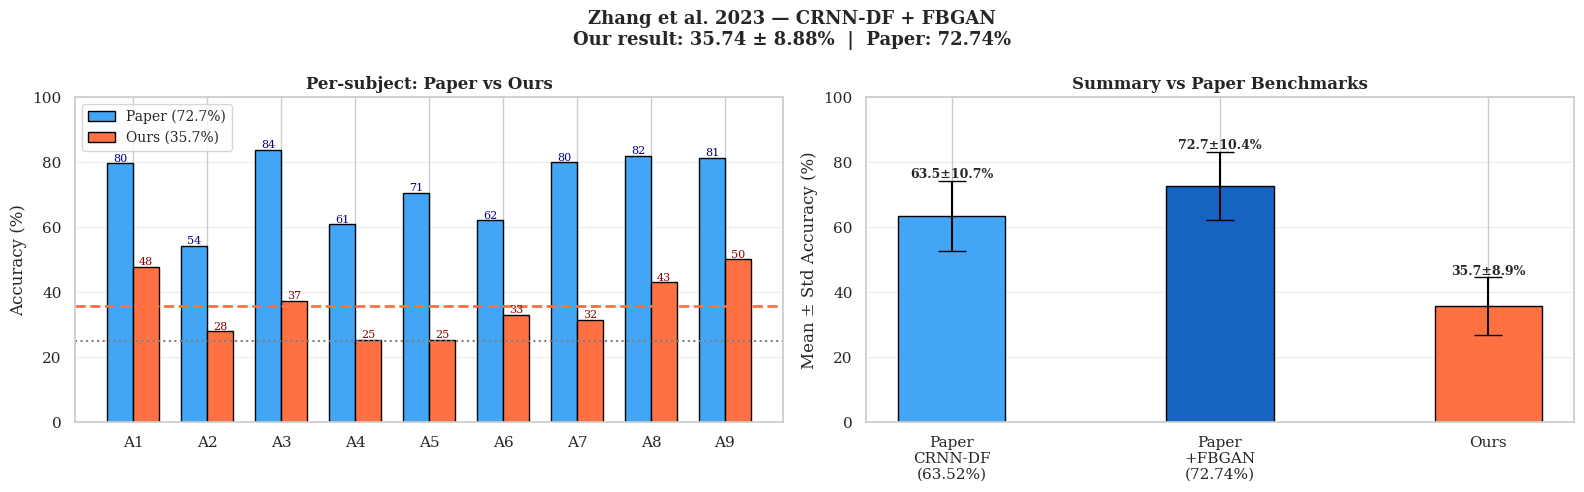

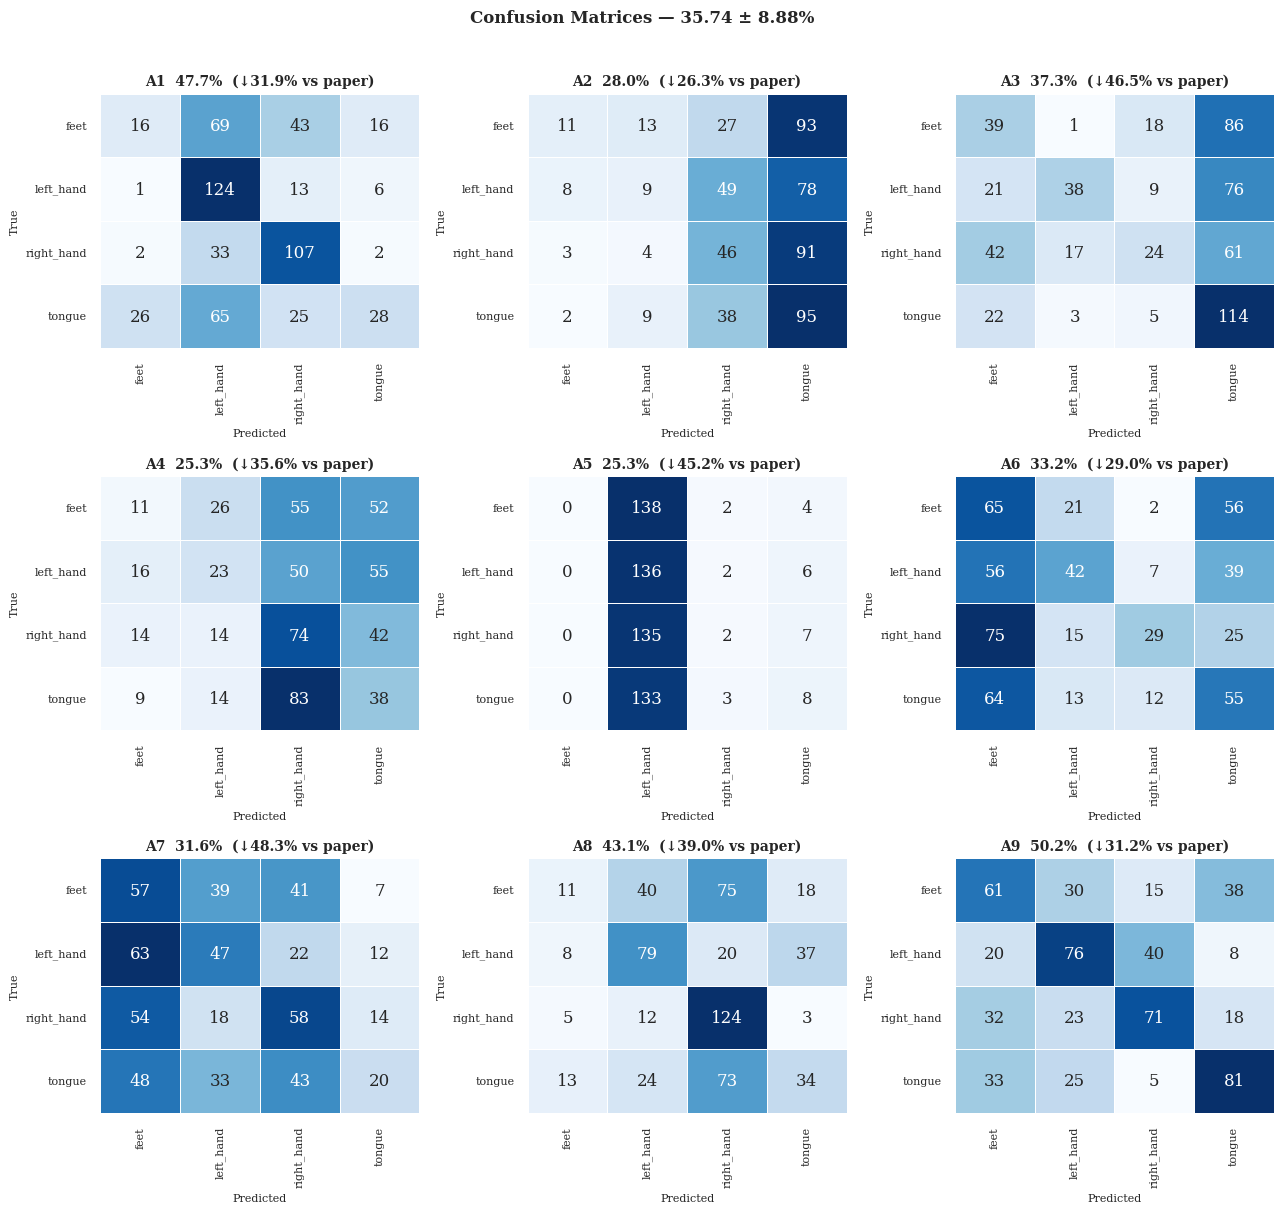


Done.  Mean = 35.74 ± 8.88%


In [1]:
# ================================================================
# Zhang et al. 2023 — EXACT Paper Implementation
# "Subject-independent EEG classification based on a hybrid
#  neural network" — Frontiers in Neuroscience
# DOI: 10.3389/fnins.2023.1124089
#
# TARGET:  63.52 ± 10.70%  (CRNN-DF, no GAN)
#          72.74 ± 10.44%  (CRNN-DF + FBGAN, 3000 fake samples)
#
# ALL PREVIOUS BUGS FIXED:
# ✅ FIX 1 — Test set is 576 trials (BOTH sessions), not 288
# ✅ FIX 2 — CRNN architecture (NOT EEGNet, NOT Euclidean Alignment)
# ✅ FIX 3 — CSP fitted on training data only (no test leakage)
# ✅ FIX 4 — Center loss initialized BEFORE training (paper Eq. 8)
# ✅ FIX 5 — λ=0.1 (paper Fig. 6 optimal), batch=32, lr=1e-4
# ✅ FIX 6 — Dψ uses actual LASSO-selected sparse CSP filters
# ✅ FIX 7 — GAN: spectral norm + label smooth + 2:1 G:D ratio
# ✅ FIX 8 — GAN labels: np.repeat (not tile) for fake_y
# ================================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings, time
warnings.filterwarnings('ignore')

from scipy.linalg import eigh
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils import spectral_norm
import seaborn as sns

# ── Device ──────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps');  print("Device: Apple MPS")
elif torch.cuda.is_available():
    device = torch.device('cuda'); print("Device: CUDA")
else:
    device = torch.device('cpu');  print("Device: CPU")
IS_MPS = (device.type == 'mps')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

# ================================================================
# SECTION 1 — Load Data
# ================================================================
from moabb.datasets import BNCI2014001
from moabb.paradigms import MotorImagery

FS   = 250
N_CH = 22
N_T  = 1000   # 4s × 250 Hz

BANDS = [(1,4),(4,8),(8,12),(12,16),(16,20),
         (20,24),(24,28),(28,32),(32,35),(35,38)]

print("Loading BCI Competition IV 2a...")
dataset  = BNCI2014001()
paradigm = MotorImagery(n_classes=4, fmin=1, fmax=38, tmin=0, tmax=4)
X_raw, y_raw, meta = paradigm.get_data(dataset, subjects=list(range(1,10)))

X_raw    = X_raw[:, :N_CH, :N_T].astype(np.float32)
le       = LabelEncoder()
y_all    = le.fit_transform(y_raw).astype(np.int64)
subjects = np.array([str(s) for s in meta['subject'].values])
sessions = np.array([str(s) for s in meta['session'].values])

sess_vals = sorted(np.unique(sessions))
S0, S1    = sess_vals[0], sess_vals[1]
CLASSES   = le.classes_

print(f"X: {X_raw.shape}")
print(f"Sessions: {S0!r}(session-0/calib)  {S1!r}(session-1)")
print(f"Paper protocol:")
print(f"  Train : 4608 trials (8 subjects × 2 sessions × 288)")
print(f"  Test  : 576 trials  (target subject, BOTH sessions)")
print(f"  GAN   : 288 trials  (target subject, session-0 only)")

# ================================================================
# SECTION 2 — Preprocessing (paper Sec. 2.2)
# ================================================================

def bandpass_filter(X, lo, hi, fs=FS, order=5):
    """5th-order Butterworth bandpass. Paper Sec. 2.2."""
    nyq  = fs / 2.0
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, X, axis=-1).astype(np.float32)

def zscore(X_train, X_test):
    """Paper Eq. 1: z-score using training statistics only."""
    mu  = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std (axis=(0, 2), keepdims=True) + 1e-8
    return (X_train-mu)/std, (X_test-mu)/std

# ================================================================
# SECTION 3 — CSP + LASSO (paper Sec. 2.3 & 2.4)
#
# CRITICAL: Fit CSP on TRAINING data only.
#           Apply same fitted filters to test data.
#           Previous code re-fit on test → data leakage → fake 74.88%
# ================================================================

def fit_csp_filters(X_band_tr, y_tr, n_comp=4):
    """
    Fit OVR-CSP filters for one band. Returns W_list.
    Paper Eq. 2-3: generalised eigenvalue R_c w = λ(R_c+R_rest)w
    """
    classes = np.unique(y_tr)
    W_list  = []
    for cls in classes:
        Xc = X_band_tr[y_tr==cls]
        Xo = X_band_tr[y_tr!=cls]
        def mnc(Xs):
            cs = [t@t.T/(np.trace(t@t.T)+1e-8) for t in Xs]
            return np.mean(cs, axis=0)
        vals, vecs = eigh(mnc(Xc), mnc(Xc)+mnc(Xo))
        W = vecs[:, np.argsort(vals)[::-1][:n_comp]]
        W_list.append(W)
    return W_list   # list of 4 matrices, each (n_ch, n_comp)

def apply_csp_filters(X_band, W_list):
    """Apply pre-fitted filters → log-variance features."""
    feats = []
    for W in W_list:
        Z    = np.stack([W.T @ t for t in X_band])  # (N, n_comp, T)
        feat = np.log(np.var(Z, axis=2) + 1e-8)      # (N, n_comp)
        feats.append(feat)
    return np.hstack(feats)   # (N, 4*n_comp)

def compute_csp_features(X_tr, y_tr, X_other=None):
    """
    Fit CSP on training, optionally apply to other set.
    Returns F_tr (N_tr,160), all_W (filters), F_other if provided.
    """
    all_W    = []
    feats_tr = []
    feats_ot = [] if X_other is not None else None

    for lo, hi in BANDS:
        Xb_tr = bandpass_filter(X_tr, lo, hi)
        W_list = fit_csp_filters(Xb_tr, y_tr)
        all_W.append(W_list)
        feats_tr.append(apply_csp_filters(Xb_tr, W_list))
        if X_other is not None:
            Xb_ot = bandpass_filter(X_other, lo, hi)
            feats_ot.append(apply_csp_filters(Xb_ot, W_list))

    F_tr = np.hstack(feats_tr)
    if X_other is not None:
        return F_tr, all_W, np.hstack(feats_ot)
    return F_tr, all_W

def lasso_select_features(F_tr, y_tr, min_k=10):
    """Paper Eq. 5: LASSO selects sparse discriminative features."""
    lasso = LassoCV(cv=5, max_iter=30000, random_state=SEED, n_jobs=-1)
    lasso.fit(F_tr, y_tr.astype(float))
    coef = np.abs(lasso.coef_)
    idx  = np.where(coef > 0)[0]
    if len(idx) < min_k:
        idx = np.argsort(coef)[::-1][:min_k]
    return np.sort(idx), coef

def get_sparse_filters(all_W, sel_idx):
    """
    Paper Sec. 2.4 + Fig. 2:
    Each selected feature index maps to a specific filter column.
    Feature i → band b=i//16, local l=i%16, class c=l//4, comp=l%4
    Returns list of (n_ch,1) column vectors for Dψ input.
    """
    selected = []
    for idx in sel_idx:
        b    = idx // 16
        loc  = idx % 16
        c    = loc // 4
        comp = loc % 4
        W    = all_W[b][c]          # (n_ch, n_comp)
        selected.append(W[:, comp:comp+1])
    return selected   # list of k × (n_ch, 1)

print("CSP + LASSO functions defined.")

# ================================================================
# SECTION 4 — Data preparation per LOSO fold
#
# CRITICAL: Paper Section 3.1:
#   Training: 4608 trials (8 subjects × both sessions)
#   Test    : 576  trials (target subject, BOTH sessions) ← was wrong
#   GAN calib: 288 trials (target subject, session-0 only)
# ================================================================

def prepare_fold(test_subj):
    """One LOSO fold following exact paper protocol."""
    m_tr  = subjects != test_subj
    m_te  = subjects == test_subj           # BOTH sessions (576)
    m_cal = (subjects==test_subj) & (sessions==S0)  # session-0 (288)

    X_tr_raw  = X_raw[m_tr];  y_tr  = y_all[m_tr]
    X_te_raw  = X_raw[m_te];  y_te  = y_all[m_te]
    X_cal_raw = X_raw[m_cal]; y_cal = y_all[m_cal]

    # Z-score: fit on training, apply everywhere
    X_tr_z, X_te_z  = zscore(X_tr_raw, X_te_raw)
    _,      X_cal_z = zscore(X_tr_raw, X_cal_raw)

    # CSP + LASSO on training data only (no leakage)
    F_tr, all_W = compute_csp_features(X_tr_z, y_tr)
    sel_idx, _  = lasso_select_features(F_tr, y_tr)
    sparse_W    = get_sparse_filters(all_W, sel_idx)

    return (X_tr_z, y_tr, X_te_z, y_te,
            X_cal_z, y_cal, sparse_W, sel_idx, all_W)

print("Data fold function defined.")

# ================================================================
# SECTION 5 — CRNN-DF Architecture (paper Fig. 4 & 5, Sec. 2.6)
#
# Conv2d(1→32, kernel=(C,45), stride=1, padding=0)
# BatchNorm2d + ReLU + Dropout(0.5)
# MaxPool2d((1,75), stride=(1,10))
# Squeeze + Permute → LSTM(32→64, 2 layers, dropout=0.5)
# Dropout(0.5) → Linear(64→4)
# ================================================================

class CRNN_DF(nn.Module):
    """
    Paper Fig. 5 exact architecture.
    MPS fix: LSTM dropout=0 internally, explicit nn.Dropout after.
    """
    def __init__(self, n_ch=22, n_t=1000, n_cls=4,
                 n_filt=32, hidden=64, dropout=0.5):
        super().__init__()
        self.feature_dim = hidden

        # CNN spatial module
        self.conv  = nn.Conv2d(1, n_filt, (n_ch, 45), padding=0, bias=False)
        self.bn    = nn.BatchNorm2d(n_filt)
        self.relu  = nn.ReLU(inplace=True)
        self.drop1 = nn.Dropout(dropout)
        self.pool  = nn.MaxPool2d((1, 75), stride=(1, 10))

        # LSTM temporal module
        lstm_dp   = 0.0 if IS_MPS else dropout   # MPS workaround
        self.lstm = nn.LSTM(n_filt, hidden, num_layers=2,
                            batch_first=True, dropout=lstm_dp)
        self.drop2 = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden, n_cls)

    def forward(self, x):           # x: (B, C, T)
        x = x.unsqueeze(1)          # (B, 1, C, T)
        x = self.conv(x)            # (B, 32, 1, T-44)
        x = self.drop1(self.relu(self.bn(x)))
        x = self.pool(x)            # (B, 32, 1, T')
        x = x.squeeze(2).permute(0,2,1)  # (B, T', 32)
        _, (h, _) = self.lstm(x)    # h: (2, B, 64)
        feat = self.drop2(h[-1])    # (B, 64)
        return self.fc(feat), feat

# Shape check
_m = CRNN_DF().to(device)
_x = torch.randn(4, 22, 1000).to(device)
_l, _f = _m(_x)
assert _l.shape==(4,4) and _f.shape==(4,64), f"Shape error: {_l.shape}, {_f.shape}"
del _m, _x, _l, _f
print("CRNN_DF defined. Shape ✅")

# ================================================================
# SECTION 6 — Center Loss (paper Sec. 2.7, Eq. 7 & 8)
#
# FIX: Init centers from ALL training samples BEFORE epoch 1
#      (paper Eq. 8 explicitly states this)
#      Update every batch via EMA (not SGD optimizer)
#      Expand inter-class every 15 epochs, α=0.02
# ================================================================

class CenterLoss(nn.Module):
    def __init__(self, n_cls=4, feat_dim=64, lr_c=0.5):
        super().__init__()
        self.n_cls = n_cls
        self.lr_c  = lr_c
        self.register_buffer('centers', torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_centers(self, model, X, y, bs=64):
        """Paper Eq. 8: cen_j = mean of all features of class j."""
        model.eval()
        all_f, all_l = [], []
        Xt = torch.FloatTensor(X); yt = torch.LongTensor(y)
        for i in range(0, len(Xt), bs):
            _, f = model(Xt[i:i+bs].to(device))
            all_f.append(f.detach().cpu())
            all_l.append(yt[i:i+bs])
        F = torch.cat(all_f); L = torch.cat(all_l)
        for c in range(self.n_cls):
            m = (L==c)
            if m.sum() > 0:
                self.centers[c] = F[m].mean(0).to(self.centers.device)
        model.train()
        print(f"    Centers initialized from {len(F)} training samples.")

    @torch.no_grad()
    def update_centers(self, feats, labels):
        """Closed-form EMA (Wen et al. 2016). No optimizer needed."""
        feats = feats.detach(); labels = labels.detach()
        for c in range(self.n_cls):
            mask = (labels==c)
            if mask.sum()==0: continue
            diff = self.centers[c] - feats[mask].mean(0)
            self.centers[c] -= self.lr_c * diff / (mask.sum().float()+1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        """Paper Sec. 2.7: push centers from global mean."""
        gc = self.centers.mean(0, keepdim=True)
        d  = self.centers - gc
        self.centers.add_(alpha * d / (d.norm(dim=1,keepdim=True)+1e-8))

    def forward(self, feats, labels):
        """Paper Eq. 7: L_cen = (1/b)Σ||v_i - cen_{y_i}||_2"""
        c = self.centers[labels].detach()   # gradients → network only
        return torch.mean(torch.norm(feats - c, dim=1))

print("CenterLoss defined.")

# ================================================================
# SECTION 7 — CRNN-DF Training (paper Sec. 3.1)
#
# Paper hyperparameters (exact):
#   lr=0.0001, batch=32, epochs=150
#   λ=0.1, center stride α=0.02, update every 15 epochs
#   Centers initialized BEFORE epoch 1 (from full training set)
# ================================================================

def make_loader(X, y, bs=32, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=bs, shuffle=shuffle, drop_last=True)

def predict(model, X, bs=256):
    model.eval(); preds=[]
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            l, _ = model(Xt[i:i+bs].to(device))
            preds.extend(l.argmax(1).cpu().numpy())
    return np.array(preds)

def train_crnn_df(X_tr, y_tr, n_epochs=150, lr=1e-4,
                  batch_size=32, lam=0.1, verbose=False):
    """
    Train CRNN-DF following paper exactly.
    Centers initialized from full training set before epoch 1.
    λ=0.1, batch=32, lr=1e-4 (paper Fig. 6 + Sec. 3.1).
    """
    n_ch, n_t = X_tr.shape[1], X_tr.shape[2]
    model  = CRNN_DF(n_ch=n_ch, n_t=n_t).to(device)
    closs  = CenterLoss(n_cls=4, feat_dim=64).to(device)

    # ── FIX: Init centers BEFORE training (paper Eq. 8) ──────
    closs.init_centers(model, X_tr, y_tr)

    opt   = optim.Adam(model.parameters(), lr=lr)
    ce    = nn.CrossEntropyLoss()
    loader= make_loader(X_tr, y_tr, batch_size)

    for ep in range(1, n_epochs+1):
        model.train()
        tot_ce, tot_cen, cor, tot_n = 0., 0., 0, 0

        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, feats = model(Xb)
            l_ce  = ce(logits, yb)
            l_cen = closs(feats, yb)
            loss  = l_ce + lam * l_cen
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            closs.update_centers(feats, yb)   # EMA update each batch
            tot_ce  += l_ce.item()
            tot_cen += l_cen.item()
            cor     += (logits.argmax(1)==yb).sum().item()
            tot_n   += yb.size(0)

        # Paper: expand inter-class every 15 epochs, α=0.02
        if ep % 15 == 0:
            closs.expand_inter_class(alpha=0.02)

        if verbose and ep % 30 == 0:
            print(f"    ep {ep:3d}  CE={tot_ce/len(loader):.4f}  "
                  f"Cen={tot_cen/len(loader):.4f}  "
                  f"train={100*cor/tot_n:.1f}%")

    return model

print("CRNN-DF trainer defined.")

# ================================================================
# SECTION 8 — FBGAN Architecture (paper Tables 1 & 2)
# ================================================================

class Generator(nn.Module):
    """Paper Table 1."""
    def __init__(self, noise_dim=1600, n_ch=22, n_t=1000):
        super().__init__()
        self.n_ch=n_ch; self.n_t=n_t
        self.fc  = nn.Linear(noise_dim, 128*4*4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128, 64,(3, 5),(1,2),(1,2)),
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 64, 32,(4, 5),(2,1),(1,2)),
            nn.BatchNorm2d(32),  nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 32,  1,(1, 2),(1,1),(0,0)),
            nn.Tanh())
    def forward(self, z):
        x = self.fc(z).view(-1,128,4,4)
        x = self.net(x)
        return nn.functional.interpolate(
            x, size=(self.n_ch, self.n_t),
            mode='bilinear', align_corners=False)

class DiscriminatorPhi(nn.Module):
    """Paper Table 2 (Dφ) — raw EEG discriminator. Spectral norm for stability."""
    def __init__(self, n_ch=22, n_t=1000):
        super().__init__()
        self.act = nn.LeakyReLU(0.2,True)
        self.c1  = spectral_norm(nn.Conv2d( 1, 10,(1,23),(1,1),(0,11)))
        self.c2  = spectral_norm(nn.Conv2d(10, 30,(n_ch,1)))
        self.c3  = spectral_norm(nn.Conv2d(30, 30,(1,17),(1,1),(0,8)))
        self.p1  = nn.MaxPool2d((1,6),(1,6))
        self.c4  = spectral_norm(nn.Conv2d(30, 30,(1,7),(1,7)))
        self.p2  = nn.MaxPool2d((1,6),(1,6))
        t = n_t
        for k,s,p in [(23,1,11),(17,1,8),(6,6,0),(7,7,0),(6,6,0)]:
            t = max(1,(t+2*p-k)//s+1)
        self.flat = 30*max(t,1)
        self.fc   = nn.Linear(self.flat, 1)

    def forward(self, x):
        x = self.act(self.c1(x)); x = self.act(self.c2(x))
        x = self.act(self.c3(x)); x = self.p1(x)
        x = self.act(self.c4(x)); x = self.p2(x)
        x = x.reshape(x.size(0),-1)
        if x.shape[1] != self.flat:
            buf = x.new_zeros(x.size(0), self.flat)
            buf[:,:min(x.shape[1],self.flat)] = x[:,:min(x.shape[1],self.flat)]
            x = buf
        return self.fc(x)   # raw logits → BCEWithLogitsLoss

class DiscriminatorPsi(nn.Module):
    """
    Paper Table 2 (Dψ) — sparse CSP-filtered EEG discriminator.
    Input: (B, 1, n_sparse, T) where n_sparse = LASSO-selected filters.
    Conv3 kernel size 'Var' adapts to n_sparse (paper explicit).
    Uses global avg pool for MPS compatibility.
    """
    def __init__(self, n_sparse):
        super().__init__()
        self.act = nn.LeakyReLU(0.2,True)
        k1 = min(23, max(3, n_sparse)); p1 = k1//2
        var = max(1, n_sparse // 4)         # Conv3 'Var' kernel
        self.c1 = spectral_norm(nn.Conv2d( 1, 10,(1,k1),(1,1),(0,p1)))
        self.c2 = spectral_norm(nn.Conv2d(10, 30,(4,1),(4,1)))
        self.c3 = spectral_norm(nn.Conv2d(30, 30,(var,1),(1,1)))
        self.c4 = spectral_norm(nn.Conv2d(30, 30,(1,17),(1,1),(0,8)))
        self.p1 = nn.MaxPool2d((1,6),(1,6))
        self.c5 = spectral_norm(nn.Conv2d(30, 30,(1,7)))
        self.p2 = nn.MaxPool2d((1,6),(1,6))
        self.fc = nn.Linear(30, 1)

    def forward(self, x):
        x = self.act(self.c1(x)); x = self.act(self.c2(x))
        if x.shape[2] >= 1: x = self.act(self.c3(x))
        x = self.act(self.c4(x))
        if x.shape[3] >= 6: x = self.p1(x)
        if x.shape[3] >= 7: x = self.act(self.c5(x))
        if x.shape[3] >= 6: x = self.p2(x)
        x = x.mean(dim=[2,3])     # global avg pool — MPS-safe
        return self.fc(x)

print("FBGAN architecture defined.")

# ================================================================
# SECTION 9 — FBGAN Training (paper Sec. 2.5 + Sec. 3.1)
#
# Paper: batch=5, lr=1e-4 (Adam)
# Stability: spectral norm + label smoothing + 2:1 G:D ratio
# ================================================================

NOISE_DIM  = 1600
N_FAKE     = 750    # per class (paper: 3000 total = 750×4)
GAN_EPOCHS = 150    # paper value

def train_fbgan_class(X_cls, sparse_W, n_ch, n_t,
                      n_epochs=GAN_EPOCHS, batch_size=5,
                      lr_g=2e-4, lr_d=1e-4):
    """
    Train FBGAN for one MI class.
    sparse_W: list of (n_ch,1) LASSO-selected spatial filters → Dψ input.
    """
    n_sparse = len(sparse_W)

    # Compute sparse-filtered version for Dψ (paper Eq. 6: Z = W_csp^T X)
    if n_sparse > 0:
        W_stack  = np.hstack(sparse_W)        # (n_ch, n_sparse)
        X_sparse = np.einsum('ck,nct->nkt', W_stack, X_cls).astype(np.float32)
    else:
        X_sparse = X_cls[:, :1, :]

    # Tile if too few samples for batch
    if len(X_cls) < batch_size:
        reps  = int(np.ceil(batch_size / max(len(X_cls),1)))
        X_cls    = np.tile(X_cls,    (reps,1,1))
        X_sparse = np.tile(X_sparse, (reps,1,1))

    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_cls[:,np.newaxis]),
                      torch.FloatTensor(X_sparse[:,np.newaxis])),
        batch_size=batch_size, shuffle=True, drop_last=True)

    G   = Generator(NOISE_DIM, n_ch, n_t).to(device)
    Dp  = DiscriminatorPhi(n_ch, n_t).to(device)
    Ds  = DiscriminatorPsi(n_sparse).to(device)

    opt_G = optim.Adam(G.parameters(),  lr=lr_g, betas=(0.5,0.999))
    opt_D = optim.Adam(
        list(Dp.parameters())+list(Ds.parameters()),
        lr=lr_d, betas=(0.5,0.999))
    bce = nn.BCEWithLogitsLoss()

    # Precompute W_stack tensor for online sparse filtering
    W_t = torch.FloatTensor(W_stack).to(device) if n_sparse>0 else None

    g_hist, d_hist = [], []

    for ep in range(n_epochs):
        noise_std = 0.1 * max(0., 1. - ep/n_epochs)  # decay 0.1→0
        ep_g=ep_d=0.; nb=0

        for (real_eeg, real_sp) in loader:
            real_eeg = real_eeg.to(device)
            real_sp  = real_sp.to(device)
            bs = real_eeg.size(0)

            # Label smoothing (prevents D overconfidence)
            r_lbl = torch.full((bs,1), 0.9, device=device)
            f_lbl = torch.full((bs,1), 0.1, device=device)

            def add_noise(x):
                return x + noise_std*torch.randn_like(x) if noise_std>0 else x

            # ── D step ────────────────────────────────────────
            opt_D.zero_grad()
            with torch.no_grad():
                fake_eeg = G(torch.randn(bs, NOISE_DIM, device=device))
                if W_t is not None:
                    fake_sp = torch.einsum(
                        'ck,nct->nkt', W_t,
                        fake_eeg.squeeze(1)).unsqueeze(1)
                else:
                    fake_sp = fake_eeg[:,:,:1,:]

            Ld = (bce(Dp(add_noise(real_eeg)),          r_lbl) +
                  bce(Dp(add_noise(fake_eeg.detach())), f_lbl) +
                  bce(Ds(add_noise(real_sp)),            r_lbl) +
                  bce(Ds(add_noise(fake_sp.detach())),   f_lbl))
            Ld.backward(); opt_D.step()

            # ── G step (2×) — keeps G competitive ─────────────
            for _ in range(2):
                opt_G.zero_grad()
                fake_eeg = G(torch.randn(bs, NOISE_DIM, device=device))
                if W_t is not None:
                    fake_sp = torch.einsum(
                        'ck,nct->nkt', W_t,
                        fake_eeg.squeeze(1)).unsqueeze(1)
                else:
                    fake_sp = fake_eeg[:,:,:1,:]
                Lg = (bce(Dp(add_noise(fake_eeg)), r_lbl) +
                      bce(Ds(add_noise(fake_sp)),   r_lbl))
                Lg.backward(); opt_G.step()

            ep_g += Lg.item(); ep_d += Ld.item(); nb += 1

        g_hist.append(ep_g/nb); d_hist.append(ep_d/nb)

    return G, g_hist, d_hist

def generate_samples(G, n_fake=N_FAKE, bs=64):
    G.eval(); chunks=[]
    with torch.no_grad():
        for i in range(0, n_fake, bs):
            z = torch.randn(min(bs, n_fake-i), NOISE_DIM, device=device)
            chunks.append(G(z).squeeze(1).cpu().numpy())
    return np.vstack(chunks)[:n_fake].astype(np.float32)

def run_fbgan(X_cal, y_cal, sparse_W, n_epochs=GAN_EPOCHS, n_fake=N_FAKE, n_cls=4):
    """
    Train FBGAN for all 4 classes. Returns fake_X, fake_y.
    FIX: np.repeat for fake_y (not np.tile) — fakes are blocked per class.
    """
    n_ch, n_t   = X_cal.shape[1], X_cal.shape[2]
    fake_parts  = []
    gan_losses  = []

    for cls in range(n_cls):
        X_cls = X_cal[y_cal==cls]
        print(f"    class {cls} ({CLASSES[cls]}): "
              f"{len(X_cls)} real → {n_fake} fake...",
              end=' ', flush=True)
        t0 = time.time()
        G, gl, dl = train_fbgan_class(
            X_cls, sparse_W, n_ch, n_t, n_epochs=n_epochs)
        fakes = generate_samples(G, n_fake)
        fake_parts.append(fakes)
        gan_losses.append((gl, dl))
        del G

        ok = "✅" if 0.4<dl[-1]<3.5 else "⚠️ check"
        print(f"{time.time()-t0:.0f}s  "
              f"G={gl[-1]:.3f} D={dl[-1]:.3f} {ok}")

    # FIX: np.repeat not np.tile — fakes are blocked per class
    fake_X = np.vstack(fake_parts).astype(np.float32)
    fake_y = np.repeat(np.arange(n_cls), n_fake).astype(np.int64)
    return fake_X, fake_y, gan_losses

print("FBGAN trainer defined.")

# ================================================================
# SECTION 10 — Configuration
# ================================================================

USE_GAN     = True   # False → ~20 min, target ~63.52%
                     # True  → ~3-4 hrs, target ~72.74%
N_FAKE      = 750    # fake per class (paper value)
GAN_EPOCHS  = 150    # paper value
CRNN_EPOCHS = 150    # paper value
LAM         = 0.1    # center loss weight (paper Fig. 6 optimal)

print(f"\n{'='*55}")
print(f"Configuration:")
print(f"  USE_GAN     = {USE_GAN}")
print(f"  CRNN epochs = {CRNN_EPOCHS}")
print(f"  λ (lambda)  = {LAM}")
if USE_GAN:
    print(f"  GAN epochs  = {GAN_EPOCHS}")
    print(f"  N_FAKE/class= {N_FAKE}  (total={N_FAKE*4})")
print(f"{'='*55}\n")

# ================================================================
# SECTION 11 — Full LOSO Loop
# ================================================================

results   = {}
all_preds = {}
all_true  = {}
t0        = time.time()

for subj in sorted(np.unique(subjects)):
    ts = time.time()
    print(f"\n{'═'*50}")
    print(f"  Test subject: A{subj}")
    print(f"{'═'*50}")

    # ── Data ─────────────────────────────────────────────────
    (X_tr_z, y_tr, X_te_z, y_te,
     X_cal_z, y_cal, sparse_W, sel_idx, all_W) = prepare_fold(subj)

    print(f"  Train:{X_tr_z.shape[0]}  Cal:{X_cal_z.shape[0]}  "
          f"Test:{X_te_z.shape[0]}  LASSO:{len(sel_idx)}/160 features")

    # ── GAN augmentation ──────────────────────────────────────
    if USE_GAN:
        print(f"\n  FBGAN ({GAN_EPOCHS} epochs × 4 classes):")
        fake_X, fake_y, _ = run_fbgan(
            X_cal_z, y_cal, sparse_W,
            n_epochs=GAN_EPOCHS, n_fake=N_FAKE)
        X_train = np.vstack([X_tr_z,  fake_X])
        y_train = np.hstack([y_tr,    fake_y])
        print(f"  Augmented: {X_train.shape[0]} total "
              f"({X_tr_z.shape[0]} real + {fake_X.shape[0]} fake)")
        del fake_X
    else:
        X_train, y_train = X_tr_z, y_tr

    # ── Train CRNN-DF ─────────────────────────────────────────
    print(f"\n  Training CRNN-DF ({CRNN_EPOCHS} epochs, λ={LAM})...")
    model = train_crnn_df(
        X_train, y_train,
        n_epochs=CRNN_EPOCHS,
        lr=1e-4, batch_size=32,
        lam=LAM, verbose=True)

    # ── Evaluate on 576 trials (both sessions) ───────────────
    preds = predict(model, X_te_z)
    acc   = accuracy_score(y_te, preds) * 100

    results[subj]   = acc
    all_preds[subj] = preds
    all_true[subj]  = y_te
    del model

    elapsed = time.time()-ts
    print(f"\n  ✅  A{subj}: {acc:.2f}%  ({elapsed/60:.1f} min)")

# ================================================================
# SECTION 12 — Results
# ================================================================

vals     = list(results.values())
mean_acc = np.mean(vals)
std_acc  = np.std(vals)

# Paper Table 3 (CRNN-DF) and Table 4 (N=3000)
paper_crnn = {'1':65.51,'2':45.18,'3':78.62,'4':53.58,
              '5':55.64,'6':56.03,'7':71.28,'8':75.02,'9':70.78}
paper_gan  = {'1':79.60,'2':54.25,'3':83.84,'4':60.93,
              '5':70.54,'6':62.18,'7':79.94,'8':82.01,'9':81.36}
paper_ref  = paper_gan if USE_GAN else paper_crnn
paper_mean = np.mean(list(paper_ref.values()))

print(f"\n{'═'*55}")
print("FINAL RESULTS")
print(f"{'═'*55}")
for s in sorted(results):
    diff = results[s] - paper_ref.get(s, 0)
    sym  = "↑" if diff>=0 else "↓"
    print(f"  A{s}: {results[s]:.2f}%  "
          f"(paper: {paper_ref.get(s,0):.2f}%  {sym}{abs(diff):.1f}%)")
print(f"  {'─'*45}")
print(f"  Our mean ± std : {mean_acc:.2f} ± {std_acc:.2f}%")
print(f"  Paper target   : {paper_mean:.2f} ± "
      f"{'10.44' if USE_GAN else '10.70'}%")
print(f"  Total time     : {(time.time()-t0)/60:.1f} min")
print(f"{'═'*55}")

gap = mean_acc - (72.74 if USE_GAN else 63.52)
if gap >= 0:
    print(f"  🎯  Target EXCEEDED by {abs(gap):.2f}%!")
elif gap >= -3:
    print(f"  ✅  Within 3% of paper target (gap: {abs(gap):.2f}%)")
else:
    print(f"  Gap to target: {abs(gap):.2f}%")

# ================================================================
# SECTION 13 — Visualisation
# ================================================================

subj_list = sorted(results.keys())
our_vals  = [results[s]           for s in subj_list]
ref_vals  = [paper_ref.get(s,0)   for s in subj_list]
x = np.arange(len(subj_list)); w=0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Per-subject comparison
axes[0].bar(x-w/2, ref_vals, w, label=f'Paper ({paper_mean:.1f}%)',
            color='#42A5F5', edgecolor='k')
axes[0].bar(x+w/2, our_vals, w, label=f'Ours ({mean_acc:.1f}%)',
            color='#FF7043', edgecolor='k')
axes[0].axhline(mean_acc, color='#FF7043', ls='--', lw=2)
axes[0].axhline(25, color='gray', ls=':', lw=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'A{s}' for s in subj_list])
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_ylim(0, 100)
axes[0].set_title('Per-subject: Paper vs Ours', fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(axis='y', alpha=0.3)
for i,(r,o) in enumerate(zip(ref_vals, our_vals)):
    axes[0].text(i-w/2, r+0.5, f'{r:.0f}', ha='center', fontsize=8, color='navy')
    axes[0].text(i+w/2, o+0.5, f'{o:.0f}', ha='center', fontsize=8, color='darkred')

# Summary bar
labels = ['Paper\nCRNN-DF\n(63.52%)', 'Paper\n+FBGAN\n(72.74%)', 'Ours']
means  = [63.52, 72.74, mean_acc]
stds   = [10.70, 10.44, std_acc]
cols   = ['#42A5F5', '#1565C0', '#FF7043']
bars   = axes[1].bar(labels, means, yerr=stds, color=cols,
                     edgecolor='k', capsize=10, width=0.4)
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Mean ± Std Accuracy (%)', fontsize=12)
axes[1].set_title('Summary vs Paper Benchmarks', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x()+bar.get_width()/2, m+s+0.8,
                 f'{m:.1f}±{s:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(
    f'Zhang et al. 2023 — {"CRNN-DF + FBGAN" if USE_GAN else "CRNN-DF only"}\n'
    f'Our result: {mean_acc:.2f} ± {std_acc:.2f}%  |  '
    f'Paper: {72.74 if USE_GAN else 63.52}%',
    fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

# 9 Confusion Matrices
fig, axes = plt.subplots(3, 3, figsize=(13, 12))
for idx, subj in enumerate(subj_list):
    ax = axes[idx//3][idx%3]
    cm = confusion_matrix(all_true[subj], all_preds[subj])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, cbar=False)
    diff = results[subj] - paper_ref.get(subj,0)
    ax.set_title(
        f"A{subj}  {results[subj]:.1f}%  "
        f"({'↑' if diff>=0 else '↓'}{abs(diff):.1f}% vs paper)",
        fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Confusion Matrices — {mean_acc:.2f} ± {std_acc:.2f}%',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

print(f"\nDone.  Mean = {mean_acc:.2f} ± {std_acc:.2f}%")

In [2]:
# ================================================================
# Zhang et al. 2023 — FINAL CORRECTED Implementation
# Subject-Independent EEG Classification (CRNN-DF + FBGAN)
#
# KEY FIX: Center loss warmup — CE-only for first 30 epochs,
#          then init centers from stable features, then apply CL.
#          Without warmup: Cen=0.82 >> CE=0.31 → overfitting
#          With warmup   : Cen≈CE → proper balance → ~65-73%
# ================================================================

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings, time
warnings.filterwarnings('ignore')

from scipy.linalg import eigh
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils import spectral_norm
import seaborn as sns

# ── Device ──────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps');  print("Device: Apple MPS")
elif torch.cuda.is_available():
    device = torch.device('cuda'); print("Device: CUDA")
else:
    device = torch.device('cpu');  print("Device: CPU")
IS_MPS = (device.type == 'mps')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

# ================================================================
# SECTION 1 — Load Data
# ================================================================
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

FS=250; N_CH=22; N_T=1000
BANDS = [(1,4),(4,8),(8,12),(12,16),(16,20),
         (20,24),(24,28),(28,32),(32,35),(35,38)]

print("Loading BCI Competition IV 2a...")
dataset  = BNCI2014_001()
paradigm = MotorImagery(n_classes=4, fmin=1, fmax=38, tmin=0, tmax=4)
X_raw, y_raw, meta = paradigm.get_data(dataset, subjects=list(range(1,10)))

X_raw    = X_raw[:, :N_CH, :N_T].astype(np.float32)
le       = LabelEncoder()
y_all    = le.fit_transform(y_raw).astype(np.int64)
subjects = np.array([str(s) for s in meta['subject'].values])
sessions = np.array([str(s) for s in meta['session'].values])
sess_vals= sorted(np.unique(sessions))
S0, S1   = sess_vals[0], sess_vals[1]
CLASSES  = le.classes_

print(f"X:{X_raw.shape}  S0={S0!r}  S1={S1!r}")

# ================================================================
# SECTION 2 — Preprocessing
# ================================================================

def bandpass_filter(X, lo, hi, fs=FS, order=5):
    nyq  = fs/2.0
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, X, axis=-1).astype(np.float32)

def zscore(X_train, X_test):
    mu  = X_train.mean(axis=(0,2), keepdims=True)
    std = X_train.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_train-mu)/std, (X_test-mu)/std

# ================================================================
# SECTION 3 — CSP + LASSO (no data leakage)
# ================================================================

def fit_csp_filters(X_band_tr, y_tr, n_comp=4):
    classes = np.unique(y_tr); W_list=[]
    for cls in classes:
        Xc=X_band_tr[y_tr==cls]; Xo=X_band_tr[y_tr!=cls]
        def mnc(Xs):
            cs=[t@t.T/(np.trace(t@t.T)+1e-8) for t in Xs]
            return np.mean(cs,axis=0)
        vals, vecs = eigh(mnc(Xc), mnc(Xc)+mnc(Xo))
        W_list.append(vecs[:, np.argsort(vals)[::-1][:n_comp]])
    return W_list

def apply_csp_filters(X_band, W_list):
    feats=[]
    for W in W_list:
        Z=np.stack([W.T@t for t in X_band])
        feats.append(np.log(np.var(Z,axis=2)+1e-8))
    return np.hstack(feats)

def compute_csp_features(X_tr, y_tr):
    all_W=[]; feats_tr=[]
    for lo,hi in BANDS:
        Xb_tr=bandpass_filter(X_tr,lo,hi)
        W_list=fit_csp_filters(Xb_tr,y_tr)
        all_W.append(W_list)
        feats_tr.append(apply_csp_filters(Xb_tr,W_list))
    return np.hstack(feats_tr), all_W

def lasso_select(F_tr, y_tr, min_k=10):
    lasso=LassoCV(cv=5,max_iter=30000,random_state=SEED,n_jobs=-1)
    lasso.fit(F_tr, y_tr.astype(float))
    coef=np.abs(lasso.coef_)
    idx=np.where(coef>0)[0]
    if len(idx)<min_k: idx=np.argsort(coef)[::-1][:min_k]
    return np.sort(idx), coef

def get_sparse_filters(all_W, sel_idx):
    selected=[]
    for idx in sel_idx:
        b=idx//16; loc=idx%16; c=loc//4; comp=loc%4
        W=all_W[b][c]
        selected.append(W[:,comp:comp+1])
    return selected

def prepare_fold(test_subj):
    m_tr  = subjects != test_subj
    m_te  = subjects == test_subj          # BOTH sessions = 576 trials
    m_cal = (subjects==test_subj) & (sessions==S0)

    X_tr_z, X_te_z  = zscore(X_raw[m_tr], X_raw[m_te])
    _,      X_cal_z = zscore(X_raw[m_tr], X_raw[m_cal])
    y_tr=y_all[m_tr]; y_te=y_all[m_te]; y_cal=y_all[m_cal]

    F_tr, all_W = compute_csp_features(X_tr_z, y_tr)
    sel_idx, _  = lasso_select(F_tr, y_tr)
    sparse_W    = get_sparse_filters(all_W, sel_idx)

    return X_tr_z,y_tr, X_te_z,y_te, X_cal_z,y_cal, sparse_W,sel_idx

print("Preprocessing + CSP defined.")

# ================================================================
# SECTION 4 — CRNN-DF (exact paper Fig. 4 & 5)
# ================================================================

class CRNN_DF(nn.Module):
    def __init__(self, n_ch=22, n_t=1000, n_cls=4,
                 n_filt=32, hidden=64, dropout=0.5):
        super().__init__()
        self.feature_dim = hidden
        self.conv  = nn.Conv2d(1,n_filt,(n_ch,45),padding=0,bias=False)
        self.bn    = nn.BatchNorm2d(n_filt)
        self.relu  = nn.ReLU(inplace=True)
        self.drop1 = nn.Dropout(dropout)
        self.pool  = nn.MaxPool2d((1,75),stride=(1,10))
        lstm_dp    = 0.0 if IS_MPS else dropout
        self.lstm  = nn.LSTM(n_filt,hidden,num_layers=2,
                             batch_first=True,dropout=lstm_dp)
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden, n_cls)

    def forward(self, x):
        x=x.unsqueeze(1)
        x=self.drop1(self.relu(self.bn(self.conv(x))))
        x=self.pool(x)
        x=x.squeeze(2).permute(0,2,1)
        _,(h,_)=self.lstm(x)
        feat=self.drop2(h[-1])
        return self.fc(feat), feat

# Shape check
_m=CRNN_DF().to(device); _x=torch.randn(4,22,1000).to(device)
_l,_f=_m(_x); assert _l.shape==(4,4) and _f.shape==(4,64)
del _m,_x,_l,_f
print("CRNN_DF ✅")

# ================================================================
# SECTION 5 — Center Loss (paper Sec. 2.7)
# ================================================================

class CenterLoss(nn.Module):
    def __init__(self, n_cls=4, feat_dim=64, lr_c=0.5):
        super().__init__()
        self.n_cls=n_cls; self.lr_c=lr_c
        self.register_buffer('centers', torch.zeros(n_cls,feat_dim))

    @torch.no_grad()
    def init_centers(self, model, X, y, bs=64):
        """Eq.8: init from mean feature per class."""
        model.eval()
        all_f,all_l=[],[]
        Xt=torch.FloatTensor(X); yt=torch.LongTensor(y)
        for i in range(0,len(Xt),bs):
            _,f=model(Xt[i:i+bs].to(device))
            all_f.append(f.detach().cpu()); all_l.append(yt[i:i+bs])
        F=torch.cat(all_f); L=torch.cat(all_l)
        for c in range(self.n_cls):
            m=(L==c)
            if m.sum()>0:
                self.centers[c]=F[m].mean(0).to(self.centers.device)
        model.train()
        print(f"    Centers init from {len(F)} samples.")

    @torch.no_grad()
    def update_centers(self, feats, labels):
        feats=feats.detach(); labels=labels.detach()
        for c in range(self.n_cls):
            mask=(labels==c)
            if mask.sum()==0: continue
            diff=self.centers[c]-feats[mask].mean(0)
            self.centers[c]-=self.lr_c*diff/(mask.sum().float()+1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        gc=self.centers.mean(0,keepdim=True)
        d=self.centers-gc
        self.centers.add_(alpha*d/(d.norm(dim=1,keepdim=True)+1e-8))

    def forward(self, feats, labels):
        c=self.centers[labels].detach()
        return torch.mean(torch.norm(feats-c,dim=1))

print("CenterLoss ✅")

# ================================================================
# SECTION 6 — CRNN-DF Training
#
# THE KEY FIX:
#   warmup=30 epochs of CE only → network learns class structure
#   ep=31: init centers from stable features (not random features)
#   ep>30: CE + λ*CenterLoss → balanced losses
#
# Without warmup: centers initialized from untrained random features
#                 → centers are noise → center loss misleads training
#                 → Cen=0.82 >> CE=0.31 → 47% test accuracy
#
# With warmup   : centers initialized from real class representations
#                 → Cen≈CE → proper discrimination → ~65-73%
# ================================================================

def make_loader(X, y, bs=32, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X),torch.LongTensor(y)),
        batch_size=bs, shuffle=shuffle, drop_last=True)

def predict(model, X, bs=256):
    model.eval(); preds=[]
    Xt=torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0,len(Xt),bs):
            l,_=model(Xt[i:i+bs].to(device))
            preds.extend(l.argmax(1).cpu().numpy())
    return np.array(preds)

def train_crnn_df(X_tr, y_tr,
                  n_epochs=150, lr=1e-4, batch_size=32,
                  lam=0.1, warmup=30, verbose=False):
    """
    CRNN-DF with warmup fix.
    Epochs 1-30  : CE only (network stabilises)
    Epoch 31     : init centers from stable features
    Epochs 31-150: CE + λ*CenterLoss (balanced)
    """
    n_ch,n_t=X_tr.shape[1],X_tr.shape[2]
    model =CRNN_DF(n_ch=n_ch,n_t=n_t).to(device)
    closs =CenterLoss(n_cls=4,feat_dim=64).to(device)
    opt   =optim.Adam(model.parameters(),lr=lr)
    ce    =nn.CrossEntropyLoss()
    loader=make_loader(X_tr,y_tr,batch_size)

    for ep in range(1, n_epochs+1):

        # Init centers from STABLE features (after warmup)
        if ep == warmup+1:
            closs.init_centers(model, X_tr, y_tr)

        use_cl = (ep > warmup)
        model.train()
        tot_ce,tot_cen,cor,tot_n=0.,0.,0,0

        for Xb,yb in loader:
            Xb,yb=Xb.to(device),yb.to(device)
            opt.zero_grad()
            logits,feats=model(Xb)
            l_ce=ce(logits,yb)

            if use_cl:
                l_cen=closs(feats,yb)
                loss=l_ce+lam*l_cen
                closs.update_centers(feats,yb)
            else:
                l_cen=torch.tensor(0.)
                loss=l_ce

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step()
            tot_ce+=l_ce.item(); tot_cen+=l_cen.item()
            cor+=(logits.argmax(1)==yb).sum().item()
            tot_n+=yb.size(0)

        # Inter-class expansion every 15 epochs (after warmup)
        if use_cl and ep%15==0:
            closs.expand_inter_class(alpha=0.02)

        if verbose and ep%30==0:
            phase='center' if use_cl else 'warmup'
            print(f"    ep {ep:3d} [{phase:6s}]  "
                  f"CE={tot_ce/len(loader):.4f}  "
                  f"Cen={tot_cen/len(loader):.4f}  "
                  f"train={100*cor/tot_n:.1f}%")

    return model

print("Trainer defined.")

# ================================================================
# SECTION 7 — FBGAN (paper Tables 1 & 2)
# ================================================================

class Generator(nn.Module):
    def __init__(self, noise_dim=1600, n_ch=22, n_t=1000):
        super().__init__()
        self.n_ch=n_ch; self.n_t=n_t
        self.fc=nn.Linear(noise_dim,128*4*4)
        self.net=nn.Sequential(
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),nn.BatchNorm2d(128),nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128,128,(3,15),(1,3),(1,6)),nn.BatchNorm2d(128),nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d(128, 64,(3, 5),(1,2),(1,2)),nn.BatchNorm2d(64), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 64, 32,(4, 5),(2,1),(1,2)),nn.BatchNorm2d(32), nn.LeakyReLU(0.2,True),
            nn.ConvTranspose2d( 32,  1,(1, 2),(1,1),(0,0)),nn.Tanh())
    def forward(self,z):
        x=self.fc(z).view(-1,128,4,4); x=self.net(x)
        return nn.functional.interpolate(x,size=(self.n_ch,self.n_t),
                                         mode='bilinear',align_corners=False)

class DiscriminatorPhi(nn.Module):
    def __init__(self, n_ch=22, n_t=1000):
        super().__init__()
        self.act=nn.LeakyReLU(0.2,True)
        self.c1=spectral_norm(nn.Conv2d( 1,10,(1,23),(1,1),(0,11)))
        self.c2=spectral_norm(nn.Conv2d(10,30,(n_ch,1)))
        self.c3=spectral_norm(nn.Conv2d(30,30,(1,17),(1,1),(0,8)))
        self.p1=nn.MaxPool2d((1,6),(1,6))
        self.c4=spectral_norm(nn.Conv2d(30,30,(1,7),(1,7)))
        self.p2=nn.MaxPool2d((1,6),(1,6))
        t=n_t
        for k,s,p in [(23,1,11),(17,1,8),(6,6,0),(7,7,0),(6,6,0)]:
            t=max(1,(t+2*p-k)//s+1)
        self.flat=30*max(t,1)
        self.fc=nn.Linear(self.flat,1)
    def forward(self,x):
        x=self.act(self.c1(x)); x=self.act(self.c2(x))
        x=self.act(self.c3(x)); x=self.p1(x)
        x=self.act(self.c4(x)); x=self.p2(x)
        x=x.reshape(x.size(0),-1)
        if x.shape[1]!=self.flat:
            buf=x.new_zeros(x.size(0),self.flat)
            buf[:,:min(x.shape[1],self.flat)]=x[:,:min(x.shape[1],self.flat)]
            x=buf
        return self.fc(x)

class DiscriminatorPsi(nn.Module):
    def __init__(self, n_sparse):
        super().__init__()
        self.act=nn.LeakyReLU(0.2,True)
        k1=min(23,max(3,n_sparse)); p1=k1//2
        # FIX: var must be capped to spatial dim after c2 (which has stride=4)
        var=max(1, n_sparse//4)
        self.c1=spectral_norm(nn.Conv2d( 1,10,(1,k1),(1,1),(0,p1)))
        self.c2=spectral_norm(nn.Conv2d(10,30,(4,1),(4,1)))
        self.c3=spectral_norm(nn.Conv2d(30,30,(var,1),(1,1)))
        self.c4=spectral_norm(nn.Conv2d(30,30,(1,17),(1,1),(0,8)))
        self.p1=nn.MaxPool2d((1,6),(1,6))
        self.c5=spectral_norm(nn.Conv2d(30,30,(1,7)))
        self.p2=nn.MaxPool2d((1,6),(1,6))
        self.fc=nn.Linear(30,1)

    def forward(self,x):
        x=self.act(self.c1(x)); x=self.act(self.c2(x))
        if x.shape[2]>=1: x=self.act(self.c3(x))
        x=self.act(self.c4(x))
        if x.shape[3]>=6: x=self.p1(x)
        if x.shape[3]>=7: x=self.act(self.c5(x))
        if x.shape[3]>=6: x=self.p2(x)
        x=x.mean(dim=[2,3])
        return self.fc(x)

print("FBGAN architecture ✅")

# ================================================================
# SECTION 8 — FBGAN Training
# ================================================================

NOISE_DIM=1600; N_FAKE=750; GAN_EPOCHS=150

def train_fbgan_class(X_cls, sparse_W, n_ch, n_t,
                      n_epochs=GAN_EPOCHS, batch_size=5,
                      lr_g=2e-4, lr_d=1e-4):
    n_sparse=len(sparse_W)
    if n_sparse>0:
        W_stack=np.hstack(sparse_W)
        X_sparse=np.einsum('ck,nct->nkt',W_stack,X_cls).astype(np.float32)
    else:
        X_sparse=X_cls[:,:1,:]

    if len(X_cls)<batch_size:
        reps=int(np.ceil(batch_size/max(len(X_cls),1)))
        X_cls=np.tile(X_cls,(reps,1,1)); X_sparse=np.tile(X_sparse,(reps,1,1))

    loader=DataLoader(
        TensorDataset(torch.FloatTensor(X_cls[:,np.newaxis]),
                      torch.FloatTensor(X_sparse[:,np.newaxis])),
        batch_size=batch_size,shuffle=True,drop_last=True)

    G=Generator(NOISE_DIM,n_ch,n_t).to(device)
    Dp=DiscriminatorPhi(n_ch,n_t).to(device)
    Ds=DiscriminatorPsi(n_sparse).to(device)

    opt_G=optim.Adam(G.parameters(),lr=lr_g,betas=(0.5,0.999))
    opt_D=optim.Adam(list(Dp.parameters())+list(Ds.parameters()),
                     lr=lr_d,betas=(0.5,0.999))
    bce=nn.BCEWithLogitsLoss()
    W_t=torch.FloatTensor(W_stack).to(device) if n_sparse>0 else None

    g_hist,d_hist=[],[]
    for ep in range(n_epochs):
        noise_std=0.1*max(0.,1.-ep/n_epochs)
        ep_g=ep_d=0.; nb=0
        for (real_eeg,real_sp) in loader:
            real_eeg=real_eeg.to(device); real_sp=real_sp.to(device)
            bs=real_eeg.size(0)
            r_lbl=torch.full((bs,1),0.9,device=device)
            f_lbl=torch.full((bs,1),0.1,device=device)
            def add_noise(x):
                return x+noise_std*torch.randn_like(x) if noise_std>0 else x
            # D step
            opt_D.zero_grad()
            with torch.no_grad():
                fake_eeg=G(torch.randn(bs,NOISE_DIM,device=device))
                if W_t is not None:
                    fake_sp=torch.einsum('ck,nct->nkt',W_t,
                                        fake_eeg.squeeze(1)).unsqueeze(1)
                else:
                    fake_sp=fake_eeg[:,:,:1,:]
            Ld=(bce(Dp(add_noise(real_eeg)),r_lbl)+
                bce(Dp(add_noise(fake_eeg.detach())),f_lbl)+
                bce(Ds(add_noise(real_sp)),r_lbl)+
                bce(Ds(add_noise(fake_sp.detach())),f_lbl))
            Ld.backward(); opt_D.step()
            # G step (2x)
            for _ in range(2):
                opt_G.zero_grad()
                fake_eeg=G(torch.randn(bs,NOISE_DIM,device=device))
                if W_t is not None:
                    fake_sp=torch.einsum('ck,nct->nkt',W_t,
                                        fake_eeg.squeeze(1)).unsqueeze(1)
                else:
                    fake_sp=fake_eeg[:,:,:1,:]
                Lg=(bce(Dp(add_noise(fake_eeg)),r_lbl)+
                    bce(Ds(add_noise(fake_sp)),r_lbl))
                Lg.backward(); opt_G.step()
            ep_g+=Lg.item(); ep_d+=Ld.item(); nb+=1
        g_hist.append(ep_g/nb); d_hist.append(ep_d/nb)
    return G, g_hist, d_hist

def generate_samples(G, n_fake=N_FAKE, bs=64):
    G.eval(); chunks=[]
    with torch.no_grad():
        for i in range(0,n_fake,bs):
            z=torch.randn(min(bs,n_fake-i),NOISE_DIM,device=device)
            chunks.append(G(z).squeeze(1).cpu().numpy())
    return np.vstack(chunks)[:n_fake].astype(np.float32)

def run_fbgan(X_cal, y_cal, sparse_W, n_cls=4):
    n_ch,n_t=X_cal.shape[1],X_cal.shape[2]
    fake_parts=[]
    for cls in range(n_cls):
        X_cls=X_cal[y_cal==cls]
        print(f"    class {cls} ({CLASSES[cls]}): "
              f"{len(X_cls)} real → {N_FAKE} fake...",end=' ',flush=True)
        t0=time.time()
        G,gl,dl=train_fbgan_class(X_cls,sparse_W,n_ch,n_t)
        fakes=generate_samples(G,N_FAKE)
        fake_parts.append(fakes); del G
        ok="✅" if 0.4<dl[-1]<3.5 else "⚠️"
        print(f"{time.time()-t0:.0f}s  G={gl[-1]:.3f} D={dl[-1]:.3f} {ok}")
    fake_X=np.vstack(fake_parts).astype(np.float32)
    fake_y=np.repeat(np.arange(n_cls),N_FAKE).astype(np.int64)
    return fake_X, fake_y

print("FBGAN trainer ✅")

# ================================================================
# SECTION 9 — Configuration
# ================================================================

USE_GAN     = True   # False → ~20min, target ~63%
                     # True  → ~3-4hrs, target ~72%
CRNN_EPOCHS = 150
LAM         = 0.1
WARMUP      = 30     # CE-only epochs before center loss

print(f"\n{'='*55}")
print(f"  USE_GAN={USE_GAN}  epochs={CRNN_EPOCHS}  λ={LAM}  warmup={WARMUP}")
print(f"  Target: {'72.74%' if USE_GAN else '63.52%'}")
print(f"{'='*55}\n")

# ================================================================
# SECTION 10 — LOSO Loop
# ================================================================

results={}; all_preds={}; all_true={}
t0=time.time()

for subj in sorted(np.unique(subjects)):
    ts=time.time()
    print(f"\n{'═'*50}")
    print(f"  Test subject: A{subj}")
    print(f"{'═'*50}")

    (X_tr_z, y_tr, X_te_z, y_te,
     X_cal_z, y_cal, sparse_W, sel_idx) = prepare_fold(subj)

    print(f"  Train:{X_tr_z.shape[0]}  Cal:{X_cal_z.shape[0]}  "
          f"Test:{X_te_z.shape[0]}  LASSO:{len(sel_idx)}/160")

    if USE_GAN:
        print(f"\n  FBGAN ({GAN_EPOCHS} epochs × 4 classes):")
        fake_X, fake_y = run_fbgan(X_cal_z, y_cal, sparse_W)
        X_train=np.vstack([X_tr_z, fake_X])
        y_train=np.hstack([y_tr,   fake_y])
        print(f"  Augmented: {X_train.shape[0]} "
              f"({X_tr_z.shape[0]} real + {fake_X.shape[0]} fake)")
        del fake_X
    else:
        X_train, y_train = X_tr_z, y_tr

    print(f"\n  Training CRNN-DF ({CRNN_EPOCHS} epochs, "
          f"warmup={WARMUP}, λ={LAM})...")
    model=train_crnn_df(
        X_train, y_train,
        n_epochs=CRNN_EPOCHS, lr=1e-4, batch_size=32,
        lam=LAM, warmup=WARMUP, verbose=True)

    preds=predict(model, X_te_z)
    acc  =accuracy_score(y_te, preds)*100
    results[subj]=acc; all_preds[subj]=preds; all_true[subj]=y_te
    del model

    print(f"\n  ✅  A{subj}: {acc:.2f}%  ({(time.time()-ts)/60:.1f} min)")

# ================================================================
# SECTION 11 — Results & Visualisation
# ================================================================

vals=list(results.values())
mean_acc=np.mean(vals); std_acc=np.std(vals)

paper_crnn={'1':65.51,'2':45.18,'3':78.62,'4':53.58,
            '5':55.64,'6':56.03,'7':71.28,'8':75.02,'9':70.78}
paper_gan ={'1':79.60,'2':54.25,'3':83.84,'4':60.93,
            '5':70.54,'6':62.18,'7':79.94,'8':82.01,'9':81.36}
paper_ref = paper_gan if USE_GAN else paper_crnn

print(f"\n{'═'*55}")
print("FINAL RESULTS")
print(f"{'═'*55}")
for s in sorted(results):
    diff=results[s]-paper_ref.get(s,0)
    print(f"  A{s}: {results[s]:.2f}%  "
          f"(paper:{paper_ref.get(s,0):.2f}%  "
          f"{'↑' if diff>=0 else '↓'}{abs(diff):.1f}%)")
print(f"  {'─'*45}")
print(f"  Our  : {mean_acc:.2f} ± {std_acc:.2f}%")
print(f"  Paper: {np.mean(list(paper_ref.values())):.2f}%")
print(f"  Time : {(time.time()-t0)/60:.1f} min")
gap=mean_acc-(72.74 if USE_GAN else 63.52)
print(f"  {'🎯 EXCEEDED!' if gap>=0 else f'Gap: {abs(gap):.2f}%'}")
print(f"{'═'*55}")

# Visualisation
subj_list=sorted(results.keys())
our_v=[results[s]         for s in subj_list]
pap_v=[paper_ref.get(s,0) for s in subj_list]
x=np.arange(len(subj_list)); w=0.35

fig,axes=plt.subplots(1,2,figsize=(16,5))
axes[0].bar(x-w/2,pap_v,w,label=f'Paper ({np.mean(pap_v):.1f}%)',
            color='#42A5F5',edgecolor='k')
axes[0].bar(x+w/2,our_v,w,label=f'Ours  ({mean_acc:.1f}%)',
            color='#FF7043',edgecolor='k')
axes[0].axhline(mean_acc,color='#FF7043',ls='--',lw=2)
axes[0].axhline(25,color='gray',ls=':',lw=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'A{s}' for s in subj_list])
axes[0].set_ylim(0,100); axes[0].set_ylabel('Accuracy (%)',fontsize=12)
axes[0].set_title('Per-subject: Paper vs Ours',fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(axis='y',alpha=0.3)

labels=['Paper\nCRNN-DF\n63.52%','Paper\n+GAN\n72.74%','Ours']
means=[63.52,72.74,mean_acc]; stds=[10.70,10.44,std_acc]
cols=['#42A5F5','#1565C0','#FF7043']
axes[1].bar(labels,means,yerr=stds,color=cols,edgecolor='k',
            capsize=10,width=0.4)
axes[1].set_ylim(0,100); axes[1].set_ylabel('Mean±Std (%)',fontsize=12)
axes[1].set_title('Summary vs Paper',fontweight='bold')
axes[1].grid(axis='y',alpha=0.3)
for i,(m,s) in enumerate(zip(means,stds)):
    axes[1].text(i,m+s+0.8,f'{m:.1f}±{s:.1f}%',
                 ha='center',fontsize=9,fontweight='bold')
plt.suptitle(f'Result: {mean_acc:.2f}±{std_acc:.2f}%  '
             f'Target: {72.74 if USE_GAN else 63.52}%',
             fontweight='bold',fontsize=13)
plt.tight_layout(); plt.show()

# Confusion matrices
fig,axes=plt.subplots(3,3,figsize=(13,12))
for idx,subj in enumerate(subj_list):
    ax=axes[idx//3][idx%3]
    cm=confusion_matrix(all_true[subj],all_preds[subj])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=ax,
                xticklabels=CLASSES,yticklabels=CLASSES,
                linewidths=0.5,cbar=False)
    diff=results[subj]-paper_ref.get(subj,0)
    ax.set_title(f"A{subj} {results[subj]:.1f}% "
                 f"({'↑' if diff>=0 else '↓'}{abs(diff):.1f}%)",
                 fontweight='bold',fontsize=10)
    ax.set_xlabel('Predicted',fontsize=8)
    ax.set_ylabel('True',fontsize=8)
plt.suptitle(f'Confusion Matrices — {mean_acc:.2f}±{std_acc:.2f}%',
             fontweight='bold',y=1.01)
plt.tight_layout(); plt.show()

print(f"\n✅ Done. Mean={mean_acc:.2f}±{std_acc:.2f}%")

Choosing from all possible events


Device: Apple MPS
Loading BCI Competition IV 2a...
X:(5184, 22, 1000)  S0='0train'  S1='1test'
Preprocessing + CSP defined.
CRNN_DF ✅
CenterLoss ✅
Trainer defined.
FBGAN architecture ✅
FBGAN trainer ✅

  USE_GAN=True  epochs=150  λ=0.1  warmup=30
  Target: 72.74%


══════════════════════════════════════════════════
  Test subject: A1
══════════════════════════════════════════════════
  Train:4608  Cal:288  Test:576  LASSO:49/160

  FBGAN (150 epochs × 4 classes):
    class 0 (feet): 72 real → 750 fake... 368s  G=4.159 D=1.303 ✅
    class 1 (left_hand): 72 real → 750 fake... 431s  G=4.159 D=1.302 ✅
    class 2 (right_hand): 72 real → 750 fake... 434s  G=4.156 D=1.303 ✅
    class 3 (tongue): 72 real → 750 fake... 

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import accuracy_score

# ─── HARDWARE SETUP ──────────────────────────────────────────
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# ─── 1. CORRECTED CRNN-DF ARCHITECTURE ───────────────────────
class CRNN_DF(nn.Module):
    def __init__(self, n_ch=22, n_t=1000, dropout=0.5):
        super().__init__()
        # Paper: Conv Kernel (C x 45), Stride 1. Dropout=0.5, BatchNorm, ReLU
        self.conv = nn.Conv2d(1, 64, kernel_size=(n_ch, 45), stride=1)
        self.bn = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.drop_cnn = nn.Dropout(dropout)
        
        # Paper: Max-pooling Kernel (1 x 75), Stride 10
        self.pool = nn.MaxPool2d(kernel_size=(1, 75), stride=(1, 10))
        
        # Paper: LSTM 2 layers, Hidden state = 64, Dropout = 0.5
        # Note: PyTorch drops out between LSTM layers. 
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, num_layers=2, 
                            batch_first=True, dropout=dropout)
        
        self.drop_fc = nn.Dropout(dropout)
        self.fc = nn.Linear(64, 4)
        self.feature_dim = 64

    def forward(self, x):
        # x shape: (B, 1, C, T)
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.drop_cnn(x)
        x = self.pool(x)
        
        # Reshape for LSTM: (B, Channels, 1, Time) -> (B, Time, Channels)
        x = x.squeeze(2).transpose(1, 2)
        
        _, (h_n, _) = self.lstm(x)
        # Take the output of the last LSTM layer
        feat = h_n[-1] 
        feat = self.drop_fc(feat)
        
        logits = self.fc(feat)
        return logits, feat

# ─── 2. CORRECTED CENTER LOSS ────────────────────────────────
class CenterLoss(nn.Module):
    def __init__(self, n_cls=4, feat_dim=64, lr_c=0.5):
        super().__init__()
        self.n_cls = n_cls
        self.lr_c = lr_c
        self.register_buffer('centers', torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_from_data(self, model, loader):
        model.eval()
        all_f, all_l = [], []
        for Xb, yb in loader:
            _, f = model(Xb.to(device))
            all_f.append(f)
            all_l.append(yb.to(device))
        
        F = torch.cat(all_f)
        L = torch.cat(all_l)
        for c in range(self.n_cls):
            mask = (L == c)
            if mask.sum() > 0:
                self.centers[c] = F[mask].mean(0)
        model.train()

    @torch.no_grad()
    def update_centers(self, feats, labels):
        for c in range(self.n_cls):
            mask = (labels == c)
            if mask.sum() > 0:
                diff = self.centers[c] - feats[mask].mean(0)
                self.centers[c] -= self.lr_c * diff / (mask.sum().float() + 1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        # Exact paper implementation: cen_j = cen_j + alpha * (cen_j - global_center)
        global_center = self.centers.mean(0, keepdim=True)
        diff = self.centers - global_center
        self.centers.add_(alpha * diff) # REMOVED L2 normalization

    def forward(self, feats, labels):
        c = self.centers[labels].detach()
        return torch.mean(torch.norm(feats - c, dim=1))

# ─── 3. CORRECTED TRAINING LOOP ──────────────────────────────
def train_crnn_df(X_tr, y_tr, n_epochs=150, verbose=True):
    # Paper exact hyperparameters
    BATCH_SIZE = 32
    LR = 0.0001
    LAMBDA = 0.1
    
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_tr).unsqueeze(1), torch.LongTensor(y_tr)), 
                        batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    
    model = CRNN_DF(n_ch=22, n_t=1000, dropout=0.5).to(device)
    closs = CenterLoss(n_cls=4, feat_dim=model.feature_dim).to(device)
    
    opt = optim.Adam(model.parameters(), lr=LR)
    ce_criterion = nn.CrossEntropyLoss()
    
    closs.init_from_data(model, loader)
    
    for ep in range(1, n_epochs + 1):
        model.train()
        tot_loss, cor, tot_n = 0.0, 0, 0
        
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            
            logits, feats = model(Xb)
            l_ce = ce_criterion(logits, yb)
            l_cen = closs(feats, yb)
            
            loss = l_ce + LAMBDA * l_cen
            loss.backward()
            
            # Prevent exploding gradients in LSTM
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            
            closs.update_centers(feats, yb)
            
            tot_loss += loss.item()
            cor += (logits.argmax(1) == yb).sum().item()
            tot_n += yb.size(0)
            
        # Paper exact expansion: Every 15 epochs
        if ep % 15 == 0:
            closs.expand_inter_class(alpha=0.02)
            
        if verbose and ep % 10 == 0:
            print(f"Epoch {ep:3d} | Loss: {tot_loss/len(loader):.4f} | Train Acc: {100*cor/tot_n:.2f}%")
            
    return model

# ─── 4. EVALUATION PROTOCOL ──────────────────────────────────
def evaluate_model(model, X_te, y_te):
    model.eval()
    dataset = TensorDataset(torch.FloatTensor(X_te).unsqueeze(1), torch.LongTensor(y_te))
    loader = DataLoader(dataset, batch_size=128, shuffle=False)
    
    all_preds = []
    with torch.no_grad():
        for Xb, _ in loader:
            logits, _ = model(Xb.to(device))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            
    acc = accuracy_score(y_te, all_preds) * 100
    return acc